# IEEE 8500 — chunked dataset with **fixed controller initialization**

Same spacing / scenario rules as the past no-BESS diverse generator.

**Save location (same parent, different folder name):**

| | Path |
|--|------|
| Previous | .../datasets_gnn2/original_8500_unbalanced_chunked_no_bess_new_diverse_2000_40 |
| **This run** | .../datasets_gnn2/original_8500_unbalanced_chunked_no_bess_new_diverse_2000_40_fixedctrlinit |

Parent is auto-picked as the datasets_gnn2 that already contains the previous folder (H: / K: / Colab Drive).

| Knob | Value |
|------|-------|
| Scenarios x samples | 2000 x 40 |
| Chunk size | 50 scenarios |
| Time bins | load/pv/net = 3, include_anchors=True |
| Load/PV scale ranges | [0.3, 1.8] |
| sigma_load / sigma_pv | 0.5 |
| BESS | off |
| Node PE | k=8 from static edges |

**Only change vs the old workflow:** 
ixed_controller_init=True (reset TapNumber=0; CapControl banks OFF; fixed bank (CAPBank3) ON).


In [ ]:
# ============================================================
# CHUNKED RUN: scenarios x samples/scenario — NO BESS
# Same spacing as past diverse 2000×40, PLUS fixed controller init
# (reset: TapNumber=0; CapControl banks OFF; fixed bank ON).
# ============================================================
import os
import math
import time
from pathlib import Path

# ---------------- user controls ----------------
INCLUDE_BESS = False
FIXED_CONTROLLER_INIT = True  # ONLY behavioral change vs past diverse generator

TOTAL_SCENARIOS = 2000
N_SAMPLES_PER_SCENARIO = 40
SCENARIOS_PER_CHUNK = 50
BASE_SEED = 20320230

SIGMA_LOAD = 0.5
SIGMA_PV = 0.5

P_LOAD_MEAN_KW = 13731.9
Q_LOAD_MEAN_KVAR = 2610.15
P_LOAD_SCALE_RANGE = (0.3, 1.8)
Q_LOAD_SCALE_RANGE = (0.3, 1.8)
P_PV_SCALE_RANGE = (0.3, 1.8)

# Only used if INCLUDE_BESS is True
BESS_TOTAL_MVA_MEAN = 0
BESS_TOTAL_MVA_SIGMA = 0.1
BESS_NUM_NODES_MIN = 1
BESS_NUM_NODES_MAX = 3
BESS_Q_FRAC_MAX = 0.44
BESS_CANDIDATE_NODES_150 = []  # fill if you set INCLUDE_BESS = True

VMIN_SAFE_PU = 0.55
VMAX_SAFE_PU = 1.45

NODE_PE_K = 8
NODE_PE_SEED = 42
NODE_PE_ZERO_EIG_TOL = 1e-8

RETURN_NODE_DF = False

# Same parent directory as the previous diverse dataset; different folder name only.
# Previous:  .../datasets_gnn2/original_8500_unbalanced_chunked_no_bess_new_diverse_2000_40
# This run:  .../datasets_gnn2/original_8500_unbalanced_chunked_no_bess_new_diverse_2000_40_fixedctrlinit
_PREV_NAME = "original_8500_unbalanced_chunked_no_bess_new_diverse_2000_40"
_CHUNK_NAME = _PREV_NAME + "_fixedctrlinit"
_PARENT_CANDIDATES = [
    Path(r"H:\My Drive\datasets_gnn2"),
    Path(r"K:\My Drive\datasets_gnn2"),
    Path("/content/drive/MyDrive/datasets_gnn2"),
    Path(r"C:\Users\alita\OneDrive\Desktop\GNN2\datasets_gnn2"),
]
# Prefer the parent that already holds the previous dataset folder.
DATASETS_GNN2 = next(
    (p for p in _PARENT_CANDIDATES if (p / _PREV_NAME).is_dir()),
    next((p for p in _PARENT_CANDIDATES if p.is_dir()), _PARENT_CANDIDATES[0]),
)
CHUNK_ROOT = DATASETS_GNN2 / _CHUNK_NAME
CHUNK_ROOT.mkdir(parents=True, exist_ok=True)
print("PREVIOUS dataset:", DATASETS_GNN2 / _PREV_NAME)
print("THIS dataset:    ", CHUNK_ROOT)

CANDIDATES = [
    r"C:\Users\alita\OneDrive\Desktop\GNN2",
    "/content/GNN-Sandia",
    "/content/GNN2",
    os.getcwd(),
]

script_path = None
for root in CANDIDATES:
    p = os.path.join(root, "run_original_style_dataset_8500_unbalanced.py")
    if os.path.isfile(p):
        script_path = os.path.abspath(p)
        break

if script_path is None:
    raise FileNotFoundError("run_original_style_dataset_8500_unbalanced.py not found in candidates.")

os.chdir(os.path.dirname(script_path))
print("CWD:", os.getcwd())
print("SCRIPT:", script_path)
print("CHUNK_ROOT:", CHUNK_ROOT)
print("FIXED_CONTROLLER_INIT:", FIXED_CONTROLLER_INIT)

ns = {"__name__": "run_original_style_dataset_8500_unbalanced", "__file__": script_path}
exec(open(script_path, encoding="utf-8").read(), ns)

root = CHUNK_ROOT
if not root.exists():
    raise FileNotFoundError(f"CHUNK_ROOT not found: {root}")

n_chunks = math.ceil(TOTAL_SCENARIOS / SCENARIOS_PER_CHUNK)
print(f"\nTotal chunks: {n_chunks} | INCLUDE_BESS={INCLUDE_BESS} | FIXED_CONTROLLER_INIT={FIXED_CONTROLLER_INIT}")

for chunk_idx in range(n_chunks):
    s0 = chunk_idx * SCENARIOS_PER_CHUNK
    n_this = min(SCENARIOS_PER_CHUNK, TOTAL_SCENARIOS - s0)
    chunk_seed = int(BASE_SEED + 100003 * (chunk_idx + 1))
    out_dir = CHUNK_ROOT / f"run_{chunk_idx+1:03d}_scen_{s0:04d}_{s0+n_this-1:04d}_seed_{chunk_seed}"
    out_dir.mkdir(parents=True, exist_ok=True)

    ns["OUT_DIR"] = out_dir
    ns["EDGE_CSV"] = out_dir / "gnn_edges_phase_static.csv"
    ns["NODE_CSV"] = out_dir / "gnn_node_features_and_targets.csv"
    ns["SAMPLE_CSV"] = out_dir / "gnn_sample_meta.csv"
    ns["NODE_INDEX_CSV"] = out_dir / "gnn_node_index_master.csv"

    print(f"\n=== Chunk {chunk_idx+1}/{n_chunks} ===")
    print(f"Scenarios in chunk: {n_this}")
    print(f"Seed: {chunk_seed}")
    print(f"OUT_DIR: {out_dir}")

    gen_kw = dict(
        n_scenarios=int(n_this),
        k_snapshots_per_scenario_total=int(N_SAMPLES_PER_SCENARIO),
        bins_by_profile={"load": 3, "pv": 3, "net": 3},
        include_anchors=True,
        master_seed=int(chunk_seed),
        sigma_load=float(SIGMA_LOAD),
        sigma_pv=float(SIGMA_PV),
        p_load_mean_kw=float(P_LOAD_MEAN_KW),
        q_load_mean_kvar=float(Q_LOAD_MEAN_KVAR),
        p_load_scale_range=tuple(P_LOAD_SCALE_RANGE),
        q_load_scale_range=tuple(Q_LOAD_SCALE_RANGE),
        p_pv_scale_range=tuple(P_PV_SCALE_RANGE),
        vmin_safe_pu=float(VMIN_SAFE_PU),
        vmax_safe_pu=float(VMAX_SAFE_PU),
        include_source_in_safe_band=True,
        return_node_df=bool(RETURN_NODE_DF),
        node_pe_k=int(NODE_PE_K),
        node_pe_seed=int(NODE_PE_SEED),
        node_pe_zero_eig_tol=float(NODE_PE_ZERO_EIG_TOL),
        include_bess=bool(INCLUDE_BESS),
        fixed_controller_init=bool(FIXED_CONTROLLER_INIT),
    )

    if INCLUDE_BESS:
        if not BESS_CANDIDATE_NODES_150:
            raise ValueError("INCLUDE_BESS=True requires a non-empty BESS_CANDIDATE_NODES_150 list.")
        gen_kw.update(
            bess_total_mva_mean=float(BESS_TOTAL_MVA_MEAN),
            bess_total_mva_sigma=float(BESS_TOTAL_MVA_SIGMA),
            bess_num_nodes_min=int(BESS_NUM_NODES_MIN),
            bess_num_nodes_max=int(BESS_NUM_NODES_MAX),
            bess_q_frac_max=float(BESS_Q_FRAC_MAX),
            bess_candidate_nodes_override=BESS_CANDIDATE_NODES_150,
        )

    t0 = time.time()
    df_sample, df_node = ns["generate_original_style_dataset_8500_unbalanced"](**gen_kw)

    dt = time.time() - t0
    n_kept = int(df_sample["sample_id"].nunique()) if len(df_sample) else 0
    print(f"Chunk done in {dt/60:.1f} min | kept samples: {n_kept} | rows sample_meta: {len(df_sample)}")
    if len(df_sample) and "fixed_controller_init" in df_sample.columns:
        print(
            "fixed_controller_init column:",
            sorted(df_sample["fixed_controller_init"].astype(int).unique().tolist()),
        )
    print("Saved:")
    print(" -", ns["NODE_INDEX_CSV"])
    print(" -", ns["EDGE_CSV"])
    print(" -", ns["SAMPLE_CSV"])
    print(" -", ns["NODE_CSV"])

print("\nAll chunks finished.")


### Stamp draft Y-edges (sibling `*_yedges`)
Copies the fixedctrlinit chunk parent and replaces only `gnn_edges_phase_static.csv` with network-Y edges (`R_full/X_full = Re(Y)/Im(Y)`). Source dataset is **not** modified (`inplace=False`).

Needs OpenDSS + the feeder folder `8500 nodes with solar unbalanced/` (Master-PV2MW-inv.dss).

On **Colab**, sparse checkouts often omit that folder and `git checkout …` fails with `pathspec did not match`. The stamp cell downloads the feeder from GitHub if git restore fails. Or run this paste cell once:

```python
import json, urllib.request
from pathlib import Path
REPO = Path('/content/GNN-Sandia')
DST = REPO / '8500 nodes with solar unbalanced'
DST.mkdir(parents=True, exist_ok=True)
api = 'https://api.github.com/repos/alitasavori/GNN-Sandia/contents/8500%20nodes%20with%20solar%20unbalanced'
for item in json.load(urllib.request.urlopen(urllib.request.Request(api, headers={'User-Agent':'x'}))):
    if item.get('type')!='file' or not item.get('download_url'): continue
    p = DST / item['name']
    print(item['name']); p.write_bytes(urllib.request.urlopen(item['download_url']).read())
print('OK', (DST/'Master-PV2MW-inv.dss').is_file())
```

Prefer stamping locally on H:/ or K: when possible (Drive copy of 40 chunks is slow).


In [ ]:
# ============================================================
# 8500 Y-edge sibling from FIXEDCTRLINIT chunks (stamp_network_y_edges)
# Source:  ..._2000_40_fixedctrlinit
# Output:  ..._2000_40_fixedctrlinit_yedges
# ============================================================
from __future__ import annotations

import importlib
import shutil
import subprocess
import sys
from pathlib import Path


def _find_repo(mod: str = "stamp_network_y_edges.py") -> Path:
    cands: list[Path] = []
    try:
        cands.append(Path(__file__).resolve().parent)
    except NameError:
        pass
    cwd = Path.cwd().resolve()
    cands.append(cwd)
    cands.extend(cwd.parents)
    cands.extend(
        [
            Path(r"C:\Users\alita\OneDrive\Desktop\GNN2"),
            Path("/content/GNN-Sandia"),
            Path("/content/GNN2"),
        ]
    )
    seen: set[Path] = set()
    for root in cands:
        root = Path(root).resolve()
        if root in seen or not root.exists():
            continue
        seen.add(root)
        if (root / mod).is_file():
            return root
    raise FileNotFoundError(f"Could not find {mod}. Open notebook from GNN2 / GNN-Sandia repo.")


def _ensure_8500_dss(repo: Path) -> Path:
    """Colab sparse clones often omit the feeder DSS folder; restore it."""
    import json
    import urllib.request

    model = repo / "8500 nodes with solar unbalanced"
    master = model / "Master-PV2MW-inv.dss"
    if master.is_file():
        return master

    print(f"[stamp-y] missing {master}")

    # 1) Disable sparse-checkout if present, then checkout from origin/main
    try:
        sc = repo / ".git" / "info" / "sparse-checkout"
        if sc.is_file() or (repo / ".git" / "config").is_file():
            subprocess.run(
                ["git", "sparse-checkout", "disable"],
                cwd=str(repo),
                check=False,
                capture_output=True,
                text=True,
            )
        subprocess.run(["git", "fetch", "origin", "main"], cwd=str(repo), check=False)
        for ref in ("origin/main", "FETCH_HEAD", "HEAD"):
            r = subprocess.run(
                ["git", "checkout", ref, "--", "8500 nodes with solar unbalanced"],
                cwd=str(repo),
                check=False,
                capture_output=True,
                text=True,
            )
            print(f"[stamp-y] git checkout {ref} rc={r.returncode}")
            if master.is_file():
                print("[stamp-y] restored DSS via git")
                return master
    except Exception as exc:  # noqa: BLE001
        print("[stamp-y] git restore failed:", exc)

    # 2) Download folder from GitHub API (bypasses sparse-checkout)
    api = (
        "https://api.github.com/repos/alitasavori/GNN-Sandia/contents/"
        "8500%20nodes%20with%20solar%20unbalanced"
    )
    print(f"[stamp-y] downloading feeder from GitHub API …")
    try:
        req = urllib.request.Request(api, headers={"User-Agent": "GNN-Sandia-stamp"})
        with urllib.request.urlopen(req, timeout=120) as resp:
            listing = json.loads(resp.read().decode("utf-8"))
        if not isinstance(listing, list):
            raise RuntimeError(f"unexpected API payload: {type(listing)}")
        model.mkdir(parents=True, exist_ok=True)
        for item in listing:
            if item.get("type") != "file":
                continue
            name = item["name"]
            url = item.get("download_url")
            if not url:
                continue
            dest = model / name
            print(f"  -> {name}")
            with urllib.request.urlopen(url, timeout=120) as r2, open(dest, "wb") as f:
                f.write(r2.read())
    except Exception as exc:  # noqa: BLE001
        print("[stamp-y] GitHub download failed:", exc)

    if master.is_file():
        print("[stamp-y] restored DSS via GitHub download")
        return master

    # 3) Optional: copy from Drive mirrors
    drive_cands = [
        Path("/content/drive/MyDrive/datasets_gnn2/8500 nodes with solar unbalanced"),
        Path("/content/drive/MyDrive/GNN2/8500 nodes with solar unbalanced"),
        Path("/content/drive/MyDrive/GNN-Sandia/8500 nodes with solar unbalanced"),
    ]
    for src_dir in drive_cands:
        if (src_dir / "Master-PV2MW-inv.dss").is_file():
            print(f"[stamp-y] copying DSS from Drive: {src_dir}")
            if model.exists():
                shutil.rmtree(model, ignore_errors=True)
            shutil.copytree(src_dir, model)
            break

    if not master.is_file():
        raise FileNotFoundError(
            f"Missing OpenDSS master:\n  {master}\n"
            "On Colab run this cell (downloads feeder from GitHub), or:\n"
            "  !mkdir -p '/content/GNN-Sandia/8500 nodes with solar unbalanced'\n"
            "  then re-run stamp; or stamp locally on H:/K:.\n"
        )
    return master


_REPO = _find_repo()
if str(_REPO) not in sys.path:
    sys.path.insert(0, str(_REPO))
print("REPO:", _REPO)
_ensure_8500_dss(_REPO)

import stamp_network_y_edges as stamp

stamp = importlib.reload(stamp)

SRC_NAME = "original_8500_unbalanced_chunked_no_bess_new_diverse_2000_40_fixedctrlinit"
OUT_NAME = SRC_NAME + "_yedges"

_PARENT_CANDIDATES = [
    Path(r"H:\My Drive\datasets_gnn2"),
    Path(r"K:\My Drive\datasets_gnn2"),
    Path("/content/drive/MyDrive/datasets_gnn2"),
    _REPO / "datasets_gnn2",
]

try:
    import google.colab  # noqa: F401

    ON_COLAB = True
except ImportError:
    ON_COLAB = False

DATA = next((p for p in _PARENT_CANDIDATES if (p / SRC_NAME).is_dir()), None)
if DATA is None:
    DATA = next((p for p in _PARENT_CANDIDATES if p.is_dir()), _PARENT_CANDIDATES[0])

SRC = DATA / SRC_NAME
OUT = DATA / OUT_NAME

print("ON_COLAB:", ON_COLAB)
print("SRC:", SRC)
print("OUT:", OUT)

if not SRC.is_dir():
    raise FileNotFoundError(
        f"Source chunk parent missing:\n  {SRC}\n"
        "Finish the FIXEDCTRLINIT chunked generation cell first, then re-run this stamp."
    )

if ON_COLAB:
    print(
        "NOTE: Stamping on Colab copies whole chunks through Drive (slow). "
        "Local H:/K: is usually faster; either works once DSS is present."
    )

info = stamp.stamp_chunk_parent(
    feeder="8500",
    chunk_parent=SRC,
    out_chunk_parent=OUT,
    inplace=False,
    dry_run=False,
)
print("Done:", info)
print("Next: run the MT-GPS train cell below with CHUNK_PARENT =", OUT)


### Build `*_mvagg.csv` (required before MT-GPS train)

CCE training reads `gnn_node_features_and_targets_mvagg.csv` (SX loads rolled up onto MV nodes).  
The fixedctrlinit generator only wrote the raw `gnn_node_features_and_targets.csv`.

Run this once on the stamped sibling (or the source). It is the same SX→MV rollup used for the original `…_2000_40` dataset.


In [ ]:
# ============================================================
# Build gnn_node_features_and_targets_mvagg.csv for each chunk
# (SX load → MV rollup; same as original 8500 CCE training data)
# ============================================================
from __future__ import annotations

import os
import re
from pathlib import Path

import pandas as pd

CHUNK_NAME = "original_8500_unbalanced_chunked_no_bess_new_diverse_2000_40_fixedctrlinit_yedges"
# Also fix the ohm-edge source if you still need it:
ALSO_PARENTS = [
    "original_8500_unbalanced_chunked_no_bess_new_diverse_2000_40_fixedctrlinit",
]

DELETE_RAW_AFTER = False  # keep raw; yedges stamp already copied it
SKIP_IF_EXISTS = True


def _find_repo() -> Path:
    cands = [
        Path(os.environ.get("GNN2_REPO_ROOT", "")),
        Path.cwd(),
        Path("/content/GNN-Sandia"),
        Path("/content/GNN2"),
        Path(r"C:\Users\alita\OneDrive\Desktop\GNN2"),
    ]
    for root in cands:
        if not root or not str(root):
            continue
        root = root.resolve()
        if (root / "8500 nodes with solar unbalanced" / "LoadXfmrs.dss").is_file():
            return root
        if (root / "train_da_gps_multitask_complex_voltage_gine.py").is_file():
            # may still miss DSS on Colab sparse clone
            dss = root / "8500 nodes with solar unbalanced" / "LoadXfmrs.dss"
            if dss.is_file():
                return root
    raise FileNotFoundError("Repo with LoadXfmrs.dss not found")


def _data_parents() -> list[Path]:
    bases = [
        Path("/content/drive/MyDrive/datasets_gnn2"),
        Path(r"H:\My Drive\datasets_gnn2"),
        Path(r"K:\My Drive\datasets_gnn2"),
    ]
    return [b for b in bases if b.is_dir()]


def _tok(s: str) -> str:
    return str(s).strip().lower()


def _bus_base(node_or_bus: str) -> str:
    return _tok(node_or_bus).split(".")[0]


def build_tx_map(tx_dss: Path) -> pd.DataFrame:
    wdg_bus_re = re.compile(r"wdg=(\d+)\s+bus=([^\s]+)", re.I)
    map_rows: list[tuple[str, str]] = []
    for line in tx_dss.read_text(encoding="utf-8", errors="ignore").splitlines():
        s = line.strip()
        if not s.lower().startswith("new transformer."):
            continue
        w = {int(k): _tok(v) for k, v in wdg_bus_re.findall(s)}
        if not (1 in w and 2 in w and 3 in w):
            continue
        x2 = _bus_base(w[2])
        x3 = _bus_base(w[3])
        if not (x2.startswith("x") and x3.startswith("x")):
            continue
        mv_node = w[1]
        for sx_bus in {_tok("s" + x2), _tok("s" + x3)}:
            map_rows.append((mv_node, sx_bus))
    map_long = pd.DataFrame(map_rows, columns=["mv_node", "sx_bus"]).drop_duplicates()
    print("TX map: unique MV=", map_long["mv_node"].nunique(), "rows=", len(map_long))
    return map_long


def build_mvagg_for_chunk(chunk_dir: Path, map_long: pd.DataFrame) -> dict:
    in_csv = chunk_dir / "gnn_node_features_and_targets.csv"
    idx_csv = chunk_dir / "gnn_node_index_master.csv"
    out_compat = chunk_dir / "gnn_node_features_and_targets_mvagg.csv"

    if SKIP_IF_EXISTS and out_compat.is_file():
        return {"skipped": True, "path": str(out_compat)}

    if not in_csv.is_file():
        raise FileNotFoundError(f"Missing raw node CSV: {in_csv}")
    if not idx_csv.is_file():
        raise FileNotFoundError(f"Missing node index: {idx_csv}")

    df = pd.read_csv(in_csv)
    idx = pd.read_csv(idx_csv, usecols=["node"])
    allowed_nodes = set(idx["node"].astype(str).str.strip().str.lower())

    df["node_lc"] = df["node"].astype(str).str.strip().str.lower()
    df["bus"] = df["node_lc"].str.split(".").str[0]

    sx = df[df["bus"].str.startswith("sx")][["sample_id", "bus", "p_load_kw", "q_load_kvar"]].copy()
    sx = sx.rename(columns={"bus": "sx_bus"})
    sx_join = sx.merge(map_long, on="sx_bus", how="inner")
    mv_agg = (
        sx_join.groupby(["sample_id", "mv_node"], as_index=False)[["p_load_kw", "q_load_kvar"]]
        .sum()
        .rename(columns={"p_load_kw": "p_load_kw_agg", "q_load_kvar": "q_load_kvar_agg"})
    )

    df2 = df[~(df["bus"].str.startswith("x") | df["bus"].str.startswith("sx"))].copy()
    df2 = df2[df2["node_lc"].isin(allowed_nodes)].copy()
    df2["p_load_kw"] = 0.0
    df2["q_load_kvar"] = 0.0
    df2 = df2.merge(
        mv_agg,
        left_on=["sample_id", "node_lc"],
        right_on=["sample_id", "mv_node"],
        how="left",
    )
    hit = df2["p_load_kw_agg"].notna()
    df2.loc[hit, "p_load_kw"] = df2.loc[hit, "p_load_kw_agg"]
    df2.loc[hit, "q_load_kvar"] = df2.loc[hit, "q_load_kvar_agg"]
    for c in ["node_lc", "bus", "mv_node", "p_load_kw_agg", "q_load_kvar_agg"]:
        if c in df2.columns:
            df2.drop(columns=c, inplace=True)

    # No-BESS: fold zero BESS cols away if present (compat with withder schema)
    compat = df2.copy()
    if "p_bess_kw" in compat.columns:
        compat["p_load_kw"] = compat["p_load_kw"].astype(float) + compat["p_bess_kw"].fillna(0.0).astype(float)
        compat["q_load_kvar"] = compat["q_load_kvar"].astype(float) + compat["q_bess_kvar"].fillna(0.0).astype(float)
        compat.drop(columns=["p_bess_kw", "q_bess_kvar"], inplace=True, errors="ignore")

    compat.to_csv(out_compat, index=False)
    if DELETE_RAW_AFTER and in_csv.is_file():
        in_csv.unlink()

    n_samples = int(compat["sample_id"].nunique()) if len(compat) else 0
    return {"skipped": False, "rows": len(compat), "samples": n_samples, "path": str(out_compat)}


REPO = _find_repo()
TX_DSS = REPO / "8500 nodes with solar unbalanced" / "LoadXfmrs.dss"
if not TX_DSS.is_file():
    # Colab sparse: try 8500-node mapping CSV path + download LoadXfmrs if needed
    raise FileNotFoundError(
        f"Missing {TX_DSS}\n"
        "On Colab, restore feeder DSS first (same as stamp), then re-run."
    )

map_long = build_tx_map(TX_DSS)
parents_data = _data_parents()
names = [CHUNK_NAME] + [n for n in ALSO_PARENTS if n != CHUNK_NAME]

for name in names:
    parent = next((b / name for b in parents_data if (b / name).is_dir()), None)
    if parent is None:
        print(f"[skip] not found: {name}")
        continue
    runs = sorted(p for p in parent.iterdir() if p.is_dir() and p.name.startswith("run_"))
    print(f"\n=== {parent}  ({len(runs)} chunks) ===")
    for rd in runs:
        info = build_mvagg_for_chunk(rd, map_long)
        if info.get("skipped"):
            print(f"  skip exists: {rd.name}")
        else:
            print(f"  wrote {rd.name}: rows={info['rows']} samples={info['samples']}")

print("\nDone. Re-run the MT-GPS train cell.")


### Train MT-GPS (CCE) on fixedctrlinit + draft Y-edges

Same architecture / losses as the shipped CCE run
(`da_gps_chunked_l4_mvagg_gine_metaaux_regce_20260516_225149_CCE`:
h=96, L=2, heads=2, node_emb=4, `global_attn_mode=tokens`, `reg_loss=ce`, λ_cap/reg/pv=0.1).

**Data:** `original_8500_unbalanced_chunked_no_bess_new_diverse_2000_40_fixedctrlinit_yedges`
(fixed controller init labels + draft network-Y edges).

Caches / run dirs use a **`fixedctrlinit_yedges`** suffix so they do not collide with the older warm-start `*_yedges` caches.

Prerequisite: finish the stamp cell above (sibling folder must exist on Drive / H: / K:).


In [ ]:
# ============================================================
# MT-GPS (CCE) train on FIXEDCTRLINIT + draft Y-edges
# Data: ..._2000_40_fixedctrlinit_yedges
# Arch: same as da_gps_chunked_l4_mvagg_gine_metaaux_regce_..._CCE
# ============================================================
from __future__ import annotations

import datetime
import os
import subprocess
import sys
import warnings
from pathlib import Path

CHUNK_NAME = "original_8500_unbalanced_chunked_no_bess_new_diverse_2000_40_fixedctrlinit_yedges"

DRIVE_ROOT = Path("/content/drive")
MYDRIVE_DATA = DRIVE_ROOT / "MyDrive/datasets_gnn2"
COLAB_CHUNK_DEFAULT = MYDRIVE_DATA / CHUNK_NAME
WIN_CHUNK_CANDIDATES = [
    Path(r"H:\My Drive\datasets_gnn2") / CHUNK_NAME,
    Path(r"K:\My Drive\datasets_gnn2") / CHUNK_NAME,
    Path(r"D:\datasets") / CHUNK_NAME,
]


def _is_windows_drive_path(path) -> bool:
    s = str(path).strip().replace("/", "\\")
    return len(s) >= 2 and s[1] == ":" and s[0].isalpha()


def _on_colab() -> bool:
    try:
        import google.colab  # noqa: F401

        return True
    except ImportError:
        return False


def _drive_mounted() -> bool:
    return DRIVE_ROOT.is_dir() and (DRIVE_ROOT / "MyDrive").is_dir()


def _find_repo() -> Path:
    mod = "train_da_gps_multitask_complex_voltage_gine.py"
    cands: list[Path] = []
    env = os.environ.get("GNN2_REPO_ROOT", "").strip()
    if env:
        cands.append(Path(env))
    cwd = Path.cwd().resolve()
    cands.append(cwd)
    cands.extend(cwd.parents)
    cands.extend(
        [
            Path(r"C:\Users\alita\OneDrive\Desktop\GNN2"),
            Path("/content/GNN-Sandia"),
            Path("/content/GNN2"),
        ]
    )
    seen: set[Path] = set()
    for root in cands:
        root = Path(root).expanduser().resolve()
        if root in seen or not root.exists():
            continue
        seen.add(root)
        if (root / mod).is_file():
            return root
    raise FileNotFoundError(f"Could not find {mod}. Set GNN2_REPO_ROOT or cd into the repo.")


def _resolve_data_path(path: Path, *, label: str, colab_fallback: Path | None = None) -> Path:
    raw = str(path)
    if _is_windows_drive_path(raw):
        if _on_colab() and colab_fallback is not None:
            warnings.warn(
                f"{label}={raw!r} is a Windows path on Linux/Colab; using {colab_fallback} instead.",
                UserWarning,
                stacklevel=2,
            )
            return colab_fallback.expanduser().resolve()
        if _on_colab():
            raise ValueError(
                f"{label}={raw!r} is a Windows absolute path and invalid on Colab. "
                f"Mount Drive and use e.g. {COLAB_CHUNK_DEFAULT}"
            )
        return Path(raw).expanduser().resolve()
    p = Path(path).expanduser()
    if p.is_absolute():
        return p.resolve()
    return (Path.cwd() / p).resolve()


def _find_node_pe_csv(chunk_parent: Path) -> Path:
    hits = sorted(chunk_parent.glob("run_*/gnn_node_index_master.csv"))
    if not hits:
        raise FileNotFoundError(f"No run_*/gnn_node_index_master.csv under {chunk_parent}")
    return hits[0]


def _smoke_chunk_subdir_glob(chunk_parent: Path, smoke_count: int) -> str:
    runs = sorted(
        (p for p in chunk_parent.iterdir() if p.is_dir() and p.name.startswith("run_")),
        key=lambda p: p.name,
    )
    if len(runs) < smoke_count:
        raise ValueError(f"Need >= {smoke_count} run_* under {chunk_parent}, found {len(runs)}")
    kept = runs[:smoke_count]
    print(f"SMOKE: keeping first {smoke_count} chunks: {[p.name for p in kept]}")
    return ",".join(p.name for p in kept)



def _ensure_mvagg_under(chunk_parent: Path, repo: Path) -> None:
    """Old ..._2000_40 already had mvagg; fixedctrlinit gen omitted it. Build if missing."""
    runs = sorted(p for p in chunk_parent.iterdir() if p.is_dir() and p.name.startswith("run_"))
    missing = [
        rd for rd in runs
        if not (rd / "gnn_node_features_and_targets_mvagg.csv").is_file()
    ]
    if not missing:
        return
    print(f"[mvagg] {len(missing)}/{len(runs)} chunks missing mvagg; building …")
    import re
    import urllib.request
    import json as _json
    import pandas as pd

    tx = repo / "8500 nodes with solar unbalanced" / "LoadXfmrs.dss"
    if not tx.is_file():
        tx.parent.mkdir(parents=True, exist_ok=True)
        api = (
            "https://api.github.com/repos/alitasavori/GNN-Sandia/contents/"
            "8500%20nodes%20with%20solar%20unbalanced"
        )
        req = urllib.request.Request(api, headers={"User-Agent": "GNN-Sandia"})
        for item in _json.load(urllib.request.urlopen(req)):
            if item.get("type") != "file" or not item.get("download_url"):
                continue
            dest = tx.parent / item["name"]
            if dest.is_file():
                continue
            print("[mvagg] dl", item["name"])
            dest.write_bytes(urllib.request.urlopen(item["download_url"]).read())
    if not tx.is_file():
        raise FileNotFoundError(f"Need {tx} to build mvagg")

    def _tok(s: str) -> str:
        return str(s).strip().lower()

    def _bus_base(s: str) -> str:
        return _tok(s).split(".")[0]

    wdg_re = re.compile(r"wdg=(\d+)\s+bus=([^\s]+)", re.I)
    rows: list[tuple[str, str]] = []
    for line in tx.read_text(encoding="utf-8", errors="ignore").splitlines():
        s = line.strip()
        if not s.lower().startswith("new transformer."):
            continue
        w = {int(k): _tok(v) for k, v in wdg_re.findall(s)}
        if not (1 in w and 2 in w and 3 in w):
            continue
        x2, x3 = _bus_base(w[2]), _bus_base(w[3])
        if not (x2.startswith("x") and x3.startswith("x")):
            continue
        for sx in {_tok("s" + x2), _tok("s" + x3)}:
            rows.append((w[1], sx))
    map_long = pd.DataFrame(rows, columns=["mv_node", "sx_bus"]).drop_duplicates()
    print(f"[mvagg] building under {chunk_parent} (map={len(map_long)} rows)")

    # runs already computed above for missing check
    for i, rd in enumerate(runs, 1):
        out = rd / "gnn_node_features_and_targets_mvagg.csv"
        raw = rd / "gnn_node_features_and_targets.csv"
        idx = rd / "gnn_node_index_master.csv"
        if out.is_file():
            continue
        if not raw.is_file() or not idx.is_file():
            raise FileNotFoundError(f"Missing raw/index for mvagg in {rd}")
        df = pd.read_csv(raw)
        allowed = set(pd.read_csv(idx, usecols=["node"])["node"].astype(str).str.strip().str.lower())
        df["node_lc"] = df["node"].astype(str).str.strip().str.lower()
        df["bus"] = df["node_lc"].str.split(".").str[0]
        sx = df[df["bus"].str.startswith("sx")][["sample_id", "bus", "p_load_kw", "q_load_kvar"]].rename(
            columns={"bus": "sx_bus"}
        )
        mv_agg = (
            sx.merge(map_long, on="sx_bus", how="inner")
            .groupby(["sample_id", "mv_node"], as_index=False)[["p_load_kw", "q_load_kvar"]]
            .sum()
            .rename(columns={"p_load_kw": "p_a", "q_load_kvar": "q_a"})
        )
        df2 = df[~(df["bus"].str.startswith("x") | df["bus"].str.startswith("sx"))].copy()
        df2 = df2[df2["node_lc"].isin(allowed)].copy()
        df2["p_load_kw"] = 0.0
        df2["q_load_kvar"] = 0.0
        df2 = df2.merge(
            mv_agg, left_on=["sample_id", "node_lc"], right_on=["sample_id", "mv_node"], how="left"
        )
        hit = df2["p_a"].notna()
        df2.loc[hit, "p_load_kw"] = df2.loc[hit, "p_a"]
        df2.loc[hit, "q_load_kvar"] = df2.loc[hit, "q_a"]
        df2.drop(
            columns=[c for c in ["node_lc", "bus", "mv_node", "p_a", "q_a"] if c in df2.columns],
            inplace=True,
        )
        if "p_bess_kw" in df2.columns:
            df2["p_load_kw"] = df2["p_load_kw"].astype(float) + df2["p_bess_kw"].fillna(0.0).astype(float)
            df2["q_load_kvar"] = df2["q_load_kvar"].astype(float) + df2["q_bess_kvar"].fillna(0.0).astype(
                float
            )
            df2.drop(columns=["p_bess_kw", "q_bess_kvar"], inplace=True, errors="ignore")
        df2.to_csv(out, index=False)
        print(f"[mvagg] [{i}/{len(runs)}] {rd.name} rows={len(df2)}")
    print("[mvagg] done")



if _on_colab() and not _drive_mounted():
    from google.colab import drive

    drive.mount("/content/drive")

# --- smoke / full-run toggles ---
SMOKE_TEST = False
SMOKE_CHUNK_COUNT = 3
SMOKE_EPOCHS = 15
SMOKE_PATIENCE = 5
SMOKE_SEED = 42

# Separate caches from warm-start yedges / ohm CCE (labels differ under fixedctrlinit)
_DA_CACHE_NAME = (
    "da_gps_chunked_mvagg_fixedctrlinit_yedges_smoke_gine"
    if SMOKE_TEST
    else "da_gps_chunked_mvagg_fixedctrlinit_yedges_full_gine"
)
_GNN_CACHE_NAME = "gnn_only_chunked_mvagg_fixedctrlinit_yedges_full_gine"

# --- CCE architecture (from training_last.pt) ---
CCE_HIDDEN = 96
CCE_LAYERS = 2
CCE_HEADS = 2
CCE_NODE_EMB_DIM = 4
META_AUX_COLS = "pv_pv2_p_post_kw,pv_pv2_q_post_kvar,P_loss_total_post_kw,Q_loss_total_post_kvar"
NUM_WORKERS = 0 if os.name == "nt" else 4
BATCH_SIZE = 64

LAMBDA_CAP = "0.1"
LAMBDA_REG = "0.1"
LAMBDA_PV = "0.1"
GLOBAL_ATTN_MODE = "tokens"

REPO = _find_repo()
os.chdir(REPO)
sys.path.insert(0, str(REPO))
os.environ["PYTHONUNBUFFERED"] = "1"
os.environ["GNN2_REPO_ROOT"] = str(REPO)

if _on_colab():
    if not _drive_mounted():
        raise RuntimeError("Colab requires Google Drive mounted.")
    CHUNK_PARENT = COLAB_CHUNK_DEFAULT
    DA_CACHE_ROOT = MYDRIVE_DATA / f"cache/{_DA_CACHE_NAME}"
    GNN_CACHE_ROOT = MYDRIVE_DATA / f"cache/{_GNN_CACHE_NAME}"
    RUNS_PARENT = MYDRIVE_DATA / "runs"
elif os.name == "nt":
    CHUNK_PARENT = next((p for p in WIN_CHUNK_CANDIDATES if p.is_dir()), WIN_CHUNK_CANDIDATES[0])
    DA_CACHE_ROOT = REPO / f"datasets_gnn2_from pc/cache/{_DA_CACHE_NAME}"
    GNN_CACHE_ROOT = REPO / f"datasets_gnn2_from pc/cache/{_GNN_CACHE_NAME}"
    RUNS_PARENT = REPO / "datasets_gnn2_from pc/runs"
else:
    CHUNK_PARENT = REPO / f"datasets_gnn2_from pc/{CHUNK_NAME}"
    DA_CACHE_ROOT = REPO / f"datasets_gnn2_from pc/cache/{_DA_CACHE_NAME}"
    GNN_CACHE_ROOT = REPO / f"datasets_gnn2_from pc/cache/{_GNN_CACHE_NAME}"
    RUNS_PARENT = REPO / "datasets_gnn2_from pc/runs"

_colab_fb = COLAB_CHUNK_DEFAULT if _on_colab() else None
chunk_parent = _resolve_data_path(CHUNK_PARENT, label="CHUNK_PARENT", colab_fallback=_colab_fb)
if SMOKE_TEST:
    CHUNK_GLOB = _smoke_chunk_subdir_glob(chunk_parent, SMOKE_CHUNK_COUNT)
    EPOCHS = SMOKE_EPOCHS
    PATIENCE = SMOKE_PATIENCE
else:
    CHUNK_GLOB = "run_*"
    EPOCHS = 200
    PATIENCE = 30

da_cache_root = _resolve_data_path(
    DA_CACHE_ROOT,
    label="DA_CACHE_ROOT",
    colab_fallback=MYDRIVE_DATA / f"cache/{_DA_CACHE_NAME}" if _on_colab() else None,
)
gnn_cache_root = _resolve_data_path(
    GNN_CACHE_ROOT,
    label="GNN_CACHE_ROOT",
    colab_fallback=MYDRIVE_DATA / f"cache/{_GNN_CACHE_NAME}" if _on_colab() else None,
)
runs_parent = _resolve_data_path(
    RUNS_PARENT,
    label="RUNS_PARENT",
    colab_fallback=MYDRIVE_DATA / "runs" if _on_colab() else None,
)

if not chunk_parent.is_dir():
    raise FileNotFoundError(
        f"CHUNK_PARENT not found:\n  {chunk_parent}\n"
        "Finish the Y-edge stamp cell first (creates *_fixedctrlinit_yedges)."
    )

_ensure_mvagg_under(chunk_parent, REPO)
node_pe = _find_node_pe_csv(chunk_parent)
runs_parent.mkdir(parents=True, exist_ok=True)
da_cache_root.mkdir(parents=True, exist_ok=True)

print("=== Preflight (MT-GPS CCE + fixedctrlinit_yedges) ===")
print(f"REPO:              {REPO}")
print(f"VARIANT:           fixedctrlinit_yedges_cce")
print(f"global_attn_mode:  {GLOBAL_ATTN_MODE}")
print(f"lambda_cap/reg/pv: {LAMBDA_CAP}/{LAMBDA_REG}/{LAMBDA_PV}")
print(f"arch:              h={CCE_HIDDEN} L={CCE_LAYERS} heads={CCE_HEADS} node_emb={CCE_NODE_EMB_DIM}")
print(f"batch_size:        {BATCH_SIZE}")
print(f"SMOKE_TEST:        {SMOKE_TEST}")
print(f"CHUNK_PARENT:      {chunk_parent}")
print(f"DA_CACHE_ROOT:     {da_cache_root}")
print(f"GNN_CACHE_ROOT:    {gnn_cache_root}")
print(f"node_pe_csv:       {node_pe}")

tag = datetime.datetime.now().strftime("%Y%m%d_%H%M%S")
out_dir = runs_parent / (
    f"da_gps_fixedctrlinit_yedges_l{CCE_LAYERS}_h{CCE_HIDDEN}_mvagg_gine_metaaux_regce"
    f"{'_smoke' if SMOKE_TEST else ''}_{tag}"
)
out_dir.mkdir(parents=True, exist_ok=True)

cmd = [
    sys.executable, "-u", "train_da_gps_multitask_complex_voltage_gine.py",
    "--chunk_parent", str(chunk_parent),
    "--chunk_subdir_glob", CHUNK_GLOB,
    "--nodes_csv", "gnn_node_features_and_targets_mvagg.csv",
    "--edge_catalog_csv", "gnn_edges_phase_static.csv",
    "--meta_csv", "gnn_sample_meta.csv",
    "--node_feature_cols", "p_load_kw,q_load_kvar,p_pv_kw",
    "--exclude_bess_features",
    "--node_pe_csv", str(node_pe),
    "--node_pe_cols", "auto",
    "--n_system_tokens", "10",
    "--aux_meta_cols", META_AUX_COLS,
    "--lambda_pv", LAMBDA_PV,
    "--out_dir", str(out_dir),
    "--cache_dir", str(da_cache_root),
    "--bootstrap_gnn_cache_dir", str(gnn_cache_root),
    "--epochs", str(EPOCHS),
    "--batch_size", str(BATCH_SIZE),
    "--hidden", str(CCE_HIDDEN),
    "--layers", str(CCE_LAYERS),
    "--heads", str(CCE_HEADS),
    "--node_emb_dim", str(CCE_NODE_EMB_DIM),
    "--edge_emb_dim", "0",
    "--lr", "5e-4",
    "--weight_decay", "1e-5",
    "--lambda_cap", LAMBDA_CAP,
    "--lambda_reg", LAMBDA_REG,
    "--reg_loss", "ce",
    "--per_device_cap_head",
    "--per_device_reg_head",
    "--global_attn_mode", GLOBAL_ATTN_MODE,
    "--patience", str(PATIENCE),
    "--seed", str(SMOKE_SEED),
    "--train_frac", "0.80",
    "--val_frac", "0.10",
    "--sample_frac", "1.0",
    "--num_workers", str(NUM_WORKERS),
    "--log_every", "10",
    "--checkpoint_every", "10",
    "--early_stop_on", "total",
    "--dropout", "0.1",
]

print("\nRunning:\n ", " ".join(cmd), "\n", flush=True)

with subprocess.Popen(
    cmd,
    cwd=str(REPO),
    stdout=subprocess.PIPE,
    stderr=subprocess.STDOUT,
    bufsize=1,
    text=True,
    encoding="utf-8",
    errors="replace",
) as proc:
    assert proc.stdout is not None
    for line in proc.stdout:
        print(line, end="")
    rc = proc.wait()

if rc != 0:
    raise subprocess.CalledProcessError(rc, cmd)

print("\nTraining completed.")
print("Run dir:", out_dir.resolve())
print("Checkpoint (best):", (out_dir / "da_gps_multitask_best.pt").resolve())
print("Checkpoint (last):", (out_dir / "training_last.pt").resolve())
print("Report:", (out_dir / "da_gps_report.json").resolve())


### VREG3-A attention on four representative days (peak-load + D/U ranking)

Same topology / colorbar formatting as the paper VREG3 mean-attention map
(YlOrRd + within-phase rank coloring, linear Normalize, paper ampacity, vector icons), but **one figure set per day** under
`a representativ days/` (`load_day_00{1..4}`, `irr_day_00{1..4}`).

**Timestep picks (no median):**
- **peakload** — max load multiplier that day
- **bestrank** — timestep with strongest downstream vs upstream contrast for VREG3-A
  (primary: `AUROC_r`, tie-break `R_r = mu_D/mu_U`), phase-matched via hop CSV
- **global_bestrank** — optional 9th map: highest-ranking timestep across all four days

Always writes **8** main figures (`day{01..04}_{peakload,bestrank}`), even when peak
and bestrank share a timestep (duplicate plot/file is intentional). Each map has an
in-figure title like `Day 1 · peak load` / `Day 2 · best D/U rank`.

Per day the cell prints / saves a full ranked step table
(`Figures/day_attention/vreg3_a_day{DD}_step_rank_by_AUROC_r.csv`).


c:\Users\alita\OneDrive\Desktop\quest-ssim\env\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


REPO: C:\Users\alita\OneDrive\Desktop\GNN2
RUN_DIR: C:\Users\alita\OneDrive\Desktop\GNN2\gnn2_architecture_search\attention checkpoints\da_gps_chunked_l4_mvagg_gine_metaaux_regce_20260516_225149_CCE
CKPT: training_last.pt
CACHE: C:\Users\alita\OneDrive\Desktop\GNN2\datasets_gnn2_from pc\run_001_ref0_slim__full__nobess__regce__mauxb7bd1d58.pt
EDGES: C:\Users\alita\OneDrive\Desktop\GNN2\datasets_gnn2_from pc\gnn_edges_phase_static.csv
HOP_CSV: C:\Users\alita\OneDrive\Desktop\GNN2\datasets_gnn2_from pc\load_hop_distance_to_each_regulator_all_index_nodes.csv
DAY_DIR: C:\Users\alita\OneDrive\Desktop\GNN2\a representativ days
OUT: C:\Users\alita\OneDrive\Desktop\GNN2\Figures\day_attention
DEVICE: cpu
RANK_STEP_STRIDE=1  CONTRAST_PRIMARY=AUROC_r
feature scale cols (assumed): 0 1 2 feat_cols= ['p_load_kw', 'q_load_kvar', 'p_pv_kw']
token reg_vreg3_a_tap_pu -> idx 16 (n_cap=10)
hop contrast masks: n_D=801  n_U=534  hop_col=VREG3_A

DAY 1: ranking 288 steps by AUROC_r (downstream vs upstream, ph

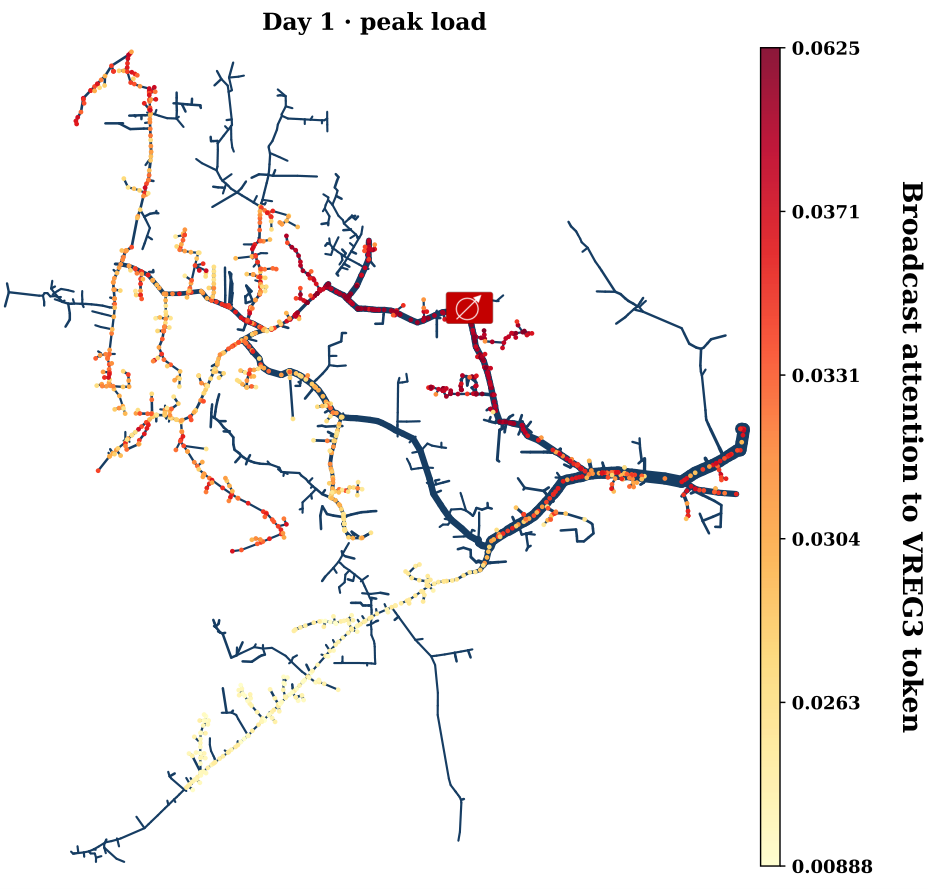


day=1 tag=bestrank tags=['bestrank'] step=251 (20:55)  m=0.5895 irr=0  AUROC=0.9364 R_r=1.4892  buses=1,335  max=0.0432231 @ m1010014
  Color mode: within-phase percentile (same as paper VREG3 figs)
--- upper_frac=linear  out=C:\Users\alita\OneDrive\Desktop\GNN2\Figures\day_attention\vreg3_a_attention_day01_bestrank.pdf ---
regulator_name_filter: ['vreg3_a']
  Coord snap:               22 ft (near-coincident buses merged)
Parsed IEEE 8500 model:
  DSS folder:             C:\Users\alita\OneDrive\Desktop\GNN2\8500 nodes with solar unbalanced
  Style:                    paper
  Bus coordinates:        2,476  (+53 backfilled)
  Line edges (total):     2,517
    MV backbone:          752
      3-phase primary:    609
      1-phase trunk:      143
    Service laterals:     1,759
    triplex (LV):         not plotted
  RegControls:            12
  Capacitor banks:        10
  PV systems:             2
  Load buses (coords):    1
  MV graph components:    3  (largest 1,831 buses)
    substati

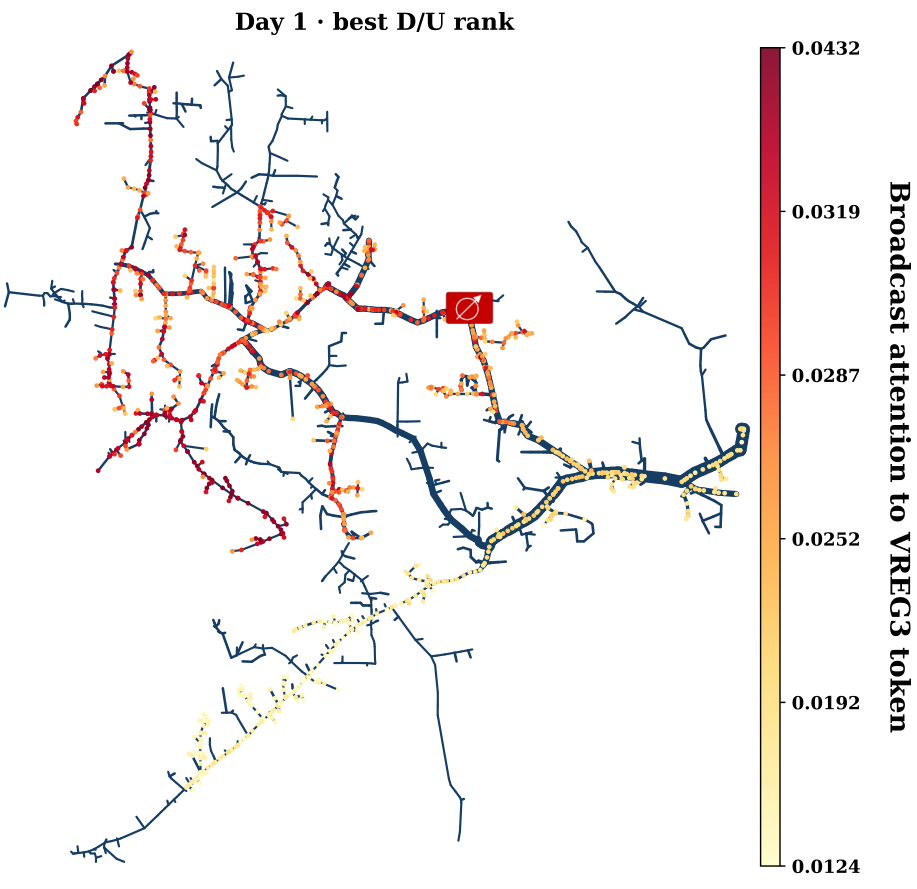


day=2 tag=peakload tags=['peakload'] step=242 (20:10)  m=0.6027 irr=0  AUROC=0.9461 R_r=1.7831  buses=1,335  max=0.0543766 @ l3066804
  Color mode: within-phase percentile (same as paper VREG3 figs)
--- upper_frac=linear  out=C:\Users\alita\OneDrive\Desktop\GNN2\Figures\day_attention\vreg3_a_attention_day02_peakload.pdf ---
regulator_name_filter: ['vreg3_a']
  Coord snap:               22 ft (near-coincident buses merged)
Parsed IEEE 8500 model:
  DSS folder:             C:\Users\alita\OneDrive\Desktop\GNN2\8500 nodes with solar unbalanced
  Style:                    paper
  Bus coordinates:        2,476  (+53 backfilled)
  Line edges (total):     2,517
    MV backbone:          752
      3-phase primary:    609
      1-phase trunk:      143
    Service laterals:     1,759
    triplex (LV):         not plotted
  RegControls:            12
  Capacitor banks:        10
  PV systems:             2
  Load buses (coords):    1
  MV graph components:    3  (largest 1,831 buses)
    substati

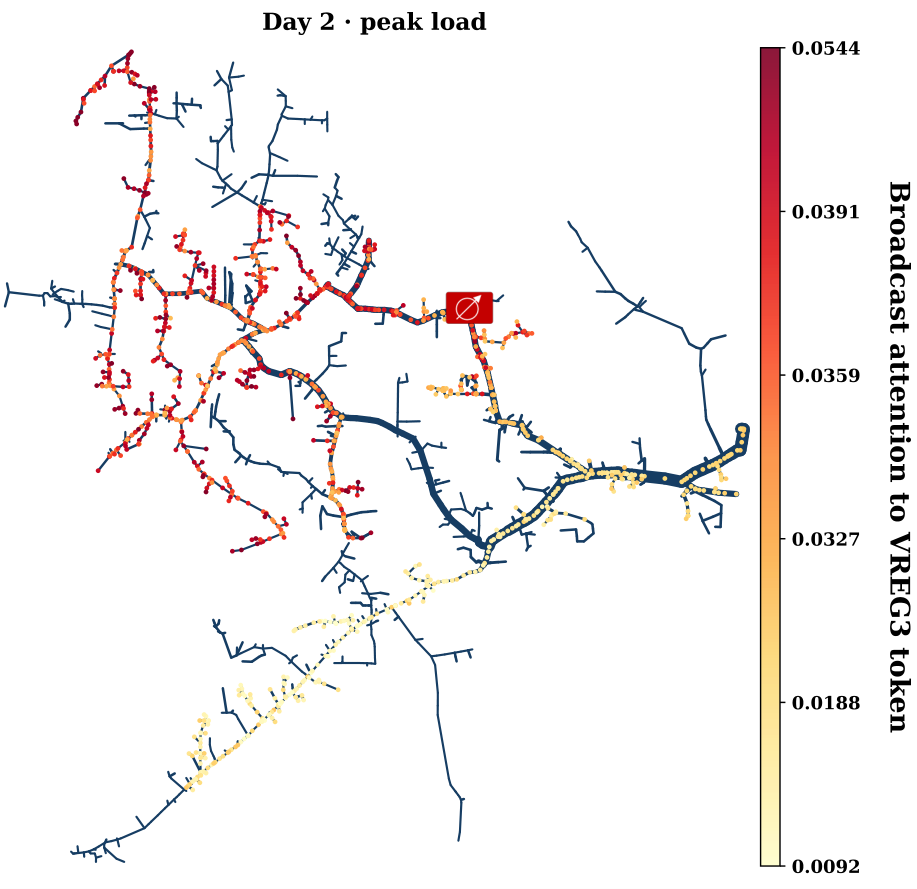


day=2 tag=bestrank tags=['bestrank'] step=246 (20:30)  m=0.5976 irr=0  AUROC=0.9493 R_r=1.7314  buses=1,335  max=0.0546558 @ l3066804
  Color mode: within-phase percentile (same as paper VREG3 figs)
--- upper_frac=linear  out=C:\Users\alita\OneDrive\Desktop\GNN2\Figures\day_attention\vreg3_a_attention_day02_bestrank.pdf ---
regulator_name_filter: ['vreg3_a']
  Coord snap:               22 ft (near-coincident buses merged)
Parsed IEEE 8500 model:
  DSS folder:             C:\Users\alita\OneDrive\Desktop\GNN2\8500 nodes with solar unbalanced
  Style:                    paper
  Bus coordinates:        2,476  (+53 backfilled)
  Line edges (total):     2,517
    MV backbone:          752
      3-phase primary:    609
      1-phase trunk:      143
    Service laterals:     1,759
    triplex (LV):         not plotted
  RegControls:            12
  Capacitor banks:        10
  PV systems:             2
  Load buses (coords):    1
  MV graph components:    3  (largest 1,831 buses)
    substati

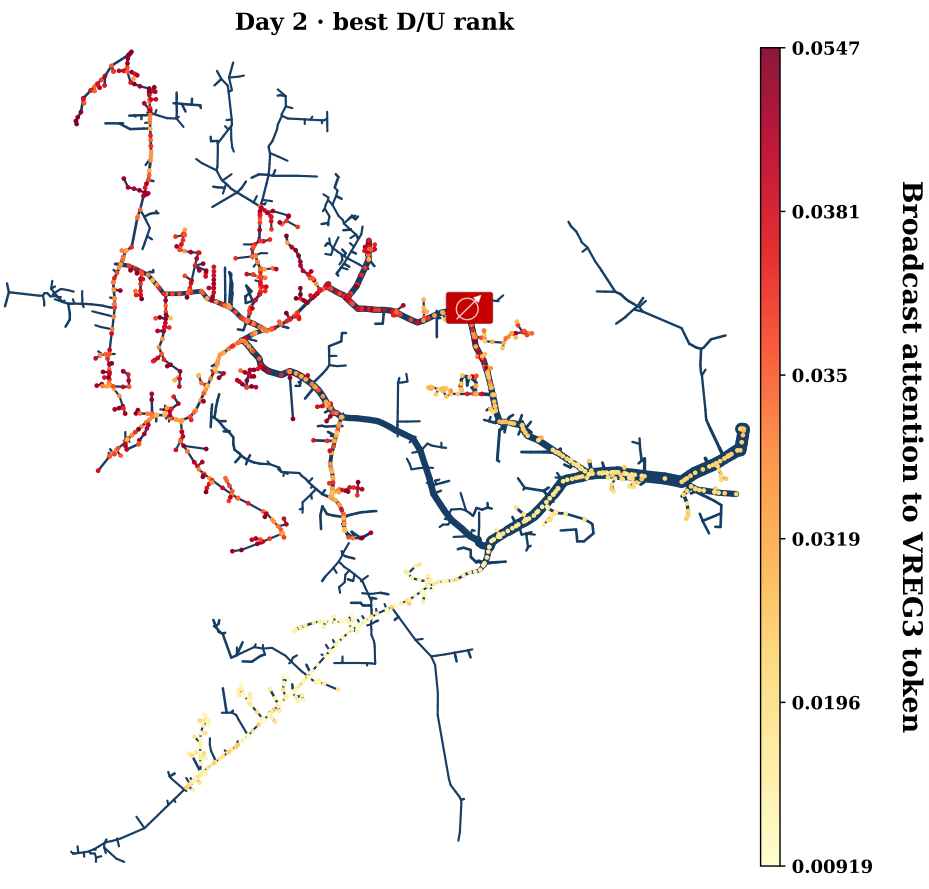


day=3 tag=peakload tags=['peakload'] step=227 (18:55)  m=0.8356 irr=0.2673  AUROC=0.9459 R_r=1.8473  buses=1,335  max=0.0540416 @ l3160101
  Color mode: within-phase percentile (same as paper VREG3 figs)
--- upper_frac=linear  out=C:\Users\alita\OneDrive\Desktop\GNN2\Figures\day_attention\vreg3_a_attention_day03_peakload.pdf ---
regulator_name_filter: ['vreg3_a']
  Coord snap:               22 ft (near-coincident buses merged)
Parsed IEEE 8500 model:
  DSS folder:             C:\Users\alita\OneDrive\Desktop\GNN2\8500 nodes with solar unbalanced
  Style:                    paper
  Bus coordinates:        2,476  (+53 backfilled)
  Line edges (total):     2,517
    MV backbone:          752
      3-phase primary:    609
      1-phase trunk:      143
    Service laterals:     1,759
    triplex (LV):         not plotted
  RegControls:            12
  Capacitor banks:        10
  PV systems:             2
  Load buses (coords):    1
  MV graph components:    3  (largest 1,831 buses)
    sub

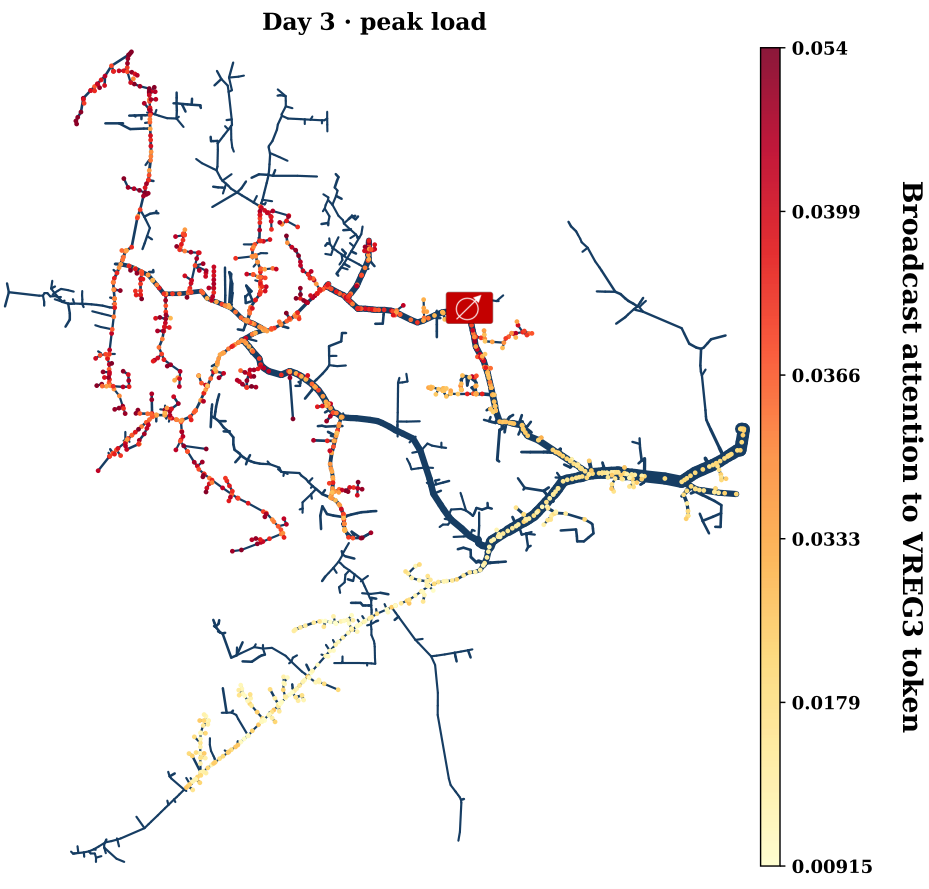


day=3 tag=bestrank tags=['bestrank'] step=236 (19:40)  m=0.8207 irr=0.02584  AUROC=0.9493 R_r=1.7283  buses=1,335  max=0.0546496 @ l3066804
  Color mode: within-phase percentile (same as paper VREG3 figs)
--- upper_frac=linear  out=C:\Users\alita\OneDrive\Desktop\GNN2\Figures\day_attention\vreg3_a_attention_day03_bestrank.pdf ---
regulator_name_filter: ['vreg3_a']
  Coord snap:               22 ft (near-coincident buses merged)
Parsed IEEE 8500 model:
  DSS folder:             C:\Users\alita\OneDrive\Desktop\GNN2\8500 nodes with solar unbalanced
  Style:                    paper
  Bus coordinates:        2,476  (+53 backfilled)
  Line edges (total):     2,517
    MV backbone:          752
      3-phase primary:    609
      1-phase trunk:      143
    Service laterals:     1,759
    triplex (LV):         not plotted
  RegControls:            12
  Capacitor banks:        10
  PV systems:             2
  Load buses (coords):    1
  MV graph components:    3  (largest 1,831 buses)
    su

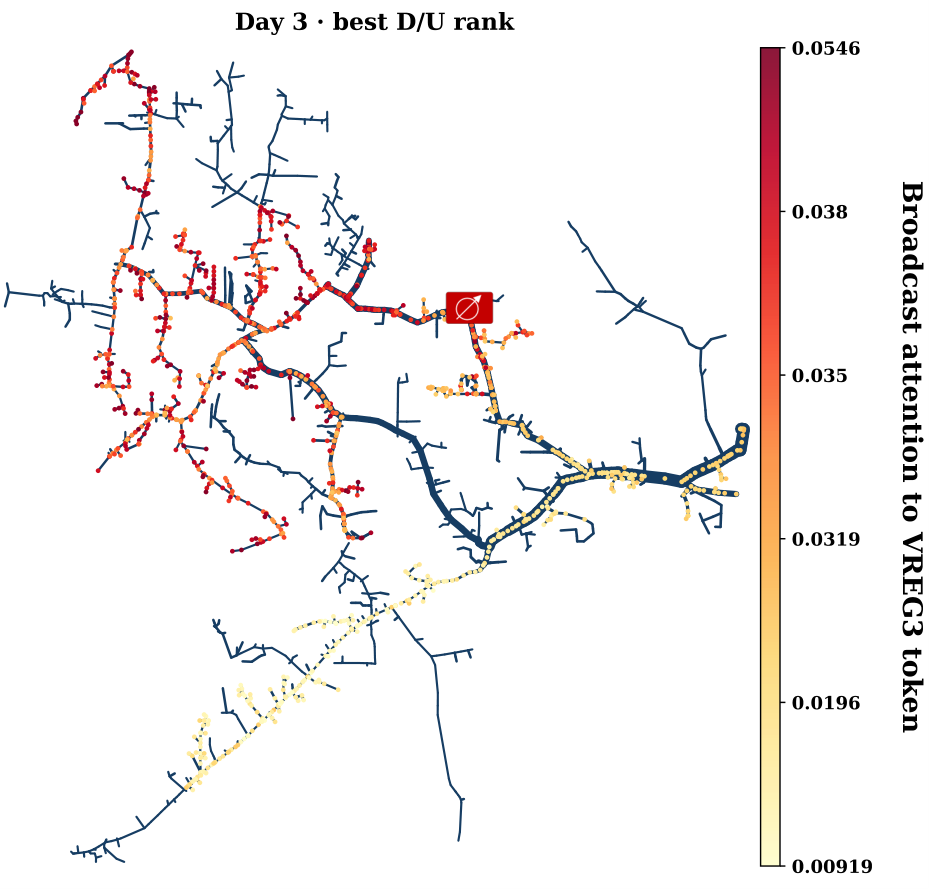


day=4 tag=peakload tags=['peakload'] step=222 (18:30)  m=0.9773 irr=0.3214  AUROC=0.9911 R_r=2.3465  buses=1,335  max=0.0550178 @ l3120503
  Color mode: within-phase percentile (same as paper VREG3 figs)
--- upper_frac=linear  out=C:\Users\alita\OneDrive\Desktop\GNN2\Figures\day_attention\vreg3_a_attention_day04_peakload.pdf ---
regulator_name_filter: ['vreg3_a']
  Coord snap:               22 ft (near-coincident buses merged)
Parsed IEEE 8500 model:
  DSS folder:             C:\Users\alita\OneDrive\Desktop\GNN2\8500 nodes with solar unbalanced
  Style:                    paper
  Bus coordinates:        2,476  (+53 backfilled)
  Line edges (total):     2,517
    MV backbone:          752
      3-phase primary:    609
      1-phase trunk:      143
    Service laterals:     1,759
    triplex (LV):         not plotted
  RegControls:            12
  Capacitor banks:        10
  PV systems:             2
  Load buses (coords):    1
  MV graph components:    3  (largest 1,831 buses)
    sub

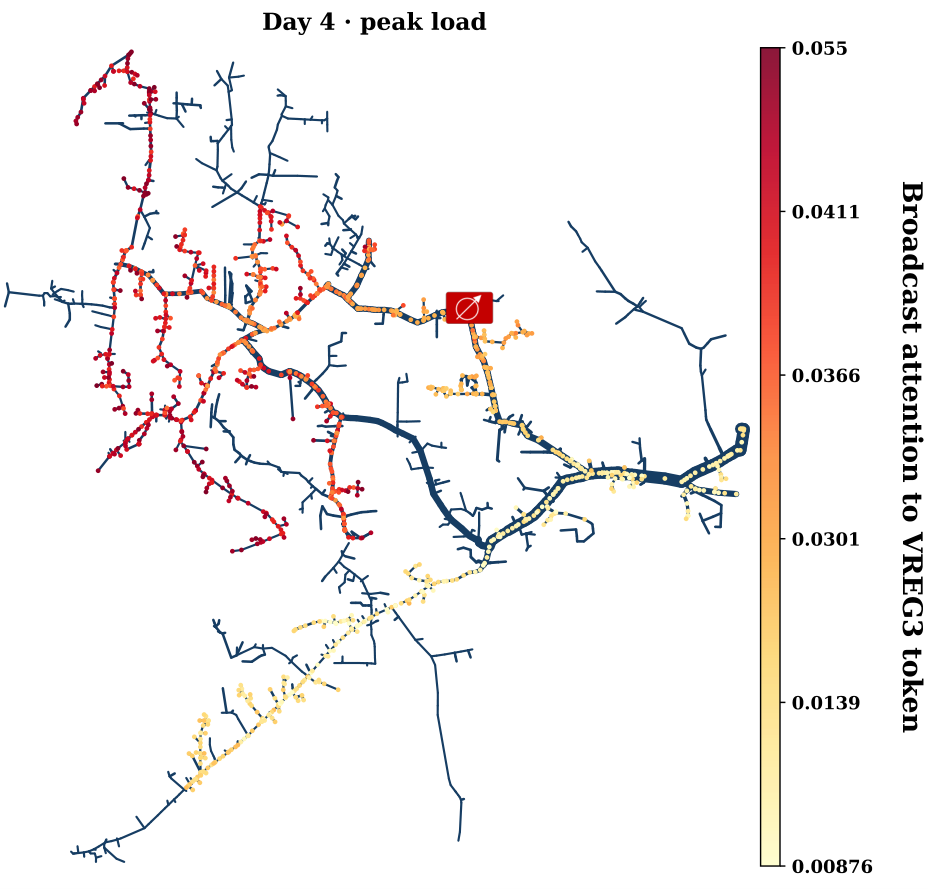


day=4 tag=bestrank tags=['bestrank'] step=222 (18:30)  m=0.9773 irr=0.3214  AUROC=0.9911 R_r=2.3465  buses=1,335  max=0.0550178 @ l3120503
  Color mode: within-phase percentile (same as paper VREG3 figs)
--- upper_frac=linear  out=C:\Users\alita\OneDrive\Desktop\GNN2\Figures\day_attention\vreg3_a_attention_day04_bestrank.pdf ---
regulator_name_filter: ['vreg3_a']
  Coord snap:               22 ft (near-coincident buses merged)
Parsed IEEE 8500 model:
  DSS folder:             C:\Users\alita\OneDrive\Desktop\GNN2\8500 nodes with solar unbalanced
  Style:                    paper
  Bus coordinates:        2,476  (+53 backfilled)
  Line edges (total):     2,517
    MV backbone:          752
      3-phase primary:    609
      1-phase trunk:      143
    Service laterals:     1,759
    triplex (LV):         not plotted
  RegControls:            12
  Capacitor banks:        10
  PV systems:             2
  Load buses (coords):    1
  MV graph components:    3  (largest 1,831 buses)
    sub

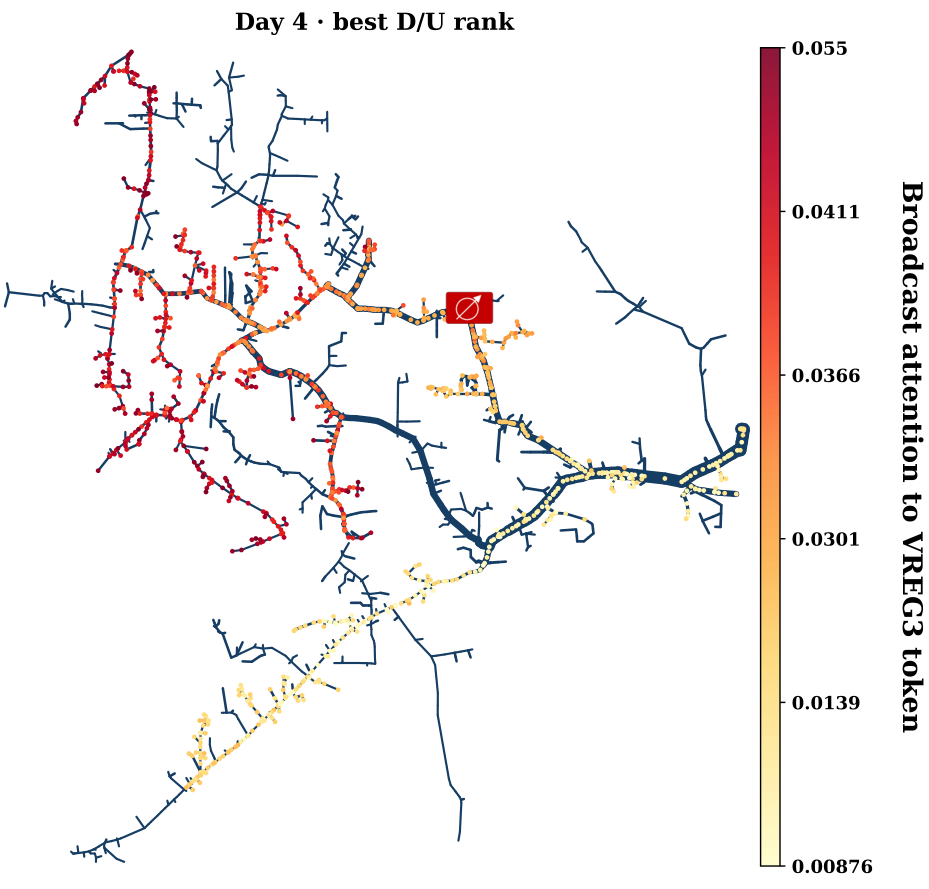


day=4 tag=global_bestrank tags=['global_bestrank'] step=222 (18:30)  m=0.9773 irr=0.3214  AUROC=0.9911 R_r=2.3465  buses=1,335  max=0.0550178 @ l3120503
  Color mode: within-phase percentile (same as paper VREG3 figs)
--- upper_frac=linear  out=C:\Users\alita\OneDrive\Desktop\GNN2\Figures\day_attention\vreg3_a_attention_global_bestrank_day04.pdf ---
regulator_name_filter: ['vreg3_a']
  Coord snap:               22 ft (near-coincident buses merged)
Parsed IEEE 8500 model:
  DSS folder:             C:\Users\alita\OneDrive\Desktop\GNN2\8500 nodes with solar unbalanced
  Style:                    paper
  Bus coordinates:        2,476  (+53 backfilled)
  Line edges (total):     2,517
    MV backbone:          752
      3-phase primary:    609
      1-phase trunk:      143
    Service laterals:     1,759
    triplex (LV):         not plotted
  RegControls:            12
  Capacitor banks:        10
  PV systems:             2
  Load buses (coords):    1
  MV graph components:    3  (largest

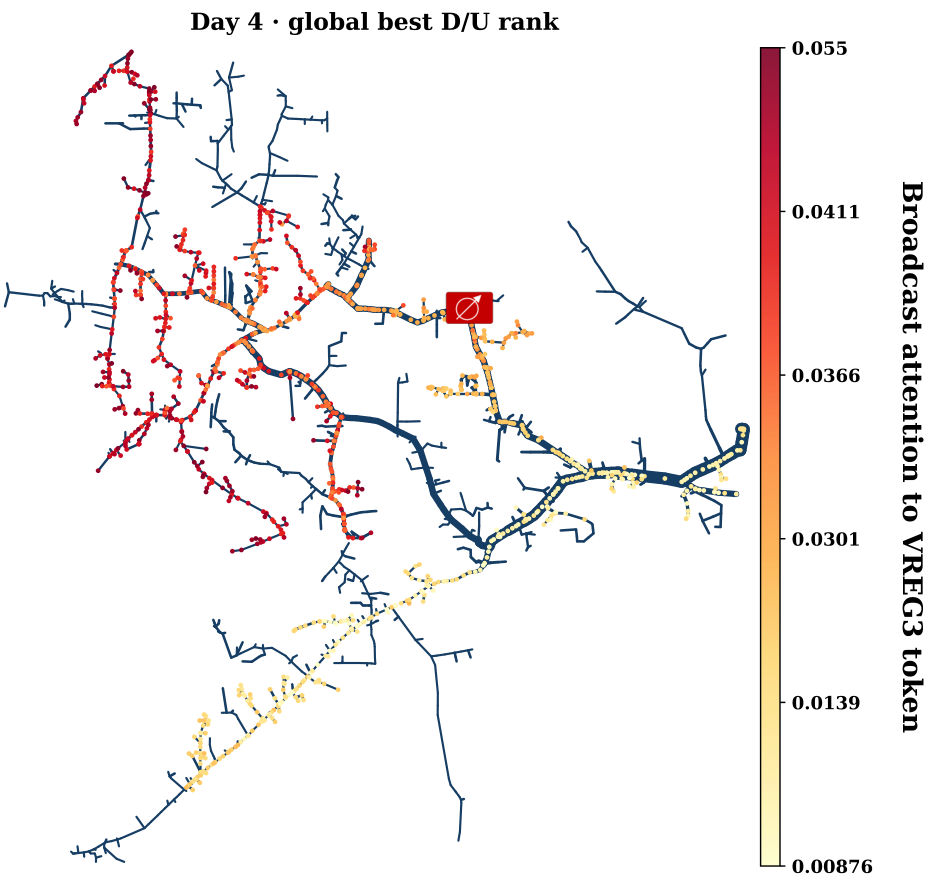

saved C:\Users\alita\OneDrive\Desktop\GNN2\Figures\day_attention\vreg3_a_day_peakload_bestrank_attn.npz

Done: 9 figure(s) under C:\Users\alita\OneDrive\Desktop\GNN2\Figures\day_attention (main day maps=8, expected 8)


{'vreg3_a_attention_day01_peakload': {'pdf': WindowsPath('C:/Users/alita/OneDrive/Desktop/GNN2/Figures/day_attention/vreg3_a_attention_day01_peakload.pdf'),
  'svg': WindowsPath('C:/Users/alita/OneDrive/Desktop/GNN2/Figures/day_attention/vreg3_a_attention_day01_peakload.svg'),
  'png': WindowsPath('C:/Users/alita/OneDrive/Desktop/GNN2/Figures/day_attention/vreg3_a_attention_day01_peakload.png')},
 'vreg3_a_attention_day01_bestrank': {'pdf': WindowsPath('C:/Users/alita/OneDrive/Desktop/GNN2/Figures/day_attention/vreg3_a_attention_day01_bestrank.pdf'),
  'svg': WindowsPath('C:/Users/alita/OneDrive/Desktop/GNN2/Figures/day_attention/vreg3_a_attention_day01_bestrank.svg'),
  'png': WindowsPath('C:/Users/alita/OneDrive/Desktop/GNN2/Figures/day_attention/vreg3_a_attention_day01_bestrank.png')},
 'vreg3_a_attention_day02_peakload': {'pdf': WindowsPath('C:/Users/alita/OneDrive/Desktop/GNN2/Figures/day_attention/vreg3_a_attention_day02_peakload.pdf'),
  'svg': WindowsPath('C:/Users/alita/OneDri

In [1]:
# ============================================================
# VREG3-A attention: always 8 maps (4 days × {peakload, bestrank}) + optional global
# Ranking = downstream vs upstream contrast (AUROC_r, then R_r)
# ============================================================
from __future__ import annotations

import csv
import importlib
import json
import os
import sys
from pathlib import Path

import numpy as np
import torch
from torch_geometric.data import Data
from IPython.display import Image, display

%matplotlib inline

# -------------------- knobs (match 906 VREG3 paper figure) --------------------
REG_COL = "reg_vreg3_a_tap_pu"
LAYER = -1  # last GPS layer
ATTN_DIR = "node_to_token"  # broadcast
DAYS = (1, 2, 3, 4)
NPTS = 288
STEP_MIN = 5
SCENARIO_SCALE = 1.0
DAILY_STRESS = 0.0
# Scan every RANK_STEP_STRIDE-th timestep for D/U ranking (1 = all 288 steps)
RANK_STEP_STRIDE = 1
RANK_PRINT_TOP = 20  # how many ranked steps to print per day
CONTRAST_PRIMARY = "AUROC_r"  # "AUROC_r" | "R_r"

# Formatting: same paper topology/icons/colorbar layout as VREG3;
# rank = within-phase percentile so the full colormap is used (equal tick spacing).
COLOR_LOG = False
BUS_COLOR_CMAP = "YlOrRd"
BUS_COLOR_LABEL = "Broadcast attention to VREG3 token"
BUS_COLOR_VISUAL_MATCH = "rank"  # within-phase percentile so full colormap is used
BUS_COLOR_FADE_CMAP_FRAC = 0.06  # unused when upper_frac is None
BUS_COLOR_UPPER_FRAC = None  # linear Normalize
BUS_COLOR_POWER_GAMMA = 1.0
SHOW_SUBSTATION = False
ICON_SIZE_SCALE = 2.6
SHOW_PREVIEWS = True
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

# Prefer shipped CCE run; fall back to any attention checkpoint with norms + best pt
RUN_CANDIDATES = [
    Path(r"C:\Users\alita\OneDrive\Desktop\GNN2\gnn2_architecture_search\attention checkpoints\da_gps_chunked_l4_mvagg_gine_metaaux_regce_20260516_225149_CCE"),
    Path("/content/drive/MyDrive/datasets_gnn2/runs/da_gps_chunked_l4_mvagg_gine_metaaux_regce_20260516_225149_CCE"),
    Path("/content/GNN-Sandia/gnn2_architecture_search/attention checkpoints/da_gps_chunked_l4_mvagg_gine_metaaux_regce_20260516_225149_CCE"),
]
CACHE_CANDIDATES = [
    Path(r"C:\Users\alita\OneDrive\Desktop\GNN2\datasets_gnn2_from pc\run_001_ref0_slim__full__nobess__regce__mauxb7bd1d58.pt"),
    Path(r"C:\Users\alita\OneDrive\Desktop\GNN2\datasets_gnn2_from pc\run_001_scen_0000_0049_seed_20420233__full__nobess__regce__mauxb7bd1d58.pt"),
    Path("/content/GNN-Sandia/datasets_gnn2_from pc/run_001_ref0_slim__full__nobess__regce__mauxb7bd1d58.pt"),
    Path("/content/drive/MyDrive/datasets_gnn2/cache/da_gps_chunked_mvagg_full_gine"),
]
EDGE_CANDIDATES = [
    # Same edges file used by the paper mean-attention extract (_run_attention_avg_full_cache.py)
    Path(r"C:\Users\alita\OneDrive\Desktop\GNN2\datasets_gnn2_from pc\gnn_edges_phase_static.csv"),
    Path(r"C:\Users\alita\OneDrive\Desktop\GNN2\datasets_gnn2_from pc\original_8500_unbalanced\run_001_scen_0000_0049_seed_20360133\gnn_edges_phase_static.csv"),
    Path(r"K:\My Drive\datasets_gnn2\original_8500_unbalanced_chunked_no_bess_new_diverse_2000_40\run_001_scen_0000_0049_seed_20420233\gnn_edges_phase_static.csv"),
    Path(r"K:\My Drive\datasets_gnn2\original_8500_unbalanced_chunked_no_bess_new_diverse_2000_40_yedges\run_001_scen_0000_0049_seed_20420233\gnn_edges_phase_static.csv"),
    Path(r"K:\My Drive\datasets_gnn2\original_8500_unbalanced_chunked_no_bess_new_diverse_2000_40_fixedctrlinit_yedges\run_001_scen_0000_0049_seed_20420233\gnn_edges_phase_static.csv"),
    Path(r"C:\Users\alita\OneDrive\Desktop\GNN2\datasets_gnn2_from pc\original_8500_unbalanced_chunked_no_bess_new_diverse_2000_40\run_001_scen_0000_0049_seed_20420233\gnn_edges_phase_static.csv"),
    Path("/content/drive/MyDrive/datasets_gnn2/original_8500_unbalanced_chunked_no_bess_new_diverse_2000_40/run_001_scen_0000_0049_seed_20420233/gnn_edges_phase_static.csv"),
    Path("/content/drive/MyDrive/datasets_gnn2/original_8500_unbalanced_chunked_no_bess_new_diverse_2000_40_yedges/run_001_scen_0000_0049_seed_20420233/gnn_edges_phase_static.csv"),
    Path("/content/drive/MyDrive/datasets_gnn2/original_8500_unbalanced_chunked_no_bess_new_diverse_2000_40_fixedctrlinit_yedges/run_001_scen_0000_0049_seed_20420233/gnn_edges_phase_static.csv"),
]
HOP_CANDIDATES = [
    Path(r"C:\Users\alita\OneDrive\Desktop\GNN2\datasets_gnn2_from pc\load_hop_distance_to_each_regulator_all_index_nodes.csv"),
    Path("/content/GNN-Sandia/datasets_gnn2_from pc/load_hop_distance_to_each_regulator_all_index_nodes.csv"),
    Path("/content/drive/MyDrive/datasets_gnn2/load_hop_distance_to_each_regulator_all_index_nodes.csv"),
]
# ------------------------------------------------


def _find_repo() -> Path:
    for p in [
        Path(os.environ.get("GNN2_REPO_ROOT", "")),
        Path.cwd(),
        Path(r"C:\Users\alita\OneDrive\Desktop\GNN2"),
        Path("/content/GNN-Sandia"),
        Path("/content/GNN2"),
    ]:
        if not p or not str(p):
            continue
        p = Path(p).resolve()
        if (p / "extract_da_gps_attention.py").is_file() and (
            p / "plot_ieee8500_feeder_topology.py"
        ).is_file():
            return p
    raise FileNotFoundError("Repo root with extract_da_gps_attention.py not found")


REPO = _find_repo()
os.chdir(REPO)
if str(REPO) not in sys.path:
    sys.path.insert(0, str(REPO))

import plot_ieee8500_feeder_topology as p8500
from compare_opendss_snapshot_helpers import prepare_parity_profiles
from da_gps_hop_attention_ratios import (
    REG_COL_TO_HOP_COL,
    downstream_mask,
    hops_for_manifest_nodes,
    load_hop_frame,
    mannwhitney_auroc,
    non_downstream_catalog_mask,
)
from extract_da_gps_attention import (
    _assert_x_zscore_shapes,
    _build_model,
    _infer_node_in_edge_dim,
    _load_eval_edges,
    _node_order_from_ntl,
    augment_da_gps_pack_for_eval,
)

p8500 = importlib.reload(p8500)
p8500.clear_icon_caches()


def _first_file(cands: list[Path]) -> Path:
    for p in cands:
        if p.is_file():
            return p.resolve()
    raise FileNotFoundError("none of:\n  " + "\n  ".join(str(c) for c in cands))


def _first_run_dir(cands: list[Path]) -> Path:
    for p in cands:
        if (p / "da_gps_multitask_best.pt").is_file() or (p / "training_last.pt").is_file():
            return p.resolve()
        if (p / "x_mean.pt").is_file():
            return p.resolve()
    raise FileNotFoundError("no usable RUN_DIR among candidates")


def _resolve_cache(cands: list[Path]) -> Path:
    for p in cands:
        if p.is_file() and p.suffix == ".pt":
            return p.resolve()
        if p.is_dir():
            hits = sorted(p.glob("run_001*.pt")) + sorted(p.glob("*.pt"))
            if hits:
                return hits[0].resolve()
    raise FileNotFoundError("no cache .pt found")


def _ckpt_in(run: Path) -> Path:
    for name in ("da_gps_multitask_best.pt", "training_last.pt"):
        p = run / name
        if p.is_file():
            return p
    raise FileNotFoundError(f"no checkpoint under {run}")


def _phase_node_to_bus(node: str) -> str:
    s = str(node).strip()
    if "." in s:
        bus, ph = s.rsplit(".", 1)
        if ph.isdigit():
            return bus
    return s


def _phase_suffix(node: str) -> int | None:
    s = str(node).strip()
    if "." in s:
        _, ph = s.rsplit(".", 1)
        if ph.isdigit():
            return int(ph)
    return None


def _bus_vals_phase_a(a_nodes: np.ndarray, node_names: list[str]) -> dict[str, float]:
    out: dict[str, float] = {}
    for nm, a in zip(node_names, a_nodes):
        if _phase_suffix(nm) != 1:
            continue
        out[_phase_node_to_bus(nm)] = float(a)
    if not out:
        raise RuntimeError("No phase-A buses in attention vector")
    return out


def _minutes_label(step: int, step_min: float) -> str:
    tot = int(round(float(step) * float(step_min)))
    hh, mm = divmod(tot, 60)
    return f"{hh:02d}:{mm:02d}"


RUN_DIR = _first_run_dir(RUN_CANDIDATES)
CKPT = _ckpt_in(RUN_DIR)
CACHE_PT = _resolve_cache(CACHE_CANDIDATES)
EDGES_CSV = _first_file(EDGE_CANDIDATES)
HOP_CSV = _first_file(HOP_CANDIDATES)
DAY_DIR = REPO / "a representativ days"
FIGURES_DIR = REPO / "Figures" / "day_attention"
FIGURES_DIR.mkdir(parents=True, exist_ok=True)
ICONS = REPO / "outputs" / "Icons"

print("REPO:", REPO)
print("RUN_DIR:", RUN_DIR)
print("CKPT:", CKPT.name)
print("CACHE:", CACHE_PT)
print("EDGES:", EDGES_CSV)
print("HOP_CSV:", HOP_CSV)
print("DAY_DIR:", DAY_DIR)
print("OUT:", FIGURES_DIR)
print("DEVICE:", DEVICE)
print(f"RANK_STEP_STRIDE={RANK_STEP_STRIDE}  CONTRAST_PRIMARY={CONTRAST_PRIMARY}")

pack = torch.load(CKPT, map_location="cpu", weights_only=False)
sd = pack["model_state_dict"]
z = torch.load(CACHE_PT, map_location="cpu", weights_only=False)
node_to_local = z["node_to_local"]
x_cache = z["x"].float()
node_order = _node_order_from_ntl(node_to_local)
ref_i = 0
ref_x = x_cache[ref_i].numpy().astype(np.float32, copy=True)

x_mean = torch.load(RUN_DIR / "x_mean.pt", map_location="cpu", weights_only=True).float()
x_std = torch.load(RUN_DIR / "x_std.pt", map_location="cpu", weights_only=True).float()
_assert_x_zscore_shapes(x_cache, x_mean, x_std, run_dir=RUN_DIR, cache_pt=CACHE_PT)

augment_da_gps_pack_for_eval(pack, sd, CKPT, RUN_DIR, node_in_dim_hint=int(x_cache.shape[-1]))
hidden = int(pack["hidden"])
node_emb_dim = int(pack["node_emb_dim"])
edge_emb_dim = int(pack["edge_emb_dim"])
_, raw_edge_dim = _infer_node_in_edge_dim(
    sd, hidden=hidden, node_emb_dim=node_emb_dim, edge_emb_dim=edge_emb_dim
)
edge_index, edge_attr = _load_eval_edges(
    EDGES_CSV, node_to_local, raw_edge_dim=int(raw_edge_dim), cache_z=z, sd=sd
)
model = _build_model(pack, sd, num_edges=int(edge_index.shape[1]), dropout=0.0)
model.load_state_dict(sd, strict=True)
model.to(DEVICE)
model.eval()

feat_cols = list(pack.get("node_feature_cols") or ["p_load_kw", "q_load_kvar", "p_pv_kw"])
hp = pack.get("hparams") or pack.get("args") or {}
if isinstance(hp, dict) and hp.get("node_feature_cols"):
    feat_cols = [str(c) for c in str(hp["node_feature_cols"]).split(",") if str(c).strip()]
col_p, col_q, col_pv = 0, 1, 2
print("feature scale cols (assumed):", col_p, col_q, col_pv, "feat_cols=", feat_cols[:6])

reg_cols = list(pack.get("reg_target_cols") or [])
cap_cols = list(pack.get("cap_target_cols") or [])
if not reg_cols:
    rep = RUN_DIR / "da_gps_report.json"
    if rep.is_file():
        rj = json.loads(rep.read_text(encoding="utf-8"))
        reg_cols = list(rj.get("reg_target_cols") or rj.get("hparams", {}).get("reg_cols") or [])
        cap_cols = list(rj.get("cap_target_cols") or [])
if REG_COL not in reg_cols:
    reg_cols = reg_cols or [
        "reg_feeder_rega_tap_pu",
        "reg_feeder_regb_tap_pu",
        "reg_feeder_regc_tap_pu",
        "reg_vreg2_a_tap_pu",
        "reg_vreg2_b_tap_pu",
        "reg_vreg2_c_tap_pu",
        "reg_vreg3_a_tap_pu",
        "reg_vreg3_b_tap_pu",
        "reg_vreg3_c_tap_pu",
        "reg_vreg4_a_tap_pu",
        "reg_vreg4_b_tap_pu",
        "reg_vreg4_c_tap_pu",
    ]
    cap_cols = cap_cols or [
        "cap_capbank0a_n_steps_on",
        "cap_capbank0b_n_steps_on",
        "cap_capbank0c_n_steps_on",
        "cap_capbank1a_n_steps_on",
        "cap_capbank1b_n_steps_on",
        "cap_capbank1c_n_steps_on",
        "cap_capbank2a_n_steps_on",
        "cap_capbank2b_n_steps_on",
        "cap_capbank2c_n_steps_on",
        "cap_capbank3_n_steps_on",
    ]
if REG_COL not in reg_cols:
    raise ValueError(f"{REG_COL} not in reg_cols={reg_cols}")
tok_idx = len(cap_cols) + int(reg_cols.index(REG_COL))
print(f"token {REG_COL} -> idx {tok_idx} (n_cap={len(cap_cols)})")

# Phase-matched downstream / upstream masks for VREG3-A
hop_col = REG_COL_TO_HOP_COL.get(REG_COL)
if hop_col is None:
    raise KeyError(f"No hop column mapping for {REG_COL}")
hop_df = load_hop_frame(HOP_CSV)
hops, _miss = hops_for_manifest_nodes(hop_df, node_order, hop_col)
phases = np.asarray(
    [
        (int(nm.rsplit(".", 1)[-1]) if ("." in nm and nm.rsplit(".", 1)[-1].isdigit()) else -1)
        for nm in node_order
    ],
    dtype=int,
)
_d = downstream_mask(hops, rule="hop_gt_0") & (phases == 1)
_u = non_downstream_catalog_mask(hops, rule="hop_gt_0") & (phases == 1)
if not np.any(_d) or not np.any(_u):
    raise RuntimeError(f"Empty D/U masks for {REG_COL}: n_D={int(_d.sum())} n_U={int(_u.sum())}")
print(f"hop contrast masks: n_D={int(_d.sum())}  n_U={int(_u.sum())}  hop_col={hop_col}")

dev = torch.device(DEVICE)
x_mean_d = x_mean.to(dev)
x_std_d = x_std.to(dev)
edge_index_d = edge_index.to(dev)
edge_attr_d = edge_attr.to(dev)


@torch.no_grad()
def _attn_nodes_for_x(x_np: np.ndarray) -> np.ndarray:
    x_t = torch.from_numpy(np.asarray(x_np, dtype=np.float32))
    x_n = ((x_t - x_mean_d.cpu()) / x_std_d.cpu()).to(device=dev, dtype=torch.float32)
    data = Data(x=x_n, edge_index=edge_index_d, edge_attr=edge_attr_d)
    data.num_graphs = 1
    out = model.forward_node_to_token_attention(data)
    if len(out) < 5:
        raise RuntimeError(f"unexpected attention return len={len(out)}")
    layer_probs_nt = out[0]
    layer = layer_probs_nt[int(LAYER) if int(LAYER) >= 0 else -1]
    a = layer.detach().float().cpu().numpy()
    while a.ndim > 2:
        a = a.mean(axis=0)
    return np.asarray(a[:, int(tok_idx)], dtype=np.float64)


def _scale_ref_x(m_t: float, ir_t: float, *, m_ref: float, ir_ref: float) -> np.ndarray:
    x = ref_x.copy()
    ms = float(m_t) / max(float(m_ref), 1e-6)
    irs = float(ir_t) / max(float(ir_ref), 1e-6)
    x[:, col_p] *= ms
    x[:, col_q] *= ms
    x[:, col_pv] *= irs
    return x


def _contrast_metrics(a_nodes: np.ndarray) -> dict[str, float]:
    a = np.asarray(a_nodes, dtype=float).ravel()
    a_d = a[_d]
    a_u = a[_u]
    mu_d = float(a_d.mean())
    mu_u = float(a_u.mean())
    r_r = mu_d / (mu_u + 1e-12)
    auc = float(mannwhitney_auroc(a_d, a_u))
    return {"AUROC_r": auc, "R_r": float(r_r), "mu_D": mu_d, "mu_U": mu_u}


def _rank_key(row: dict) -> tuple[float, float]:
    primary = str(CONTRAST_PRIMARY).strip()
    if primary == "R_r":
        return (float(row["R_r"]), float(row["AUROC_r"]))
    return (float(row["AUROC_r"]), float(row["R_r"]))


# Rank every (strided) timestep per day; select peakload + bestrank; then global bestrank
jobs: list[dict] = []
day_rankings: dict[int, list[dict]] = {}
all_rank_rows: list[dict] = []

for day in DAYS:
    load_csv = DAY_DIR / f"load_day_{day:03d}.csv"
    irr_csv = DAY_DIR / f"irr_day_{day:03d}.csv"
    if not load_csv.is_file() or not irr_csv.is_file():
        raise FileNotFoundError(f"Missing day profiles:\n  {load_csv}\n  {irr_csv}")
    prof = prepare_parity_profiles(
        load_csv=load_csv,
        irr_csv=irr_csv,
        npts=int(NPTS),
        step_min=float(STEP_MIN),
        daily_stress=float(DAILY_STRESS),
    )
    m_eff = np.asarray(prof.m_eff, dtype=float)
    m_irr = np.asarray(prof.m_irr, dtype=float)
    m_ref = float(np.nanmean(m_eff))
    ir_ref = float(np.nanmean(m_irr))
    peak_i = int(np.nanargmax(m_eff))

    scan_ix = list(range(0, int(len(m_eff)), max(1, int(RANK_STEP_STRIDE))))
    if peak_i not in scan_ix:
        scan_ix.append(peak_i)
        scan_ix.sort()

    print("\n" + "=" * 100)
    print(
        f"DAY {day}: ranking {len(scan_ix)} steps by {CONTRAST_PRIMARY} "
        f"(downstream vs upstream, phase-A, VREG3-A)"
    )
    rows: list[dict] = []
    attn_cache: dict[int, np.ndarray] = {}
    for si in scan_ix:
        m_t = float(m_eff[si]) * float(SCENARIO_SCALE)
        ir_t = float(m_irr[si])
        x_step = _scale_ref_x(m_t, ir_t, m_ref=m_ref, ir_ref=ir_ref)
        a_nodes = _attn_nodes_for_x(x_step)
        attn_cache[si] = a_nodes
        met = _contrast_metrics(a_nodes)
        rows.append(
            {
                "day": int(day),
                "step": int(si),
                "time": _minutes_label(si, STEP_MIN),
                "m_load": float(m_eff[si]),
                "m_irr": float(m_irr[si]),
                **met,
            }
        )
    rows.sort(key=_rank_key, reverse=True)
    for rank_i, r in enumerate(rows, start=1):
        r["rank"] = int(rank_i)
    day_rankings[int(day)] = rows
    all_rank_rows.extend(rows)

    rank_csv = FIGURES_DIR / f"vreg3_a_day{day:02d}_step_rank_by_{CONTRAST_PRIMARY}.csv"
    with rank_csv.open("w", newline="", encoding="utf-8") as f:
        w = csv.DictWriter(
            f,
            fieldnames=[
                "rank",
                "day",
                "step",
                "time",
                "m_load",
                "m_irr",
                "AUROC_r",
                "R_r",
                "mu_D",
                "mu_U",
            ],
        )
        w.writeheader()
        w.writerows(rows)
    print(f"wrote full ranking: {rank_csv}")
    print(
        f"{'rank':>4s}  {'step':>5s}  {'time':>5s}  {'m_load':>8s}  "
        f"{'AUROC_r':>8s}  {'R_r':>8s}  {'mu_D':>10s}  {'mu_U':>10s}"
    )
    for r in rows[: int(RANK_PRINT_TOP)]:
        print(
            f"{r['rank']:4d}  {r['step']:5d}  {r['time']:>5s}  {r['m_load']:8.4f}  "
            f"{r['AUROC_r']:8.4f}  {r['R_r']:8.4f}  {r['mu_D']:10.4g}  {r['mu_U']:10.4g}"
        )
    if len(rows) > int(RANK_PRINT_TOP):
        print(f"  ... ({len(rows) - int(RANK_PRINT_TOP)} more rows in CSV)")

    best_i = int(rows[0]["step"])
    print(
        f"day {day} picks: peakload step={peak_i} "
        f"(m={m_eff[peak_i]:.4g}, t={_minutes_label(peak_i, STEP_MIN)})  |  "
        f"bestrank step={best_i} "
        f"(AUROC={rows[0]['AUROC_r']:.4f}, R_r={rows[0]['R_r']:.4f}, "
        f"t={_minutes_label(best_i, STEP_MIN)})"
    )

    # Always enqueue BOTH picks as separate jobs/figures, even when peak_i == best_i.
    for tag, si in (("peakload", peak_i), ("bestrank", best_i)):
        a_nodes = attn_cache[int(si)]
        m_t = float(m_eff[si]) * float(SCENARIO_SCALE)
        ir_t = float(m_irr[si])
        met = _contrast_metrics(a_nodes)
        jobs.append(
            {
                "day": int(day),
                "tag": tag,
                "tags": [tag],
                "step": int(si),
                "m_t": m_t,
                "ir_t": ir_t,
                "bus_vals": _bus_vals_phase_a(a_nodes, node_order),
                "a_nodes": a_nodes,
                **met,
            }
        )

# Global highest-interest timestep across all days
all_rank_rows.sort(key=_rank_key, reverse=True)
gbest = all_rank_rows[0]
print("\n" + "=" * 100)
print(
    f"GLOBAL BEST RANK: day={gbest['day']} step={gbest['step']} "
    f"time={gbest['time']}  AUROC_r={gbest['AUROC_r']:.4f}  R_r={gbest['R_r']:.4f}  "
    f"m_load={gbest['m_load']:.4g}"
)
gkey = (int(gbest["day"]), int(gbest["step"]))
# Always emit a dedicated 9th global figure (may duplicate a per-day timestep/map).
matching = [j for j in jobs if int(j["day"]) == gkey[0] and int(j["step"]) == gkey[1]]
if matching:
    src_j = next((j for j in matching if j["tag"] == "bestrank"), matching[0])
    jobs.append(
        {
            "day": int(src_j["day"]),
            "tag": "global_bestrank",
            "tags": ["global_bestrank"],
            "step": int(src_j["step"]),
            "m_t": float(src_j["m_t"]),
            "ir_t": float(src_j["ir_t"]),
            "bus_vals": src_j["bus_vals"],
            "a_nodes": src_j["a_nodes"],
            "AUROC_r": src_j.get("AUROC_r"),
            "R_r": src_j.get("R_r"),
            "mu_D": src_j.get("mu_D"),
            "mu_U": src_j.get("mu_U"),
        }
    )
    print("  (same timestep as a per-day pick; dedicated global_bestrank figure still written)")
else:
    # recompute attention for this step
    day = int(gbest["day"])
    si = int(gbest["step"])
    load_csv = DAY_DIR / f"load_day_{day:03d}.csv"
    irr_csv = DAY_DIR / f"irr_day_{day:03d}.csv"
    prof = prepare_parity_profiles(
        load_csv=load_csv,
        irr_csv=irr_csv,
        npts=int(NPTS),
        step_min=float(STEP_MIN),
        daily_stress=float(DAILY_STRESS),
    )
    m_eff = np.asarray(prof.m_eff, dtype=float)
    m_irr = np.asarray(prof.m_irr, dtype=float)
    m_ref = float(np.nanmean(m_eff))
    ir_ref = float(np.nanmean(m_irr))
    m_t = float(m_eff[si]) * float(SCENARIO_SCALE)
    ir_t = float(m_irr[si])
    a_nodes = _attn_nodes_for_x(_scale_ref_x(m_t, ir_t, m_ref=m_ref, ir_ref=ir_ref))
    met = _contrast_metrics(a_nodes)
    jobs.append(
        {
            "day": day,
            "tag": "global_bestrank",
            "tags": ["global_bestrank"],
            "step": si,
            "m_t": m_t,
            "ir_t": ir_t,
            "bus_vals": _bus_vals_phase_a(a_nodes, node_order),
            "a_nodes": a_nodes,
            **met,
        }
    )

# Summary CSV of drawn figures
summary_csv = FIGURES_DIR / "vreg3_a_drawn_picks_summary.csv"
with summary_csv.open("w", newline="", encoding="utf-8") as f:
    w = csv.DictWriter(
        f,
        fieldnames=[
            "day",
            "tag",
            "tags",
            "step",
            "time",
            "m_t",
            "ir_t",
            "AUROC_r",
            "R_r",
            "mu_D",
            "mu_U",
        ],
    )
    w.writeheader()
    for j in jobs:
        w.writerow(
            {
                "day": j["day"],
                "tag": j["tag"],
                "tags": "|".join(j.get("tags") or [j["tag"]]),
                "step": j["step"],
                "time": _minutes_label(j["step"], STEP_MIN),
                "m_t": j["m_t"],
                "ir_t": j["ir_t"],
                "AUROC_r": j.get("AUROC_r"),
                "R_r": j.get("R_r"),
                "mu_D": j.get("mu_D"),
                "mu_U": j.get("mu_U"),
            }
        )
print("drew picks summary:", summary_csv)


def _bus_vals_to_percentile(d: dict[str, float]) -> dict[str, float]:
    items = list(d.items())
    if not items:
        return {}
    vals = np.asarray([v for _, v in items], dtype=float)
    order = np.argsort(vals, kind="mergesort")
    ranks = np.empty(len(vals), dtype=float)
    ranks[order] = np.linspace(0.0, 1.0, len(vals), dtype=float)
    sorted_vals = vals[order]
    i = 0
    while i < len(sorted_vals):
        j = i + 1
        while j < len(sorted_vals) and sorted_vals[j] == sorted_vals[i]:
            j += 1
        if j > i + 1:
            mid = float(ranks[order[i:j]].mean())
            ranks[order[i:j]] = mid
        i = j
    return {k: float(r) for (k, _), r in zip(items, ranks)}


def _preview_paths(paths: dict[str, Path]) -> None:
    if not SHOW_PREVIEWS:
        return
    try:
        import fitz

        doc = fitz.open(paths["pdf"])
        pix = doc[0].get_pixmap(matrix=fitz.Matrix(1.8, 1.8), alpha=False)
        preview = paths["pdf"].with_name(paths["pdf"].stem + "_preview.png")
        pix.save(preview)
        print("PREVIEW:", preview)
        display(Image(filename=str(preview)))
    except Exception as e:  # noqa: BLE001
        print("PDF preview skipped:", e)
        if "png" in paths and Path(paths["png"]).is_file():
            display(Image(filename=str(paths["png"])))


_TAG_FIG_TITLE = {
    "peakload": "peak load",
    "bestrank": "best D/U rank",
    "global_bestrank": "global best D/U rank",
}


def _plot_one(j: dict, out_base: str) -> dict[str, Path]:
    day, tag = int(j["day"]), str(j["tag"])
    fig_title = f"Day {day} · {_TAG_FIG_TITLE.get(tag, tag)}"
    bus_vals_raw = j["bus_vals"]
    _top = max(bus_vals_raw, key=bus_vals_raw.get)
    print("\n" + "=" * 72)
    print(
        f"day={day} tag={tag} tags={j.get('tags')} step={j['step']} "
        f"({_minutes_label(j['step'], STEP_MIN)})  "
        f"m={j['m_t']:.4g} irr={j['ir_t']:.4g}  "
        f"AUROC={j.get('AUROC_r', float('nan')):.4f} R_r={j.get('R_r', float('nan')):.4f}  "
        f"buses={len(bus_vals_raw):,}  max={bus_vals_raw[_top]:.6g} @ {_top}"
    )

    if str(BUS_COLOR_VISUAL_MATCH).lower().strip() == "rank":
        bus_vals = _bus_vals_to_percentile(bus_vals_raw)
        _cbar_vmin, _cbar_vmax = 0.0, 1.0
        _raw_arr = np.asarray(list(bus_vals_raw.values()), dtype=float)
        _cbar_tick_attn = [float(np.quantile(_raw_arr, q)) for q in np.linspace(0.0, 1.0, 6)]
        print("  Color mode: within-phase percentile (same as paper VREG3 figs)")
    else:
        bus_vals = bus_vals_raw
        _cbar_vmin = _cbar_vmax = None
        _cbar_tick_attn = None
        print("  Color mode: absolute attention (per-map min-max)")

    _uf_txt = "linear" if BUS_COLOR_UPPER_FRAC is None else f"{float(BUS_COLOR_UPPER_FRAC):g}"
    print(f"--- upper_frac={_uf_txt}  out={FIGURES_DIR / (out_base + '.pdf')} ---")
    print("regulator_name_filter:", ["vreg3_a"])

    paths = p8500.plot_ieee8500_feeder_topology(
        dss_dir=REPO / "8500 nodes with solar unbalanced",
        out_dir=FIGURES_DIR,
        out_basename=out_base,
        style="paper",
        line_width_mode="ampacity",
        taper_line_width=False,
        use_opendss_power=False,
        ampacity_thickness_min=0.50,
        ampacity_thickness_max=7.0,
        ampacity_gamma=1.0,
        ampacity_smooth_blend=0.35,
        ampacity_downstream_weight=0.55,
        show_device_icons=True,
        paper_device_icons_only=True,
        show_loads=False,
        show_substation_icon=bool(SHOW_SUBSTATION),
        show_capacitor_icons=False,
        show_regulator_icons=True,
        regulator_name_filter=["vreg3_a"],
        bus_color_values=bus_vals,
        bus_color_cmap=BUS_COLOR_CMAP,
        bus_color_point_size=7.0,
        bus_color_alpha=0.90,
        bus_color_log=bool(COLOR_LOG),
        bus_color_colorbar=True,
        bus_color_label=BUS_COLOR_LABEL,
        bus_color_vmin=_cbar_vmin,
        bus_color_vmax=_cbar_vmax,
        bus_color_cbar_tick_labels=_cbar_tick_attn,
        bus_color_upper_frac=(
            None if BUS_COLOR_UPPER_FRAC is None else float(BUS_COLOR_UPPER_FRAC)
        ),
        bus_color_fade_cmap_frac=float(BUS_COLOR_FADE_CMAP_FRAC),
        bus_color_power_gamma=float(BUS_COLOR_POWER_GAMMA),
        device_icon_paths={
            "substation": ICONS / "substation.svg",
            "regulator": ICONS / "voltage regulator.svg",
            "capacitor": ICONS / "capacitor bank.svg",
        },
        device_icon_zooms={"substation": 0.22},
        vector_svg_icons=True,
        svg_to_pdf=True,
        reload_icons=True,
        icon_size_scale=ICON_SIZE_SCALE,
        crop_margins=True,
        show_legend=False,
        show_title=True,
        title=fig_title,
        annotate_highlight_labels=False,
        png_dpi=300,
        allow_png_dpi_fallback=True,
        show=False,
    )
    for fmt, p in paths.items():
        print(f"  {fmt.upper()}: {p}")
    _preview_paths(paths)
    return paths


def _basenames_for(j: dict) -> list[str]:
    """One basename per job. Jobs are never merged, so 4 days × 2 tags = 8 maps."""
    day = int(j["day"])
    tag = str(j.get("tag") or "")
    if tag == "global_bestrank":
        return [f"vreg3_a_attention_global_bestrank_day{day:02d}"]
    if tag in ("peakload", "bestrank"):
        return [f"vreg3_a_attention_day{day:02d}_{tag}"]
    return [f"vreg3_a_attention_day{day:02d}_{tag}"]


import shutil

written = []
all_paths: dict[str, dict[str, Path]] = {}
for j in jobs:
    bases = _basenames_for(j)
    primary = bases[0]
    paths = _plot_one(j, primary)
    written.append(paths)
    all_paths[primary] = paths
    for extra in bases[1:]:
        if extra in all_paths:
            continue
        copied: dict[str, Path] = {}
        for fmt, p in paths.items():
            src = Path(p)
            if not src.is_file():
                continue
            dst = FIGURES_DIR / f"{extra}{src.suffix}"
            shutil.copy2(src, dst)
            copied[fmt] = dst
            print(f"  copied {fmt.upper()}: {dst}")
        all_paths[extra] = copied
        written.append(copied)

npz_path = FIGURES_DIR / "vreg3_a_day_peakload_bestrank_attn.npz"
np.savez_compressed(
    npz_path,
    node_names=np.asarray(node_order, dtype=object),
    days=np.asarray([j["day"] for j in jobs], dtype=np.int32),
    tags=np.asarray([j["tag"] for j in jobs], dtype=object),
    steps=np.asarray([j["step"] for j in jobs], dtype=np.int32),
    attn=np.stack([j["a_nodes"] for j in jobs], axis=0),
    auroc=np.asarray([j.get("AUROC_r", np.nan) for j in jobs], dtype=np.float64),
    r_r=np.asarray([j.get("R_r", np.nan) for j in jobs], dtype=np.float64),
    color_mode=str(BUS_COLOR_VISUAL_MATCH),
    contrast_primary=str(CONTRAST_PRIMARY),
)
print("saved", npz_path)
print("\n" + "=" * 72)
n_main = sum(1 for j in jobs if j["tag"] in ("peakload", "bestrank"))
print(f"Done: {len(written)} figure(s) under {FIGURES_DIR} (main day maps={n_main}, expected 8)")
all_paths


## IEEE 906 LVTestCase + Volt-Var PV topology (paper icons)

Geographic feeder map from the **PV copy** (`906 bus system/LVTestCase_PV_voltvar`), not stock `LVTestCase`.

- Same paper style as the prior 906 topology cell (ampacity line widths, substation icon at TR1 / bus 1)
- **All buses** as uniform **black phase-node circles** (`node_color_mode="black"`) — no grey zero-injection vs black load split
- Adds **controllable PV / inverter icons** for both Volt-Var units (parsed from `*PV*.dss`):
  - `PVSystem.PV906` @ bus **906.1** (LOAD55, remote end)
  - `PVSystem.PV458` @ bus **458.3** (LOAD24, mid lateral — clear of substation + far from 906)
  - Icon: `outputs/Icons/autonomous pv.svg`
- Master: `Master_snapshot_PV_voltvar.dss` (redirects `PV_voltvar_906.dss` with InvControl Volt-Var)
- Outputs: `Figures/ieee906_pv_voltvar_topology.{pdf,svg,png}`


Parsed IEEE 906 LVTestCase model:
  DSS folder:             C:\Users\alita\OneDrive\Desktop\GNN2\906 bus system\LVTestCase_PV_voltvar
  Style:                  paper
  Bus coordinates:        906
  Line segments:          905  (drawable 905)
    main / trunk cables:  369
    service laterals:     536  (2c_* linecodes)
  Linecodes:              {'4c_70': 46, '2c_.007': 36, '2c_16': 482, '4c_185': 26, '4c_.35': 47, '4c_.1': 102, '4c_.06': 144, '2c_.0225': 18, '4c_95_sac_xc': 1, '35_sac_xsc': 3}
  Load buses:             55  (with coords: 55)
  Junction buses:         850
  Node color mode:        black
  Transformers:           1
    - tr1 buses=['sourcebus', '1'] sub=True
  Substation icon bus:    1
  Regulators:             0
  Capacitors:             0
  PV / storage:           2 / 0
    - PVSystem.pv458 @ bus 458
    - PVSystem.pv906 @ bus 906
  Line-width mode:        ampacity (capacity)
  Monitored-bus icons:    disabled (none drawn)
  Line-width rule:        subtree-max ampacity (

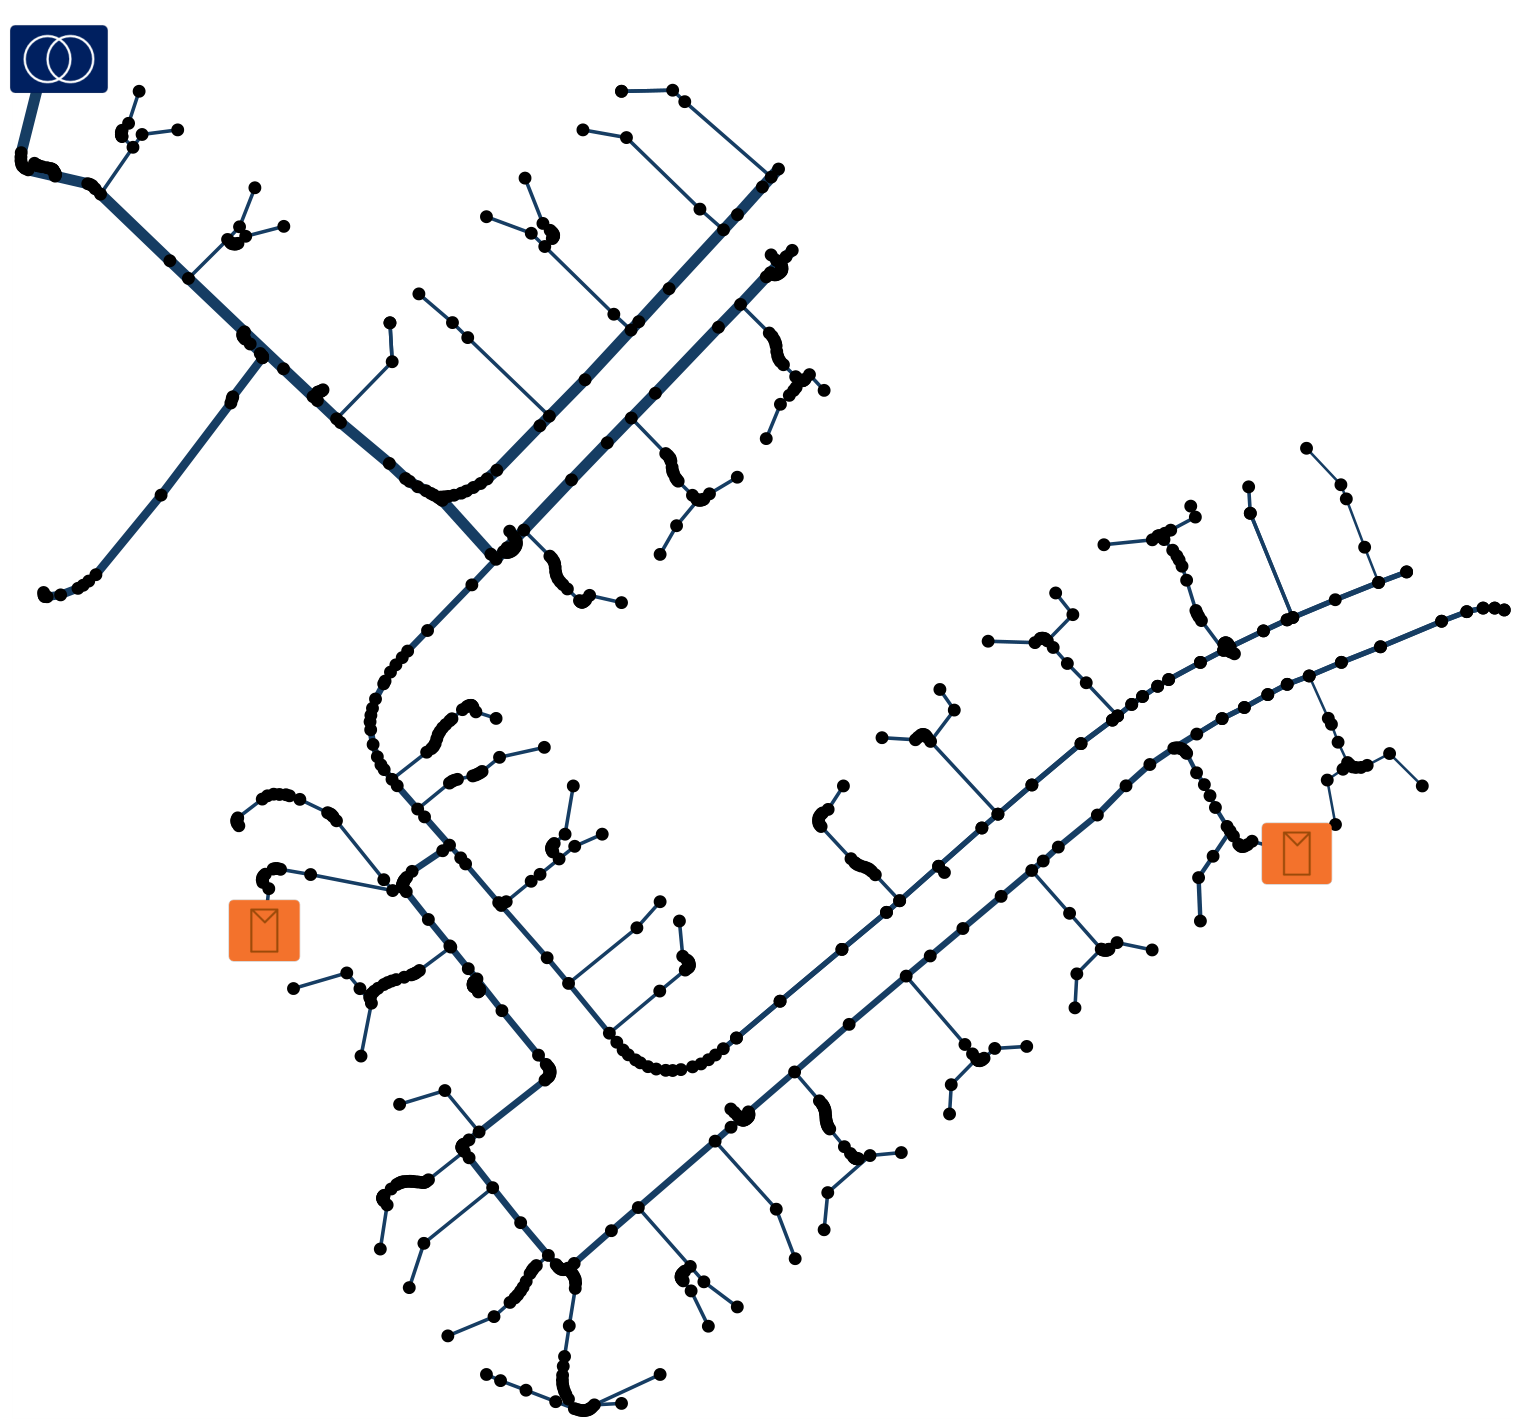

{'pdf': WindowsPath('C:/Users/alita/OneDrive/Desktop/GNN2/Figures/ieee906_pv_voltvar_topology.pdf'),
 'svg': WindowsPath('C:/Users/alita/OneDrive/Desktop/GNN2/Figures/ieee906_pv_voltvar_topology.svg'),
 'png': WindowsPath('C:/Users/alita/OneDrive/Desktop/GNN2/Figures/ieee906_pv_voltvar_topology.png')}

In [11]:
from __future__ import annotations

import importlib
import sys
from pathlib import Path

from IPython.display import Image, display

REPO = Path(r"C:\Users\alita\OneDrive\Desktop\GNN2").resolve()
if str(REPO) not in sys.path:
    sys.path.insert(0, str(REPO))

import plot_ieee906_feeder_topology as p906

p906 = importlib.reload(p906)

ICONS = REPO / "outputs" / "Icons"
MODEL = REPO / "906 bus system" / "LVTestCase_PV_voltvar"
OUT_DIR = REPO / "Figures"

# Global icon scale (all devices). Match prior 906 topology cell.
ICON_SIZE_SCALE = 3.6
# Transformer (substation.svg) absolute base zoom *before* ICON_SIZE_SCALE.
SUBSTATION_ICON_ZOOM = 0.22

paths = p906.plot_ieee906_feeder_topology(
    dss_dir=MODEL,
    out_dir=OUT_DIR,
    out_basename="ieee906_pv_voltvar_topology",
    style="paper",
    taper_line_width=False,  # ampacity widths (plain geographic)
    use_opendss_power=True,
    master_name="Master_snapshot_PV_voltvar.dss",
    node_color_mode="black",  # uniform black phase-node circles (all buses)
    # Soften edges slightly so black nodes stand out (default paper alpha=1.0).
    line_alpha=0.65,
    show_junctions=True,
    show_loads=True,
    show_device_icons=True,
    device_icon_paths={
        "substation": ICONS / "substation.svg",
        # Same orange PV icon as IEEE 8500 paper topology (DEFAULT_PAPER_ICON_FILES["pv"]).
        "controllable_pv": ICONS / "autonomous pv.svg",
        "pv": ICONS / "autonomous pv.svg",
    },
    device_icon_zooms={"substation": SUBSTATION_ICON_ZOOM},
    vector_svg_icons=True,
    svg_to_pdf=True,
    reload_icons=True,
    icon_size_scale=ICON_SIZE_SCALE,
    crop_margins=True,
    show_legend=False,
    show_title=False,
    png_dpi=2600,
    show=False,  # preview finalized PDF below (icons embedded)
)

for fmt, p in paths.items():
    print(f"{fmt.upper()}: {p}")

try:
    import fitz  # pymupdf

    doc = fitz.open(paths["pdf"])
    pix = doc[0].get_pixmap(matrix=fitz.Matrix(2.0, 2.0), alpha=False)
    preview = paths["pdf"].with_name(paths["pdf"].stem + "_preview.png")
    pix.save(preview)
    print("PREVIEW:", preview)
    display(Image(filename=str(preview)))
except Exception as e:
    print("Could not rasterize PDF for inline preview:", e)
    print("Open the SVG/PDF on disk to see device icons.")

paths


# IEEE 906 LVTestCase + **2 Volt-Var PVs** — chunked dataset with **fixed controller initialization**

Same spacing / scenario rules as the stock 906 chunked generator (`906.ipynb`), but:

- Feeder = `906 bus system/LVTestCase_PV_voltvar/` (stock `IEEETestCases/LVTestCase` untouched)
- Controllers = **InvControl** Volt-Var on **PV906** @ `906.1` and **PV458** @ `458.3`
- `ControlMode=STATIC` so inverters settle each snapshot
- **fixedctrlinit**: before every `Solve`, reset each PV to `PF=1 kvar=0` (shared start), then Static settle — no within-scenario InvControl Q carry-over (analogous to 8500 TapNumber=0 / CapControl OFF)

**Save location:**

| | Path |
|--|------|
| Stock 906 (no PV) | .../datasets_gnn2/original_906_lvtestcase_chunked |
| **This run** | .../datasets_gnn2/original_906_lvtestcase_pv_voltvar_fixedctrlinit |

Parent is auto-picked as the `datasets_gnn2` that already holds the stock 906 folder when present (H: / K: / Colab Drive / local).

| Knob | Value |
|------|-------|
| Scenarios x samples | 2000 x 40 (or smoke 4 x 8) |
| Chunk size | 50 scenarios |
| Time bins | load/pv/net = 3, include_anchors=True |
| Load/PV scale ranges | [0.3, 1.8] |
| sigma_load / sigma_pv | 0.5 |
| PV nameplate | 2 x 12 kW Pmpp / 15 kVA |
| Node PE | k=8 from static edges |
| Meta | real `pv_pv906_*` / `pv_pv458_*` P/Q post-solve + dummy 8500 reg/cap cols |

### Fixed vs free
| | Fixed (this cell) | Free / carry-over |
|--|-------------------|-------------------|
| InvControl Q init | reset `kvar=0` every sample | prior sample Q carries within scenario |
| Controllers present | yes (Static Volt-Var) | yes (if `fixed_controller_init=False`) |
| Load/PV scales & times | random as usual | same |

**Resume:** the gen cell skips finished `run_*` folders (`SKIP_COMPLETE_CHUNKS=True`).
If generation stopped mid-chunk (common: huge `*_mvagg.csv` write to Drive), re-run the
same cell — complete chunks are skipped; incomplete ones (truncated mvagg / leftover raw) are redone.


In [ ]:
# ============================================================
# CHUNKED RUN: 906 + 2 Volt-Var PVs + fixed controller init
# Feeder: LVTestCase_PV_voltvar (PV906, PV458 InvControl)
# Reset: Edit PVSystem.* PF=1 kvar=0 before each Solve, then Static.
#
# Resume: SKIP_COMPLETE_CHUNKS=True skips finished run_* folders so a
# re-run continues after a Drive/OOM interrupt (e.g. after run_001..N).
# ============================================================
import os
import math
import time
from pathlib import Path

# ---------------- user controls ----------------
SMOKE_TEST = False  # True = tiny run to verify paths / OpenDSS; False = full dataset
USE_PV_VOLTVAR = True
FIXED_CONTROLLER_INIT = True  # ONLY behavioral change vs autonomous carry-over
SKIP_COMPLETE_CHUNKS = True  # resume: do not redo finished run_* dirs
START_CHUNK = 1  # 1-based; set >1 to force-start later (still respects SKIP)

TOTAL_SCENARIOS = 2000
N_SAMPLES_PER_SCENARIO = 40
SCENARIOS_PER_CHUNK = 50
BASE_SEED = 90630230

SIGMA_LOAD = 0.5
SIGMA_PV = 0.5

# Nominal: 55 x 1 kW @ PF 0.95  →  P≈55 kW, Q≈18.08 kvar
P_LOAD_MEAN_KW = 55.0
Q_LOAD_MEAN_KVAR = 18.077625784837476
P_LOAD_SCALE_RANGE = (0.3, 1.8)
Q_LOAD_SCALE_RANGE = (0.3, 1.8)
# Nameplate sum = 24 kW (2 x 12 kW Pmpp); scale scenario total around that
P_PV_SCALE_RANGE = (0.3, 1.8)

VMIN_SAFE_PU = 0.55
VMAX_SAFE_PU = 1.45

NODE_PE_K = 8
NODE_PE_SEED = 42
NODE_PE_ZERO_EIG_TOL = 1e-8

RETURN_NODE_DF = False
WRITE_MVAGG_COMPAT = True
DELETE_RAW_NODE_CSV_AFTER_MVAGG = True  # training only needs *_mvagg.csv

# Complete-chunk heuristic: mvagg must be >= this fraction of a known-good size (~392 MB).
_MIN_MVAGG_BYTES = int(350 * 1024 * 1024)


if SMOKE_TEST:
    TOTAL_SCENARIOS = 4
    N_SAMPLES_PER_SCENARIO = 8
    SCENARIOS_PER_CHUNK = 2
    _MIN_MVAGG_BYTES = 1
    print("SMOKE_TEST=True → TOTAL_SCENARIOS=4, N_SAMPLES_PER_SCENARIO=8, SCENARIOS_PER_CHUNK=2")

# Same parent directory as the stock 906 chunked dataset; different folder name only.
# Previous:  .../datasets_gnn2/original_906_lvtestcase_chunked
# This run:  .../datasets_gnn2/original_906_lvtestcase_pv_voltvar_fixedctrlinit
_PREV_NAME = "original_906_lvtestcase_chunked"
_CHUNK_NAME = "original_906_lvtestcase_pv_voltvar_fixedctrlinit"
_PARENT_CANDIDATES = [
    Path(r"H:\My Drive\datasets_gnn2"),
    Path(r"K:\My Drive\datasets_gnn2"),
    Path("/content/drive/MyDrive/datasets_gnn2"),
    Path(r"C:\Users\alita\OneDrive\Desktop\GNN2\datasets_gnn2"),
    Path(r"D:\datasets"),
]

CANDIDATES = [
    r"C:\Users\alita\OneDrive\Desktop\GNN2",
    "/content/GNN-Sandia",
    "/content/GNN2",
    os.getcwd(),
]

script_path = None
_REPO = None
for root in CANDIDATES:
    p = os.path.join(root, "run_original_style_dataset_906_lvtestcase.py")
    if os.path.isfile(p):
        script_path = os.path.abspath(p)
        _REPO = os.path.abspath(root)
        break

if script_path is None:
    raise FileNotFoundError("run_original_style_dataset_906_lvtestcase.py not found in candidates.")

# Prefer the parent that already holds the previous stock 906 dataset folder.
DATASETS_GNN2 = next(
    (p for p in _PARENT_CANDIDATES if (p / _PREV_NAME).is_dir()),
    next((p for p in _PARENT_CANDIDATES if p.is_dir()), _PARENT_CANDIDATES[0]),
)
CHUNK_ROOT = DATASETS_GNN2 / _CHUNK_NAME
CHUNK_ROOT.mkdir(parents=True, exist_ok=True)
print("PREVIOUS (stock 906) dataset:", DATASETS_GNN2 / _PREV_NAME, flush=True)
print("THIS dataset:                ", CHUNK_ROOT, flush=True)

os.chdir(_REPO)
print("CWD:", os.getcwd(), flush=True)
print("SCRIPT:", script_path, flush=True)
print("USE_PV_VOLTVAR:", USE_PV_VOLTVAR, flush=True)
print("FIXED_CONTROLLER_INIT:", FIXED_CONTROLLER_INIT, flush=True)
print("SKIP_COMPLETE_CHUNKS:", SKIP_COMPLETE_CHUNKS, flush=True)

ns = {"__name__": "run_original_style_dataset_906_lvtestcase", "__file__": script_path}
exec(open(script_path, encoding="utf-8").read(), ns)

# ---------------- preflight ----------------
model_pv = ns["MODEL_DIR_PV"]
pv_dss = model_pv / "PV_voltvar_906.dss"
print("MODEL_DIR_PV:", model_pv, flush=True)
print("PV_voltvar_906.dss exists:", pv_dss.is_file(), flush=True)
if not pv_dss.is_file():
    raise FileNotFoundError(f"Missing PV add-on DSS: {pv_dss}")
irr = ns["IRR_CSV"]
print("IRR_CSV exists:", irr.is_file(), irr, flush=True)
if not irr.is_file():
    raise FileNotFoundError(f"Missing irradiance CSV: {irr}")
prof = ns["PROFILE_DIR"]
print("PROFILE_DIR (stock 1-min loads):", prof, "exists:", prof.is_dir(), flush=True)
if not prof.is_dir():
    raise FileNotFoundError(f"Missing stock Daily_1min_100profiles: {prof}")


def _count_csv_data_rows(path: Path) -> int:
    if not path.is_file():
        return 0
    with open(path, "r", encoding="utf-8", errors="replace") as f:
        n = sum(1 for _ in f)
    return max(0, n - 1)


def _chunk_looks_complete(out_dir: Path, *, n_scenarios_expected: int) -> bool:
    """True if this run_* has usable artifacts (skip on resume)."""
    meta = out_dir / "gnn_sample_meta.csv"
    mvagg = out_dir / "gnn_node_features_and_targets_mvagg.csv"
    edges = out_dir / "gnn_edges_phase_static.csv"
    index = out_dir / "gnn_node_index_master.csv"
    raw = out_dir / "gnn_node_features_and_targets.csv"
    if not all(p.is_file() for p in (meta, mvagg, edges, index)):
        return False
    n_meta = _count_csv_data_rows(meta)
    # Expect ~40 samples/scenario; allow some skip_ctrl loss but require most kept.
    min_samples = max(1, int(0.85 * n_scenarios_expected * N_SAMPLES_PER_SCENARIO))
    if n_meta < min_samples:
        print(
            f"[resume] incomplete meta rows={n_meta} < {min_samples} in {out_dir.name}",
            flush=True,
        )
        return False
    try:
        mv_sz = mvagg.stat().st_size
    except OSError:
        return False
    if mv_sz < _MIN_MVAGG_BYTES:
        print(
            f"[resume] truncated mvagg size={mv_sz} < {_MIN_MVAGG_BYTES} in {out_dir.name}",
            flush=True,
        )
        return False
    # Leftover raw after a good mvagg is OK (failed Drive unlink) — clean and skip.
    # Truncated mid-write: undersized mvagg already rejected above.
    if raw.is_file() and DELETE_RAW_NODE_CSV_AFTER_MVAGG:
        try:
            raw.unlink()
            print(f"[resume] removed leftover raw in {out_dir.name}", flush=True)
        except OSError as exc:
            print(f"[resume] leftover raw in {out_dir.name} (leave it): {exc}", flush=True)
    return True


n_chunks = math.ceil(TOTAL_SCENARIOS / SCENARIOS_PER_CHUNK)
print(f"\nTotal chunks: {n_chunks} | SMOKE_TEST={SMOKE_TEST}", flush=True)
print(f"P_LOAD_MEAN_KW={P_LOAD_MEAN_KW}  Q_LOAD_MEAN_KVAR={Q_LOAD_MEAN_KVAR}", flush=True)
print(f"P_PV_SCALE_RANGE={P_PV_SCALE_RANGE}  (nameplate ~24 kW)", flush=True)

n_skipped = 0
n_ran = 0
n_failed = 0
t_all0 = time.time()

for chunk_idx in range(n_chunks):
    chunk_num = chunk_idx + 1
    if chunk_num < int(START_CHUNK):
        print(f"[resume] skip chunk {chunk_num}/{n_chunks} (before START_CHUNK={START_CHUNK})", flush=True)
        n_skipped += 1
        continue

    s0 = chunk_idx * SCENARIOS_PER_CHUNK
    n_this = min(SCENARIOS_PER_CHUNK, TOTAL_SCENARIOS - s0)
    chunk_seed = int(BASE_SEED + 100003 * (chunk_idx + 1))
    out_dir = CHUNK_ROOT / f"run_{chunk_idx+1:03d}_scen_{s0:04d}_{s0+n_this-1:04d}_seed_{chunk_seed}"
    out_dir.mkdir(parents=True, exist_ok=True)

    if SKIP_COMPLETE_CHUNKS and _chunk_looks_complete(out_dir, n_scenarios_expected=n_this):
        print(
            f"\n=== Chunk {chunk_num}/{n_chunks} SKIP (complete) ===\n"
            f"OUT_DIR: {out_dir}",
            flush=True,
        )
        n_skipped += 1
        continue

    ns["OUT_DIR"] = out_dir
    ns["EDGE_CSV"] = out_dir / "gnn_edges_phase_static.csv"
    ns["NODE_CSV"] = out_dir / "gnn_node_features_and_targets.csv"
    ns["SAMPLE_CSV"] = out_dir / "gnn_sample_meta.csv"
    ns["NODE_INDEX_CSV"] = out_dir / "gnn_node_index_master.csv"
    ns["MVAGG_CSV"] = out_dir / "gnn_node_features_and_targets_mvagg.csv"

    print(f"\n=== Chunk {chunk_num}/{n_chunks} START ===", flush=True)
    print(f"Scenarios in chunk: {n_this}", flush=True)
    print(f"Seed: {chunk_seed}", flush=True)
    print(f"OUT_DIR: {out_dir}", flush=True)
    print(
        f"[progress] previously skipped={n_skipped} ran={n_ran} failed={n_failed} "
        f"elapsed_min={(time.time()-t_all0)/60:.1f}",
        flush=True,
    )

    gen_kw = dict(
        n_scenarios=int(n_this),
        k_snapshots_per_scenario_total=int(N_SAMPLES_PER_SCENARIO),
        bins_by_profile={"load": 3, "pv": 3, "net": 3},
        include_anchors=True,
        master_seed=int(chunk_seed),
        sigma_load=float(SIGMA_LOAD),
        sigma_pv=float(SIGMA_PV),
        p_load_mean_kw=float(P_LOAD_MEAN_KW),
        q_load_mean_kvar=float(Q_LOAD_MEAN_KVAR),
        p_load_scale_range=tuple(P_LOAD_SCALE_RANGE),
        q_load_scale_range=tuple(Q_LOAD_SCALE_RANGE),
        p_pv_scale_range=tuple(P_PV_SCALE_RANGE),
        vmin_safe_pu=float(VMIN_SAFE_PU),
        vmax_safe_pu=float(VMAX_SAFE_PU),
        include_source_in_safe_band=False,
        return_node_df=bool(RETURN_NODE_DF),
        node_pe_k=int(NODE_PE_K),
        node_pe_seed=int(NODE_PE_SEED),
        node_pe_zero_eig_tol=float(NODE_PE_ZERO_EIG_TOL),
        write_mvagg_compat=bool(WRITE_MVAGG_COMPAT),
        delete_raw_node_csv_after_mvagg=bool(DELETE_RAW_NODE_CSV_AFTER_MVAGG),
        use_pv_voltvar=bool(USE_PV_VOLTVAR),
        fixed_controller_init=bool(FIXED_CONTROLLER_INIT),
    )

    t0 = time.time()
    try:
        df_sample, df_node = ns["generate_original_style_dataset_906_lvtestcase"](**gen_kw)
    except Exception as exc:
        n_failed += 1
        print(
            f"[ERROR] Chunk {chunk_num}/{n_chunks} FAILED after {(time.time()-t0)/60:.1f} min: "
            f"{type(exc).__name__}: {exc}",
            flush=True,
        )
        raise

    dt = time.time() - t0
    n_kept = int(df_sample["sample_id"].nunique()) if len(df_sample) else 0
    n_ran += 1
    print(
        f"=== Chunk {chunk_num}/{n_chunks} DONE in {dt/60:.1f} min | "
        f"kept samples: {n_kept} | rows sample_meta: {len(df_sample)} ===",
        flush=True,
    )
    if len(df_sample) and "fixed_controller_init" in df_sample.columns:
        print(
            "fixed_controller_init column:",
            sorted(df_sample["fixed_controller_init"].astype(int).unique().tolist()),
            flush=True,
        )
    pv_cols = [c for c in df_sample.columns if c.startswith("pv_pv")]
    if pv_cols:
        print("PV meta cols:", pv_cols, flush=True)
    print("Saved:", flush=True)
    print(" -", ns["NODE_INDEX_CSV"], flush=True)
    print(" -", ns["EDGE_CSV"], flush=True)
    print(" -", ns["SAMPLE_CSV"], flush=True)
    if not DELETE_RAW_NODE_CSV_AFTER_MVAGG:
        print(" -", ns["NODE_CSV"], flush=True)
    print(" -", ns["MVAGG_CSV"], flush=True)
    remaining = n_chunks - chunk_num
    print(
        f"[progress] after chunk {chunk_num}: skipped={n_skipped} ran={n_ran} "
        f"failed={n_failed} remaining={remaining} "
        f"elapsed_min={(time.time()-t_all0)/60:.1f}",
        flush=True,
    )

print("\nAll chunks finished.", flush=True)
print(
    f"Summary: skipped={n_skipped} ran={n_ran} failed={n_failed} "
    f"total_elapsed_min={(time.time()-t_all0)/60:.1f}",
    flush=True,
)
print("Next: set DA-GPS CHUNK_PARENT to:", CHUNK_ROOT, flush=True)


PREVIOUS (stock 906) dataset: K:\My Drive\datasets_gnn2\original_906_lvtestcase_chunked
THIS dataset:                 K:\My Drive\datasets_gnn2\original_906_lvtestcase_pv_voltvar_fixedctrlinit
CWD: C:\Users\alita\OneDrive\Desktop\GNN2
SCRIPT: C:\Users\alita\OneDrive\Desktop\GNN2\run_original_style_dataset_906_lvtestcase.py
USE_PV_VOLTVAR: True
FIXED_CONTROLLER_INIT: True
MODEL_DIR_PV: C:\Users\alita\OneDrive\Desktop\GNN2\906 bus system\LVTestCase_PV_voltvar
PV_voltvar_906.dss exists: True
IRR_CSV exists: True C:\Users\alita\OneDrive\Desktop\GNN2\906 bus system\LVTestCase_PV_voltvar\irr_day_001.csv
PROFILE_DIR (stock 1-min loads): C:\Users\alita\OneDrive\Desktop\GNN2\906 bus system\OpenDSS-master\OpenDSS-master\Distrib\IEEETestCases\LVTestCase\Daily_1min_100profiles exists: True

Total chunks: 40 | SMOKE_TEST=False
P_LOAD_MEAN_KW=55.0  Q_LOAD_MEAN_KVAR=18.077625784837476
P_PV_SCALE_RANGE=(0.3, 1.8)  (nameplate ~24 kW)

=== Chunk 1/40 ===
Scenarios in chunk: 50
Seed: 90730233
OUT_DIR: K:

<string>:451: DtypeWarning: Columns (1,3) have mixed types. Specify dtype option on import or set low_memory=False.


[diag] wrote compat mvagg (identity, no aggregation): K:\My Drive\datasets_gnn2\original_906_lvtestcase_pv_voltvar_fixedctrlinit\run_001_scen_0000_0049_seed_90730233\gnn_node_features_and_targets_mvagg.csv
[diag] deleted raw node CSV: gnn_node_features_and_targets.csv

[ORIGINAL-STYLE 906 LVTESTCASE DATASET] saved.
  out_dir: K:\My Drive\datasets_gnn2\original_906_lvtestcase_pv_voltvar_fixedctrlinit\run_001_scen_0000_0049_seed_90730233
  use_pv_voltvar: True
  fixed_controller_init: True
  sample_meta: K:\My Drive\datasets_gnn2\original_906_lvtestcase_pv_voltvar_fixedctrlinit\run_001_scen_0000_0049_seed_90730233\gnn_sample_meta.csv
  node_features_targets: (deleted after mvagg)
  mvagg: K:\My Drive\datasets_gnn2\original_906_lvtestcase_pv_voltvar_fixedctrlinit\run_001_scen_0000_0049_seed_90730233\gnn_node_features_and_targets_mvagg.csv
  kept samples: 2000
  skipped_nonconv=0 skipped_badV=0 skipped_ctrl=0
  safe_band=[0.550, 1.450] total_v_outside_safe_band=0
  node_rows_written=544200

<string>:451: DtypeWarning: Columns (1,3) have mixed types. Specify dtype option on import or set low_memory=False.


[diag] wrote compat mvagg (identity, no aggregation): K:\My Drive\datasets_gnn2\original_906_lvtestcase_pv_voltvar_fixedctrlinit\run_002_scen_0050_0099_seed_90830236\gnn_node_features_and_targets_mvagg.csv
[diag] deleted raw node CSV: gnn_node_features_and_targets.csv

[ORIGINAL-STYLE 906 LVTESTCASE DATASET] saved.
  out_dir: K:\My Drive\datasets_gnn2\original_906_lvtestcase_pv_voltvar_fixedctrlinit\run_002_scen_0050_0099_seed_90830236
  use_pv_voltvar: True
  fixed_controller_init: True
  sample_meta: K:\My Drive\datasets_gnn2\original_906_lvtestcase_pv_voltvar_fixedctrlinit\run_002_scen_0050_0099_seed_90830236\gnn_sample_meta.csv
  node_features_targets: (deleted after mvagg)
  mvagg: K:\My Drive\datasets_gnn2\original_906_lvtestcase_pv_voltvar_fixedctrlinit\run_002_scen_0050_0099_seed_90830236\gnn_node_features_and_targets_mvagg.csv
  kept samples: 2000
  skipped_nonconv=0 skipped_badV=0 skipped_ctrl=0
  safe_band=[0.550, 1.450] total_v_outside_safe_band=0
  node_rows_written=544200

<string>:451: DtypeWarning: Columns (1,3) have mixed types. Specify dtype option on import or set low_memory=False.


# IEEE 34-bus Mirzaei + **fixed controller initialization** — chunked dataset

Same spacing / scenario rules as `original_ieee34_mirzaei_chunked`, but:

- Feeder = `new dss from dr mirzaei/IEEE34_PV.dss`
- Controllers = **RegControl** (rega1–3, regb1–3), fixed caps **C844/C848**, **InvControl** Volt-Var on **PV850** @ 850 (PV860 @ 860 unity PF)
- `ControlMode=STATIC` so regulators / InvControl settle each snapshot
- **fixedctrlinit**: before every `Solve`, reset RegControl `TapNumber=0`, fixed caps ON, PV `PF=1 kvar=0`, then Static settle — no within-scenario tap / InvControl Q carry-over (same idea as 8500 / 906)

**Save location (same parent, different folder name):**

| | Path |
|--|------|
| Previous (free / carry-over) | .../datasets_gnn2/original_ieee34_mirzaei_chunked |
| **This run** | .../datasets_gnn2/original_ieee34_mirzaei_chunked_fixedctrlinit |

Parent is auto-picked as the `datasets_gnn2` that already holds the previous Mirzaei folder when present (H: / K: / Colab Drive / local). Distinct from draft/yedges variants (`*_draft_yzip_*`, `*_yedges`).

| Knob | Value |
|------|-------|
| Scenarios × samples | 2000 × 40 (or smoke 4 × 8) |
| Chunk size | 50 scenarios |
| Time bins | load/pv/net = 3, include_anchors=True |
| Load/PV scale ranges | [0.95, 1.05] (match Mirzaei chunked) |
| sigma_load / sigma_pv | 0.02 |
| ZIP models | randomized per scenario (`randomize_zip_models=True`) |
| Node PE | k=8 from static edges |
| Meta | real `pv_pv850_*` / `pv_pv860_*`, native reg taps / cap kvar + dummy 8500 TARGET_* cols |

### Fixed vs free
| | Fixed (this cell) | Free / carry-over (`original_ieee34_mirzaei_chunked`) |
|--|-------------------|------------------------------------------------------|
| Reg / InvControl init | reset every sample then Static | prior sample state carries within scenario |
| Controllers present | yes (Static) | yes (Static) |
| Load/PV scales & times | random as usual | same |

**Resume:** the gen cell skips finished `run_*` folders (`SKIP_COMPLETE_CHUNKS=True`).
Re-run after Drive interrupts — complete chunks are skipped; incomplete ones (truncated mvagg / leftover raw) are redone.


In [4]:
# ============================================================
# CHUNKED RUN: IEEE34 Mirzaei + fixed controller init
# Feeder: IEEE34_PV.dss (RegControl + InvControl PV850 Volt-Var + PV860 unity)
# Reset: TapNumber=0, fixed caps ON, PV PF=1 kvar=0 before each Solve, then Static.
#
# Resume: SKIP_COMPLETE_CHUNKS=True skips finished run_* folders so a
# re-run continues after a Drive interrupt.
# ============================================================
import os
import math
import time
from pathlib import Path

# ---------------- user controls ----------------
SMOKE_TEST = False  # True = tiny run to verify paths / OpenDSS; False = full dataset
FIXED_CONTROLLER_INIT = True  # ONLY behavioral change vs mirzaei_chunked carry-over
SKIP_COMPLETE_CHUNKS = True  # resume: do not redo finished run_* dirs
START_CHUNK = 1  # 1-based; set >1 to force-start later (still respects SKIP)
RANDOMIZE_ZIP_MODELS = True
CONTROL_MODE = "static"

TOTAL_SCENARIOS = 2000
N_SAMPLES_PER_SCENARIO = 40
SCENARIOS_PER_CHUNK = 50
BASE_SEED = 3420230  # run_001 seed = BASE + 100003 → 3520233 (match mirzaei_chunked)

SIGMA_LOAD = 0.02
SIGMA_PV = 0.02

P_LOAD_SCALE_RANGE = (0.95, 1.05)
Q_LOAD_SCALE_RANGE = (0.95, 1.05)
P_PV_SCALE_RANGE = (0.95, 1.05)

VMIN_SAFE_PU = 0.85
VMAX_SAFE_PU = 1.10

NODE_PE_K = 8
NODE_PE_SEED = 42
NODE_PE_ZERO_EIG_TOL = 1e-8

RETURN_NODE_DF = False
WRITE_MVAGG_COMPAT = True
DELETE_RAW_NODE_CSV_AFTER_MVAGG = True  # write mvagg directly; training only needs *_mvagg.csv

# Complete-chunk heuristic: mvagg must be >= this fraction of a known-good size (~16 MB).
_MIN_MVAGG_BYTES = int(10 * 1024 * 1024)


if SMOKE_TEST:
    TOTAL_SCENARIOS = 4
    N_SAMPLES_PER_SCENARIO = 8
    SCENARIOS_PER_CHUNK = 2
    _MIN_MVAGG_BYTES = 1
    print("SMOKE_TEST=True → TOTAL_SCENARIOS=4, N_SAMPLES_PER_SCENARIO=8, SCENARIOS_PER_CHUNK=2")

# Same parent directory as the stock Mirzaei chunked dataset; different folder name only.
# Previous:  .../datasets_gnn2/original_ieee34_mirzaei_chunked
# This run:  .../datasets_gnn2/original_ieee34_mirzaei_chunked_fixedctrlinit
_PREV_NAME = "original_ieee34_mirzaei_chunked"
_CHUNK_NAME = _PREV_NAME + "_fixedctrlinit"
_PARENT_CANDIDATES = [
    Path(r"H:\My Drive\datasets_gnn2"),
    Path(r"K:\My Drive\datasets_gnn2"),
    Path("/content/drive/MyDrive/datasets_gnn2"),
    Path(r"C:\Users\alita\OneDrive\Desktop\GNN2\datasets_gnn2"),
    Path(r"D:\datasets"),
]

CANDIDATES = [
    r"C:\Users\alita\OneDrive\Desktop\GNN2",
    "/content/GNN-Sandia",
    "/content/GNN2",
    os.getcwd(),
]

script_path = None
_REPO = None
for root in CANDIDATES:
    p = os.path.join(root, "run_original_style_dataset_ieee34_mirzaei.py")
    if os.path.isfile(p):
        script_path = os.path.abspath(p)
        _REPO = os.path.abspath(root)
        break

if script_path is None:
    raise FileNotFoundError("run_original_style_dataset_ieee34_mirzaei.py not found in candidates.")

# Prefer the parent that already holds the previous Mirzaei dataset folder.
DATASETS_GNN2 = next(
    (p for p in _PARENT_CANDIDATES if (p / _PREV_NAME).is_dir()),
    next((p for p in _PARENT_CANDIDATES if p.is_dir()), _PARENT_CANDIDATES[0]),
)
CHUNK_ROOT = DATASETS_GNN2 / _CHUNK_NAME
CHUNK_ROOT.mkdir(parents=True, exist_ok=True)
print("PREVIOUS (free / carry-over) dataset:", DATASETS_GNN2 / _PREV_NAME, flush=True)
print("THIS dataset:                        ", CHUNK_ROOT, flush=True)

os.chdir(_REPO)
print("CWD:", os.getcwd(), flush=True)
print("SCRIPT:", script_path, flush=True)
print("FIXED_CONTROLLER_INIT:", FIXED_CONTROLLER_INIT, flush=True)
print("SKIP_COMPLETE_CHUNKS:", SKIP_COMPLETE_CHUNKS, flush=True)
print("CONTROL_MODE:", CONTROL_MODE, flush=True)
print("RANDOMIZE_ZIP_MODELS:", RANDOMIZE_ZIP_MODELS, flush=True)

ns = {"__name__": "run_original_style_dataset_ieee34_mirzaei", "__file__": script_path}
exec(open(script_path, encoding="utf-8").read(), ns)

# ---------------- preflight ----------------
dss_file = ns["DSS_FILE"]
print("DSS_FILE:", dss_file, flush=True)
print("DSS exists:", Path(dss_file).is_file(), flush=True)
if not Path(dss_file).is_file():
    raise FileNotFoundError(f"Missing Mirzaei DSS: {dss_file}")


def _count_csv_data_rows(path: Path) -> int:
    if not path.is_file():
        return 0
    with open(path, "r", encoding="utf-8", errors="replace") as f:
        n = sum(1 for _ in f)
    return max(0, n - 1)


def _chunk_looks_complete(out_dir: Path, *, n_scenarios_expected: int) -> bool:
    """True if this run_* has usable artifacts (skip on resume)."""
    meta = out_dir / "gnn_sample_meta.csv"
    mvagg = out_dir / "gnn_node_features_and_targets_mvagg.csv"
    edges = out_dir / "gnn_edges_phase_static.csv"
    index = out_dir / "gnn_node_index_master.csv"
    raw = out_dir / "gnn_node_features_and_targets.csv"
    if not all(p.is_file() for p in (meta, mvagg, edges, index)):
        return False
    n_meta = _count_csv_data_rows(meta)
    min_samples = max(1, int(0.85 * n_scenarios_expected * N_SAMPLES_PER_SCENARIO))
    if n_meta < min_samples:
        print(
            f"[resume] incomplete meta rows={n_meta} < {min_samples} in {out_dir.name}",
            flush=True,
        )
        return False
    try:
        mv_sz = mvagg.stat().st_size
    except OSError:
        return False
    if mv_sz < _MIN_MVAGG_BYTES:
        print(
            f"[resume] truncated mvagg size={mv_sz} < {_MIN_MVAGG_BYTES} in {out_dir.name}",
            flush=True,
        )
        return False
    if raw.is_file() and DELETE_RAW_NODE_CSV_AFTER_MVAGG:
        try:
            raw.unlink()
            print(f"[resume] removed leftover raw in {out_dir.name}", flush=True)
        except OSError as exc:
            print(f"[resume] leftover raw in {out_dir.name} (leave it): {exc}", flush=True)
    return True


n_chunks = math.ceil(TOTAL_SCENARIOS / SCENARIOS_PER_CHUNK)
print(f"\nTotal chunks: {n_chunks} | SMOKE_TEST={SMOKE_TEST}", flush=True)
print(f"P_LOAD_SCALE_RANGE={P_LOAD_SCALE_RANGE}  P_PV_SCALE_RANGE={P_PV_SCALE_RANGE}", flush=True)
print(f"SIGMA_LOAD={SIGMA_LOAD}  SIGMA_PV={SIGMA_PV}", flush=True)

n_skipped = 0
n_ran = 0
n_failed = 0
t_all0 = time.time()

for chunk_idx in range(n_chunks):
    chunk_num = chunk_idx + 1
    if chunk_num < int(START_CHUNK):
        print(f"[resume] skip chunk {chunk_num}/{n_chunks} (before START_CHUNK={START_CHUNK})", flush=True)
        n_skipped += 1
        continue

    s0 = chunk_idx * SCENARIOS_PER_CHUNK
    n_this = min(SCENARIOS_PER_CHUNK, TOTAL_SCENARIOS - s0)
    chunk_seed = int(BASE_SEED + 100003 * (chunk_idx + 1))
    out_dir = CHUNK_ROOT / f"run_{chunk_idx+1:03d}_scen_{s0:04d}_{s0+n_this-1:04d}_seed_{chunk_seed}"
    out_dir.mkdir(parents=True, exist_ok=True)

    if SKIP_COMPLETE_CHUNKS and _chunk_looks_complete(out_dir, n_scenarios_expected=n_this):
        print(
            f"\n=== Chunk {chunk_num}/{n_chunks} SKIP (complete) ===\n"
            f"OUT_DIR: {out_dir}",
            flush=True,
        )
        n_skipped += 1
        continue

    ns["OUT_DIR"] = out_dir
    ns["EDGE_CSV"] = out_dir / "gnn_edges_phase_static.csv"
    ns["NODE_CSV"] = out_dir / "gnn_node_features_and_targets.csv"
    ns["SAMPLE_CSV"] = out_dir / "gnn_sample_meta.csv"
    ns["NODE_INDEX_CSV"] = out_dir / "gnn_node_index_master.csv"
    ns["MVAGG_CSV"] = out_dir / "gnn_node_features_and_targets_mvagg.csv"

    print(f"\n=== Chunk {chunk_num}/{n_chunks} START ===", flush=True)
    print(f"Scenarios in chunk: {n_this}", flush=True)
    print(f"Seed: {chunk_seed}", flush=True)
    print(f"OUT_DIR: {out_dir}", flush=True)
    print(
        f"[progress] previously skipped={n_skipped} ran={n_ran} failed={n_failed} "
        f"elapsed_min={(time.time()-t_all0)/60:.1f}",
        flush=True,
    )

    gen_kw = dict(
        n_scenarios=int(n_this),
        k_snapshots_per_scenario_total=int(N_SAMPLES_PER_SCENARIO),
        bins_by_profile={"load": 3, "pv": 3, "net": 3},
        include_anchors=True,
        master_seed=int(chunk_seed),
        sigma_load=float(SIGMA_LOAD),
        sigma_pv=float(SIGMA_PV),
        p_load_scale_range=tuple(P_LOAD_SCALE_RANGE),
        q_load_scale_range=tuple(Q_LOAD_SCALE_RANGE),
        p_pv_scale_range=tuple(P_PV_SCALE_RANGE),
        vmin_safe_pu=float(VMIN_SAFE_PU),
        vmax_safe_pu=float(VMAX_SAFE_PU),
        include_source_in_safe_band=False,
        return_node_df=bool(RETURN_NODE_DF),
        node_pe_k=int(NODE_PE_K),
        node_pe_seed=int(NODE_PE_SEED),
        node_pe_zero_eig_tol=float(NODE_PE_ZERO_EIG_TOL),
        write_mvagg_compat=bool(WRITE_MVAGG_COMPAT),
        delete_raw_node_csv_after_mvagg=bool(DELETE_RAW_NODE_CSV_AFTER_MVAGG),
        control_mode=str(CONTROL_MODE),
        randomize_zip_models=bool(RANDOMIZE_ZIP_MODELS),
        fixed_controller_init=bool(FIXED_CONTROLLER_INIT),
    )

    t0 = time.time()
    try:
        df_sample, df_node = ns["generate_original_style_dataset_ieee34_mirzaei"](**gen_kw)
    except Exception as exc:
        n_failed += 1
        print(
            f"[ERROR] Chunk {chunk_num}/{n_chunks} FAILED after {(time.time()-t0)/60:.1f} min: "
            f"{type(exc).__name__}: {exc}",
            flush=True,
        )
        raise

    dt = time.time() - t0
    n_kept = int(df_sample["sample_id"].nunique()) if len(df_sample) else 0
    n_ran += 1
    print(
        f"=== Chunk {chunk_num}/{n_chunks} DONE in {dt/60:.1f} min | "
        f"kept samples: {n_kept} | rows sample_meta: {len(df_sample)} ===",
        flush=True,
    )
    if len(df_sample) and "fixed_controller_init" in df_sample.columns:
        print(
            "fixed_controller_init column:",
            sorted(df_sample["fixed_controller_init"].astype(int).unique().tolist()),
            flush=True,
        )
    pv_cols = [c for c in df_sample.columns if c.startswith("pv_pv")]
    if pv_cols:
        print("PV meta cols:", pv_cols, flush=True)
    print("Saved:", flush=True)
    print(" -", ns["NODE_INDEX_CSV"], flush=True)
    print(" -", ns["EDGE_CSV"], flush=True)
    print(" -", ns["SAMPLE_CSV"], flush=True)
    if not DELETE_RAW_NODE_CSV_AFTER_MVAGG:
        print(" -", ns["NODE_CSV"], flush=True)
    print(" -", ns["MVAGG_CSV"], flush=True)
    remaining = n_chunks - chunk_num
    print(
        f"[progress] after chunk {chunk_num}: skipped={n_skipped} ran={n_ran} "
        f"failed={n_failed} remaining={remaining} "
        f"elapsed_min={(time.time()-t_all0)/60:.1f}",
        flush=True,
    )

print("\nAll chunks finished.", flush=True)
print(
    f"Summary: skipped={n_skipped} ran={n_ran} failed={n_failed} "
    f"total_elapsed_min={(time.time()-t_all0)/60:.1f}",
    flush=True,
)
print("Next: set DA-GPS CHUNK_PARENT to:", CHUNK_ROOT, flush=True)


PREVIOUS (free / carry-over) dataset: K:\My Drive\datasets_gnn2\original_ieee34_mirzaei_chunked
THIS dataset:                         K:\My Drive\datasets_gnn2\original_ieee34_mirzaei_chunked_fixedctrlinit
CWD: C:\Users\alita\OneDrive\Desktop\GNN2
SCRIPT: C:\Users\alita\OneDrive\Desktop\GNN2\run_original_style_dataset_ieee34_mirzaei.py
FIXED_CONTROLLER_INIT: True
SKIP_COMPLETE_CHUNKS: True
CONTROL_MODE: static
RANDOMIZE_ZIP_MODELS: True
DSS_FILE: C:\Users\alita\OneDrive\Desktop\GNN2\new dss from dr mirzaei\IEEE34_PV.dss
DSS exists: True

Total chunks: 40 | SMOKE_TEST=False
P_LOAD_SCALE_RANGE=(0.95, 1.05)  P_PV_SCALE_RANGE=(0.95, 1.05)
SIGMA_LOAD=0.02  SIGMA_PV=0.02

=== Chunk 1/40 START ===
Scenarios in chunk: 50
Seed: 3520233
OUT_DIR: K:\My Drive\datasets_gnn2\original_ieee34_mirzaei_chunked_fixedctrlinit\run_001_scen_0000_0049_seed_3520233
[progress] previously skipped=0 ran=0 failed=0 elapsed_min=0.0
[DSS] maxcontroliter=20000
[ieee34] nodes_all=95 nodes_graph=89 control_mode=static

### Train 8500 ablations on fixedctrlinit + draft Y-edges

**Yes — redo these** so ablations match the new main CCE model (same labels + Y-edges).

Same two controlled variants as `906.ipynb` cells 43 / 45, but data / cache / run tags use **`fixedctrlinit_yedges`**:

| Ablation | What changes | What stays fixed |
|---|---|---|
| **volt_only** | `lambda_cap=lambda_reg=lambda_pv=0` (voltage loss only); early stop on voltage | Full token architecture + same cache/features as CCE |
| **full_node_attn** | `--global_attn_mode full_node` (node↔node attn replaces node↔token channel); batch=4 + grad checkpoint | Same aux λ=0.1, GINE local path, tokens still feed cap/reg/meta heads |

**Data:** `original_8500_unbalanced_chunked_no_bess_new_diverse_2000_40_fixedctrlinit_yedges`

**Run after:** Y-edge stamp + mvagg (or let each train cell auto-build missing mvagg). Main CCE cell (above) is optional but recommended first so caches exist.

Do **not** delete older ohm / warm-start-yedges ablation runs — these are new sibling runs.


In [ ]:
# --- Ablation A: DA-GPS without auxiliary losses (volt_only) ---
# Data / caches / path resolution matched to the fixedctrlinit_yedges CCE train cell.
# Arch: h=96, L=2, heads=2, node_emb=4, reg_loss=ce (same as shipped CCE).
# ============================================================
from __future__ import annotations

import datetime
import os
import subprocess
import sys
import warnings
from pathlib import Path

CHUNK_NAME = "original_8500_unbalanced_chunked_no_bess_new_diverse_2000_40_fixedctrlinit_yedges"

DRIVE_ROOT = Path("/content/drive")
MYDRIVE_DATA = DRIVE_ROOT / "MyDrive/datasets_gnn2"
COLAB_CHUNK_DEFAULT = MYDRIVE_DATA / CHUNK_NAME
WIN_CHUNK_CANDIDATES = [
    Path(r"H:\My Drive\datasets_gnn2") / CHUNK_NAME,
    Path(r"K:\My Drive\datasets_gnn2") / CHUNK_NAME,
    Path(r"D:\datasets") / CHUNK_NAME,
]


def _is_windows_drive_path(path) -> bool:
    s = str(path).strip().replace("/", "\\")
    return len(s) >= 2 and s[1] == ":" and s[0].isalpha()


def _on_colab() -> bool:
    try:
        import google.colab  # noqa: F401

        return True
    except ImportError:
        return False


def _drive_mounted() -> bool:
    return DRIVE_ROOT.is_dir() and (DRIVE_ROOT / "MyDrive").is_dir()


def _find_repo() -> Path:
    mod = "train_da_gps_multitask_complex_voltage_gine.py"
    cands: list[Path] = []
    env = os.environ.get("GNN2_REPO_ROOT", "").strip()
    if env:
        cands.append(Path(env))
    cwd = Path.cwd().resolve()
    cands.append(cwd)
    cands.extend(cwd.parents)
    cands.extend(
        [
            Path(r"C:\Users\alita\OneDrive\Desktop\GNN2"),
            Path("/content/GNN-Sandia"),
            Path("/content/GNN2"),
        ]
    )
    seen: set[Path] = set()
    for root in cands:
        root = Path(root).expanduser().resolve()
        if root in seen or not root.exists():
            continue
        seen.add(root)
        if (root / mod).is_file():
            return root
    raise FileNotFoundError(f"Could not find {mod}. Set GNN2_REPO_ROOT or cd into the repo.")


def _resolve_data_path(path: Path, *, label: str, colab_fallback: Path | None = None) -> Path:
    raw = str(path)
    if _is_windows_drive_path(raw):
        if _on_colab() and colab_fallback is not None:
            warnings.warn(
                f"{label}={raw!r} is a Windows path on Linux/Colab; using {colab_fallback} instead.",
                UserWarning,
                stacklevel=2,
            )
            return colab_fallback.expanduser().resolve()
        if _on_colab():
            raise ValueError(
                f"{label}={raw!r} is a Windows absolute path and invalid on Colab. "
                f"Mount Drive and use e.g. {COLAB_CHUNK_DEFAULT}"
            )
        return Path(raw).expanduser().resolve()
    p = Path(path).expanduser()
    if p.is_absolute():
        return p.resolve()
    return (Path.cwd() / p).resolve()


def _find_node_pe_csv(chunk_parent: Path) -> Path:
    hits = sorted(chunk_parent.glob("run_*/gnn_node_index_master.csv"))
    if not hits:
        raise FileNotFoundError(f"No run_*/gnn_node_index_master.csv under {chunk_parent}")
    return hits[0]


def _smoke_chunk_subdir_glob(chunk_parent: Path, smoke_count: int) -> str:
    runs = sorted(
        (p for p in chunk_parent.iterdir() if p.is_dir() and p.name.startswith("run_")),
        key=lambda p: p.name,
    )
    if len(runs) < smoke_count:
        raise ValueError(f"Need >= {smoke_count} run_* under {chunk_parent}, found {len(runs)}")
    kept = runs[:smoke_count]
    print(f"SMOKE: keeping first {smoke_count} chunks: {[p.name for p in kept]}")
    return ",".join(p.name for p in kept)


def _ensure_mvagg_under(chunk_parent: Path, repo: Path) -> None:
    """Old ..._2000_40 already had mvagg; fixedctrlinit gen omitted it. Build if missing."""
    runs = sorted(p for p in chunk_parent.iterdir() if p.is_dir() and p.name.startswith("run_"))
    missing = [
        rd for rd in runs
        if not (rd / "gnn_node_features_and_targets_mvagg.csv").is_file()
    ]
    if not missing:
        return
    print(f"[mvagg] {len(missing)}/{len(runs)} chunks missing mvagg; building …")
    import re
    import urllib.request
    import json as _json
    import pandas as pd

    tx = repo / "8500 nodes with solar unbalanced" / "LoadXfmrs.dss"
    if not tx.is_file():
        tx.parent.mkdir(parents=True, exist_ok=True)
        api = (
            "https://api.github.com/repos/alitasavori/GNN-Sandia/contents/"
            "8500%20nodes%20with%20solar%20unbalanced"
        )
        req = urllib.request.Request(api, headers={"User-Agent": "GNN-Sandia"})
        for item in _json.load(urllib.request.urlopen(req)):
            if item.get("type") != "file" or not item.get("download_url"):
                continue
            dest = tx.parent / item["name"]
            if dest.is_file():
                continue
            print("[mvagg] dl", item["name"])
            dest.write_bytes(urllib.request.urlopen(item["download_url"]).read())
    if not tx.is_file():
        raise FileNotFoundError(f"Need {tx} to build mvagg")

    def _tok(s: str) -> str:
        return str(s).strip().lower()

    def _bus_base(s: str) -> str:
        return _tok(s).split(".")[0]

    wdg_re = re.compile(r"wdg=(\d+)\s+bus=([^\s]+)", re.I)
    rows: list[tuple[str, str]] = []
    for line in tx.read_text(encoding="utf-8", errors="ignore").splitlines():
        s = line.strip()
        if not s.lower().startswith("new transformer."):
            continue
        w = {int(k): _tok(v) for k, v in wdg_re.findall(s)}
        if not (1 in w and 2 in w and 3 in w):
            continue
        x2, x3 = _bus_base(w[2]), _bus_base(w[3])
        if not (x2.startswith("x") and x3.startswith("x")):
            continue
        for sx in {_tok("s" + x2), _tok("s" + x3)}:
            rows.append((w[1], sx))
    map_long = pd.DataFrame(rows, columns=["mv_node", "sx_bus"]).drop_duplicates()
    print(f"[mvagg] building under {chunk_parent} (map={len(map_long)} rows)")

    for i, rd in enumerate(runs, 1):
        out = rd / "gnn_node_features_and_targets_mvagg.csv"
        raw = rd / "gnn_node_features_and_targets.csv"
        idx = rd / "gnn_node_index_master.csv"
        if out.is_file():
            continue
        if not raw.is_file() or not idx.is_file():
            raise FileNotFoundError(f"Missing raw/index for mvagg in {rd}")
        df = pd.read_csv(raw)
        allowed = set(pd.read_csv(idx, usecols=["node"])["node"].astype(str).str.strip().str.lower())
        df["node_lc"] = df["node"].astype(str).str.strip().str.lower()
        df["bus"] = df["node_lc"].str.split(".").str[0]
        sx = df[df["bus"].str.startswith("sx")][["sample_id", "bus", "p_load_kw", "q_load_kvar"]].rename(
            columns={"bus": "sx_bus"}
        )
        mv_agg = (
            sx.merge(map_long, on="sx_bus", how="inner")
            .groupby(["sample_id", "mv_node"], as_index=False)[["p_load_kw", "q_load_kvar"]]
            .sum()
            .rename(columns={"p_load_kw": "p_a", "q_load_kvar": "q_a"})
        )
        df2 = df[~(df["bus"].str.startswith("x") | df["bus"].str.startswith("sx"))].copy()
        df2 = df2[df2["node_lc"].isin(allowed)].copy()
        df2["p_load_kw"] = 0.0
        df2["q_load_kvar"] = 0.0
        df2 = df2.merge(
            mv_agg, left_on=["sample_id", "node_lc"], right_on=["sample_id", "mv_node"], how="left"
        )
        hit = df2["p_a"].notna()
        df2.loc[hit, "p_load_kw"] = df2.loc[hit, "p_a"]
        df2.loc[hit, "q_load_kvar"] = df2.loc[hit, "q_a"]
        df2.drop(
            columns=[c for c in ["node_lc", "bus", "mv_node", "p_a", "q_a"] if c in df2.columns],
            inplace=True,
        )
        if "p_bess_kw" in df2.columns:
            df2["p_load_kw"] = df2["p_load_kw"].astype(float) + df2["p_bess_kw"].fillna(0.0).astype(float)
            df2["q_load_kvar"] = df2["q_load_kvar"].astype(float) + df2["q_bess_kvar"].fillna(0.0).astype(
                float
            )
            df2.drop(columns=["p_bess_kw", "q_bess_kvar"], inplace=True, errors="ignore")
        df2.to_csv(out, index=False)
        print(f"[mvagg] [{i}/{len(runs)}] {rd.name} rows={len(df2)}")
    print("[mvagg] done")


if _on_colab() and not _drive_mounted():
    from google.colab import drive

    drive.mount("/content/drive")

# --- smoke / full-run toggles ---
SMOKE_TEST = False
SMOKE_CHUNK_COUNT = 3
SMOKE_EPOCHS = 15
SMOKE_PATIENCE = 5
SMOKE_SEED = 42

# Same tensor cache family as fixedctrlinit_yedges CCE (labels differ from warm-start yedges)
_DA_CACHE_NAME = (
    "da_gps_chunked_mvagg_fixedctrlinit_yedges_smoke_gine"
    if SMOKE_TEST
    else "da_gps_chunked_mvagg_fixedctrlinit_yedges_full_gine"
)
_GNN_CACHE_NAME = "gnn_only_chunked_mvagg_fixedctrlinit_yedges_full_gine"

# --- CCE architecture (from training_last.pt) ---
CCE_HIDDEN = 96
CCE_LAYERS = 2
CCE_HEADS = 2
CCE_NODE_EMB_DIM = 4
META_AUX_COLS = "pv_pv2_p_post_kw,pv_pv2_q_post_kvar,P_loss_total_post_kw,Q_loss_total_post_kvar"
NUM_WORKERS = 0 if os.name == "nt" else 4

# Voltage-only: keep aux columns / heads / tokens so the architecture + cache match CCE,
# but do not train regulator / capacitor / DER / system-level auxiliary losses.
BATCH_SIZE = 64
LAMBDA_CAP = "0"
LAMBDA_REG = "0"
LAMBDA_PV = "0"
GLOBAL_ATTN_MODE = "tokens"
EARLY_STOP_ON = "voltage"
USE_GRAD_CHECKPOINT = False
VARIANT_TAG = "volt_only"
PREFLIGHT_LABEL = "DA-GPS ablation: volt_only + fixedctrlinit_yedges"

REPO = _find_repo()
os.chdir(REPO)
sys.path.insert(0, str(REPO))
os.environ["PYTHONUNBUFFERED"] = "1"
os.environ["GNN2_REPO_ROOT"] = str(REPO)

if _on_colab():
    if not _drive_mounted():
        raise RuntimeError("Colab requires Google Drive mounted.")
    CHUNK_PARENT = COLAB_CHUNK_DEFAULT
    DA_CACHE_ROOT = MYDRIVE_DATA / f"cache/{_DA_CACHE_NAME}"
    GNN_CACHE_ROOT = MYDRIVE_DATA / f"cache/{_GNN_CACHE_NAME}"
    RUNS_PARENT = MYDRIVE_DATA / "runs"
elif os.name == "nt":
    CHUNK_PARENT = next((p for p in WIN_CHUNK_CANDIDATES if p.is_dir()), WIN_CHUNK_CANDIDATES[0])
    DA_CACHE_ROOT = REPO / f"datasets_gnn2_from pc/cache/{_DA_CACHE_NAME}"
    GNN_CACHE_ROOT = REPO / f"datasets_gnn2_from pc/cache/{_GNN_CACHE_NAME}"
    RUNS_PARENT = REPO / "datasets_gnn2_from pc/runs"
else:
    CHUNK_PARENT = REPO / f"datasets_gnn2_from pc/{CHUNK_NAME}"
    DA_CACHE_ROOT = REPO / f"datasets_gnn2_from pc/cache/{_DA_CACHE_NAME}"
    GNN_CACHE_ROOT = REPO / f"datasets_gnn2_from pc/cache/{_GNN_CACHE_NAME}"
    RUNS_PARENT = REPO / "datasets_gnn2_from pc/runs"

_colab_fb = COLAB_CHUNK_DEFAULT if _on_colab() else None
chunk_parent = _resolve_data_path(CHUNK_PARENT, label="CHUNK_PARENT", colab_fallback=_colab_fb)
if SMOKE_TEST:
    CHUNK_GLOB = _smoke_chunk_subdir_glob(chunk_parent, SMOKE_CHUNK_COUNT)
    EPOCHS = SMOKE_EPOCHS
    PATIENCE = SMOKE_PATIENCE
else:
    CHUNK_GLOB = "run_*"
    EPOCHS = 200
    PATIENCE = 30

da_cache_root = _resolve_data_path(
    DA_CACHE_ROOT,
    label="DA_CACHE_ROOT",
    colab_fallback=MYDRIVE_DATA / f"cache/{_DA_CACHE_NAME}" if _on_colab() else None,
)
gnn_cache_root = _resolve_data_path(
    GNN_CACHE_ROOT,
    label="GNN_CACHE_ROOT",
    colab_fallback=MYDRIVE_DATA / f"cache/{_GNN_CACHE_NAME}" if _on_colab() else None,
)
runs_parent = _resolve_data_path(
    RUNS_PARENT,
    label="RUNS_PARENT",
    colab_fallback=MYDRIVE_DATA / "runs" if _on_colab() else None,
)

if not chunk_parent.is_dir():
    raise FileNotFoundError(
        f"CHUNK_PARENT not found:\n  {chunk_parent}\n"
        "Finish the Y-edge stamp cell first (creates *_fixedctrlinit_yedges)."
    )

_ensure_mvagg_under(chunk_parent, REPO)
node_pe = _find_node_pe_csv(chunk_parent)
runs_parent.mkdir(parents=True, exist_ok=True)
da_cache_root.mkdir(parents=True, exist_ok=True)

print(f"=== Preflight ({PREFLIGHT_LABEL}) ===")
print(f"REPO:              {REPO}")
print(f"VARIANT:           fixedctrlinit_yedges_{VARIANT_TAG}")
print(f"global_attn_mode:  {GLOBAL_ATTN_MODE}")
print(f"lambda_cap/reg/pv: {LAMBDA_CAP}/{LAMBDA_REG}/{LAMBDA_PV}")
print(f"arch:              h={CCE_HIDDEN} L={CCE_LAYERS} heads={CCE_HEADS} node_emb={CCE_NODE_EMB_DIM}")
print(f"batch_size:        {BATCH_SIZE}")
print(f"early_stop_on:     {EARLY_STOP_ON}")
print(f"SMOKE_TEST:        {SMOKE_TEST}")
print(f"CHUNK_PARENT:      {chunk_parent}")
print(f"DA_CACHE_ROOT:     {da_cache_root}")
print(f"GNN_CACHE_ROOT:    {gnn_cache_root}")
print(f"node_pe_csv:       {node_pe}")

tag = datetime.datetime.now().strftime("%Y%m%d_%H%M%S")
out_dir = runs_parent / (
    f"da_gps_fixedctrlinit_yedges_l{CCE_LAYERS}_h{CCE_HIDDEN}_mvagg_gine_{VARIANT_TAG}"
    f"{'_smoke' if SMOKE_TEST else ''}_{tag}"
)
out_dir.mkdir(parents=True, exist_ok=True)

cmd = [
    sys.executable, "-u", "train_da_gps_multitask_complex_voltage_gine.py",
    "--chunk_parent", str(chunk_parent),
    "--chunk_subdir_glob", CHUNK_GLOB,
    "--nodes_csv", "gnn_node_features_and_targets_mvagg.csv",
    "--edge_catalog_csv", "gnn_edges_phase_static.csv",
    "--meta_csv", "gnn_sample_meta.csv",
    "--node_feature_cols", "p_load_kw,q_load_kvar,p_pv_kw",
    "--exclude_bess_features",
    "--node_pe_csv", str(node_pe),
    "--node_pe_cols", "auto",
    "--n_system_tokens", "10",
    "--aux_meta_cols", META_AUX_COLS,
    "--lambda_pv", LAMBDA_PV,
    "--out_dir", str(out_dir),
    "--cache_dir", str(da_cache_root),
    "--bootstrap_gnn_cache_dir", str(gnn_cache_root),
    "--epochs", str(EPOCHS),
    "--batch_size", str(BATCH_SIZE),
    "--hidden", str(CCE_HIDDEN),
    "--layers", str(CCE_LAYERS),
    "--heads", str(CCE_HEADS),
    "--node_emb_dim", str(CCE_NODE_EMB_DIM),
    "--edge_emb_dim", "0",
    "--lr", "5e-4",
    "--weight_decay", "1e-5",
    "--lambda_cap", LAMBDA_CAP,
    "--lambda_reg", LAMBDA_REG,
    "--reg_loss", "ce",
    "--per_device_cap_head",
    "--per_device_reg_head",
    "--global_attn_mode", GLOBAL_ATTN_MODE,
    "--patience", str(PATIENCE),
    "--seed", str(SMOKE_SEED),
    "--train_frac", "0.80",
    "--val_frac", "0.10",
    "--sample_frac", "1.0",
    "--num_workers", str(NUM_WORKERS),
    "--log_every", "10",
    "--checkpoint_every", "10",
    "--early_stop_on", EARLY_STOP_ON,
    "--dropout", "0.1",
]
if USE_GRAD_CHECKPOINT:
    cmd.append("--gradient_checkpointing")

print("\nRunning:\n ", " ".join(cmd), "\n", flush=True)

with subprocess.Popen(
    cmd,
    cwd=str(REPO),
    stdout=subprocess.PIPE,
    stderr=subprocess.STDOUT,
    bufsize=1,
    text=True,
    encoding="utf-8",
    errors="replace",
) as proc:
    assert proc.stdout is not None
    for line in proc.stdout:
        print(line, end="")
    rc = proc.wait()

if rc != 0:
    raise subprocess.CalledProcessError(rc, cmd)

print("\nTraining completed.")
print("Run dir:", out_dir.resolve())
print("Checkpoint (best):", (out_dir / "da_gps_multitask_best.pt").resolve())
print("Checkpoint (last):", (out_dir / "training_last.pt").resolve())
print("Report:", (out_dir / "da_gps_report.json").resolve())


=== Preflight (DA-GPS ablation: volt_only + fixedctrlinit_yedges) ===
REPO:              /content/GNN-Sandia
VARIANT:           fixedctrlinit_yedges_volt_only
global_attn_mode:  tokens
lambda_cap/reg/pv: 0/0/0
arch:              h=96 L=2 heads=2 node_emb=4
batch_size:        64
early_stop_on:     voltage
SMOKE_TEST:        False
CHUNK_PARENT:      /content/drive/MyDrive/datasets_gnn2/original_8500_unbalanced_chunked_no_bess_new_diverse_2000_40_fixedctrlinit_yedges
DA_CACHE_ROOT:     /content/drive/MyDrive/datasets_gnn2/cache/da_gps_chunked_mvagg_fixedctrlinit_yedges_full_gine
GNN_CACHE_ROOT:    /content/drive/MyDrive/datasets_gnn2/cache/gnn_only_chunked_mvagg_fixedctrlinit_yedges_full_gine
node_pe_csv:       /content/drive/MyDrive/datasets_gnn2/original_8500_unbalanced_chunked_no_bess_new_diverse_2000_40_fixedctrlinit_yedges/run_001_scen_0000_0049_seed_20420233/gnn_node_index_master.csv

Running:
  /usr/bin/python3 -u train_da_gps_multitask_complex_voltage_gine.py --chunk_parent /content/drive/MyDrive/datasets_gnn2/original_8500_unbalanced_chunked_no_bess_new_diverse_2000_40_fixedctrlinit_yedges --chunk_subdir_glob run_* --nodes_csv gnn_node_features_and_targets_mvagg.csv --edge_catalog_csv gnn_edges_phase_static.csv --meta_csv gnn_sample_meta.csv --node_feature_cols p_load_kw,q_load_kvar,p_pv_kw --exclude_bess_features --node_pe_csv /content/drive/MyDrive/datasets_gnn2/original_8500_unbalanced_chunked_no_bess_new_diverse_2000_40_fixedctrlinit_yedges/run_001_scen_0000_0049_seed_20420233/gnn_node_index_master.csv --node_pe_cols auto --n_system_tokens 10 --aux_meta_cols pv_pv2_p_post_kw,pv_pv2_q_post_kvar,P_loss_total_post_kw,Q_loss_total_post_kvar --lambda_pv 0 --out_dir /content/drive/MyDrive/datasets_gnn2/runs/da_gps_fixedctrlinit_yedges_l2_h96_mvagg_gine_volt_only_20260912_023942 --cache_dir /content/drive/MyDrive/datasets_gnn2/cache/da_gps_chunked_mvagg_fixedctrlinit_yedges_full_gine --bootstrap_gnn_cache_dir /content/drive/MyDrive/datasets_gnn2/cache/gnn_only_chunked_mvagg_fixedctrlinit_yedges_full_gine --epochs 200 --batch_size 64 --hidden 96 --layers 2 --heads 2 --node_emb_dim 4 --edge_emb_dim 0 --lr 5e-4 --weight_decay 1e-5 --lambda_cap 0 --lambda_reg 0 --reg_loss ce --per_device_cap_head --per_device_reg_head --global_attn_mode tokens --patience 30 --seed 42 --train_frac 0.80 --val_frac 0.10 --sample_frac 1.0 --num_workers 4 --log_every 10 --checkpoint_every 10 --early_stop_on voltage --dropout 0.1 

regulator tap training loss: ce (discrete tap classes + cross-entropy)
exclude_bess_features: using node_feature_cols= ['p_load_kw', 'q_load_kvar', 'p_pv_kw']
chunk_parent cache override via --cache_dir: /content/drive/MyDrive/datasets_gnn2/cache/da_gps_chunked_mvagg_fixedctrlinit_yedges_full_gine
bootstrap GNN cache dir: /content/drive/MyDrive/datasets_gnn2/cache/gnn_only_chunked_mvagg_fixedctrlinit_yedges_full_gine
Token layout: n_cap=10 n_reg=12 n_system=10 (total=32); cap_cols=['cap_capbank0a_n_steps_on', 'cap_capbank0b_n_steps_on', 'cap_capbank0c_n_steps_on', 'cap_capbank1a_n_steps_on', 'cap_capbank1b_n_steps_on', 'cap_capbank1c_n_steps_on', 'cap_capbank2a_n_steps_on', 'cap_capbank2b_n_steps_on', 'cap_capbank2c_n_steps_on', 'cap_capbank3_n_steps_on']; reg_cols=['reg_feeder_rega_tap_pu', 'reg_feeder_regb_tap_pu', 'reg_feeder_regc_tap_pu', 'reg_vreg2_a_tap_pu', 'reg_vreg2_b_tap_pu', 'reg_vreg2_c_tap_pu', 'reg_vreg3_a_tap_pu', 'reg_vreg3_b_tap_pu', 'reg_vreg3_c_tap_pu', 'reg_vreg4_a_tap_pu', 'reg_vreg4_b_tap_pu', 'reg_vreg4_c_tap_pu']
Meta aux (sample_meta): 4 column(s); chunk DA caches use suffix __mauxb7bd1d58 (per chunk name).
  global token index 22 (system slot 0): column 'pv_pv2_p_post_kw'
  global token index 23 (system slot 1): column 'pv_pv2_q_post_kvar'
  global token index 24 (system slot 2): column 'p_loss_total_post_kw'
  global token index 25 (system slot 3): column 'q_loss_total_post_kvar'
[chunk_parent] 40 chunks under /content/drive/MyDrive/datasets_gnn2/original_8500_unbalanced_chunked_no_bess_new_diverse_2000_40_fixedctrlinit_yedges
  - run_001_scen_0000_0049_seed_20420233
  - run_002_scen_0050_0099_seed_20520236
  - run_003_scen_0100_0149_seed_20620239
  - run_004_scen_0150_0199_seed_20720242
  - run_005_scen_0200_0249_seed_20820245
  - run_006_scen_0250_0299_seed_20920248
  - run_007_scen_0300_0349_seed_21020251
  - run_008_scen_0350_0399_seed_21120254
  - run_009_scen_0400_0449_seed_21220257
  - run_010_scen_0450_0499_seed_21320260
  - run_011_scen_0500_0549_seed_21420263
  - run_012_scen_0550_0599_seed_21520266
  - run_013_scen_0600_0649_seed_21620269
  - run_014_scen_0650_0699_seed_21720272
  - run_015_scen_0700_0749_seed_21820275
  - run_016_scen_0750_0799_seed_21920278
  - run_017_scen_0800_0849_seed_22020281
  - run_018_scen_0850_0899_seed_22120284
  - run_019_scen_0900_0949_seed_22220287
  - run_020_scen_0950_0999_seed_22320290
  - run_021_scen_1000_1049_seed_22420293
  - run_022_scen_1050_1099_seed_22520296
  - run_023_scen_1100_1149_seed_22620299
  - run_024_scen_1150_1199_seed_22720302
  - run_025_scen_1200_1249_seed_22820305
  - run_026_scen_1250_1299_seed_22920308
  - run_027_scen_1300_1349_seed_23020311
  - run_028_scen_1350_1399_seed_23120314
  - run_029_scen_1400_1449_seed_23220317
  - run_030_scen_1450_1499_seed_23320320
  - run_031_scen_1500_1549_seed_23420323
  - run_032_scen_1550_1599_seed_23520326
  - run_033_scen_1600_1649_seed_23620329
  - run_034_scen_1650_1699_seed_23720332
  - run_035_scen_1700_1749_seed_23820335
  - run_036_scen_1750_1799_seed_23920338
  - run_037_scen_1800_1849_seed_24020341
  - run_038_scen_1850_1899_seed_24120344
  - run_039_scen_1900_1949_seed_24220347
  - run_040_scen_1950_1999_seed_24320350
reg_loss=ce: per-regulator tap classes (rounded unique tap_pu):
  reg_feeder_rega_tap_pu: n_classes=18
  reg_feeder_regb_tap_pu: n_classes=18
  reg_feeder_regc_tap_pu: n_classes=18
  reg_vreg2_a_tap_pu: n_classes=19
  reg_vreg2_b_tap_pu: n_classes=18
  reg_vreg2_c_tap_pu: n_classes=20
  reg_vreg3_a_tap_pu: n_classes=21
  reg_vreg3_b_tap_pu: n_classes=21
  reg_vreg3_c_tap_pu: n_classes=24
  reg_vreg4_a_tap_pu: n_classes=23
  reg_vreg4_b_tap_pu: n_classes=21
  reg_vreg4_c_tap_pu: n_classes=21
Loading compacted edges: /content/drive/MyDrive/datasets_gnn2/original_8500_unbalanced_chunked_no_bess_new_diverse_2000_40_fixedctrlinit_yedges/run_001_scen_0000_0049_seed_20420233/gnn_edges_phase_static.csv
  edge_attr: signed_log1p(|e|) applied (raw max|attr|=9.9e+04 > 500; after max|attr|=11.5)
  directed edges: 18872 (catalog=directed)
norm stats: computed from current train split
Wrote run manifest (for daily compare / mid-train snapshots): /content/drive/MyDrive/datasets_gnn2/runs/da_gps_fixedctrlinit_yedges_l2_h96_mvagg_gine_volt_only_20260912_023942/da_gps_run_manifest.json
device: cuda
model=gine: DA-GPS GINE + global_attn_mode=tokens (L=2, h=96, heads=2)
torch.compile: enabled
AMP (autocast + GradScaler): enabled
W0912 02:46:41.152000 6334 torch/_inductor/utils.py:1731] [0/0] Not enough SMs to use max_autotune_gemm mode
[da_gps chunk_parent] epoch    1/200 | train_tot=0.3500 train_volt=0.3500 train_cap=0.6984 train_reg=3.0804 train_meta_aux=1.0581 val_meta_aux=1.0436 | val_tot=0.0727 val_volt=0.0727 val_cap=0.7006 val_reg=3.0705 | val_r2_mean=0.7892 val_r2_min=-6.5775 val_r2_min_node=_hvmv_sub_lsb.2 val_worst_mae=0.0329 | best=0.0727 @ epoch 1 | epochs_since_best=0 patience=30 min_delta=0.0001
[da_gps chunk_parent]  cap_BCE train: cap_capbank0a_n_steps_on=0.6656  cap_capbank0b_n_steps_on=0.7698  cap_capbank0c_n_steps_on=0.6608  cap_capbank1a_n_steps_on=0.7007  cap_capbank1b_n_steps_on=0.6765  cap_capbank1c_n_steps_on=0.7039
[da_gps chunk_parent]  cap_BCE train: cap_capbank2a_n_steps_on=0.6749  cap_capbank2b_n_steps_on=0.7198  cap_capbank2c_n_steps_on=0.7089  cap_capbank3_n_steps_on=0.7027
[da_gps chunk_parent]  cap_BCE val: cap_capbank0a_n_steps_on=0.6621  cap_capbank0b_n_steps_on=0.7815  cap_capbank0c_n_steps_on=0.6526  cap_capbank1a_n_steps_on=0.7031  cap_capbank1b_n_steps_on=0.6779  cap_capbank1c_n_steps_on=0.7034
[da_gps chunk_parent]  cap_BCE val: cap_capbank2a_n_steps_on=0.6624  cap_capbank2b_n_steps_on=0.7433  cap_capbank2c_n_steps_on=0.7007  cap_capbank3_n_steps_on=0.7185
[da_gps chunk_parent]  reg_CE train: reg_feeder_rega_tap_pu=2.8030  reg_feeder_regb_tap_pu=3.0721  reg_feeder_regc_tap_pu=3.0991  reg_vreg2_a_tap_pu=3.0679  reg_vreg2_b_tap_pu=3.0562  reg_vreg2_c_tap_pu=2.8876
[da_gps chunk_parent]  reg_CE train: reg_vreg3_a_tap_pu=3.0719  reg_vreg3_b_tap_pu=3.0884  reg_vreg3_c_tap_pu=3.5122  reg_vreg4_a_tap_pu=3.1807  reg_vreg4_b_tap_pu=3.0957  reg_vreg4_c_tap_pu=3.0301
[da_gps chunk_parent]  reg_CE val: reg_feeder_rega_tap_pu=2.7766  reg_feeder_regb_tap_pu=3.0043  reg_feeder_regc_tap_pu=3.0898  reg_vreg2_a_tap_pu=3.0689  reg_vreg2_b_tap_pu=3.0344  reg_vreg2_c_tap_pu=2.8639
[da_gps chunk_parent]  reg_CE val: reg_vreg3_a_tap_pu=3.0988  reg_vreg3_b_tap_pu=3.0882  reg_vreg3_c_tap_pu=3.5355  reg_vreg4_a_tap_pu=3.1794  reg_vreg4_b_tap_pu=3.0840  reg_vreg4_c_tap_pu=3.0217
[da_gps chunk_parent]  meta_aux_MSE_nrm train: pv_pv2_p_post_kw=1.0273  pv_pv2_q_post_kvar=0.9774  p_loss_total_post_kw=1.0087  q_loss_total_post_kvar=1.2188
[da_gps chunk_parent]  meta_aux_MSE_nrm val: pv_pv2_p_post_kw=1.0431  pv_pv2_q_post_kvar=0.9082  p_loss_total_post_kw=1.0290  q_loss_total_post_kvar=1.1941

=== train_pool_eval (epoch 1) ===
Val  |V| MAE=0.006784  angle MAE=0.798348  Re/Im MSE(nrm)=0.072653  r2_mean=0.7662  r2_min=-6.2675  worst_mae=0.032929  tot=0.0727  volt=0.0727
Test  |V| MAE=0.006726  angle MAE=0.801130  Re/Im MSE(nrm)=0.072572  r2_mean=0.7759  r2_min=-6.5562  worst_mae=0.032770  tot=0.0726  volt=0.0726
[da_gps chunk_parent] epoch   10/200 | train_tot=0.0331 train_volt=0.0331 train_cap=0.7081 train_reg=3.1055 train_meta_aux=1.0539 val_meta_aux=1.0268 | val_tot=0.0316 val_volt=0.0316 val_cap=0.7101 val_reg=3.1048 | val_r2_mean=0.8883 val_r2_min=0.1935 val_r2_min_node=_hvmv_sub_lsb.2 val_worst_mae=0.0175 | best=0.0316 @ epoch 10 | epochs_since_best=0 patience=30 min_delta=0.0001
[da_gps chunk_parent]  cap_BCE train: cap_capbank0a_n_steps_on=0.6579  cap_capbank0b_n_steps_on=0.7976  cap_capbank0c_n_steps_on=0.6855  cap_capbank1a_n_steps_on=0.7149  cap_capbank1b_n_steps_on=0.6871  cap_capbank1c_n_steps_on=0.6950
[da_gps chunk_parent]  cap_BCE train: cap_capbank2a_n_steps_on=0.6658  cap_capbank2b_n_steps_on=0.7757  cap_capbank2c_n_steps_on=0.6888  cap_capbank3_n_steps_on=0.7126
[da_gps chunk_parent]  cap_BCE val: cap_capbank0a_n_steps_on=0.6562  cap_capbank0b_n_steps_on=0.8128  cap_capbank0c_n_steps_on=0.6846  cap_capbank1a_n_steps_on=0.7182  cap_capbank1b_n_steps_on=0.6828  cap_capbank1c_n_steps_on=0.6959
[da_gps chunk_parent]  cap_BCE val: cap_capbank2a_n_steps_on=0.6611  cap_capbank2b_n_steps_on=0.7969  cap_capbank2c_n_steps_on=0.6826  cap_capbank3_n_steps_on=0.7104
[da_gps chunk_parent]  reg_CE train: reg_feeder_rega_tap_pu=2.9005  reg_feeder_regb_tap_pu=2.9465  reg_feeder_regc_tap_pu=3.2070  reg_vreg2_a_tap_pu=3.0429  reg_vreg2_b_tap_pu=3.0527  reg_vreg2_c_tap_pu=2.8915
[da_gps chunk_parent]  reg_CE train: reg_vreg3_a_tap_pu=3.1237  reg_vreg3_b_tap_pu=3.1489  reg_vreg3_c_tap_pu=3.4727  reg_vreg4_a_tap_pu=3.1562  reg_vreg4_b_tap_pu=3.2068  reg_vreg4_c_tap_pu=3.1166
[da_gps chunk_parent]  reg_CE val: reg_feeder_rega_tap_pu=2.8995  reg_feeder_regb_tap_pu=2.9431  reg_feeder_regc_tap_pu=3.2165  reg_vreg2_a_tap_pu=3.0400  reg_vreg2_b_tap_pu=3.0593  reg_vreg2_c_tap_pu=2.8797
[da_gps chunk_parent]  reg_CE val: reg_vreg3_a_tap_pu=3.1269  reg_vreg3_b_tap_pu=3.1456  reg_vreg3_c_tap_pu=3.4757  reg_vreg4_a_tap_pu=3.1558  reg_vreg4_b_tap_pu=3.2042  reg_vreg4_c_tap_pu=3.1119
[da_gps chunk_parent]  meta_aux_MSE_nrm train: pv_pv2_p_post_kw=1.0751  pv_pv2_q_post_kvar=0.8746  p_loss_total_post_kw=1.0064  q_loss_total_post_kvar=1.2596
[da_gps chunk_parent]  meta_aux_MSE_nrm val: pv_pv2_p_post_kw=1.0742  pv_pv2_q_post_kvar=0.8266  p_loss_total_post_kw=0.9716  q_loss_total_post_kvar=1.2348

=== train_pool_eval (epoch 10) ===
Val  |V| MAE=0.004427  angle MAE=0.405872  Re/Im MSE(nrm)=0.031589  r2_mean=0.8807  r2_min=0.0784  worst_mae=0.017464  tot=0.0316  volt=0.0316
Test  |V| MAE=0.004389  angle MAE=0.399650  Re/Im MSE(nrm)=0.032172  r2_mean=0.8822  r2_min=0.0674  worst_mae=0.017225  tot=0.0322  volt=0.0322
  periodic checkpoint -> /content/drive/MyDrive/datasets_gnn2/runs/da_gps_fixedctrlinit_yedges_l2_h96_mvagg_gine_volt_only_20260912_023942/training_last.pt
[da_gps chunk_parent] epoch   20/200 | train_tot=0.0292 train_volt=0.0292 train_cap=0.7084 train_reg=3.1192 train_meta_aux=1.0521 val_meta_aux=1.0276 | val_tot=0.0284 val_volt=0.0284 val_cap=0.7089 val_reg=3.1176 | val_r2_mean=0.9076 val_r2_min=0.4069 val_r2_min_node=190-8593.3 val_worst_mae=0.0158 | best=0.0284 @ epoch 20 | epochs_since_best=0 patience=30 min_delta=0.0001
[da_gps chunk_parent]  cap_BCE train: cap_capbank0a_n_steps_on=0.6643  cap_capbank0b_n_steps_on=0.8008  cap_capbank0c_n_steps_on=0.6988  cap_capbank1a_n_steps_on=0.7100  cap_capbank1b_n_steps_on=0.6850  cap_capbank1c_n_steps_on=0.6938
[da_gps chunk_parent]  cap_BCE train: cap_capbank2a_n_steps_on=0.6567  cap_capbank2b_n_steps_on=0.7889  cap_capbank2c_n_steps_on=0.6832  cap_capbank3_n_steps_on=0.7024
[da_gps chunk_parent]  cap_BCE val: cap_capbank0a_n_steps_on=0.6620  cap_capbank0b_n_steps_on=0.8007  cap_capbank0c_n_steps_on=0.7031  cap_capbank1a_n_steps_on=0.7094  cap_capbank1b_n_steps_on=0.6837  cap_capbank1c_n_steps_on=0.6920
[da_gps chunk_parent]  cap_BCE val: cap_capbank2a_n_steps_on=0.6523  cap_capbank2b_n_steps_on=0.8025  cap_capbank2c_n_steps_on=0.6790  cap_capbank3_n_steps_on=0.7044
[da_gps chunk_parent]  reg_CE train: reg_feeder_rega_tap_pu=2.9089  reg_feeder_regb_tap_pu=3.0024  reg_feeder_regc_tap_pu=3.2537  reg_vreg2_a_tap_pu=3.0237  reg_vreg2_b_tap_pu=3.0372  reg_vreg2_c_tap_pu=2.9407
[da_gps chunk_parent]  reg_CE train: reg_vreg3_a_tap_pu=3.1287  reg_vreg3_b_tap_pu=3.1811  reg_vreg3_c_tap_pu=3.4197  reg_vreg4_a_tap_pu=3.1552  reg_vreg4_b_tap_pu=3.2252  reg_vreg4_c_tap_pu=3.1542
[da_gps chunk_parent]  reg_CE val: reg_feeder_rega_tap_pu=2.8915  reg_feeder_regb_tap_pu=2.9954  reg_feeder_regc_tap_pu=3.3153  reg_vreg2_a_tap_pu=3.0293  reg_vreg2_b_tap_pu=3.0237  reg_vreg2_c_tap_pu=2.9237
[da_gps chunk_parent]  reg_CE val: reg_vreg3_a_tap_pu=3.1314  reg_vreg3_b_tap_pu=3.1755  reg_vreg3_c_tap_pu=3.4193  reg_vreg4_a_tap_pu=3.1494  reg_vreg4_b_tap_pu=3.2151  reg_vreg4_c_tap_pu=3.1415
[da_gps chunk_parent]  meta_aux_MSE_nrm train: pv_pv2_p_post_kw=1.0857  pv_pv2_q_post_kvar=0.8411  p_loss_total_post_kw=1.0370  q_loss_total_post_kvar=1.2445
[da_gps chunk_parent]  meta_aux_MSE_nrm val: pv_pv2_p_post_kw=1.0775  pv_pv2_q_post_kvar=0.8016  p_loss_total_post_kw=0.9920  q_loss_total_post_kvar=1.2393

=== train_pool_eval (epoch 20) ===
Val  |V| MAE=0.004292  angle MAE=0.427931  Re/Im MSE(nrm)=0.028374  r2_mean=0.8932  r2_min=0.1389  worst_mae=0.015842  tot=0.0284  volt=0.0284
Test  |V| MAE=0.004250  angle MAE=0.421668  Re/Im MSE(nrm)=0.027971  r2_mean=0.8975  r2_min=0.1669  worst_mae=0.015597  tot=0.0280  volt=0.0280
  periodic checkpoint -> /content/drive/MyDrive/datasets_gnn2/runs/da_gps_fixedctrlinit_yedges_l2_h96_mvagg_gine_volt_only_20260912_023942/training_last.pt
[da_gps chunk_parent] epoch   30/200 | train_tot=0.0273 train_volt=0.0273 train_cap=0.7090 train_reg=3.1154 train_meta_aux=1.0395 val_meta_aux=1.0141 | val_tot=0.0259 val_volt=0.0259 val_cap=0.7110 val_reg=3.1115 | val_r2_mean=0.9132 val_r2_min=0.3974 val_r2_min_node=_hvmv_sub_lsb.2 val_worst_mae=0.0144 | best=0.0259 @ epoch 30 | epochs_since_best=0 patience=30 min_delta=0.0001
[da_gps chunk_parent]  cap_BCE train: cap_capbank0a_n_steps_on=0.6771  cap_capbank0b_n_steps_on=0.8013  cap_capbank0c_n_steps_on=0.6987  cap_capbank1a_n_steps_on=0.7048  cap_capbank1b_n_steps_on=0.6891  cap_capbank1c_n_steps_on=0.6934
[da_gps chunk_parent]  cap_BCE train: cap_capbank2a_n_steps_on=0.6580  cap_capbank2b_n_steps_on=0.7953  cap_capbank2c_n_steps_on=0.6772  cap_capbank3_n_steps_on=0.6954
[da_gps chunk_parent]  cap_BCE val: cap_capbank0a_n_steps_on=0.6766  cap_capbank0b_n_steps_on=0.8132  cap_capbank0c_n_steps_on=0.6988  cap_capbank1a_n_steps_on=0.7056  cap_capbank1b_n_steps_on=0.6909  cap_capbank1c_n_steps_on=0.6932
[da_gps chunk_parent]  cap_BCE val: cap_capbank2a_n_steps_on=0.6517  cap_capbank2b_n_steps_on=0.8134  cap_capbank2c_n_steps_on=0.6723  cap_capbank3_n_steps_on=0.6941
[da_gps chunk_parent]  reg_CE train: reg_feeder_rega_tap_pu=2.8750  reg_feeder_regb_tap_pu=3.0109  reg_feeder_regc_tap_pu=3.2381  reg_vreg2_a_tap_pu=3.0163  reg_vreg2_b_tap_pu=3.0023  reg_vreg2_c_tap_pu=2.9885
[da_gps chunk_parent]  reg_CE train: reg_vreg3_a_tap_pu=3.1296  reg_vreg3_b_tap_pu=3.1767  reg_vreg3_c_tap_pu=3.3929  reg_vreg4_a_tap_pu=3.1674  reg_vreg4_b_tap_pu=3.2077  reg_vreg4_c_tap_pu=3.1796
[da_gps chunk_parent]  reg_CE val: reg_feeder_rega_tap_pu=2.8516  reg_feeder_regb_tap_pu=3.0275  reg_feeder_regc_tap_pu=3.2441  reg_vreg2_a_tap_pu=3.0174  reg_vreg2_b_tap_pu=3.0011  reg_vreg2_c_tap_pu=2.9822
[da_gps chunk_parent]  reg_CE val: reg_vreg3_a_tap_pu=3.1241  reg_vreg3_b_tap_pu=3.1607  reg_vreg3_c_tap_pu=3.3938  reg_vreg4_a_tap_pu=3.1664  reg_vreg4_b_tap_pu=3.1875  reg_vreg4_c_tap_pu=3.1823
[da_gps chunk_parent]  meta_aux_MSE_nrm train: pv_pv2_p_post_kw=1.0631  pv_pv2_q_post_kvar=0.8138  p_loss_total_post_kw=1.0553  q_loss_total_post_kvar=1.2258
[da_gps chunk_parent]  meta_aux_MSE_nrm val: pv_pv2_p_post_kw=1.0585  pv_pv2_q_post_kvar=0.7622  p_loss_total_post_kw=1.0277  q_loss_total_post_kvar=1.2082

=== train_pool_eval (epoch 30) ===
Val  |V| MAE=0.004077  angle MAE=0.391470  Re/Im MSE(nrm)=0.025924  r2_mean=0.9008  r2_min=0.2065  worst_mae=0.014363  tot=0.0259  volt=0.0259
Test  |V| MAE=0.004026  angle MAE=0.386248  Re/Im MSE(nrm)=0.025436  r2_mean=0.9051  r2_min=0.2518  worst_mae=0.014175  tot=0.0254  volt=0.0254
  periodic checkpoint -> /content/drive/MyDrive/datasets_gnn2/runs/da_gps_fixedctrlinit_yedges_l2_h96_mvagg_gine_volt_only_20260912_023942/training_last.pt
[da_gps chunk_parent] epoch   40/200 | train_tot=0.0256 train_volt=0.0256 train_cap=0.7091 train_reg=3.1056 train_meta_aux=1.0281 val_meta_aux=1.0050 | val_tot=0.0282 val_volt=0.0282 val_cap=0.7101 val_reg=3.1044 | val_r2_mean=0.9109 val_r2_min=0.4035 val_r2_min_node=190-8593.3 val_worst_mae=0.0143 | best=0.0259 @ epoch 30 | epochs_since_best=10 patience=30 min_delta=0.0001
[da_gps chunk_parent]  cap_BCE train: cap_capbank0a_n_steps_on=0.6836  cap_capbank0b_n_steps_on=0.7996  cap_capbank0c_n_steps_on=0.6943  cap_capbank1a_n_steps_on=0.6996  cap_capbank1b_n_steps_on=0.6871  cap_capbank1c_n_steps_on=0.6921
[da_gps chunk_parent]  cap_BCE train: cap_capbank2a_n_steps_on=0.6629  cap_capbank2b_n_steps_on=0.7991  cap_capbank2c_n_steps_on=0.6736  cap_capbank3_n_steps_on=0.6986
[da_gps chunk_parent]  cap_BCE val: cap_capbank0a_n_steps_on=0.6832  cap_capbank0b_n_steps_on=0.8046  cap_capbank0c_n_steps_on=0.6995  cap_capbank1a_n_steps_on=0.6987  cap_capbank1b_n_steps_on=0.6850  cap_capbank1c_n_steps_on=0.6909
[da_gps chunk_parent]  cap_BCE val: cap_capbank2a_n_steps_on=0.6624  cap_capbank2b_n_steps_on=0.8094  cap_capbank2c_n_steps_on=0.6705  cap_capbank3_n_steps_on=0.6970
[da_gps chunk_parent]  reg_CE train: reg_feeder_rega_tap_pu=2.8696  reg_feeder_regb_tap_pu=3.0064  reg_feeder_regc_tap_pu=3.2032  reg_vreg2_a_tap_pu=3.0139  reg_vreg2_b_tap_pu=2.9969  reg_vreg2_c_tap_pu=3.0035
[da_gps chunk_parent]  reg_CE train: reg_vreg3_a_tap_pu=3.1168  reg_vreg3_b_tap_pu=3.1697  reg_vreg3_c_tap_pu=3.3749  reg_vreg4_a_tap_pu=3.1791  reg_vreg4_b_tap_pu=3.1705  reg_vreg4_c_tap_pu=3.1623
[da_gps chunk_parent]  reg_CE val: reg_feeder_rega_tap_pu=2.8599  reg_feeder_regb_tap_pu=3.0049  reg_feeder_regc_tap_pu=3.2105  reg_vreg2_a_tap_pu=3.0135  reg_vreg2_b_tap_pu=2.9768  reg_vreg2_c_tap_pu=3.0153
[da_gps chunk_parent]  reg_CE val: reg_vreg3_a_tap_pu=3.1188  reg_vreg3_b_tap_pu=3.1794  reg_vreg3_c_tap_pu=3.3791  reg_vreg4_a_tap_pu=3.1731  reg_vreg4_b_tap_pu=3.1676  reg_vreg4_c_tap_pu=3.1545
[da_gps chunk_parent]  meta_aux_MSE_nrm train: pv_pv2_p_post_kw=1.0542  pv_pv2_q_post_kvar=0.8111  p_loss_total_post_kw=1.0533  q_loss_total_post_kvar=1.1938
[da_gps chunk_parent]  meta_aux_MSE_nrm val: pv_pv2_p_post_kw=1.0427  pv_pv2_q_post_kvar=0.7582  p_loss_total_post_kw=1.0360  q_loss_total_post_kvar=1.1830

=== train_pool_eval (epoch 40) ===
Val  |V| MAE=0.004036  angle MAE=0.430521  Re/Im MSE(nrm)=0.028211  r2_mean=0.8945  r2_min=-0.0201  worst_mae=0.014296  tot=0.0282  volt=0.0282
Test  |V| MAE=0.004012  angle MAE=0.431362  Re/Im MSE(nrm)=0.027817  r2_mean=0.9021  r2_min=0.0826  worst_mae=0.014193  tot=0.0278  volt=0.0278
  periodic checkpoint -> /content/drive/MyDrive/datasets_gnn2/runs/da_gps_fixedctrlinit_yedges_l2_h96_mvagg_gine_volt_only_20260912_023942/training_last.pt
[da_gps chunk_parent] epoch   50/200 | train_tot=0.0235 train_volt=0.0235 train_cap=0.7084 train_reg=3.0990 train_meta_aux=1.0245 val_meta_aux=0.9992 | val_tot=0.0228 val_volt=0.0228 val_cap=0.7098 val_reg=3.0951 | val_r2_mean=0.9215 val_r2_min=0.4674 val_r2_min_node=d5860423-3_int.3 val_worst_mae=0.0136 | best=0.0228 @ epoch 50 | epochs_since_best=0 patience=30 min_delta=0.0001
[da_gps chunk_parent]  cap_BCE train: cap_capbank0a_n_steps_on=0.6848  cap_capbank0b_n_steps_on=0.7972  cap_capbank0c_n_steps_on=0.6905  cap_capbank1a_n_steps_on=0.6920  cap_capbank1b_n_steps_on=0.6907  cap_capbank1c_n_steps_on=0.6934
[da_gps chunk_parent]  cap_BCE train: cap_capbank2a_n_steps_on=0.6674  cap_capbank2b_n_steps_on=0.7991  cap_capbank2c_n_steps_on=0.6704  cap_capbank3_n_steps_on=0.6986
[da_gps chunk_parent]  cap_BCE val: cap_capbank0a_n_steps_on=0.6793  cap_capbank0b_n_steps_on=0.8051  cap_capbank0c_n_steps_on=0.6977  cap_capbank1a_n_steps_on=0.6906  cap_capbank1b_n_steps_on=0.6900  cap_capbank1c_n_steps_on=0.6918
[da_gps chunk_parent]  cap_BCE val: cap_capbank2a_n_steps_on=0.6664  cap_capbank2b_n_steps_on=0.8154  cap_capbank2c_n_steps_on=0.6653  cap_capbank3_n_steps_on=0.6966
[da_gps chunk_parent]  reg_CE train: reg_feeder_rega_tap_pu=2.8628  reg_feeder_regb_tap_pu=3.0114  reg_feeder_regc_tap_pu=3.1548  reg_vreg2_a_tap_pu=3.0103  reg_vreg2_b_tap_pu=2.9827  reg_vreg2_c_tap_pu=3.0170
[da_gps chunk_parent]  reg_CE train: reg_vreg3_a_tap_pu=3.1178  reg_vreg3_b_tap_pu=3.1669  reg_vreg3_c_tap_pu=3.3698  reg_vreg4_a_tap_pu=3.1880  reg_vreg4_b_tap_pu=3.1611  reg_vreg4_c_tap_pu=3.1454
[da_gps chunk_parent]  reg_CE val: reg_feeder_rega_tap_pu=2.8384  reg_feeder_regb_tap_pu=3.0257  reg_feeder_regc_tap_pu=3.1702  reg_vreg2_a_tap_pu=3.0076  reg_vreg2_b_tap_pu=2.9711  reg_vreg2_c_tap_pu=3.0147
[da_gps chunk_parent]  reg_CE val: reg_vreg3_a_tap_pu=3.1238  reg_vreg3_b_tap_pu=3.1663  reg_vreg3_c_tap_pu=3.3627  reg_vreg4_a_tap_pu=3.1675  reg_vreg4_b_tap_pu=3.1518  reg_vreg4_c_tap_pu=3.1410
[da_gps chunk_parent]  meta_aux_MSE_nrm train: pv_pv2_p_post_kw=1.0469  pv_pv2_q_post_kvar=0.8062  p_loss_total_post_kw=1.0699  q_loss_total_post_kvar=1.1752
[da_gps chunk_parent]  meta_aux_MSE_nrm val: pv_pv2_p_post_kw=1.0392  pv_pv2_q_post_kvar=0.7518  p_loss_total_post_kw=1.0432  q_loss_total_post_kvar=1.1625

=== train_pool_eval (epoch 50) ===
Val  |V| MAE=0.003919  angle MAE=0.363877  Re/Im MSE(nrm)=0.022830  r2_mean=0.9097  r2_min=0.2959  worst_mae=0.013622  tot=0.0228  volt=0.0228
Test  |V| MAE=0.003872  angle MAE=0.359352  Re/Im MSE(nrm)=0.022365  r2_mean=0.9124  r2_min=0.3025  worst_mae=0.013484  tot=0.0224  volt=0.0224
  periodic checkpoint -> /content/drive/MyDrive/datasets_gnn2/runs/da_gps_fixedctrlinit_yedges_l2_h96_mvagg_gine_volt_only_20260912_023942/training_last.pt
[da_gps chunk_parent] epoch   60/200 | train_tot=0.0215 train_volt=0.0215 train_cap=0.7054 train_reg=3.0978 train_meta_aux=1.0207 val_meta_aux=1.0018 | val_tot=0.0237 val_volt=0.0237 val_cap=0.7062 val_reg=3.0961 | val_r2_mean=0.9185 val_r2_min=0.4428 val_r2_min_node=190-8593.3 val_worst_mae=0.0139 | best=0.0228 @ epoch 50 | epochs_since_best=10 patience=30 min_delta=0.0001
[da_gps chunk_parent]  cap_BCE train: cap_capbank0a_n_steps_on=0.6864  cap_capbank0b_n_steps_on=0.7923  cap_capbank0c_n_steps_on=0.6761  cap_capbank1a_n_steps_on=0.6847  cap_capbank1b_n_steps_on=0.6907  cap_capbank1c_n_steps_on=0.6944
[da_gps chunk_parent]  cap_BCE train: cap_capbank2a_n_steps_on=0.6674  cap_capbank2b_n_steps_on=0.7995  cap_capbank2c_n_steps_on=0.6684  cap_capbank3_n_steps_on=0.6940
[da_gps chunk_parent]  cap_BCE val: cap_capbank0a_n_steps_on=0.6791  cap_capbank0b_n_steps_on=0.8033  cap_capbank0c_n_steps_on=0.6795  cap_capbank1a_n_steps_on=0.6832  cap_capbank1b_n_steps_on=0.6877  cap_capbank1c_n_steps_on=0.6944
[da_gps chunk_parent]  cap_BCE val: cap_capbank2a_n_steps_on=0.6721  cap_capbank2b_n_steps_on=0.8138  cap_capbank2c_n_steps_on=0.6643  cap_capbank3_n_steps_on=0.6851
[da_gps chunk_parent]  reg_CE train: reg_feeder_rega_tap_pu=2.8583  reg_feeder_regb_tap_pu=3.0267  reg_feeder_regc_tap_pu=3.1429  reg_vreg2_a_tap_pu=3.0071  reg_vreg2_b_tap_pu=2.9752  reg_vreg2_c_tap_pu=3.0292
[da_gps chunk_parent]  reg_CE train: reg_vreg3_a_tap_pu=3.1013  reg_vreg3_b_tap_pu=3.1615  reg_vreg3_c_tap_pu=3.3467  reg_vreg4_a_tap_pu=3.2104  reg_vreg4_b_tap_pu=3.1844  reg_vreg4_c_tap_pu=3.1301
[da_gps chunk_parent]  reg_CE val: reg_feeder_rega_tap_pu=2.8342  reg_feeder_regb_tap_pu=3.0566  reg_feeder_regc_tap_pu=3.1388  reg_vreg2_a_tap_pu=2.9977  reg_vreg2_b_tap_pu=2.9602  reg_vreg2_c_tap_pu=3.0287
[da_gps chunk_parent]  reg_CE val: reg_vreg3_a_tap_pu=3.1008  reg_vreg3_b_tap_pu=3.1650  reg_vreg3_c_tap_pu=3.3551  reg_vreg4_a_tap_pu=3.1964  reg_vreg4_b_tap_pu=3.1959  reg_vreg4_c_tap_pu=3.1237
[da_gps chunk_parent]  meta_aux_MSE_nrm train: pv_pv2_p_post_kw=1.0538  pv_pv2_q_post_kvar=0.8035  p_loss_total_post_kw=1.0590  q_loss_total_post_kvar=1.1664
[da_gps chunk_parent]  meta_aux_MSE_nrm val: pv_pv2_p_post_kw=1.0512  pv_pv2_q_post_kvar=0.7523  p_loss_total_post_kw=1.0489  q_loss_total_post_kvar=1.1550

=== train_pool_eval (epoch 60) ===
Val  |V| MAE=0.003927  angle MAE=0.371223  Re/Im MSE(nrm)=0.023659  r2_mean=0.9037  r2_min=0.0902  worst_mae=0.013889  tot=0.0237  volt=0.0237
Test  |V| MAE=0.003860  angle MAE=0.367791  Re/Im MSE(nrm)=0.023828  r2_mean=0.9080  r2_min=0.1355  worst_mae=0.013651  tot=0.0238  volt=0.0238
  periodic checkpoint -> /content/drive/MyDrive/datasets_gnn2/runs/da_gps_fixedctrlinit_yedges_l2_h96_mvagg_gine_volt_only_20260912_023942/training_last.pt
[da_gps chunk_parent] epoch   70/200 | train_tot=0.0194 train_volt=0.0194 train_cap=0.7029 train_reg=3.0946 train_meta_aux=1.0234 val_meta_aux=1.0049 | val_tot=0.0208 val_volt=0.0208 val_cap=0.7019 val_reg=3.0963 | val_r2_mean=0.9311 val_r2_min=0.4865 val_r2_min_node=190-8593.3 val_worst_mae=0.0126 | best=0.0208 @ epoch 70 | epochs_since_best=0 patience=30 min_delta=0.0001
[da_gps chunk_parent]  cap_BCE train: cap_capbank0a_n_steps_on=0.6927  cap_capbank0b_n_steps_on=0.7812  cap_capbank0c_n_steps_on=0.6649  cap_capbank1a_n_steps_on=0.6904  cap_capbank1b_n_steps_on=0.6892  cap_capbank1c_n_steps_on=0.6973
[da_gps chunk_parent]  cap_BCE train: cap_capbank2a_n_steps_on=0.6663  cap_capbank2b_n_steps_on=0.7913  cap_capbank2c_n_steps_on=0.6682  cap_capbank3_n_steps_on=0.6876
[da_gps chunk_parent]  cap_BCE val: cap_capbank0a_n_steps_on=0.6865  cap_capbank0b_n_steps_on=0.7847  cap_capbank0c_n_steps_on=0.6637  cap_capbank1a_n_steps_on=0.6875  cap_capbank1b_n_steps_on=0.6905  cap_capbank1c_n_steps_on=0.6955
[da_gps chunk_parent]  cap_BCE val: cap_capbank2a_n_steps_on=0.6667  cap_capbank2b_n_steps_on=0.7996  cap_capbank2c_n_steps_on=0.6624  cap_capbank3_n_steps_on=0.6819
[da_gps chunk_parent]  reg_CE train: reg_feeder_rega_tap_pu=2.8666  reg_feeder_regb_tap_pu=3.0279  reg_feeder_regc_tap_pu=3.1215  reg_vreg2_a_tap_pu=2.9901  reg_vreg2_b_tap_pu=2.9928  reg_vreg2_c_tap_pu=3.0528
[da_gps chunk_parent]  reg_CE train: reg_vreg3_a_tap_pu=3.1093  reg_vreg3_b_tap_pu=3.1531  reg_vreg3_c_tap_pu=3.3112  reg_vreg4_a_tap_pu=3.2102  reg_vreg4_b_tap_pu=3.1683  reg_vreg4_c_tap_pu=3.1309
[da_gps chunk_parent]  reg_CE val: reg_feeder_rega_tap_pu=2.8630  reg_feeder_regb_tap_pu=3.0396  reg_feeder_regc_tap_pu=3.1362  reg_vreg2_a_tap_pu=2.9989  reg_vreg2_b_tap_pu=2.9712  reg_vreg2_c_tap_pu=3.0524
[da_gps chunk_parent]  reg_CE val: reg_vreg3_a_tap_pu=3.1192  reg_vreg3_b_tap_pu=3.1502  reg_vreg3_c_tap_pu=3.3434  reg_vreg4_a_tap_pu=3.1800  reg_vreg4_b_tap_pu=3.1716  reg_vreg4_c_tap_pu=3.1296
[da_gps chunk_parent]  meta_aux_MSE_nrm train: pv_pv2_p_post_kw=1.0433  pv_pv2_q_post_kvar=0.8151  p_loss_total_post_kw=1.0639  q_loss_total_post_kvar=1.1715
[da_gps chunk_parent]  meta_aux_MSE_nrm val: pv_pv2_p_post_kw=1.0374  pv_pv2_q_post_kvar=0.7650  p_loss_total_post_kw=1.0475  q_loss_total_post_kvar=1.1697

=== train_pool_eval (epoch 70) ===
Val  |V| MAE=0.003652  angle MAE=0.351439  Re/Im MSE(nrm)=0.020846  r2_mean=0.9188  r2_min=0.2716  worst_mae=0.012608  tot=0.0208  volt=0.0208
Test  |V| MAE=0.003601  angle MAE=0.349142  Re/Im MSE(nrm)=0.021132  r2_mean=0.9224  r2_min=0.3104  worst_mae=0.012420  tot=0.0211  volt=0.0211
  periodic checkpoint -> /content/drive/MyDrive/datasets_gnn2/runs/da_gps_fixedctrlinit_yedges_l2_h96_mvagg_gine_volt_only_20260912_023942/training_last.pt
[da_gps chunk_parent] epoch   80/200 | train_tot=0.0175 train_volt=0.0175 train_cap=0.7034 train_reg=3.0929 train_meta_aux=1.0192 val_meta_aux=0.9981 | val_tot=0.0184 val_volt=0.0184 val_cap=0.7060 val_reg=3.1016 | val_r2_mean=0.9350 val_r2_min=0.5159 val_r2_min_node=_hvmv_sub_lsb.2 val_worst_mae=0.0122 | best=0.0184 @ epoch 80 | epochs_since_best=0 patience=30 min_delta=0.0001
[da_gps chunk_parent]  cap_BCE train: cap_capbank0a_n_steps_on=0.6938  cap_capbank0b_n_steps_on=0.7830  cap_capbank0c_n_steps_on=0.6638  cap_capbank1a_n_steps_on=0.6946  cap_capbank1b_n_steps_on=0.6889  cap_capbank1c_n_steps_on=0.6976
[da_gps chunk_parent]  cap_BCE train: cap_capbank2a_n_steps_on=0.6664  cap_capbank2b_n_steps_on=0.7879  cap_capbank2c_n_steps_on=0.6678  cap_capbank3_n_steps_on=0.6901
[da_gps chunk_parent]  cap_BCE val: cap_capbank0a_n_steps_on=0.6924  cap_capbank0b_n_steps_on=0.7987  cap_capbank0c_n_steps_on=0.6601  cap_capbank1a_n_steps_on=0.6977  cap_capbank1b_n_steps_on=0.6872  cap_capbank1c_n_steps_on=0.6968
[da_gps chunk_parent]  cap_BCE val: cap_capbank2a_n_steps_on=0.6648  cap_capbank2b_n_steps_on=0.8032  cap_capbank2c_n_steps_on=0.6643  cap_capbank3_n_steps_on=0.6952
[da_gps chunk_parent]  reg_CE train: reg_feeder_rega_tap_pu=2.8785  reg_feeder_regb_tap_pu=3.0303  reg_feeder_regc_tap_pu=3.0839  reg_vreg2_a_tap_pu=3.0083  reg_vreg2_b_tap_pu=2.9930  reg_vreg2_c_tap_pu=3.0774
[da_gps chunk_parent]  reg_CE train: reg_vreg3_a_tap_pu=3.1032  reg_vreg3_b_tap_pu=3.1445  reg_vreg3_c_tap_pu=3.3173  reg_vreg4_a_tap_pu=3.2033  reg_vreg4_b_tap_pu=3.1551  reg_vreg4_c_tap_pu=3.1206
[da_gps chunk_parent]  reg_CE val: reg_feeder_rega_tap_pu=2.8842  reg_feeder_regb_tap_pu=3.0414  reg_feeder_regc_tap_pu=3.1028  reg_vreg2_a_tap_pu=3.0170  reg_vreg2_b_tap_pu=2.9990  reg_vreg2_c_tap_pu=3.0651
[da_gps chunk_parent]  reg_CE val: reg_vreg3_a_tap_pu=3.1201  reg_vreg3_b_tap_pu=3.1436  reg_vreg3_c_tap_pu=3.3410  reg_vreg4_a_tap_pu=3.1958  reg_vreg4_b_tap_pu=3.1700  reg_vreg4_c_tap_pu=3.1393
[da_gps chunk_parent]  meta_aux_MSE_nrm train: pv_pv2_p_post_kw=1.0350  pv_pv2_q_post_kvar=0.8153  p_loss_total_post_kw=1.0535  q_loss_total_post_kvar=1.1730
[da_gps chunk_parent]  meta_aux_MSE_nrm val: pv_pv2_p_post_kw=1.0460  pv_pv2_q_post_kvar=0.7618  p_loss_total_post_kw=1.0284  q_loss_total_post_kvar=1.1561

=== train_pool_eval (epoch 80) ===
Val  |V| MAE=0.003573  angle MAE=0.312871  Re/Im MSE(nrm)=0.018434  r2_mean=0.9238  r2_min=0.3525  worst_mae=0.012160  tot=0.0184  volt=0.0184
Test  |V| MAE=0.003532  angle MAE=0.309996  Re/Im MSE(nrm)=0.018496  r2_mean=0.9271  r2_min=0.3826  worst_mae=0.012006  tot=0.0185  volt=0.0185
  periodic checkpoint -> /content/drive/MyDrive/datasets_gnn2/runs/da_gps_fixedctrlinit_yedges_l2_h96_mvagg_gine_volt_only_20260912_023942/training_last.pt
[da_gps chunk_parent] epoch   90/200 | train_tot=0.0161 train_volt=0.0161 train_cap=0.7033 train_reg=3.0957 train_meta_aux=1.0147 val_meta_aux=0.9931 | val_tot=0.0146 val_volt=0.0146 val_cap=0.7058 val_reg=3.1014 | val_r2_mean=0.9412 val_r2_min=0.5269 val_r2_min_node=_hvmv_sub_lsb.2 val_worst_mae=0.0113 | best=0.0146 @ epoch 90 | epochs_since_best=0 patience=30 min_delta=0.0001
[da_gps chunk_parent]  cap_BCE train: cap_capbank0a_n_steps_on=0.7020  cap_capbank0b_n_steps_on=0.7906  cap_capbank0c_n_steps_on=0.6554  cap_capbank1a_n_steps_on=0.6986  cap_capbank1b_n_steps_on=0.6874  cap_capbank1c_n_steps_on=0.7003
[da_gps chunk_parent]  cap_BCE train: cap_capbank2a_n_steps_on=0.6631  cap_capbank2b_n_steps_on=0.7858  cap_capbank2c_n_steps_on=0.6665  cap_capbank3_n_steps_on=0.6838
[da_gps chunk_parent]  cap_BCE val: cap_capbank0a_n_steps_on=0.7034  cap_capbank0b_n_steps_on=0.8071  cap_capbank0c_n_steps_on=0.6529  cap_capbank1a_n_steps_on=0.7064  cap_capbank1b_n_steps_on=0.6855  cap_capbank1c_n_steps_on=0.6998
[da_gps chunk_parent]  cap_BCE val: cap_capbank2a_n_steps_on=0.6595  cap_capbank2b_n_steps_on=0.8022  cap_capbank2c_n_steps_on=0.6623  cap_capbank3_n_steps_on=0.6784
[da_gps chunk_parent]  reg_CE train: reg_feeder_rega_tap_pu=2.8865  reg_feeder_regb_tap_pu=3.0589  reg_feeder_regc_tap_pu=3.0444  reg_vreg2_a_tap_pu=3.0076  reg_vreg2_b_tap_pu=3.0047  reg_vreg2_c_tap_pu=3.0983
[da_gps chunk_parent]  reg_CE train: reg_vreg3_a_tap_pu=3.1023  reg_vreg3_b_tap_pu=3.1385  reg_vreg3_c_tap_pu=3.3157  reg_vreg4_a_tap_pu=3.2117  reg_vreg4_b_tap_pu=3.1473  reg_vreg4_c_tap_pu=3.1324
[da_gps chunk_parent]  reg_CE val: reg_feeder_rega_tap_pu=2.8847  reg_feeder_regb_tap_pu=3.0719  reg_feeder_regc_tap_pu=3.0686  reg_vreg2_a_tap_pu=3.0244  reg_vreg2_b_tap_pu=3.0092  reg_vreg2_c_tap_pu=3.0786
[da_gps chunk_parent]  reg_CE val: reg_vreg3_a_tap_pu=3.1180  reg_vreg3_b_tap_pu=3.1367  reg_vreg3_c_tap_pu=3.3295  reg_vreg4_a_tap_pu=3.1857  reg_vreg4_b_tap_pu=3.1626  reg_vreg4_c_tap_pu=3.1468
[da_gps chunk_parent]  meta_aux_MSE_nrm train: pv_pv2_p_post_kw=1.0363  pv_pv2_q_post_kvar=0.8014  p_loss_total_post_kw=1.0562  q_loss_total_post_kvar=1.1648
[da_gps chunk_parent]  meta_aux_MSE_nrm val: pv_pv2_p_post_kw=1.0389  pv_pv2_q_post_kvar=0.7421  p_loss_total_post_kw=1.0304  q_loss_total_post_kvar=1.1608

=== train_pool_eval (epoch 90) ===
Val  |V| MAE=0.003284  angle MAE=0.273062  Re/Im MSE(nrm)=0.014590  r2_mean=0.9301  r2_min=0.3750  worst_mae=0.011287  tot=0.0146  volt=0.0146
Test  |V| MAE=0.003252  angle MAE=0.268412  Re/Im MSE(nrm)=0.014599  r2_mean=0.9323  r2_min=0.3940  worst_mae=0.011163  tot=0.0146  volt=0.0146
  periodic checkpoint -> /content/drive/MyDrive/datasets_gnn2/runs/da_gps_fixedctrlinit_yedges_l2_h96_mvagg_gine_volt_only_20260912_023942/training_last.pt
[da_gps chunk_parent] epoch  100/200 | train_tot=0.0151 train_volt=0.0151 train_cap=0.7032 train_reg=3.0987 train_meta_aux=1.0174 val_meta_aux=0.9912 | val_tot=0.0149 val_volt=0.0149 val_cap=0.7043 val_reg=3.1060 | val_r2_mean=0.9425 val_r2_min=0.5402 val_r2_min_node=190-8593.3 val_worst_mae=0.0114 | best=0.0146 @ epoch 90 | epochs_since_best=10 patience=30 min_delta=0.0001
[da_gps chunk_parent]  cap_BCE train: cap_capbank0a_n_steps_on=0.7064  cap_capbank0b_n_steps_on=0.7888  cap_capbank0c_n_steps_on=0.6558  cap_capbank1a_n_steps_on=0.6965  cap_capbank1b_n_steps_on=0.6896  cap_capbank1c_n_steps_on=0.7010
[da_gps chunk_parent]  cap_BCE train: cap_capbank2a_n_steps_on=0.6621  cap_capbank2b_n_steps_on=0.7837  cap_capbank2c_n_steps_on=0.6667  cap_capbank3_n_steps_on=0.6818
[da_gps chunk_parent]  cap_BCE val: cap_capbank0a_n_steps_on=0.7026  cap_capbank0b_n_steps_on=0.8022  cap_capbank0c_n_steps_on=0.6536  cap_capbank1a_n_steps_on=0.6973  cap_capbank1b_n_steps_on=0.6885  cap_capbank1c_n_steps_on=0.7029
[da_gps chunk_parent]  cap_BCE val: cap_capbank2a_n_steps_on=0.6573  cap_capbank2b_n_steps_on=0.7983  cap_capbank2c_n_steps_on=0.6614  cap_capbank3_n_steps_on=0.6786
[da_gps chunk_parent]  reg_CE train: reg_feeder_rega_tap_pu=2.8965  reg_feeder_regb_tap_pu=3.0705  reg_feeder_regc_tap_pu=3.0452  reg_vreg2_a_tap_pu=3.0097  reg_vreg2_b_tap_pu=3.0144  reg_vreg2_c_tap_pu=3.1145
[da_gps chunk_parent]  reg_CE train: reg_vreg3_a_tap_pu=3.1047  reg_vreg3_b_tap_pu=3.1346  reg_vreg3_c_tap_pu=3.3188  reg_vreg4_a_tap_pu=3.2075  reg_vreg4_b_tap_pu=3.1350  reg_vreg4_c_tap_pu=3.1332
[da_gps chunk_parent]  reg_CE val: reg_feeder_rega_tap_pu=2.8841  reg_feeder_regb_tap_pu=3.1039  reg_feeder_regc_tap_pu=3.0574  reg_vreg2_a_tap_pu=3.0220  reg_vreg2_b_tap_pu=3.0151  reg_vreg2_c_tap_pu=3.1126
[da_gps chunk_parent]  reg_CE val: reg_vreg3_a_tap_pu=3.1223  reg_vreg3_b_tap_pu=3.1288  reg_vreg3_c_tap_pu=3.3434  reg_vreg4_a_tap_pu=3.1840  reg_vreg4_b_tap_pu=3.1539  reg_vreg4_c_tap_pu=3.1440
[da_gps chunk_parent]  meta_aux_MSE_nrm train: pv_pv2_p_post_kw=1.0308  pv_pv2_q_post_kvar=0.8123  p_loss_total_post_kw=1.0622  q_loss_total_post_kvar=1.1643
[da_gps chunk_parent]  meta_aux_MSE_nrm val: pv_pv2_p_post_kw=1.0384  pv_pv2_q_post_kvar=0.7548  p_loss_total_post_kw=1.0302  q_loss_total_post_kvar=1.1415

=== train_pool_eval (epoch 100) ===
Val  |V| MAE=0.003281  angle MAE=0.278990  Re/Im MSE(nrm)=0.014898  r2_mean=0.9310  r2_min=0.3477  worst_mae=0.011392  tot=0.0149  volt=0.0149
Test  |V| MAE=0.003259  angle MAE=0.276251  Re/Im MSE(nrm)=0.014900  r2_mean=0.9340  r2_min=0.3816  worst_mae=0.011302  tot=0.0149  volt=0.0149
  periodic checkpoint -> /content/drive/MyDrive/datasets_gnn2/runs/da_gps_fixedctrlinit_yedges_l2_h96_mvagg_gine_volt_only_20260912_023942/training_last.pt
[da_gps chunk_parent] epoch  110/200 | train_tot=0.0145 train_volt=0.0145 train_cap=0.7043 train_reg=3.0992 train_meta_aux=1.0161 val_meta_aux=0.9894 | val_tot=0.0138 val_volt=0.0138 val_cap=0.7051 val_reg=3.1064 | val_r2_mean=0.9399 val_r2_min=0.5225 val_r2_min_node=d5860423-3_int.3 val_worst_mae=0.0109 | best=0.0138 @ epoch 110 | epochs_since_best=0 patience=30 min_delta=0.0001
[da_gps chunk_parent]  cap_BCE train: cap_capbank0a_n_steps_on=0.7109  cap_capbank0b_n_steps_on=0.7889  cap_capbank0c_n_steps_on=0.6563  cap_capbank1a_n_steps_on=0.6955  cap_capbank1b_n_steps_on=0.6906  cap_capbank1c_n_steps_on=0.7010
[da_gps chunk_parent]  cap_BCE train: cap_capbank2a_n_steps_on=0.6650  cap_capbank2b_n_steps_on=0.7837  cap_capbank2c_n_steps_on=0.6654  cap_capbank3_n_steps_on=0.6860
[da_gps chunk_parent]  cap_BCE val: cap_capbank0a_n_steps_on=0.7138  cap_capbank0b_n_steps_on=0.8011  cap_capbank0c_n_steps_on=0.6585  cap_capbank1a_n_steps_on=0.6987  cap_capbank1b_n_steps_on=0.6879  cap_capbank1c_n_steps_on=0.7022
[da_gps chunk_parent]  cap_BCE val: cap_capbank2a_n_steps_on=0.6612  cap_capbank2b_n_steps_on=0.7927  cap_capbank2c_n_steps_on=0.6594  cap_capbank3_n_steps_on=0.6752
[da_gps chunk_parent]  reg_CE train: reg_feeder_rega_tap_pu=2.8970  reg_feeder_regb_tap_pu=3.0774  reg_feeder_regc_tap_pu=3.0282  reg_vreg2_a_tap_pu=3.0086  reg_vreg2_b_tap_pu=3.0211  reg_vreg2_c_tap_pu=3.1226
[da_gps chunk_parent]  reg_CE train: reg_vreg3_a_tap_pu=3.1066  reg_vreg3_b_tap_pu=3.1357  reg_vreg3_c_tap_pu=3.3157  reg_vreg4_a_tap_pu=3.2126  reg_vreg4_b_tap_pu=3.1265  reg_vreg4_c_tap_pu=3.1387
[da_gps chunk_parent]  reg_CE val: reg_feeder_rega_tap_pu=2.9006  reg_feeder_regb_tap_pu=3.1002  reg_feeder_regc_tap_pu=3.0526  reg_vreg2_a_tap_pu=3.0241  reg_vreg2_b_tap_pu=3.0197  reg_vreg2_c_tap_pu=3.1173
[da_gps chunk_parent]  reg_CE val: reg_vreg3_a_tap_pu=3.1123  reg_vreg3_b_tap_pu=3.1320  reg_vreg3_c_tap_pu=3.3253  reg_vreg4_a_tap_pu=3.2125  reg_vreg4_b_tap_pu=3.1250  reg_vreg4_c_tap_pu=3.1546
[da_gps chunk_parent]  meta_aux_MSE_nrm train: pv_pv2_p_post_kw=1.0358  pv_pv2_q_post_kvar=0.8111  p_loss_total_post_kw=1.0727  q_loss_total_post_kvar=1.1447
[da_gps chunk_parent]  meta_aux_MSE_nrm val: pv_pv2_p_post_kw=1.0405  pv_pv2_q_post_kvar=0.7478  p_loss_total_post_kw=1.0440  q_loss_total_post_kvar=1.1251

=== train_pool_eval (epoch 110) ===
Val  |V| MAE=0.003180  angle MAE=0.237648  Re/Im MSE(nrm)=0.013772  r2_mean=0.9302  r2_min=0.3803  worst_mae=0.010936  tot=0.0138  volt=0.0138
Test  |V| MAE=0.003164  angle MAE=0.233270  Re/Im MSE(nrm)=0.013857  r2_mean=0.9310  r2_min=0.3677  worst_mae=0.010856  tot=0.0139  volt=0.0139
  periodic checkpoint -> /content/drive/MyDrive/datasets_gnn2/runs/da_gps_fixedctrlinit_yedges_l2_h96_mvagg_gine_volt_only_20260912_023942/training_last.pt
[da_gps chunk_parent] epoch  120/200 | train_tot=0.0137 train_volt=0.0137 train_cap=0.7041 train_reg=3.1009 train_meta_aux=1.0129 val_meta_aux=0.9904 | val_tot=0.0125 val_volt=0.0125 val_cap=0.7027 val_reg=3.1032 | val_r2_mean=0.9458 val_r2_min=0.5541 val_r2_min_node=d5860423-3_int.3 val_worst_mae=0.0106 | best=0.0125 @ epoch 120 | epochs_since_best=0 patience=30 min_delta=0.0001
[da_gps chunk_parent]  cap_BCE train: cap_capbank0a_n_steps_on=0.7132  cap_capbank0b_n_steps_on=0.7909  cap_capbank0c_n_steps_on=0.6533  cap_capbank1a_n_steps_on=0.6958  cap_capbank1b_n_steps_on=0.6919  cap_capbank1c_n_steps_on=0.7016
[da_gps chunk_parent]  cap_BCE train: cap_capbank2a_n_steps_on=0.6634  cap_capbank2b_n_steps_on=0.7792  cap_capbank2c_n_steps_on=0.6646  cap_capbank3_n_steps_on=0.6870
[da_gps chunk_parent]  cap_BCE val: cap_capbank0a_n_steps_on=0.7141  cap_capbank0b_n_steps_on=0.7978  cap_capbank0c_n_steps_on=0.6518  cap_capbank1a_n_steps_on=0.6906  cap_capbank1b_n_steps_on=0.6921  cap_capbank1c_n_steps_on=0.7009
[da_gps chunk_parent]  cap_BCE val: cap_capbank2a_n_steps_on=0.6593  cap_capbank2b_n_steps_on=0.7862  cap_capbank2c_n_steps_on=0.6613  cap_capbank3_n_steps_on=0.6732
[da_gps chunk_parent]  reg_CE train: reg_feeder_rega_tap_pu=2.8923  reg_feeder_regb_tap_pu=3.0865  reg_feeder_regc_tap_pu=3.0216  reg_vreg2_a_tap_pu=3.0159  reg_vreg2_b_tap_pu=3.0318  reg_vreg2_c_tap_pu=3.1319
[da_gps chunk_parent]  reg_CE train: reg_vreg3_a_tap_pu=3.1057  reg_vreg3_b_tap_pu=3.1292  reg_vreg3_c_tap_pu=3.3221  reg_vreg4_a_tap_pu=3.2153  reg_vreg4_b_tap_pu=3.1142  reg_vreg4_c_tap_pu=3.1449
[da_gps chunk_parent]  reg_CE val: reg_feeder_rega_tap_pu=2.8824  reg_feeder_regb_tap_pu=3.1029  reg_feeder_regc_tap_pu=3.0385  reg_vreg2_a_tap_pu=3.0166  reg_vreg2_b_tap_pu=3.0340  reg_vreg2_c_tap_pu=3.1287
[da_gps chunk_parent]  reg_CE val: reg_vreg3_a_tap_pu=3.1097  reg_vreg3_b_tap_pu=3.1238  reg_vreg3_c_tap_pu=3.3372  reg_vreg4_a_tap_pu=3.2019  reg_vreg4_b_tap_pu=3.1035  reg_vreg4_c_tap_pu=3.1596
[da_gps chunk_parent]  meta_aux_MSE_nrm train: pv_pv2_p_post_kw=1.0396  pv_pv2_q_post_kvar=0.8063  p_loss_total_post_kw=1.0692  q_loss_total_post_kvar=1.1365
[da_gps chunk_parent]  meta_aux_MSE_nrm val: pv_pv2_p_post_kw=1.0405  pv_pv2_q_post_kvar=0.7623  p_loss_total_post_kw=1.0376  q_loss_total_post_kvar=1.1213

=== train_pool_eval (epoch 120) ===
Val  |V| MAE=0.003082  angle MAE=0.231442  Re/Im MSE(nrm)=0.012455  r2_mean=0.9360  r2_min=0.4119  worst_mae=0.010578  tot=0.0125  volt=0.0125
Test  |V| MAE=0.003065  angle MAE=0.229421  Re/Im MSE(nrm)=0.012657  r2_mean=0.9368  r2_min=0.4113  worst_mae=0.010555  tot=0.0127  volt=0.0127
  periodic checkpoint -> /content/drive/MyDrive/datasets_gnn2/runs/da_gps_fixedctrlinit_yedges_l2_h96_mvagg_gine_volt_only_20260912_023942/training_last.pt
[da_gps chunk_parent] epoch  130/200 | train_tot=0.0134 train_volt=0.0134 train_cap=0.7038 train_reg=3.1036 train_meta_aux=1.0140 val_meta_aux=0.9876 | val_tot=0.0130 val_volt=0.0130 val_cap=0.7049 val_reg=3.1052 | val_r2_mean=0.9424 val_r2_min=0.5329 val_r2_min_node=d5860423-3_int.3 val_worst_mae=0.0109 | best=0.0125 @ epoch 120 | epochs_since_best=10 patience=30 min_delta=0.0001
[da_gps chunk_parent]  cap_BCE train: cap_capbank0a_n_steps_on=0.7107  cap_capbank0b_n_steps_on=0.7876  cap_capbank0c_n_steps_on=0.6546  cap_capbank1a_n_steps_on=0.6931  cap_capbank1b_n_steps_on=0.6942  cap_capbank1c_n_steps_on=0.7015
[da_gps chunk_parent]  cap_BCE train: cap_capbank2a_n_steps_on=0.6646  cap_capbank2b_n_steps_on=0.7762  cap_capbank2c_n_steps_on=0.6670  cap_capbank3_n_steps_on=0.6887
[da_gps chunk_parent]  cap_BCE val: cap_capbank0a_n_steps_on=0.7142  cap_capbank0b_n_steps_on=0.7986  cap_capbank0c_n_steps_on=0.6573  cap_capbank1a_n_steps_on=0.6903  cap_capbank1b_n_steps_on=0.6935  cap_capbank1c_n_steps_on=0.7014
[da_gps chunk_parent]  cap_BCE val: cap_capbank2a_n_steps_on=0.6606  cap_capbank2b_n_steps_on=0.7868  cap_capbank2c_n_steps_on=0.6624  cap_capbank3_n_steps_on=0.6839
[da_gps chunk_parent]  reg_CE train: reg_feeder_rega_tap_pu=2.9003  reg_feeder_regb_tap_pu=3.0938  reg_feeder_regc_tap_pu=3.0220  reg_vreg2_a_tap_pu=3.0199  reg_vreg2_b_tap_pu=3.0258  reg_vreg2_c_tap_pu=3.1368
[da_gps chunk_parent]  reg_CE train: reg_vreg3_a_tap_pu=3.1150  reg_vreg3_b_tap_pu=3.1325  reg_vreg3_c_tap_pu=3.3202  reg_vreg4_a_tap_pu=3.2107  reg_vreg4_b_tap_pu=3.1089  reg_vreg4_c_tap_pu=3.1572
[da_gps chunk_parent]  reg_CE val: reg_feeder_rega_tap_pu=2.8945  reg_feeder_regb_tap_pu=3.1061  reg_feeder_regc_tap_pu=3.0062  reg_vreg2_a_tap_pu=3.0282  reg_vreg2_b_tap_pu=3.0328  reg_vreg2_c_tap_pu=3.1347
[da_gps chunk_parent]  reg_CE val: reg_vreg3_a_tap_pu=3.1247  reg_vreg3_b_tap_pu=3.1283  reg_vreg3_c_tap_pu=3.3290  reg_vreg4_a_tap_pu=3.1983  reg_vreg4_b_tap_pu=3.1103  reg_vreg4_c_tap_pu=3.1696
[da_gps chunk_parent]  meta_aux_MSE_nrm train: pv_pv2_p_post_kw=1.0406  pv_pv2_q_post_kvar=0.8039  p_loss_total_post_kw=1.0749  q_loss_total_post_kvar=1.1366
[da_gps chunk_parent]  meta_aux_MSE_nrm val: pv_pv2_p_post_kw=1.0323  pv_pv2_q_post_kvar=0.7505  p_loss_total_post_kw=1.0497  q_loss_total_post_kvar=1.1179

=== train_pool_eval (epoch 130) ===
Val  |V| MAE=0.003170  angle MAE=0.242264  Re/Im MSE(nrm)=0.013016  r2_mean=0.9333  r2_min=0.3931  worst_mae=0.010854  tot=0.0130  volt=0.0130
Test  |V| MAE=0.003158  angle MAE=0.241149  Re/Im MSE(nrm)=0.013198  r2_mean=0.9344  r2_min=0.3852  worst_mae=0.010779  tot=0.0132  volt=0.0132
  periodic checkpoint -> /content/drive/MyDrive/datasets_gnn2/runs/da_gps_fixedctrlinit_yedges_l2_h96_mvagg_gine_volt_only_20260912_023942/training_last.pt
[da_gps chunk_parent] epoch  140/200 | train_tot=0.0128 train_volt=0.0128 train_cap=0.7042 train_reg=3.1027 train_meta_aux=1.0161 val_meta_aux=0.9900 | val_tot=0.0144 val_volt=0.0144 val_cap=0.7041 val_reg=3.0997 | val_r2_mean=0.9433 val_r2_min=0.5322 val_r2_min_node=_hvmv_sub_lsb.2 val_worst_mae=0.0111 | best=0.0125 @ epoch 120 | epochs_since_best=20 patience=30 min_delta=0.0001
[da_gps chunk_parent]  cap_BCE train: cap_capbank0a_n_steps_on=0.7110  cap_capbank0b_n_steps_on=0.7893  cap_capbank0c_n_steps_on=0.6555  cap_capbank1a_n_steps_on=0.6928  cap_capbank1b_n_steps_on=0.6947  cap_capbank1c_n_steps_on=0.7004
[da_gps chunk_parent]  cap_BCE train: cap_capbank2a_n_steps_on=0.6643  cap_capbank2b_n_steps_on=0.7755  cap_capbank2c_n_steps_on=0.6668  cap_capbank3_n_steps_on=0.6912
[da_gps chunk_parent]  cap_BCE val: cap_capbank0a_n_steps_on=0.7076  cap_capbank0b_n_steps_on=0.7963  cap_capbank0c_n_steps_on=0.6557  cap_capbank1a_n_steps_on=0.6925  cap_capbank1b_n_steps_on=0.6899  cap_capbank1c_n_steps_on=0.7007
[da_gps chunk_parent]  cap_BCE val: cap_capbank2a_n_steps_on=0.6638  cap_capbank2b_n_steps_on=0.7845  cap_capbank2c_n_steps_on=0.6642  cap_capbank3_n_steps_on=0.6856
[da_gps chunk_parent]  reg_CE train: reg_feeder_rega_tap_pu=2.9004  reg_feeder_regb_tap_pu=3.0855  reg_feeder_regc_tap_pu=2.9972  reg_vreg2_a_tap_pu=3.0187  reg_vreg2_b_tap_pu=3.0310  reg_vreg2_c_tap_pu=3.1432
[da_gps chunk_parent]  reg_CE train: reg_vreg3_a_tap_pu=3.1191  reg_vreg3_b_tap_pu=3.1339  reg_vreg3_c_tap_pu=3.3292  reg_vreg4_a_tap_pu=3.2070  reg_vreg4_b_tap_pu=3.1089  reg_vreg4_c_tap_pu=3.1580
[da_gps chunk_parent]  reg_CE val: reg_feeder_rega_tap_pu=2.8964  reg_feeder_regb_tap_pu=3.1098  reg_feeder_regc_tap_pu=3.0085  reg_vreg2_a_tap_pu=3.0093  reg_vreg2_b_tap_pu=3.0272  reg_vreg2_c_tap_pu=3.1354
[da_gps chunk_parent]  reg_CE val: reg_vreg3_a_tap_pu=3.1082  reg_vreg3_b_tap_pu=3.1358  reg_vreg3_c_tap_pu=3.3175  reg_vreg4_a_tap_pu=3.1932  reg_vreg4_b_tap_pu=3.1006  reg_vreg4_c_tap_pu=3.1544
[da_gps chunk_parent]  meta_aux_MSE_nrm train: pv_pv2_p_post_kw=1.0429  pv_pv2_q_post_kvar=0.8103  p_loss_total_post_kw=1.0840  q_loss_total_post_kvar=1.1272
[da_gps chunk_parent]  meta_aux_MSE_nrm val: pv_pv2_p_post_kw=1.0372  pv_pv2_q_post_kvar=0.7541  p_loss_total_post_kw=1.0583  q_loss_total_post_kvar=1.1105

=== train_pool_eval (epoch 140) ===
Val  |V| MAE=0.003269  angle MAE=0.249945  Re/Im MSE(nrm)=0.014409  r2_mean=0.9331  r2_min=0.4010  worst_mae=0.011130  tot=0.0144  volt=0.0144
Test  |V| MAE=0.003250  angle MAE=0.247983  Re/Im MSE(nrm)=0.014392  r2_mean=0.9356  r2_min=0.4109  worst_mae=0.011066  tot=0.0144  volt=0.0144
  periodic checkpoint -> /content/drive/MyDrive/datasets_gnn2/runs/da_gps_fixedctrlinit_yedges_l2_h96_mvagg_gine_volt_only_20260912_023942/training_last.pt
[da_gps chunk_parent] epoch  150/200 | train_tot=0.0124 train_volt=0.0124 train_cap=0.7044 train_reg=3.1028 train_meta_aux=1.0152 val_meta_aux=0.9954 | val_tot=0.0123 val_volt=0.0123 val_cap=0.7038 val_reg=3.1095 | val_r2_mean=0.9463 val_r2_min=0.5513 val_r2_min_node=190-8593.3 val_worst_mae=0.0104 | best=0.0123 @ epoch 150 | epochs_since_best=0 patience=30 min_delta=0.0001
[da_gps chunk_parent]  cap_BCE train: cap_capbank0a_n_steps_on=0.7071  cap_capbank0b_n_steps_on=0.7925  cap_capbank0c_n_steps_on=0.6569  cap_capbank1a_n_steps_on=0.6933  cap_capbank1b_n_steps_on=0.6948  cap_capbank1c_n_steps_on=0.7010
[da_gps chunk_parent]  cap_BCE train: cap_capbank2a_n_steps_on=0.6641  cap_capbank2b_n_steps_on=0.7715  cap_capbank2c_n_steps_on=0.6691  cap_capbank3_n_steps_on=0.6942
[da_gps chunk_parent]  cap_BCE val: cap_capbank0a_n_steps_on=0.7008  cap_capbank0b_n_steps_on=0.8014  cap_capbank0c_n_steps_on=0.6609  cap_capbank1a_n_steps_on=0.6878  cap_capbank1b_n_steps_on=0.6921  cap_capbank1c_n_steps_on=0.7021
[da_gps chunk_parent]  cap_BCE val: cap_capbank2a_n_steps_on=0.6643  cap_capbank2b_n_steps_on=0.7841  cap_capbank2c_n_steps_on=0.6661  cap_capbank3_n_steps_on=0.6787
[da_gps chunk_parent]  reg_CE train: reg_feeder_rega_tap_pu=2.8943  reg_feeder_regb_tap_pu=3.0905  reg_feeder_regc_tap_pu=3.0067  reg_vreg2_a_tap_pu=3.0197  reg_vreg2_b_tap_pu=3.0233  reg_vreg2_c_tap_pu=3.1452
[da_gps chunk_parent]  reg_CE train: reg_vreg3_a_tap_pu=3.1195  reg_vreg3_b_tap_pu=3.1369  reg_vreg3_c_tap_pu=3.3281  reg_vreg4_a_tap_pu=3.2059  reg_vreg4_b_tap_pu=3.1064  reg_vreg4_c_tap_pu=3.1575
[da_gps chunk_parent]  reg_CE val: reg_feeder_rega_tap_pu=2.8996  reg_feeder_regb_tap_pu=3.1223  reg_feeder_regc_tap_pu=3.0361  reg_vreg2_a_tap_pu=3.0237  reg_vreg2_b_tap_pu=3.0236  reg_vreg2_c_tap_pu=3.1162
[da_gps chunk_parent]  reg_CE val: reg_vreg3_a_tap_pu=3.1344  reg_vreg3_b_tap_pu=3.1492  reg_vreg3_c_tap_pu=3.3305  reg_vreg4_a_tap_pu=3.1935  reg_vreg4_b_tap_pu=3.1110  reg_vreg4_c_tap_pu=3.1740
[da_gps chunk_parent]  meta_aux_MSE_nrm train: pv_pv2_p_post_kw=1.0345  pv_pv2_q_post_kvar=0.8165  p_loss_total_post_kw=1.0858  q_loss_total_post_kvar=1.1240
[da_gps chunk_parent]  meta_aux_MSE_nrm val: pv_pv2_p_post_kw=1.0291  pv_pv2_q_post_kvar=0.7690  p_loss_total_post_kw=1.0700  q_loss_total_post_kvar=1.1136

=== train_pool_eval (epoch 150) ===
Val  |V| MAE=0.003066  angle MAE=0.232017  Re/Im MSE(nrm)=0.012271  r2_mean=0.9362  r2_min=0.3998  worst_mae=0.010422  tot=0.0123  volt=0.0123
Test  |V| MAE=0.003046  angle MAE=0.231286  Re/Im MSE(nrm)=0.012288  r2_mean=0.9383  r2_min=0.4093  worst_mae=0.010399  tot=0.0123  volt=0.0123
  periodic checkpoint -> /content/drive/MyDrive/datasets_gnn2/runs/da_gps_fixedctrlinit_yedges_l2_h96_mvagg_gine_volt_only_20260912_023942/training_last.pt
[da_gps chunk_parent] epoch  160/200 | train_tot=0.0121 train_volt=0.0121 train_cap=0.7031 train_reg=3.1010 train_meta_aux=1.0181 val_meta_aux=0.9966 | val_tot=0.0117 val_volt=0.0117 val_cap=0.7024 val_reg=3.1017 | val_r2_mean=0.9449 val_r2_min=0.5302 val_r2_min_node=190-8593.3 val_worst_mae=0.0106 | best=0.0117 @ epoch 160 | epochs_since_best=0 patience=30 min_delta=0.0001
[da_gps chunk_parent]  cap_BCE train: cap_capbank0a_n_steps_on=0.7073  cap_capbank0b_n_steps_on=0.7892  cap_capbank0c_n_steps_on=0.6561  cap_capbank1a_n_steps_on=0.6917  cap_capbank1b_n_steps_on=0.6943  cap_capbank1c_n_steps_on=0.6995
[da_gps chunk_parent]  cap_BCE train: cap_capbank2a_n_steps_on=0.6627  cap_capbank2b_n_steps_on=0.7696  cap_capbank2c_n_steps_on=0.6699  cap_capbank3_n_steps_on=0.6911
[da_gps chunk_parent]  cap_BCE val: cap_capbank0a_n_steps_on=0.7049  cap_capbank0b_n_steps_on=0.7972  cap_capbank0c_n_steps_on=0.6562  cap_capbank1a_n_steps_on=0.6877  cap_capbank1b_n_steps_on=0.6925  cap_capbank1c_n_steps_on=0.6984
[da_gps chunk_parent]  cap_BCE val: cap_capbank2a_n_steps_on=0.6577  cap_capbank2b_n_steps_on=0.7769  cap_capbank2c_n_steps_on=0.6649  cap_capbank3_n_steps_on=0.6876
[da_gps chunk_parent]  reg_CE train: reg_feeder_rega_tap_pu=2.8919  reg_feeder_regb_tap_pu=3.0860  reg_feeder_regc_tap_pu=2.9986  reg_vreg2_a_tap_pu=3.0195  reg_vreg2_b_tap_pu=3.0082  reg_vreg2_c_tap_pu=3.1475
[da_gps chunk_parent]  reg_CE train: reg_vreg3_a_tap_pu=3.1235  reg_vreg3_b_tap_pu=3.1327  reg_vreg3_c_tap_pu=3.3294  reg_vreg4_a_tap_pu=3.2087  reg_vreg4_b_tap_pu=3.1029  reg_vreg4_c_tap_pu=3.1633
[da_gps chunk_parent]  reg_CE val: reg_feeder_rega_tap_pu=2.8890  reg_feeder_regb_tap_pu=3.0998  reg_feeder_regc_tap_pu=3.0186  reg_vreg2_a_tap_pu=3.0135  reg_vreg2_b_tap_pu=3.0034  reg_vreg2_c_tap_pu=3.1412
[da_gps chunk_parent]  reg_CE val: reg_vreg3_a_tap_pu=3.1311  reg_vreg3_b_tap_pu=3.1452  reg_vreg3_c_tap_pu=3.3152  reg_vreg4_a_tap_pu=3.2038  reg_vreg4_b_tap_pu=3.0873  reg_vreg4_c_tap_pu=3.1725
[da_gps chunk_parent]  meta_aux_MSE_nrm train: pv_pv2_p_post_kw=1.0340  pv_pv2_q_post_kvar=0.8200  p_loss_total_post_kw=1.0926  q_loss_total_post_kvar=1.1257
[da_gps chunk_parent]  meta_aux_MSE_nrm val: pv_pv2_p_post_kw=1.0253  pv_pv2_q_post_kvar=0.7780  p_loss_total_post_kw=1.0722  q_loss_total_post_kvar=1.1108

=== train_pool_eval (epoch 160) ===
Val  |V| MAE=0.003097  angle MAE=0.225261  Re/Im MSE(nrm)=0.011684  r2_mean=0.9355  r2_min=0.4138  worst_mae=0.010621  tot=0.0117  volt=0.0117
Test  |V| MAE=0.003086  angle MAE=0.223954  Re/Im MSE(nrm)=0.011826  r2_mean=0.9366  r2_min=0.4015  worst_mae=0.010570  tot=0.0118  volt=0.0118
  periodic checkpoint -> /content/drive/MyDrive/datasets_gnn2/runs/da_gps_fixedctrlinit_yedges_l2_h96_mvagg_gine_volt_only_20260912_023942/training_last.pt
[da_gps chunk_parent] epoch  170/200 | train_tot=0.0120 train_volt=0.0120 train_cap=0.7033 train_reg=3.1031 train_meta_aux=1.0173 val_meta_aux=0.9933 | val_tot=0.0106 val_volt=0.0106 val_cap=0.7015 val_reg=3.1065 | val_r2_mean=0.9489 val_r2_min=0.5645 val_r2_min_node=190-8593.3 val_worst_mae=0.0100 | best=0.0106 @ epoch 170 | epochs_since_best=0 patience=30 min_delta=0.0001
[da_gps chunk_parent]  cap_BCE train: cap_capbank0a_n_steps_on=0.7077  cap_capbank0b_n_steps_on=0.7908  cap_capbank0c_n_steps_on=0.6569  cap_capbank1a_n_steps_on=0.6920  cap_capbank1b_n_steps_on=0.6956  cap_capbank1c_n_steps_on=0.7002
[da_gps chunk_parent]  cap_BCE train: cap_capbank2a_n_steps_on=0.6630  cap_capbank2b_n_steps_on=0.7664  cap_capbank2c_n_steps_on=0.6693  cap_capbank3_n_steps_on=0.6912
[da_gps chunk_parent]  cap_BCE val: cap_capbank0a_n_steps_on=0.7054  cap_capbank0b_n_steps_on=0.7987  cap_capbank0c_n_steps_on=0.6572  cap_capbank1a_n_steps_on=0.6868  cap_capbank1b_n_steps_on=0.6933  cap_capbank1c_n_steps_on=0.6993
[da_gps chunk_parent]  cap_BCE val: cap_capbank2a_n_steps_on=0.6567  cap_capbank2b_n_steps_on=0.7738  cap_capbank2c_n_steps_on=0.6640  cap_capbank3_n_steps_on=0.6798
[da_gps chunk_parent]  reg_CE train: reg_feeder_rega_tap_pu=2.8938  reg_feeder_regb_tap_pu=3.0791  reg_feeder_regc_tap_pu=3.0076  reg_vreg2_a_tap_pu=3.0296  reg_vreg2_b_tap_pu=3.0071  reg_vreg2_c_tap_pu=3.1507
[da_gps chunk_parent]  reg_CE train: reg_vreg3_a_tap_pu=3.1328  reg_vreg3_b_tap_pu=3.1371  reg_vreg3_c_tap_pu=3.3306  reg_vreg4_a_tap_pu=3.2182  reg_vreg4_b_tap_pu=3.0936  reg_vreg4_c_tap_pu=3.1573
[da_gps chunk_parent]  reg_CE val: reg_feeder_rega_tap_pu=2.8863  reg_feeder_regb_tap_pu=3.1056  reg_feeder_regc_tap_pu=3.0176  reg_vreg2_a_tap_pu=3.0331  reg_vreg2_b_tap_pu=3.0116  reg_vreg2_c_tap_pu=3.1424
[da_gps chunk_parent]  reg_CE val: reg_vreg3_a_tap_pu=3.1462  reg_vreg3_b_tap_pu=3.1411  reg_vreg3_c_tap_pu=3.3338  reg_vreg4_a_tap_pu=3.2019  reg_vreg4_b_tap_pu=3.0897  reg_vreg4_c_tap_pu=3.1683
[da_gps chunk_parent]  meta_aux_MSE_nrm train: pv_pv2_p_post_kw=1.0338  pv_pv2_q_post_kvar=0.8177  p_loss_total_post_kw=1.0952  q_loss_total_post_kvar=1.1225
[da_gps chunk_parent]  meta_aux_MSE_nrm val: pv_pv2_p_post_kw=1.0377  pv_pv2_q_post_kvar=0.7638  p_loss_total_post_kw=1.0744  q_loss_total_post_kvar=1.0973

=== train_pool_eval (epoch 170) ===
Val  |V| MAE=0.002947  angle MAE=0.185834  Re/Im MSE(nrm)=0.010595  r2_mean=0.9391  r2_min=0.4141  worst_mae=0.010031  tot=0.0106  volt=0.0106
Test  |V| MAE=0.002926  angle MAE=0.184467  Re/Im MSE(nrm)=0.010631  r2_mean=0.9415  r2_min=0.4260  worst_mae=0.010030  tot=0.0106  volt=0.0106
  periodic checkpoint -> /content/drive/MyDrive/datasets_gnn2/runs/da_gps_fixedctrlinit_yedges_l2_h96_mvagg_gine_volt_only_20260912_023942/training_last.pt
[da_gps chunk_parent] epoch  180/200 | train_tot=0.0114 train_volt=0.0114 train_cap=0.7025 train_reg=3.1031 train_meta_aux=1.0210 val_meta_aux=0.9995 | val_tot=0.0126 val_volt=0.0126 val_cap=0.7017 val_reg=3.1072 | val_r2_mean=0.9486 val_r2_min=0.5723 val_r2_min_node=190-8593.3 val_worst_mae=0.0101 | best=0.0106 @ epoch 170 | epochs_since_best=10 patience=30 min_delta=0.0001
[da_gps chunk_parent]  cap_BCE train: cap_capbank0a_n_steps_on=0.7092  cap_capbank0b_n_steps_on=0.7898  cap_capbank0c_n_steps_on=0.6565  cap_capbank1a_n_steps_on=0.6934  cap_capbank1b_n_steps_on=0.6938  cap_capbank1c_n_steps_on=0.6979
[da_gps chunk_parent]  cap_BCE train: cap_capbank2a_n_steps_on=0.6629  cap_capbank2b_n_steps_on=0.7619  cap_capbank2c_n_steps_on=0.6699  cap_capbank3_n_steps_on=0.6897
[da_gps chunk_parent]  cap_BCE val: cap_capbank0a_n_steps_on=0.6987  cap_capbank0b_n_steps_on=0.8024  cap_capbank0c_n_steps_on=0.6576  cap_capbank1a_n_steps_on=0.6917  cap_capbank1b_n_steps_on=0.6915  cap_capbank1c_n_steps_on=0.6983
[da_gps chunk_parent]  cap_BCE val: cap_capbank2a_n_steps_on=0.6643  cap_capbank2b_n_steps_on=0.7682  cap_capbank2c_n_steps_on=0.6672  cap_capbank3_n_steps_on=0.6771
[da_gps chunk_parent]  reg_CE train: reg_feeder_rega_tap_pu=2.8904  reg_feeder_regb_tap_pu=3.0771  reg_feeder_regc_tap_pu=3.0062  reg_vreg2_a_tap_pu=3.0227  reg_vreg2_b_tap_pu=2.9984  reg_vreg2_c_tap_pu=3.1523
[da_gps chunk_parent]  reg_CE train: reg_vreg3_a_tap_pu=3.1381  reg_vreg3_b_tap_pu=3.1382  reg_vreg3_c_tap_pu=3.3289  reg_vreg4_a_tap_pu=3.2156  reg_vreg4_b_tap_pu=3.1065  reg_vreg4_c_tap_pu=3.1635
[da_gps chunk_parent]  reg_CE val: reg_feeder_rega_tap_pu=2.8812  reg_feeder_regb_tap_pu=3.1038  reg_feeder_regc_tap_pu=3.0183  reg_vreg2_a_tap_pu=3.0056  reg_vreg2_b_tap_pu=2.9844  reg_vreg2_c_tap_pu=3.1454
[da_gps chunk_parent]  reg_CE val: reg_vreg3_a_tap_pu=3.1553  reg_vreg3_b_tap_pu=3.1413  reg_vreg3_c_tap_pu=3.3425  reg_vreg4_a_tap_pu=3.2237  reg_vreg4_b_tap_pu=3.1016  reg_vreg4_c_tap_pu=3.1830
[da_gps chunk_parent]  meta_aux_MSE_nrm train: pv_pv2_p_post_kw=1.0348  pv_pv2_q_post_kvar=0.8169  p_loss_total_post_kw=1.1078  q_loss_total_post_kvar=1.1243
[da_gps chunk_parent]  meta_aux_MSE_nrm val: pv_pv2_p_post_kw=1.0254  pv_pv2_q_post_kvar=0.7717  p_loss_total_post_kw=1.0907  q_loss_total_post_kvar=1.1103

=== train_pool_eval (epoch 180) ===
Val  |V| MAE=0.002991  angle MAE=0.251057  Re/Im MSE(nrm)=0.012646  r2_mean=0.9387  r2_min=0.4208  worst_mae=0.010062  tot=0.0126  volt=0.0126
Test  |V| MAE=0.002960  angle MAE=0.249959  Re/Im MSE(nrm)=0.012729  r2_mean=0.9410  r2_min=0.4302  worst_mae=0.009977  tot=0.0127  volt=0.0127
  periodic checkpoint -> /content/drive/MyDrive/datasets_gnn2/runs/da_gps_fixedctrlinit_yedges_l2_h96_mvagg_gine_volt_only_20260912_023942/training_last.pt
[da_gps chunk_parent] epoch  190/200 | train_tot=0.0114 train_volt=0.0114 train_cap=0.7019 train_reg=3.1018 train_meta_aux=1.0183 val_meta_aux=0.9953 | val_tot=0.0103 val_volt=0.0103 val_cap=0.7021 val_reg=3.1059 | val_r2_mean=0.9507 val_r2_min=0.5767 val_r2_min_node=190-8593.3 val_worst_mae=0.0098 | best=0.0103 @ epoch 190 | epochs_since_best=0 patience=30 min_delta=0.0001
[da_gps chunk_parent]  cap_BCE train: cap_capbank0a_n_steps_on=0.7094  cap_capbank0b_n_steps_on=0.7902  cap_capbank0c_n_steps_on=0.6568  cap_capbank1a_n_steps_on=0.6921  cap_capbank1b_n_steps_on=0.6937  cap_capbank1c_n_steps_on=0.6982
[da_gps chunk_parent]  cap_BCE train: cap_capbank2a_n_steps_on=0.6625  cap_capbank2b_n_steps_on=0.7621  cap_capbank2c_n_steps_on=0.6695  cap_capbank3_n_steps_on=0.6844
[da_gps chunk_parent]  cap_BCE val: cap_capbank0a_n_steps_on=0.7109  cap_capbank0b_n_steps_on=0.7992  cap_capbank0c_n_steps_on=0.6541  cap_capbank1a_n_steps_on=0.6900  cap_capbank1b_n_steps_on=0.6928  cap_capbank1c_n_steps_on=0.6981
[da_gps chunk_parent]  cap_BCE val: cap_capbank2a_n_steps_on=0.6590  cap_capbank2b_n_steps_on=0.7712  cap_capbank2c_n_steps_on=0.6660  cap_capbank3_n_steps_on=0.6794
[da_gps chunk_parent]  reg_CE train: reg_feeder_rega_tap_pu=2.8860  reg_feeder_regb_tap_pu=3.0658  reg_feeder_regc_tap_pu=2.9967  reg_vreg2_a_tap_pu=3.0341  reg_vreg2_b_tap_pu=2.9901  reg_vreg2_c_tap_pu=3.1523
[da_gps chunk_parent]  reg_CE train: reg_vreg3_a_tap_pu=3.1453  reg_vreg3_b_tap_pu=3.1353  reg_vreg3_c_tap_pu=3.3285  reg_vreg4_a_tap_pu=3.2181  reg_vreg4_b_tap_pu=3.1102  reg_vreg4_c_tap_pu=3.1596
[da_gps chunk_parent]  reg_CE val: reg_feeder_rega_tap_pu=2.8851  reg_feeder_regb_tap_pu=3.0967  reg_feeder_regc_tap_pu=2.9854  reg_vreg2_a_tap_pu=3.0419  reg_vreg2_b_tap_pu=2.9818  reg_vreg2_c_tap_pu=3.1514
[da_gps chunk_parent]  reg_CE val: reg_vreg3_a_tap_pu=3.1628  reg_vreg3_b_tap_pu=3.1345  reg_vreg3_c_tap_pu=3.3447  reg_vreg4_a_tap_pu=3.2067  reg_vreg4_b_tap_pu=3.1053  reg_vreg4_c_tap_pu=3.1743
[da_gps chunk_parent]  meta_aux_MSE_nrm train: pv_pv2_p_post_kw=1.0323  pv_pv2_q_post_kvar=0.8171  p_loss_total_post_kw=1.1065  q_loss_total_post_kvar=1.1174
[da_gps chunk_parent]  meta_aux_MSE_nrm val: pv_pv2_p_post_kw=1.0216  pv_pv2_q_post_kvar=0.7682  p_loss_total_post_kw=1.0908  q_loss_total_post_kvar=1.1004

=== train_pool_eval (epoch 190) ===
Val  |V| MAE=0.002893  angle MAE=0.195986  Re/Im MSE(nrm)=0.010315  r2_mean=0.9405  r2_min=0.4100  worst_mae=0.009805  tot=0.0103  volt=0.0103
Test  |V| MAE=0.002881  angle MAE=0.194630  Re/Im MSE(nrm)=0.010407  r2_mean=0.9431  r2_min=0.4284  worst_mae=0.009748  tot=0.0104  volt=0.0104
  periodic checkpoint -> /content/drive/MyDrive/datasets_gnn2/runs/da_gps_fixedctrlinit_yedges_l2_h96_mvagg_gine_volt_only_20260912_023942/training_last.pt
[da_gps chunk_parent] epoch  200/200 | train_tot=0.0111 train_volt=0.0111 train_cap=0.7007 train_reg=3.1000 train_meta_aux=1.0198 val_meta_aux=0.9986 | val_tot=0.0116 val_volt=0.0116 val_cap=0.7021 val_reg=3.1075 | val_r2_mean=0.9475 val_r2_min=0.5582 val_r2_min_node=_hvmv_sub_lsb.2 val_worst_mae=0.0102 | best=0.0103 @ epoch 190 | epochs_since_best=10 patience=30 min_delta=0.0001
[da_gps chunk_parent]  cap_BCE train: cap_capbank0a_n_steps_on=0.7077  cap_capbank0b_n_steps_on=0.7850  cap_capbank0c_n_steps_on=0.6576  cap_capbank1a_n_steps_on=0.6934  cap_capbank1b_n_steps_on=0.6921  cap_capbank1c_n_steps_on=0.6968
[da_gps chunk_parent]  cap_BCE train: cap_capbank2a_n_steps_on=0.6633  cap_capbank2b_n_steps_on=0.7608  cap_capbank2c_n_steps_on=0.6705  cap_capbank3_n_steps_on=0.6799
[da_gps chunk_parent]  cap_BCE val: cap_capbank0a_n_steps_on=0.7137  cap_capbank0b_n_steps_on=0.7982  cap_capbank0c_n_steps_on=0.6596  cap_capbank1a_n_steps_on=0.6906  cap_capbank1b_n_steps_on=0.6896  cap_capbank1c_n_steps_on=0.6971
[da_gps chunk_parent]  cap_BCE val: cap_capbank2a_n_steps_on=0.6574  cap_capbank2b_n_steps_on=0.7704  cap_capbank2c_n_steps_on=0.6668  cap_capbank3_n_steps_on=0.6781
[da_gps chunk_parent]  reg_CE train: reg_feeder_rega_tap_pu=2.8859  reg_feeder_regb_tap_pu=3.0617  reg_feeder_regc_tap_pu=3.0028  reg_vreg2_a_tap_pu=3.0270  reg_vreg2_b_tap_pu=2.9864  reg_vreg2_c_tap_pu=3.1456
[da_gps chunk_parent]  reg_CE train: reg_vreg3_a_tap_pu=3.1398  reg_vreg3_b_tap_pu=3.1339  reg_vreg3_c_tap_pu=3.3261  reg_vreg4_a_tap_pu=3.2142  reg_vreg4_b_tap_pu=3.1190  reg_vreg4_c_tap_pu=3.1579
[da_gps chunk_parent]  reg_CE val: reg_feeder_rega_tap_pu=2.8662  reg_feeder_regb_tap_pu=3.0955  reg_feeder_regc_tap_pu=3.0120  reg_vreg2_a_tap_pu=3.0461  reg_vreg2_b_tap_pu=2.9909  reg_vreg2_c_tap_pu=3.1456
[da_gps chunk_parent]  reg_CE val: reg_vreg3_a_tap_pu=3.1516  reg_vreg3_b_tap_pu=3.1442  reg_vreg3_c_tap_pu=3.3268  reg_vreg4_a_tap_pu=3.2009  reg_vreg4_b_tap_pu=3.1274  reg_vreg4_c_tap_pu=3.1822
[da_gps chunk_parent]  meta_aux_MSE_nrm train: pv_pv2_p_post_kw=1.0281  pv_pv2_q_post_kvar=0.8193  p_loss_total_post_kw=1.1138  q_loss_total_post_kvar=1.1179
[da_gps chunk_parent]  meta_aux_MSE_nrm val: pv_pv2_p_post_kw=1.0201  pv_pv2_q_post_kvar=0.7631  p_loss_total_post_kw=1.1098  q_loss_total_post_kvar=1.1016

=== train_pool_eval (epoch 200) ===
Val  |V| MAE=0.003053  angle MAE=0.217933  Re/Im MSE(nrm)=0.011647  r2_mean=0.9373  r2_min=0.3889  worst_mae=0.010173  tot=0.0116  volt=0.0116
Test  |V| MAE=0.003028  angle MAE=0.215228  Re/Im MSE(nrm)=0.011608  r2_mean=0.9399  r2_min=0.4184  worst_mae=0.010107  tot=0.0116  volt=0.0116
  periodic checkpoint -> /content/drive/MyDrive/datasets_gnn2/runs/da_gps_fixedctrlinit_yedges_l2_h96_mvagg_gine_volt_only_20260912_023942/training_last.pt

=== Final evaluation (best checkpoint) ===

=== train_pool_eval (best epoch 190) ===
Val  |V| MAE=0.002893  angle MAE=0.195986  Re/Im MSE(nrm)=0.010315  r2_mean=0.9405  r2_min=0.4100  worst_mae=0.009805  tot=0.0103  volt=0.0103
Test  |V| MAE=0.002881  angle MAE=0.194630  Re/Im MSE(nrm)=0.010407  r2_mean=0.9431  r2_min=0.4284  worst_mae=0.009747  tot=0.0104  volt=0.0104
Val |V| MAE=0.002893  angle MAE=0.195986  Re/Im MSE(nrm)=0.010315
Test |V| MAE=0.002881  angle MAE=0.194630  Re/Im MSE(nrm)=0.010407  cap_BCE=0.702121  reg_CE=3.099352  reg_acc=0.0484  meta_aux_MSE(nrm)=1.034348  meta_aux_MSE(raw)=2717486.917525  time=37089.7s
[da_gps chunk_parent] Test per-head cap_BCE:
  cap_capbank0a_n_steps_on=0.711732
  cap_capbank0b_n_steps_on=0.797398
  cap_capbank0c_n_steps_on=0.656501
  cap_capbank1a_n_steps_on=0.689299
  cap_capbank1b_n_steps_on=0.691611
  cap_capbank1c_n_steps_on=0.698338
  cap_capbank2a_n_steps_on=0.660268
  cap_capbank2b_n_steps_on=0.765891
  cap_capbank2c_n_steps_on=0.670133
  cap_capbank3_n_steps_on=0.680037
[da_gps chunk_parent] Test per-head reg_MSE / reg_MAE (nrm / tap pu):
  reg_feeder_rega_tap_pu: MSE nrm=36.706680 pu=36.706680  MAE nrm=4.659626 pu=4.659626
  reg_feeder_regb_tap_pu: MSE nrm=81.417654 pu=81.417654  MAE nrm=7.787223 pu=7.787223
  reg_feeder_regc_tap_pu: MSE nrm=23.716813 pu=23.716813  MAE nrm=4.127598 pu=4.127598
  reg_vreg2_a_tap_pu: MSE nrm=33.721965 pu=33.721965  MAE nrm=4.367680 pu=4.367680
  reg_vreg2_b_tap_pu: MSE nrm=35.975957 pu=35.975957  MAE nrm=4.599004 pu=4.599004
  reg_vreg2_c_tap_pu: MSE nrm=59.344325 pu=59.344325  MAE nrm=6.372317 pu=6.372317
  reg_vreg3_a_tap_pu: MSE nrm=48.982826 pu=48.982826  MAE nrm=5.946591 pu=5.946591
  reg_vreg3_b_tap_pu: MSE nrm=38.252275 pu=38.252275  MAE nrm=5.108879 pu=5.108879
  reg_vreg3_c_tap_pu: MSE nrm=81.191310 pu=81.191310  MAE nrm=8.042418 pu=8.042418
  reg_vreg4_a_tap_pu: MSE nrm=71.945389 pu=71.945389  MAE nrm=6.431736 pu=6.431736
  reg_vreg4_b_tap_pu: MSE nrm=82.812124 pu=82.812124  MAE nrm=7.460931 pu=7.460931
  reg_vreg4_c_tap_pu: MSE nrm=71.003950 pu=71.003950  MAE nrm=7.453890 pu=7.453890
[da_gps chunk_parent] Test per-head meta_aux_MSE (nrm / raw):
  pv_pv2_p_post_kw: nrm=1.036155  raw=168755.174260
  pv_pv2_q_post_kvar: nrm=0.813082  raw=9318.665280
  p_loss_total_post_kw: nrm=1.137482  raw=1658809.841738
  q_loss_total_post_kvar: nrm=1.150672  raw=9033064.030311
Saved /content/drive/MyDrive/datasets_gnn2/runs/da_gps_fixedctrlinit_yedges_l2_h96_mvagg_gine_volt_only_20260912_023942/da_gps_multitask_best.pt

Training completed.
Run dir: /content/drive/MyDrive/datasets_gnn2/runs/da_gps_fixedctrlinit_yedges_l2_h96_mvagg_gine_volt_only_20260912_023942
Checkpoint (best): /content/drive/MyDrive/datasets_gnn2/runs/da_gps_fixedctrlinit_yedges_l2_h96_mvagg_gine_volt_only_20260912_023942/da_gps_multitask_best.pt
Checkpoint (last): /content/drive/MyDrive/datasets_gnn2/runs/da_gps_fixedctrlinit_yedges_l2_h96_mvagg_gine_volt_only_20260912_023942/training_last.pt
Report: /content/drive/MyDrive/datasets_gnn2/runs/da_gps_fixedctrlinit_yedges_l2_h96_mvagg_gine_volt_only_20260912_023942/da_gps_report.json

In [ ]:
# --- Ablation B: GINE + full self-attention (full_node_attn) ---
# Data / caches / path resolution matched to the fixedctrlinit_yedges CCE train cell.
# Arch: h=96, L=2, heads=2, node_emb=4, reg_loss=ce (same as shipped CCE).
# ============================================================
from __future__ import annotations

import datetime
import os
import subprocess
import sys
import warnings
from pathlib import Path

CHUNK_NAME = "original_8500_unbalanced_chunked_no_bess_new_diverse_2000_40_fixedctrlinit_yedges"

DRIVE_ROOT = Path("/content/drive")
MYDRIVE_DATA = DRIVE_ROOT / "MyDrive/datasets_gnn2"
COLAB_CHUNK_DEFAULT = MYDRIVE_DATA / CHUNK_NAME
WIN_CHUNK_CANDIDATES = [
    Path(r"H:\My Drive\datasets_gnn2") / CHUNK_NAME,
    Path(r"K:\My Drive\datasets_gnn2") / CHUNK_NAME,
    Path(r"D:\datasets") / CHUNK_NAME,
]


def _is_windows_drive_path(path) -> bool:
    s = str(path).strip().replace("/", "\\")
    return len(s) >= 2 and s[1] == ":" and s[0].isalpha()


def _on_colab() -> bool:
    try:
        import google.colab  # noqa: F401

        return True
    except ImportError:
        return False


def _drive_mounted() -> bool:
    return DRIVE_ROOT.is_dir() and (DRIVE_ROOT / "MyDrive").is_dir()


def _find_repo() -> Path:
    mod = "train_da_gps_multitask_complex_voltage_gine.py"
    cands: list[Path] = []
    env = os.environ.get("GNN2_REPO_ROOT", "").strip()
    if env:
        cands.append(Path(env))
    cwd = Path.cwd().resolve()
    cands.append(cwd)
    cands.extend(cwd.parents)
    cands.extend(
        [
            Path(r"C:\Users\alita\OneDrive\Desktop\GNN2"),
            Path("/content/GNN-Sandia"),
            Path("/content/GNN2"),
        ]
    )
    seen: set[Path] = set()
    for root in cands:
        root = Path(root).expanduser().resolve()
        if root in seen or not root.exists():
            continue
        seen.add(root)
        if (root / mod).is_file():
            return root
    raise FileNotFoundError(f"Could not find {mod}. Set GNN2_REPO_ROOT or cd into the repo.")


def _resolve_data_path(path: Path, *, label: str, colab_fallback: Path | None = None) -> Path:
    raw = str(path)
    if _is_windows_drive_path(raw):
        if _on_colab() and colab_fallback is not None:
            warnings.warn(
                f"{label}={raw!r} is a Windows path on Linux/Colab; using {colab_fallback} instead.",
                UserWarning,
                stacklevel=2,
            )
            return colab_fallback.expanduser().resolve()
        if _on_colab():
            raise ValueError(
                f"{label}={raw!r} is a Windows absolute path and invalid on Colab. "
                f"Mount Drive and use e.g. {COLAB_CHUNK_DEFAULT}"
            )
        return Path(raw).expanduser().resolve()
    p = Path(path).expanduser()
    if p.is_absolute():
        return p.resolve()
    return (Path.cwd() / p).resolve()


def _find_node_pe_csv(chunk_parent: Path) -> Path:
    hits = sorted(chunk_parent.glob("run_*/gnn_node_index_master.csv"))
    if not hits:
        raise FileNotFoundError(f"No run_*/gnn_node_index_master.csv under {chunk_parent}")
    return hits[0]


def _smoke_chunk_subdir_glob(chunk_parent: Path, smoke_count: int) -> str:
    runs = sorted(
        (p for p in chunk_parent.iterdir() if p.is_dir() and p.name.startswith("run_")),
        key=lambda p: p.name,
    )
    if len(runs) < smoke_count:
        raise ValueError(f"Need >= {smoke_count} run_* under {chunk_parent}, found {len(runs)}")
    kept = runs[:smoke_count]
    print(f"SMOKE: keeping first {smoke_count} chunks: {[p.name for p in kept]}")
    return ",".join(p.name for p in kept)


def _ensure_mvagg_under(chunk_parent: Path, repo: Path) -> None:
    """Old ..._2000_40 already had mvagg; fixedctrlinit gen omitted it. Build if missing."""
    runs = sorted(p for p in chunk_parent.iterdir() if p.is_dir() and p.name.startswith("run_"))
    missing = [
        rd for rd in runs
        if not (rd / "gnn_node_features_and_targets_mvagg.csv").is_file()
    ]
    if not missing:
        return
    print(f"[mvagg] {len(missing)}/{len(runs)} chunks missing mvagg; building …")
    import re
    import urllib.request
    import json as _json
    import pandas as pd

    tx = repo / "8500 nodes with solar unbalanced" / "LoadXfmrs.dss"
    if not tx.is_file():
        tx.parent.mkdir(parents=True, exist_ok=True)
        api = (
            "https://api.github.com/repos/alitasavori/GNN-Sandia/contents/"
            "8500%20nodes%20with%20solar%20unbalanced"
        )
        req = urllib.request.Request(api, headers={"User-Agent": "GNN-Sandia"})
        for item in _json.load(urllib.request.urlopen(req)):
            if item.get("type") != "file" or not item.get("download_url"):
                continue
            dest = tx.parent / item["name"]
            if dest.is_file():
                continue
            print("[mvagg] dl", item["name"])
            dest.write_bytes(urllib.request.urlopen(item["download_url"]).read())
    if not tx.is_file():
        raise FileNotFoundError(f"Need {tx} to build mvagg")

    def _tok(s: str) -> str:
        return str(s).strip().lower()

    def _bus_base(s: str) -> str:
        return _tok(s).split(".")[0]

    wdg_re = re.compile(r"wdg=(\d+)\s+bus=([^\s]+)", re.I)
    rows: list[tuple[str, str]] = []
    for line in tx.read_text(encoding="utf-8", errors="ignore").splitlines():
        s = line.strip()
        if not s.lower().startswith("new transformer."):
            continue
        w = {int(k): _tok(v) for k, v in wdg_re.findall(s)}
        if not (1 in w and 2 in w and 3 in w):
            continue
        x2, x3 = _bus_base(w[2]), _bus_base(w[3])
        if not (x2.startswith("x") and x3.startswith("x")):
            continue
        for sx in {_tok("s" + x2), _tok("s" + x3)}:
            rows.append((w[1], sx))
    map_long = pd.DataFrame(rows, columns=["mv_node", "sx_bus"]).drop_duplicates()
    print(f"[mvagg] building under {chunk_parent} (map={len(map_long)} rows)")

    for i, rd in enumerate(runs, 1):
        out = rd / "gnn_node_features_and_targets_mvagg.csv"
        raw = rd / "gnn_node_features_and_targets.csv"
        idx = rd / "gnn_node_index_master.csv"
        if out.is_file():
            continue
        if not raw.is_file() or not idx.is_file():
            raise FileNotFoundError(f"Missing raw/index for mvagg in {rd}")
        df = pd.read_csv(raw)
        allowed = set(pd.read_csv(idx, usecols=["node"])["node"].astype(str).str.strip().str.lower())
        df["node_lc"] = df["node"].astype(str).str.strip().str.lower()
        df["bus"] = df["node_lc"].str.split(".").str[0]
        sx = df[df["bus"].str.startswith("sx")][["sample_id", "bus", "p_load_kw", "q_load_kvar"]].rename(
            columns={"bus": "sx_bus"}
        )
        mv_agg = (
            sx.merge(map_long, on="sx_bus", how="inner")
            .groupby(["sample_id", "mv_node"], as_index=False)[["p_load_kw", "q_load_kvar"]]
            .sum()
            .rename(columns={"p_load_kw": "p_a", "q_load_kvar": "q_a"})
        )
        df2 = df[~(df["bus"].str.startswith("x") | df["bus"].str.startswith("sx"))].copy()
        df2 = df2[df2["node_lc"].isin(allowed)].copy()
        df2["p_load_kw"] = 0.0
        df2["q_load_kvar"] = 0.0
        df2 = df2.merge(
            mv_agg, left_on=["sample_id", "node_lc"], right_on=["sample_id", "mv_node"], how="left"
        )
        hit = df2["p_a"].notna()
        df2.loc[hit, "p_load_kw"] = df2.loc[hit, "p_a"]
        df2.loc[hit, "q_load_kvar"] = df2.loc[hit, "q_a"]
        df2.drop(
            columns=[c for c in ["node_lc", "bus", "mv_node", "p_a", "q_a"] if c in df2.columns],
            inplace=True,
        )
        if "p_bess_kw" in df2.columns:
            df2["p_load_kw"] = df2["p_load_kw"].astype(float) + df2["p_bess_kw"].fillna(0.0).astype(float)
            df2["q_load_kvar"] = df2["q_load_kvar"].astype(float) + df2["q_bess_kvar"].fillna(0.0).astype(
                float
            )
            df2.drop(columns=["p_bess_kw", "q_bess_kvar"], inplace=True, errors="ignore")
        df2.to_csv(out, index=False)
        print(f"[mvagg] [{i}/{len(runs)}] {rd.name} rows={len(df2)}")
    print("[mvagg] done")


if _on_colab() and not _drive_mounted():
    from google.colab import drive

    drive.mount("/content/drive")

# --- smoke / full-run toggles ---
SMOKE_TEST = False
SMOKE_CHUNK_COUNT = 3
SMOKE_EPOCHS = 15
SMOKE_PATIENCE = 5
SMOKE_SEED = 42

# Same tensor cache family as fixedctrlinit_yedges CCE (labels differ from warm-start yedges)
_DA_CACHE_NAME = (
    "da_gps_chunked_mvagg_fixedctrlinit_yedges_smoke_gine"
    if SMOKE_TEST
    else "da_gps_chunked_mvagg_fixedctrlinit_yedges_full_gine"
)
_GNN_CACHE_NAME = "gnn_only_chunked_mvagg_fixedctrlinit_yedges_full_gine"

# --- CCE architecture (from training_last.pt) ---
CCE_HIDDEN = 96
CCE_LAYERS = 2
CCE_HEADS = 2
CCE_NODE_EMB_DIM = 4
META_AUX_COLS = "pv_pv2_p_post_kw,pv_pv2_q_post_kvar,P_loss_total_post_kw,Q_loss_total_post_kvar"
NUM_WORKERS = 0 if os.name == "nt" else 4

# Full multitask aux (same as CCE), but replace the Perceiver node←token channel
# with all-to-all node self-attention. Tokens still attend to nodes for aux heads.
BATCH_SIZE = 4
LAMBDA_CAP = "0.1"
LAMBDA_REG = "0.1"
LAMBDA_PV = "0.1"
GLOBAL_ATTN_MODE = "full_node"
EARLY_STOP_ON = "total"
USE_GRAD_CHECKPOINT = True
VARIANT_TAG = "full_node_attn"
PREFLIGHT_LABEL = "DA-GPS ablation: full_node_attn + fixedctrlinit_yedges"

REPO = _find_repo()
os.chdir(REPO)
sys.path.insert(0, str(REPO))
os.environ["PYTHONUNBUFFERED"] = "1"
os.environ["GNN2_REPO_ROOT"] = str(REPO)

if _on_colab():
    if not _drive_mounted():
        raise RuntimeError("Colab requires Google Drive mounted.")
    CHUNK_PARENT = COLAB_CHUNK_DEFAULT
    DA_CACHE_ROOT = MYDRIVE_DATA / f"cache/{_DA_CACHE_NAME}"
    GNN_CACHE_ROOT = MYDRIVE_DATA / f"cache/{_GNN_CACHE_NAME}"
    RUNS_PARENT = MYDRIVE_DATA / "runs"
elif os.name == "nt":
    CHUNK_PARENT = next((p for p in WIN_CHUNK_CANDIDATES if p.is_dir()), WIN_CHUNK_CANDIDATES[0])
    DA_CACHE_ROOT = REPO / f"datasets_gnn2_from pc/cache/{_DA_CACHE_NAME}"
    GNN_CACHE_ROOT = REPO / f"datasets_gnn2_from pc/cache/{_GNN_CACHE_NAME}"
    RUNS_PARENT = REPO / "datasets_gnn2_from pc/runs"
else:
    CHUNK_PARENT = REPO / f"datasets_gnn2_from pc/{CHUNK_NAME}"
    DA_CACHE_ROOT = REPO / f"datasets_gnn2_from pc/cache/{_DA_CACHE_NAME}"
    GNN_CACHE_ROOT = REPO / f"datasets_gnn2_from pc/cache/{_GNN_CACHE_NAME}"
    RUNS_PARENT = REPO / "datasets_gnn2_from pc/runs"

_colab_fb = COLAB_CHUNK_DEFAULT if _on_colab() else None
chunk_parent = _resolve_data_path(CHUNK_PARENT, label="CHUNK_PARENT", colab_fallback=_colab_fb)
if SMOKE_TEST:
    CHUNK_GLOB = _smoke_chunk_subdir_glob(chunk_parent, SMOKE_CHUNK_COUNT)
    EPOCHS = SMOKE_EPOCHS
    PATIENCE = SMOKE_PATIENCE
else:
    CHUNK_GLOB = "run_*"
    EPOCHS = 200
    PATIENCE = 30

da_cache_root = _resolve_data_path(
    DA_CACHE_ROOT,
    label="DA_CACHE_ROOT",
    colab_fallback=MYDRIVE_DATA / f"cache/{_DA_CACHE_NAME}" if _on_colab() else None,
)
gnn_cache_root = _resolve_data_path(
    GNN_CACHE_ROOT,
    label="GNN_CACHE_ROOT",
    colab_fallback=MYDRIVE_DATA / f"cache/{_GNN_CACHE_NAME}" if _on_colab() else None,
)
runs_parent = _resolve_data_path(
    RUNS_PARENT,
    label="RUNS_PARENT",
    colab_fallback=MYDRIVE_DATA / "runs" if _on_colab() else None,
)

if not chunk_parent.is_dir():
    raise FileNotFoundError(
        f"CHUNK_PARENT not found:\n  {chunk_parent}\n"
        "Finish the Y-edge stamp cell first (creates *_fixedctrlinit_yedges)."
    )

_ensure_mvagg_under(chunk_parent, REPO)
node_pe = _find_node_pe_csv(chunk_parent)
runs_parent.mkdir(parents=True, exist_ok=True)
da_cache_root.mkdir(parents=True, exist_ok=True)

print(f"=== Preflight ({PREFLIGHT_LABEL}) ===")
print(f"REPO:              {REPO}")
print(f"VARIANT:           fixedctrlinit_yedges_{VARIANT_TAG}")
print(f"global_attn_mode:  {GLOBAL_ATTN_MODE}")
print(f"lambda_cap/reg/pv: {LAMBDA_CAP}/{LAMBDA_REG}/{LAMBDA_PV}")
print(f"arch:              h={CCE_HIDDEN} L={CCE_LAYERS} heads={CCE_HEADS} node_emb={CCE_NODE_EMB_DIM}")
print(f"batch_size:        {BATCH_SIZE}")
print(f"early_stop_on:     {EARLY_STOP_ON}")
print(f"SMOKE_TEST:        {SMOKE_TEST}")
print(f"CHUNK_PARENT:      {chunk_parent}")
print(f"DA_CACHE_ROOT:     {da_cache_root}")
print(f"GNN_CACHE_ROOT:    {gnn_cache_root}")
print(f"node_pe_csv:       {node_pe}")

tag = datetime.datetime.now().strftime("%Y%m%d_%H%M%S")
out_dir = runs_parent / (
    f"da_gps_fixedctrlinit_yedges_l{CCE_LAYERS}_h{CCE_HIDDEN}_mvagg_gine_{VARIANT_TAG}"
    f"{'_smoke' if SMOKE_TEST else ''}_{tag}"
)
out_dir.mkdir(parents=True, exist_ok=True)

cmd = [
    sys.executable, "-u", "train_da_gps_multitask_complex_voltage_gine.py",
    "--chunk_parent", str(chunk_parent),
    "--chunk_subdir_glob", CHUNK_GLOB,
    "--nodes_csv", "gnn_node_features_and_targets_mvagg.csv",
    "--edge_catalog_csv", "gnn_edges_phase_static.csv",
    "--meta_csv", "gnn_sample_meta.csv",
    "--node_feature_cols", "p_load_kw,q_load_kvar,p_pv_kw",
    "--exclude_bess_features",
    "--node_pe_csv", str(node_pe),
    "--node_pe_cols", "auto",
    "--n_system_tokens", "10",
    "--aux_meta_cols", META_AUX_COLS,
    "--lambda_pv", LAMBDA_PV,
    "--out_dir", str(out_dir),
    "--cache_dir", str(da_cache_root),
    "--bootstrap_gnn_cache_dir", str(gnn_cache_root),
    "--epochs", str(EPOCHS),
    "--batch_size", str(BATCH_SIZE),
    "--hidden", str(CCE_HIDDEN),
    "--layers", str(CCE_LAYERS),
    "--heads", str(CCE_HEADS),
    "--node_emb_dim", str(CCE_NODE_EMB_DIM),
    "--edge_emb_dim", "0",
    "--lr", "5e-4",
    "--weight_decay", "1e-5",
    "--lambda_cap", LAMBDA_CAP,
    "--lambda_reg", LAMBDA_REG,
    "--reg_loss", "ce",
    "--per_device_cap_head",
    "--per_device_reg_head",
    "--global_attn_mode", GLOBAL_ATTN_MODE,
    "--patience", str(PATIENCE),
    "--seed", str(SMOKE_SEED),
    "--train_frac", "0.80",
    "--val_frac", "0.10",
    "--sample_frac", "1.0",
    "--num_workers", str(NUM_WORKERS),
    "--log_every", "10",
    "--checkpoint_every", "10",
    "--early_stop_on", EARLY_STOP_ON,
    "--dropout", "0.1",
]
if USE_GRAD_CHECKPOINT:
    cmd.append("--gradient_checkpointing")

print("\nRunning:\n ", " ".join(cmd), "\n", flush=True)

with subprocess.Popen(
    cmd,
    cwd=str(REPO),
    stdout=subprocess.PIPE,
    stderr=subprocess.STDOUT,
    bufsize=1,
    text=True,
    encoding="utf-8",
    errors="replace",
) as proc:
    assert proc.stdout is not None
    for line in proc.stdout:
        print(line, end="")
    rc = proc.wait()

if rc != 0:
    raise subprocess.CalledProcessError(rc, cmd)

print("\nTraining completed.")
print("Run dir:", out_dir.resolve())
print("Checkpoint (best):", (out_dir / "da_gps_multitask_best.pt").resolve())
print("Checkpoint (last):", (out_dir / "training_last.pt").resolve())
print("Report:", (out_dir / "da_gps_report.json").resolve())


### Train MT-GPS (CCE) on 906 PV Volt-Var **fixedctrlinit**

Same architecture / losses as the 8500 fixedctrlinit_yedges CCE cell
(`h=96`, `L=2`, `heads=2`, `node_emb=4`, `global_attn_mode=tokens`, `λ_pv=0.1`).

**Data:** `original_906_lvtestcase_pv_voltvar_fixedctrlinit`
(gen cell above; ohm/R–X phase edges — no Y-edge stamp required).

**906-specific tokens (match prior 906 train + real PV meta):**

| Token group | Setting |
|-------------|---------|
| Cap / reg | **none** (`--cap_cols` / `--reg_cols` empty — do **not** use dummy 8500 `TARGET_*`) |
| System | **10** tokens |
| Meta aux | `P_grid_upstream_post_kw`, `Q_grid_upstream_post_kvar`, `pv_pv906_*`, `pv_pv458_*` (6 supervised + 4 free latents) |
| Physics | off |

Caches / run dirs use a **`fixedctrlinit`** tag so they do not collide with stock 906 / yedges caches.

**Prerequisite:** finish (or resume) the 906 fixedctrlinit **gen** cell so enough full-size `run_*` chunks exist with `*_mvagg.csv` + `gnn_sample_meta.csv`.


In [ ]:
# ============================================================
# MT-GPS (CCE) train on 906 PV Volt-Var FIXEDCTRLINIT
# Data: original_906_lvtestcase_pv_voltvar_fixedctrlinit
# Arch: h=96 L=2 heads=2 node_emb=4 (match 8500 fixedctrlinit CCE)
# Tokens: 0 cap + 0 reg + 10 system (grid P/Q + pv906/pv458; no dummy TARGET_*)
# ============================================================
from __future__ import annotations

import datetime
import os
import re
import subprocess
import sys
import warnings
from pathlib import Path

CHUNK_NAME = "original_906_lvtestcase_pv_voltvar_fixedctrlinit"

DRIVE_ROOT = Path("/content/drive")
MYDRIVE_DATA = DRIVE_ROOT / "MyDrive/datasets_gnn2"
COLAB_CHUNK_DEFAULT = MYDRIVE_DATA / CHUNK_NAME
WIN_CHUNK_CANDIDATES = [
    Path(r"H:\My Drive\datasets_gnn2") / CHUNK_NAME,
    Path(r"K:\My Drive\datasets_gnn2") / CHUNK_NAME,
    Path(r"D:\datasets") / CHUNK_NAME,
]
WIN_CACHE_PARENTS = [
    Path(r"H:\My Drive\datasets_gnn2\cache"),
    Path(r"K:\My Drive\datasets_gnn2\cache"),
]
WIN_RUNS_PARENTS = [
    Path(r"H:\My Drive\datasets_gnn2\runs"),
    Path(r"K:\My Drive\datasets_gnn2\runs"),
]


def _is_windows_drive_path(path) -> bool:
    s = str(path).strip().replace("/", "\\")
    return len(s) >= 2 and s[1] == ":" and s[0].isalpha()


def _on_colab() -> bool:
    try:
        import google.colab  # noqa: F401

        return True
    except ImportError:
        return False


def _drive_mounted() -> bool:
    return DRIVE_ROOT.is_dir() and (DRIVE_ROOT / "MyDrive").is_dir()


def _find_repo() -> Path:
    mod = "train_da_gps_multitask_complex_voltage_gine.py"
    cands: list[Path] = []
    env = os.environ.get("GNN2_REPO_ROOT", "").strip()
    if env:
        cands.append(Path(env))
    cwd = Path.cwd().resolve()
    cands.append(cwd)
    cands.extend(cwd.parents)
    cands.extend(
        [
            Path(r"C:\Users\alita\OneDrive\Desktop\GNN2"),
            Path("/content/GNN-Sandia"),
            Path("/content/GNN2"),
        ]
    )
    seen: set[Path] = set()
    for root in cands:
        root = Path(root).expanduser().resolve()
        if root in seen or not root.exists():
            continue
        seen.add(root)
        if (root / mod).is_file():
            return root
    raise FileNotFoundError(f"Could not find {mod}. Set GNN2_REPO_ROOT or cd into the repo.")


def _resolve_data_path(path: Path, *, label: str, colab_fallback: Path | None = None) -> Path:
    raw = str(path)
    if _is_windows_drive_path(raw):
        if _on_colab() and colab_fallback is not None:
            warnings.warn(
                f"{label}={raw!r} is a Windows path on Linux/Colab; using {colab_fallback} instead.",
                UserWarning,
                stacklevel=2,
            )
            return colab_fallback.expanduser().resolve()
        if _on_colab():
            raise ValueError(
                f"{label}={raw!r} is a Windows absolute path and invalid on Colab. "
                f"Mount Drive and use e.g. {COLAB_CHUNK_DEFAULT}"
            )
        return Path(raw).expanduser().resolve()
    p = Path(path).expanduser()
    if p.is_absolute():
        return p.resolve()
    return (Path.cwd() / p).resolve()


def _find_node_pe_csv(chunk_parent: Path) -> Path:
    hits = sorted(chunk_parent.glob("run_*/gnn_node_index_master.csv"))
    if not hits:
        raise FileNotFoundError(f"No run_*/gnn_node_index_master.csv under {chunk_parent}")
    return hits[0]


def _sorted_run_chunk_dirs(chunk_parent: Path) -> list[Path]:
    return sorted(
        (p for p in chunk_parent.iterdir() if p.is_dir() and p.name.startswith("run_")),
        key=lambda p: p.name,
    )


_FULL_CHUNK_MIN_SCEN = 50


def _parse_run_scen_span(name: str) -> int | None:
    m = re.search(r"_scen_(\d+)_(\d+)(?:_|$)", name)
    if not m:
        return None
    start, end = int(m.group(1)), int(m.group(2))
    if end < start:
        return None
    return end - start + 1


def _classify_run_chunks(chunk_parent: Path, *, min_full_span: int = _FULL_CHUNK_MIN_SCEN):
    all_runs = _sorted_run_chunk_dirs(chunk_parent)
    full, other = [], []
    for p in all_runs:
        span = _parse_run_scen_span(p.name)
        if span is not None and span >= min_full_span:
            full.append(p)
        else:
            other.append((p, span))
    return all_runs, full, other


def _select_training_chunk_glob(
    chunk_parent: Path,
    *,
    smoke: bool,
    smoke_count: int,
    min_full_span: int = _FULL_CHUNK_MIN_SCEN,
) -> str:
    all_runs, full, other = _classify_run_chunks(chunk_parent, min_full_span=min_full_span)
    if not all_runs:
        raise FileNotFoundError(f"No run_* under {chunk_parent}")

    print(
        f"Chunk selection (SMOKE_TEST={smoke}, min_full_scen_span={min_full_span}): "
        f"{len(all_runs)} run_* found; {len(full)} full-size, {len(other)} other/smoke"
    )

    if smoke:
        pool = full if full else all_runs
        source = "full-size" if full else "any run_* (no full-size chunks found)"
        if len(pool) < smoke_count:
            raise ValueError(
                f"SMOKE_CHUNK_COUNT={smoke_count} but only {len(pool)} {source} under {chunk_parent}"
            )
        kept = pool[:smoke_count]
        for p in kept:
            print(f"  KEEP  {p.name}")
        return ",".join(p.name for p in kept)

    if not full:
        raise RuntimeError(
            f"SMOKE_TEST=False but no full-size chunks (scen span >= {min_full_span}) "
            f"under {chunk_parent}. Found {len(all_runs)} run_* folder(s). "
            "Finish / resume the 906 fixedctrlinit gen cell first."
        )
    for p, span in other:
        span_s = f"span={span}" if span is not None else "unparseable span"
        print(f"  SKIP  {p.name} ({span_s}; need span>={min_full_span})")
    for p in full:
        print(f"  KEEP  {p.name} (full)")
    return ",".join(p.name for p in full)


def _chunks_from_subdir_glob(chunk_parent: Path, glob_pat: str) -> list[Path]:
    import fnmatch

    glob_pat = str(glob_pat).strip()
    if "," in glob_pat:
        allowed = {s.strip() for s in glob_pat.split(",") if s.strip()}
        chunks = sorted(
            (p for p in chunk_parent.iterdir() if p.is_dir() and p.name in allowed),
            key=lambda p: p.name,
        )
        missing = allowed - {p.name for p in chunks}
        if missing:
            raise FileNotFoundError(f"Missing smoke chunk folders: {sorted(missing)}")
        return chunks
    return sorted(
        (p for p in chunk_parent.iterdir() if p.is_dir() and fnmatch.fnmatch(p.name, glob_pat)),
        key=lambda p: p.name,
    )


if _on_colab() and not _drive_mounted():
    from google.colab import drive

    drive.mount("/content/drive")

# --- smoke / full-run toggles ---
SMOKE_TEST = False
SMOKE_CHUNK_COUNT = 3
SMOKE_EPOCHS = 15
SMOKE_PATIENCE = 5
SMOKE_SEED = 42

_DA_CACHE_NAME = (
    "da_gps_chunked_906_fixedctrlinit_smoke_gine_nodummy"
    if SMOKE_TEST
    else "da_gps_chunked_906_fixedctrlinit_full_gine_nodummy"
)
_GNN_CACHE_NAME = "gnn_only_chunked_906_fixedctrlinit_full_gine"

# --- CCE architecture (match 8500 fixedctrlinit_yedges CCE) ---
CCE_HIDDEN = 96
CCE_LAYERS = 2
CCE_HEADS = 2
CCE_NODE_EMB_DIM = 4

# Real PV meta from fixedctrlinit gen (not dummy 8500 TARGET_*).
META_AUX_COLS = (
    "P_grid_upstream_post_kw,Q_grid_upstream_post_kvar,"
    "pv_pv906_p_post_kw,pv_pv906_q_post_kvar,"
    "pv_pv458_p_post_kw,pv_pv458_q_post_kvar"
)
N_SYSTEM_TOKENS = 10  # 6 supervised + 4 free
CAP_COLS = ""
REG_COLS = ""
META_LOSS_SCALE = 0.001
LAMBDA_PV = "0.1"
LAMBDA_CAP = "0.0"
LAMBDA_REG = "0.0"
GLOBAL_ATTN_MODE = "tokens"
BATCH_SIZE = 64
NUM_WORKERS = 0 if os.name == "nt" else 4

REPO = _find_repo()
os.chdir(REPO)
sys.path.insert(0, str(REPO))
os.environ["PYTHONUNBUFFERED"] = "1"
os.environ["GNN2_REPO_ROOT"] = str(REPO)

if _on_colab():
    if not _drive_mounted():
        raise RuntimeError("Colab requires Google Drive mounted.")
    CHUNK_PARENT = COLAB_CHUNK_DEFAULT
    DA_CACHE_ROOT = MYDRIVE_DATA / f"cache/{_DA_CACHE_NAME}"
    GNN_CACHE_ROOT = MYDRIVE_DATA / f"cache/{_GNN_CACHE_NAME}"
    RUNS_PARENT = MYDRIVE_DATA / "runs"
elif os.name == "nt":
    CHUNK_PARENT = next((p for p in WIN_CHUNK_CANDIDATES if p.is_dir()), WIN_CHUNK_CANDIDATES[0])
    _cache_parent = next((p for p in WIN_CACHE_PARENTS if p.parent.is_dir()), WIN_CACHE_PARENTS[0])
    _runs_parent = next((p for p in WIN_RUNS_PARENTS if p.parent.is_dir()), WIN_RUNS_PARENTS[0])
    DA_CACHE_ROOT = _cache_parent / _DA_CACHE_NAME
    GNN_CACHE_ROOT = _cache_parent / _GNN_CACHE_NAME
    RUNS_PARENT = _runs_parent
else:
    CHUNK_PARENT = REPO / f"datasets_gnn2_from pc/{CHUNK_NAME}"
    DA_CACHE_ROOT = REPO / f"datasets_gnn2_from pc/cache/{_DA_CACHE_NAME}"
    GNN_CACHE_ROOT = REPO / f"datasets_gnn2_from pc/cache/{_GNN_CACHE_NAME}"
    RUNS_PARENT = REPO / "datasets_gnn2_from pc/runs"

_colab_fb = COLAB_CHUNK_DEFAULT if _on_colab() else None
chunk_parent = _resolve_data_path(CHUNK_PARENT, label="CHUNK_PARENT", colab_fallback=_colab_fb)
if SMOKE_TEST:
    EPOCHS = SMOKE_EPOCHS
    PATIENCE = SMOKE_PATIENCE
else:
    EPOCHS = 200
    PATIENCE = 30

if not chunk_parent.is_dir():
    raise FileNotFoundError(
        f"CHUNK_PARENT not found:\n  {chunk_parent}\n"
        "Finish / resume the 906 fixedctrlinit gen cell first."
    )

CHUNK_GLOB = _select_training_chunk_glob(
    chunk_parent, smoke=SMOKE_TEST, smoke_count=SMOKE_CHUNK_COUNT
)
da_cache_root = _resolve_data_path(
    DA_CACHE_ROOT,
    label="DA_CACHE_ROOT",
    colab_fallback=MYDRIVE_DATA / f"cache/{_DA_CACHE_NAME}" if _on_colab() else None,
)
gnn_cache_root = _resolve_data_path(
    GNN_CACHE_ROOT,
    label="GNN_CACHE_ROOT",
    colab_fallback=MYDRIVE_DATA / f"cache/{_GNN_CACHE_NAME}" if _on_colab() else None,
)
runs_parent = _resolve_data_path(
    RUNS_PARENT,
    label="RUNS_PARENT",
    colab_fallback=MYDRIVE_DATA / "runs" if _on_colab() else None,
)

node_pe = _find_node_pe_csv(chunk_parent)
da_cache_root.mkdir(parents=True, exist_ok=True)
gnn_cache_root.mkdir(parents=True, exist_ok=True)
runs_parent.mkdir(parents=True, exist_ok=True)

chunks = _chunks_from_subdir_glob(chunk_parent, CHUNK_GLOB)
for p in chunks:
    for name in (
        "gnn_node_features_and_targets_mvagg.csv",
        "gnn_edges_phase_static.csv",
        "gnn_sample_meta.csv",
    ):
        if not (p / name).is_file():
            raise FileNotFoundError(f"Missing {name} in {p.name}")

print("=== Preflight (MT-GPS CCE + 906 fixedctrlinit) ===")
print(f"REPO:              {REPO}")
print(f"VARIANT:           906_fixedctrlinit_cce")
print(f"global_attn_mode:  {GLOBAL_ATTN_MODE}")
print(f"lambda_cap/reg/pv: {LAMBDA_CAP}/{LAMBDA_REG}/{LAMBDA_PV}")
print(f"arch:              h={CCE_HIDDEN} L={CCE_LAYERS} heads={CCE_HEADS} node_emb={CCE_NODE_EMB_DIM}")
print(f"META_AUX_COLS:     {META_AUX_COLS}")
print(f"CAP/REG:           {CAP_COLS!r} / {REG_COLS!r}")
print(f"SMOKE_TEST:        {SMOKE_TEST}")
print(f"CHUNK_PARENT:      {chunk_parent}")
print(f"CHUNK_GLOB:        {CHUNK_GLOB}")
print(f"n_chunks:          {len(chunks)}")
print(f"DA_CACHE_ROOT:     {da_cache_root}")
print(f"GNN_CACHE_ROOT:    {gnn_cache_root}")
print(f"node_pe_csv:       {node_pe}")

tag = datetime.datetime.now().strftime("%Y%m%d_%H%M%S")
out_dir = runs_parent / (
    f"da_gps_906_fixedctrlinit_l{CCE_LAYERS}_h{CCE_HIDDEN}_gine_gridPQ_pvmeta_nodummy"
    f"{'_smoke' if SMOKE_TEST else ''}_{tag}"
)
out_dir.mkdir(parents=True, exist_ok=True)

cmd = [
    sys.executable, "-u", "train_da_gps_multitask_complex_voltage_gine.py",
    "--chunk_parent", str(chunk_parent),
    "--chunk_subdir_glob", CHUNK_GLOB,
    "--nodes_csv", "gnn_node_features_and_targets_mvagg.csv",
    "--edge_catalog_csv", "gnn_edges_phase_static.csv",
    "--meta_csv", "gnn_sample_meta.csv",
    "--node_feature_cols", "p_load_kw,q_load_kvar,p_pv_kw",
    "--exclude_bess_features",
    "--node_pe_csv", str(node_pe),
    "--node_pe_cols", "auto",
    "--n_system_tokens", str(N_SYSTEM_TOKENS),
    "--cap_cols", CAP_COLS,
    "--reg_cols", REG_COLS,
    "--aux_meta_cols", META_AUX_COLS,
    "--meta_loss_scale", str(META_LOSS_SCALE),
    "--lambda_pv", LAMBDA_PV,
    "--out_dir", str(out_dir),
    "--cache_dir", str(da_cache_root),
    "--bootstrap_gnn_cache_dir", str(gnn_cache_root),
    "--epochs", str(EPOCHS),
    "--batch_size", str(BATCH_SIZE),
    "--hidden", str(CCE_HIDDEN),
    "--layers", str(CCE_LAYERS),
    "--heads", str(CCE_HEADS),
    "--node_emb_dim", str(CCE_NODE_EMB_DIM),
    "--edge_emb_dim", "0",
    "--lr", "5e-4",
    "--weight_decay", "1e-5",
    "--lambda_cap", LAMBDA_CAP,
    "--lambda_reg", LAMBDA_REG,
    "--reg_loss", "ce",
    "--global_attn_mode", GLOBAL_ATTN_MODE,
    "--patience", str(PATIENCE),
    "--seed", str(SMOKE_SEED),
    "--train_frac", "0.80",
    "--val_frac", "0.10",
    "--sample_frac", "1.0",
    "--num_workers", str(NUM_WORKERS),
    "--log_every", "10",
    "--checkpoint_every", "10",
    "--early_stop_on", "total",
    "--dropout", "0.1",
]

print("\nRunning:\n ", " ".join(cmd), "\n", flush=True)

with subprocess.Popen(
    cmd,
    cwd=str(REPO),
    stdout=subprocess.PIPE,
    stderr=subprocess.STDOUT,
    bufsize=1,
    text=True,
    encoding="utf-8",
    errors="replace",
) as proc:
    assert proc.stdout is not None
    for line in proc.stdout:
        print(line, end="")
    rc = proc.wait()

if rc != 0:
    raise subprocess.CalledProcessError(rc, cmd)

print("\nTraining completed.")
print("Run dir:", out_dir.resolve())
print("Checkpoint (best):", (out_dir / "da_gps_multitask_best.pt").resolve())
print("Checkpoint (last):", (out_dir / "training_last.pt").resolve())
print("Report:", (out_dir / "da_gps_report.json").resolve())


### Train MT-GPS (CCE) on IEEE 34 Mirzaei **fixedctrlinit**

Same architecture / losses as the 8500 fixedctrlinit_yedges CCE cell
(`h=96`, `L=2`, `heads=2`, `node_emb=4`, `global_attn_mode=tokens`, `λ_cap/reg/pv=0.1`).
Regulator heads use **MSE** on native `*_tap_pu` (continuous), not 8500 discrete CE classes.

**Data:** `original_ieee34_mirzaei_chunked_fixedctrlinit`
(gen cell above).

**IEEE34-specific tokens (match prior Mirzaei train):**

| Token group | Setting |
|-------------|---------|
| Caps | native `cap_c844_n_steps_on`, `cap_c848_n_steps_on` (BCE) |
| Regs | native `reg_rega1..3_tap_pu`, `reg_regb1..3_tap_pu` (MSE) |
| System | **10** tokens: grid P/Q + `pv_pv850_*` + `pv_pv860_*` + `share_m{1,2,4,5}_p` |
| Dummy 8500 `TARGET_*` | **not** used |

Caches / run dirs use a **`fixedctrlinit`** tag so they do not collide with free Mirzaei / yedges / draft caches.

**Prerequisite:** finish (or resume) the IEEE34 fixedctrlinit **gen** cell so enough full-size `run_*` chunks exist with `*_mvagg.csv` + `gnn_sample_meta.csv`.


In [ ]:
# ============================================================
# MT-GPS (CCE) train on IEEE34 Mirzaei FIXEDCTRLINIT
# Data: original_ieee34_mirzaei_chunked_fixedctrlinit
# Arch: h=96 L=2 heads=2 node_emb=4 (match 8500 fixedctrlinit CCE)
# Tokens: 2 native caps + 6 native regs + 10 system (grid+PV850/860+ZIP shares)
# ============================================================
from __future__ import annotations

import datetime
import os
import re
import subprocess
import sys
import warnings
from pathlib import Path

CHUNK_NAME = "original_ieee34_mirzaei_chunked_fixedctrlinit"

DRIVE_ROOT = Path("/content/drive")
MYDRIVE_DATA = DRIVE_ROOT / "MyDrive/datasets_gnn2"
COLAB_CHUNK_DEFAULT = MYDRIVE_DATA / CHUNK_NAME
WIN_CHUNK_CANDIDATES = [
    Path(r"H:\My Drive\datasets_gnn2") / CHUNK_NAME,
    Path(r"K:\My Drive\datasets_gnn2") / CHUNK_NAME,
    Path(r"D:\datasets") / CHUNK_NAME,
]
WIN_CACHE_PARENTS = [
    Path(r"H:\My Drive\datasets_gnn2\cache"),
    Path(r"K:\My Drive\datasets_gnn2\cache"),
]
WIN_RUNS_PARENTS = [
    Path(r"H:\My Drive\datasets_gnn2\runs"),
    Path(r"K:\My Drive\datasets_gnn2\runs"),
]


def _is_windows_drive_path(path) -> bool:
    s = str(path).strip().replace("/", "\\")
    return len(s) >= 2 and s[1] == ":" and s[0].isalpha()


def _on_colab() -> bool:
    try:
        import google.colab  # noqa: F401

        return True
    except ImportError:
        return False


def _drive_mounted() -> bool:
    return DRIVE_ROOT.is_dir() and (DRIVE_ROOT / "MyDrive").is_dir()


def _find_repo() -> Path:
    mod = "train_da_gps_multitask_complex_voltage_gine.py"
    cands: list[Path] = []
    env = os.environ.get("GNN2_REPO_ROOT", "").strip()
    if env:
        cands.append(Path(env))
    cwd = Path.cwd().resolve()
    cands.append(cwd)
    cands.extend(cwd.parents)
    cands.extend(
        [
            Path(r"C:\Users\alita\OneDrive\Desktop\GNN2"),
            Path("/content/GNN-Sandia"),
            Path("/content/GNN2"),
        ]
    )
    seen: set[Path] = set()
    for root in cands:
        root = Path(root).expanduser().resolve()
        if root in seen or not root.exists():
            continue
        seen.add(root)
        if (root / mod).is_file():
            return root
    raise FileNotFoundError(f"Could not find {mod}. Set GNN2_REPO_ROOT or cd into the repo.")


def _resolve_data_path(path: Path, *, label: str, colab_fallback: Path | None = None) -> Path:
    raw = str(path)
    if _is_windows_drive_path(raw):
        if _on_colab() and colab_fallback is not None:
            warnings.warn(
                f"{label}={raw!r} is a Windows path on Linux/Colab; using {colab_fallback} instead.",
                UserWarning,
                stacklevel=2,
            )
            return colab_fallback.expanduser().resolve()
        if _on_colab():
            raise ValueError(
                f"{label}={raw!r} is a Windows absolute path and invalid on Colab. "
                f"Mount Drive and use e.g. {COLAB_CHUNK_DEFAULT}"
            )
        return Path(raw).expanduser().resolve()
    p = Path(path).expanduser()
    if p.is_absolute():
        return p.resolve()
    return (Path.cwd() / p).resolve()


def _find_node_pe_csv(chunk_parent: Path) -> Path:
    hits = sorted(chunk_parent.glob("run_*/gnn_node_index_master.csv"))
    if not hits:
        raise FileNotFoundError(f"No run_*/gnn_node_index_master.csv under {chunk_parent}")
    return hits[0]


def _sorted_run_chunk_dirs(chunk_parent: Path) -> list[Path]:
    return sorted(
        (p for p in chunk_parent.iterdir() if p.is_dir() and p.name.startswith("run_")),
        key=lambda p: p.name,
    )


_FULL_CHUNK_MIN_SCEN = 50


def _parse_run_scen_span(name: str) -> int | None:
    m = re.search(r"_scen_(\d+)_(\d+)(?:_|$)", name)
    if not m:
        return None
    start, end = int(m.group(1)), int(m.group(2))
    if end < start:
        return None
    return end - start + 1


def _classify_run_chunks(chunk_parent: Path, *, min_full_span: int = _FULL_CHUNK_MIN_SCEN):
    all_runs = _sorted_run_chunk_dirs(chunk_parent)
    full, other = [], []
    for p in all_runs:
        span = _parse_run_scen_span(p.name)
        if span is not None and span >= min_full_span:
            full.append(p)
        else:
            other.append((p, span))
    return all_runs, full, other


def _select_training_chunk_glob(
    chunk_parent: Path,
    *,
    smoke: bool,
    smoke_count: int,
    min_full_span: int = _FULL_CHUNK_MIN_SCEN,
) -> str:
    all_runs, full, other = _classify_run_chunks(chunk_parent, min_full_span=min_full_span)
    if not all_runs:
        raise FileNotFoundError(f"No run_* under {chunk_parent}")

    print(
        f"Chunk selection (SMOKE_TEST={smoke}, min_full_scen_span={min_full_span}): "
        f"{len(all_runs)} run_* found; {len(full)} full-size, {len(other)} other/smoke"
    )

    if smoke:
        pool = full if full else all_runs
        source = "full-size" if full else "any run_* (no full-size chunks found)"
        if len(pool) < smoke_count:
            raise ValueError(
                f"SMOKE_CHUNK_COUNT={smoke_count} but only {len(pool)} {source} under {chunk_parent}"
            )
        kept = pool[:smoke_count]
        for p in kept:
            print(f"  KEEP  {p.name}")
        return ",".join(p.name for p in kept)

    if not full:
        raise RuntimeError(
            f"SMOKE_TEST=False but no full-size chunks (scen span >= {min_full_span}) "
            f"under {chunk_parent}. Found {len(all_runs)} run_* folder(s). "
            "Finish / resume the IEEE34 fixedctrlinit gen cell first."
        )
    for p, span in other:
        span_s = f"span={span}" if span is not None else "unparseable span"
        print(f"  SKIP  {p.name} ({span_s}; need span>={min_full_span})")
    for p in full:
        print(f"  KEEP  {p.name} (full)")
    return ",".join(p.name for p in full)


def _chunks_from_subdir_glob(chunk_parent: Path, glob_pat: str) -> list[Path]:
    import fnmatch

    glob_pat = str(glob_pat).strip()
    if "," in glob_pat:
        allowed = {s.strip() for s in glob_pat.split(",") if s.strip()}
        chunks = sorted(
            (p for p in chunk_parent.iterdir() if p.is_dir() and p.name in allowed),
            key=lambda p: p.name,
        )
        missing = allowed - {p.name for p in chunks}
        if missing:
            raise FileNotFoundError(f"Missing smoke chunk folders: {sorted(missing)}")
        return chunks
    return sorted(
        (p for p in chunk_parent.iterdir() if p.is_dir() and fnmatch.fnmatch(p.name, glob_pat)),
        key=lambda p: p.name,
    )


if _on_colab() and not _drive_mounted():
    from google.colab import drive

    drive.mount("/content/drive")

# --- smoke / full-run toggles ---
SMOKE_TEST = False
SMOKE_CHUNK_COUNT = 3
SMOKE_EPOCHS = 15
SMOKE_PATIENCE = 5
SMOKE_SEED = 42

_DA_CACHE_NAME = (
    "da_gps_chunked_ieee34_fixedctrlinit_smoke_gine_nativectrl"
    if SMOKE_TEST
    else "da_gps_chunked_ieee34_fixedctrlinit_full_gine_nativectrl"
)
_GNN_CACHE_NAME = "gnn_only_chunked_ieee34_fixedctrlinit_full_gine"

# --- CCE architecture (match 8500 fixedctrlinit_yedges CCE) ---
CCE_HIDDEN = 96
CCE_LAYERS = 2
CCE_HEADS = 2
CCE_NODE_EMB_DIM = 4

# Prior Mirzaei train meta pattern (grid + PV850/860 + ZIP shares).
META_AUX_COLS = (
    "P_grid_upstream_post_kw,Q_grid_upstream_post_kvar,"
    "pv_pv850_p_post_kw,pv_pv850_q_post_kvar,"
    "pv_pv860_p_post_kw,pv_pv860_q_post_kvar,"
    "share_m1_p,share_m2_p,share_m4_p,share_m5_p"
)
N_SYSTEM_TOKENS = 10
CAP_COLS = "cap_c844_n_steps_on,cap_c848_n_steps_on"
REG_COLS = (
    "reg_rega1_tap_pu,reg_rega2_tap_pu,reg_rega3_tap_pu,"
    "reg_regb1_tap_pu,reg_regb2_tap_pu,reg_regb3_tap_pu"
)
META_LOSS_SCALE = 0.001
LAMBDA_PV = "0.1"
LAMBDA_CAP = "0.1"
LAMBDA_REG = "0.1"
GLOBAL_ATTN_MODE = "tokens"
BATCH_SIZE = 64
NUM_WORKERS = 0 if os.name == "nt" else 4

REPO = _find_repo()
os.chdir(REPO)
sys.path.insert(0, str(REPO))
os.environ["PYTHONUNBUFFERED"] = "1"
os.environ["GNN2_REPO_ROOT"] = str(REPO)

if _on_colab():
    if not _drive_mounted():
        raise RuntimeError("Colab requires Google Drive mounted.")
    CHUNK_PARENT = COLAB_CHUNK_DEFAULT
    DA_CACHE_ROOT = MYDRIVE_DATA / f"cache/{_DA_CACHE_NAME}"
    GNN_CACHE_ROOT = MYDRIVE_DATA / f"cache/{_GNN_CACHE_NAME}"
    RUNS_PARENT = MYDRIVE_DATA / "runs"
elif os.name == "nt":
    CHUNK_PARENT = next((p for p in WIN_CHUNK_CANDIDATES if p.is_dir()), WIN_CHUNK_CANDIDATES[0])
    _cache_parent = next((p for p in WIN_CACHE_PARENTS if p.parent.is_dir()), WIN_CACHE_PARENTS[0])
    _runs_parent = next((p for p in WIN_RUNS_PARENTS if p.parent.is_dir()), WIN_RUNS_PARENTS[0])
    DA_CACHE_ROOT = _cache_parent / _DA_CACHE_NAME
    GNN_CACHE_ROOT = _cache_parent / _GNN_CACHE_NAME
    RUNS_PARENT = _runs_parent
else:
    CHUNK_PARENT = REPO / f"datasets_gnn2_from pc/{CHUNK_NAME}"
    DA_CACHE_ROOT = REPO / f"datasets_gnn2_from pc/cache/{_DA_CACHE_NAME}"
    GNN_CACHE_ROOT = REPO / f"datasets_gnn2_from pc/cache/{_GNN_CACHE_NAME}"
    RUNS_PARENT = REPO / "datasets_gnn2_from pc/runs"

_colab_fb = COLAB_CHUNK_DEFAULT if _on_colab() else None
chunk_parent = _resolve_data_path(CHUNK_PARENT, label="CHUNK_PARENT", colab_fallback=_colab_fb)
if SMOKE_TEST:
    EPOCHS = SMOKE_EPOCHS
    PATIENCE = SMOKE_PATIENCE
else:
    EPOCHS = 200
    PATIENCE = 30

if not chunk_parent.is_dir():
    raise FileNotFoundError(
        f"CHUNK_PARENT not found:\n  {chunk_parent}\n"
        "Finish / resume the IEEE34 fixedctrlinit gen cell first."
    )

CHUNK_GLOB = _select_training_chunk_glob(
    chunk_parent, smoke=SMOKE_TEST, smoke_count=SMOKE_CHUNK_COUNT
)
da_cache_root = _resolve_data_path(
    DA_CACHE_ROOT,
    label="DA_CACHE_ROOT",
    colab_fallback=MYDRIVE_DATA / f"cache/{_DA_CACHE_NAME}" if _on_colab() else None,
)
gnn_cache_root = _resolve_data_path(
    GNN_CACHE_ROOT,
    label="GNN_CACHE_ROOT",
    colab_fallback=MYDRIVE_DATA / f"cache/{_GNN_CACHE_NAME}" if _on_colab() else None,
)
runs_parent = _resolve_data_path(
    RUNS_PARENT,
    label="RUNS_PARENT",
    colab_fallback=MYDRIVE_DATA / "runs" if _on_colab() else None,
)

node_pe = _find_node_pe_csv(chunk_parent)
da_cache_root.mkdir(parents=True, exist_ok=True)
gnn_cache_root.mkdir(parents=True, exist_ok=True)
runs_parent.mkdir(parents=True, exist_ok=True)

chunks = _chunks_from_subdir_glob(chunk_parent, CHUNK_GLOB)
for p in chunks:
    for name in (
        "gnn_node_features_and_targets_mvagg.csv",
        "gnn_edges_phase_static.csv",
        "gnn_sample_meta.csv",
    ):
        if not (p / name).is_file():
            raise FileNotFoundError(f"Missing {name} in {p.name}")

print("=== Preflight (MT-GPS CCE + IEEE34 fixedctrlinit) ===")
print(f"REPO:              {REPO}")
print(f"VARIANT:           ieee34_fixedctrlinit_cce")
print(f"global_attn_mode:  {GLOBAL_ATTN_MODE}")
print(f"lambda_cap/reg/pv: {LAMBDA_CAP}/{LAMBDA_REG}/{LAMBDA_PV}")
print(f"arch:              h={CCE_HIDDEN} L={CCE_LAYERS} heads={CCE_HEADS} node_emb={CCE_NODE_EMB_DIM}")
print(f"META_AUX_COLS:     {META_AUX_COLS}")
print(f"CAP_COLS:          {CAP_COLS}")
print(f"REG_COLS:          {REG_COLS}")
print(f"SMOKE_TEST:        {SMOKE_TEST}")
print(f"CHUNK_PARENT:      {chunk_parent}")
print(f"CHUNK_GLOB:        {CHUNK_GLOB}")
print(f"n_chunks:          {len(chunks)}")
print(f"DA_CACHE_ROOT:     {da_cache_root}")
print(f"GNN_CACHE_ROOT:    {gnn_cache_root}")
print(f"node_pe_csv:       {node_pe}")

tag = datetime.datetime.now().strftime("%Y%m%d_%H%M%S")
out_dir = runs_parent / (
    f"da_gps_ieee34_fixedctrlinit_l{CCE_LAYERS}_h{CCE_HIDDEN}_gine_nativectrl_metaaux"
    f"{'_smoke' if SMOKE_TEST else ''}_{tag}"
)
out_dir.mkdir(parents=True, exist_ok=True)

cmd = [
    sys.executable, "-u", "train_da_gps_multitask_complex_voltage_gine.py",
    "--chunk_parent", str(chunk_parent),
    "--chunk_subdir_glob", CHUNK_GLOB,
    "--nodes_csv", "gnn_node_features_and_targets_mvagg.csv",
    "--edge_catalog_csv", "gnn_edges_phase_static.csv",
    "--meta_csv", "gnn_sample_meta.csv",
    "--node_feature_cols", "p_load_kw,q_load_kvar,p_pv_kw",
    "--exclude_bess_features",
    "--node_pe_csv", str(node_pe),
    "--node_pe_cols", "auto",
    "--n_system_tokens", str(N_SYSTEM_TOKENS),
    "--cap_cols", CAP_COLS,
    "--reg_cols", REG_COLS,
    "--aux_meta_cols", META_AUX_COLS,
    "--meta_loss_scale", str(META_LOSS_SCALE),
    "--lambda_pv", LAMBDA_PV,
    "--out_dir", str(out_dir),
    "--cache_dir", str(da_cache_root),
    "--bootstrap_gnn_cache_dir", str(gnn_cache_root),
    "--epochs", str(EPOCHS),
    "--batch_size", str(BATCH_SIZE),
    "--hidden", str(CCE_HIDDEN),
    "--layers", str(CCE_LAYERS),
    "--heads", str(CCE_HEADS),
    "--node_emb_dim", str(CCE_NODE_EMB_DIM),
    "--edge_emb_dim", "0",
    "--lr", "5e-4",
    "--weight_decay", "1e-5",
    "--lambda_cap", LAMBDA_CAP,
    "--lambda_reg", LAMBDA_REG,
    "--reg_loss", "mse",  # continuous native tap_pu (not 8500 discrete CE)
    "--per_device_cap_head",
    "--per_device_reg_head",
    "--global_attn_mode", GLOBAL_ATTN_MODE,
    "--patience", str(PATIENCE),
    "--seed", str(SMOKE_SEED),
    "--train_frac", "0.80",
    "--val_frac", "0.10",
    "--sample_frac", "1.0",
    "--num_workers", str(NUM_WORKERS),
    "--log_every", "10",
    "--checkpoint_every", "10",
    "--early_stop_on", "total",
    "--dropout", "0.1",
]

print("\nRunning:\n ", " ".join(cmd), "\n", flush=True)

with subprocess.Popen(
    cmd,
    cwd=str(REPO),
    stdout=subprocess.PIPE,
    stderr=subprocess.STDOUT,
    bufsize=1,
    text=True,
    encoding="utf-8",
    errors="replace",
) as proc:
    assert proc.stdout is not None
    for line in proc.stdout:
        print(line, end="")
    rc = proc.wait()

if rc != 0:
    raise subprocess.CalledProcessError(rc, cmd)

print("\nTraining completed.")
print("Run dir:", out_dir.resolve())
print("Checkpoint (best):", (out_dir / "da_gps_multitask_best.pt").resolve())
print("Checkpoint (last):", (out_dir / "training_last.pt").resolve())
print("Report:", (out_dir / "da_gps_report.json").resolve())


## Benchmarks: MLP + GENConv (PFMN) on **fixedctrlinit**

Six training setups below mirror the past `906.ipynb` MLP / PowerFlowMultiNet cells, swapping only the chunk parents / cache / `out_dir` tags to the new **fixedctrlinit** datasets.

| # | Model | Feeder | Data |
|---|-------|--------|------|
| 1 | MLP | IEEE 34 | `original_ieee34_mirzaei_chunked_fixedctrlinit` |
| 2 | MLP | 906 | `original_906_lvtestcase_pv_voltvar_fixedctrlinit` |
| 3 | MLP | 8500 | `original_8500_unbalanced_chunked_no_bess_new_diverse_2000_40_fixedctrlinit_yedges` (+ mvagg) |
| 4 | GENConv (PFMN) | IEEE 34 | same as MLP #1 |
| 5 | GENConv (PFMN) | 906 | same as MLP #2 |
| 6 | GENConv (PFMN) | 8500 | same as MLP #3 |

**Colab:** checkpoints → `/content/drive/MyDrive/datasets_gnn2/runs`; tensor caches → `.../cache` (same Drive layout as the CCE cell).

**Prerequisite:** finish (or resume) the corresponding fixedctrlinit **gen** / Y-edge / mvagg cells so enough full-size `run_*` chunks exist with `*_mvagg.csv`.

**Do not remove** the MT-GPS / ablation cells above — these are additional baselines.

### Train MLP (volt-only) on IEEE 34 Mirzaei **fixedctrlinit**

Same launcher as `906.ipynb` plain-MLP ieee34 cell (`da_gps_colab_mlp_train.launch_mlp_training`).

| Knob | Value |
|------|-------|
| Arch | 2 layers, hidden 64, `node_emb_dim=2`, GELU, dropout 0.1 |
| Loss | voltage-only (`lambda_cap/reg/pv → 0`) |
| Data | `original_ieee34_mirzaei_chunked_fixedctrlinit` |
| Run tag | `mlp_ieee34_fixedctrlinit_l2_h64_<timestamp>` |

Caches use a **`fixedctrlinit`** suffix so they do not collide with stock Mirzaei MLP caches.

In [ ]:
# --- Plain MLP volt-only: ieee34 fixedctrlinit ---
# Mirrors 906.ipynb MLP ieee34 cell; dataset/cache/out_dir tagged fixedctrlinit.
# Colab: Drive datasets_gnn2/runs + cache (same layout as CCE cell).

from dataclasses import replace
from pathlib import Path

import da_gps_colab_mlp_train as m
from da_gps_colab_mlp_train import launch_mlp_training

CHUNK = "original_ieee34_mirzaei_chunked_fixedctrlinit"
DATA_COLAB = Path("/content/drive/MyDrive/datasets_gnn2")
DATA_WIN = Path(r"K:\My Drive\datasets_gnn2")

m.MYDRIVE_DATA = DATA_COLAB
m.FEEDER_MLP_CONFIGS["ieee34"] = replace(
    m.FEEDER_MLP_CONFIGS["ieee34"],
    chunk_parent_colab=DATA_COLAB / CHUNK,
    chunk_parent_win=DATA_WIN / CHUNK,
    da_cache_name="da_gps_chunked_ieee34_fixedctrlinit_full_mlp",
    gnn_cache_name="gnn_only_chunked_ieee34_fixedctrlinit_full_gine",
    runs_parent_colab=DATA_COLAB / "runs",
    runs_parent_win=DATA_WIN / "runs",
    run_name_prefix="mlp_ieee34_fixedctrlinit_l{layers}_h{hidden}",
)

DEVICE = "auto"  # auto | cuda | cpu
SMOKE_TEST = False  # True -> 3 chunks, 15 epochs (quick debug)

result = launch_mlp_training(
    "ieee34",
    device=DEVICE,
    smoke_test=SMOKE_TEST,
)
print(result)
print("Best ckpt:", Path(result.out_dir) / "da_gps_multitask_best.pt")


### Train MLP (volt-only) on 906 PV Volt-Var **fixedctrlinit**

Same launcher as `906.ipynb` plain-MLP 906 cell.

| Knob | Value |
|------|-------|
| Arch | 3 layers, hidden 128, `node_emb_dim=2`, GELU, dropout 0.1 |
| Loss | voltage-only |
| Data | `original_906_lvtestcase_pv_voltvar_fixedctrlinit` |
| Run tag | `mlp_906_fixedctrlinit_l3_h128_<timestamp>` |

In [ ]:
# --- Plain MLP volt-only: 906 fixedctrlinit ---
# Mirrors 906.ipynb MLP 906 cell; dataset/cache/out_dir tagged fixedctrlinit.

from dataclasses import replace
from pathlib import Path

import da_gps_colab_mlp_train as m
from da_gps_colab_mlp_train import launch_mlp_training

CHUNK = "original_906_lvtestcase_pv_voltvar_fixedctrlinit"
DATA_COLAB = Path("/content/drive/MyDrive/datasets_gnn2")
DATA_WIN = Path(r"K:\My Drive\datasets_gnn2")

m.MYDRIVE_DATA = DATA_COLAB
m.FEEDER_MLP_CONFIGS["906"] = replace(
    m.FEEDER_MLP_CONFIGS["906"],
    chunk_parent_colab=DATA_COLAB / CHUNK,
    chunk_parent_win=DATA_WIN / CHUNK,
    da_cache_name="da_gps_chunked_906_fixedctrlinit_full_mlp",
    gnn_cache_name="gnn_only_chunked_906_fixedctrlinit_full_gine",
    runs_parent_colab=DATA_COLAB / "runs",
    runs_parent_win=DATA_WIN / "runs",
    run_name_prefix="mlp_906_fixedctrlinit_l{layers}_h{hidden}",
)

DEVICE = "auto"  # auto | cuda | cpu
SMOKE_TEST = False  # True -> 3 chunks, 15 epochs (quick debug)

result = launch_mlp_training(
    "906",
    device=DEVICE,
    smoke_test=SMOKE_TEST,
)
print(result)
print("Best ckpt:", Path(result.out_dir) / "da_gps_multitask_best.pt")


### Train MLP (volt-only) on 8500 **fixedctrlinit_yedges**

Same launcher as `906.ipynb` plain-MLP 8500 cell, but chunk parent + Drive `runs/` like the CCE fixedctrlinit cell.

| Knob | Value |
|------|-------|
| Arch | 4 layers, hidden 256, `node_emb_dim=2`, GELU, dropout 0.1 |
| Loss | voltage-only |
| Data | `original_8500_unbalanced_chunked_no_bess_new_diverse_2000_40_fixedctrlinit_yedges` |
| Run tag | `mlp_8500_fixedctrlinit_yedges_l4_h256_<timestamp>` |

**Prerequisite:** Y-edge stamp + mvagg cells for the fixedctrlinit parent.

In [ ]:
# --- Plain MLP volt-only: 8500 fixedctrlinit_yedges ---
# Mirrors 906.ipynb MLP 8500 cell; forces Drive runs/ (not ephemeral attention checkpoints).

from dataclasses import replace
from pathlib import Path

import da_gps_colab_mlp_train as m
from da_gps_colab_mlp_train import launch_mlp_training

CHUNK = "original_8500_unbalanced_chunked_no_bess_new_diverse_2000_40_fixedctrlinit_yedges"
DATA_COLAB = Path("/content/drive/MyDrive/datasets_gnn2")
DATA_WIN = Path(r"K:\My Drive\datasets_gnn2")

m.MYDRIVE_DATA = DATA_COLAB
m.FEEDER_MLP_CONFIGS["8500"] = replace(
    m.FEEDER_MLP_CONFIGS["8500"],
    chunk_parent_colab=DATA_COLAB / CHUNK,
    chunk_parent_win=DATA_WIN / CHUNK,
    da_cache_name="da_gps_chunked_mvagg_fixedctrlinit_yedges_full_mlp",
    gnn_cache_name="gnn_only_chunked_mvagg_fixedctrlinit_yedges_full_gine",
    runs_parent_colab=DATA_COLAB / "runs",
    runs_parent_win=DATA_WIN / "runs",
    run_name_prefix="mlp_8500_fixedctrlinit_yedges_l{layers}_h{hidden}",
)

DEVICE = "auto"  # auto | cuda | cpu
SMOKE_TEST = False  # True -> 3 chunks, 15 epochs (quick debug)

result = launch_mlp_training(
    "8500",
    device=DEVICE,
    smoke_test=SMOKE_TEST,
)
print(result)
print("Best ckpt:", Path(result.out_dir) / "da_gps_multitask_best.pt")


### Train GENConv / PowerFlowMultiNet on IEEE 34 Mirzaei **fixedctrlinit**

Same launcher as `906.ipynb` PFMN ieee34 cell (`da_gps_colab_pfmn_train.launch_pfmn_training`).

| Knob | Value |
|------|-------|
| Arch | L=12, hidden=128, dropout 0.1; learnable power-mean + message norm (DeeperGCN/GENConv) |
| Loss | joint V/φ + substation P/Q (`lambda_sub=1`) |
| Data | `original_ieee34_mirzaei_chunked_fixedctrlinit` |
| Run tag | `pfmn_oracle_ieee34_fixedctrlinit_l12_h128_<timestamp>` |

In [ ]:
# --- PowerFlowMultiNet oracle (GENConv): ieee34 fixedctrlinit ---
# Mirrors 906.ipynb PFMN ieee34 cell; dataset/cache/out_dir tagged fixedctrlinit.
# Defaults: L=12 h=128 dropout=0.1 lambda_sub=1; launcher full_epochs (speed default).

from dataclasses import replace
from pathlib import Path

import da_gps_colab_pfmn_train as p
from da_gps_colab_pfmn_train import launch_pfmn_training

CHUNK = "original_ieee34_mirzaei_chunked_fixedctrlinit"
DATA_COLAB = Path("/content/drive/MyDrive/datasets_gnn2")
DATA_WIN = Path(r"K:\My Drive\datasets_gnn2")

p.MYDRIVE_DATA = DATA_COLAB
p.FEEDER_PFMN_CONFIGS["ieee34"] = replace(
    p.FEEDER_PFMN_CONFIGS["ieee34"],
    chunk_parent_colab=DATA_COLAB / CHUNK,
    chunk_parent_win=DATA_WIN / CHUNK,
    cache_name="pfmn_chunked_ieee34_fixedctrlinit_oracle_v2",
    runs_parent_colab=DATA_COLAB / "runs",
    runs_parent_win=DATA_WIN / "runs",
    run_name_prefix="pfmn_oracle_ieee34_fixedctrlinit_l{layers}_h{hidden}",
)

DEVICE = "auto"  # auto | cuda | cpu
SMOKE_TEST = False  # True -> few chunks, 15 epochs (quick debug)

result = launch_pfmn_training(
    "ieee34",
    device=DEVICE,
    smoke_test=SMOKE_TEST,
)
print(result)
print("Best ckpt:", Path(result.out_dir) / "pfmn_oracle_best.pt")


### Train GENConv / PowerFlowMultiNet on 906 PV Volt-Var **fixedctrlinit**

Same launcher as `906.ipynb` PFMN 906 cell.

| Knob | Value |
|------|-------|
| Arch | L=12, hidden=128, dropout 0.1 |
| Loss | `lambda_sub=1` (joint) |
| Data | `original_906_lvtestcase_pv_voltvar_fixedctrlinit` |
| Run tag | `pfmn_oracle_906_fixedctrlinit_l12_h128_<timestamp>` |

In [ ]:
# --- PowerFlowMultiNet oracle (GENConv): 906 fixedctrlinit ---
# Mirrors 906.ipynb PFMN 906 cell; dataset/cache/out_dir tagged fixedctrlinit.

from dataclasses import replace
from pathlib import Path

import da_gps_colab_pfmn_train as p
from da_gps_colab_pfmn_train import launch_pfmn_training

CHUNK = "original_906_lvtestcase_pv_voltvar_fixedctrlinit"
DATA_COLAB = Path("/content/drive/MyDrive/datasets_gnn2")
DATA_WIN = Path(r"K:\My Drive\datasets_gnn2")

p.MYDRIVE_DATA = DATA_COLAB
p.FEEDER_PFMN_CONFIGS["906"] = replace(
    p.FEEDER_PFMN_CONFIGS["906"],
    chunk_parent_colab=DATA_COLAB / CHUNK,
    chunk_parent_win=DATA_WIN / CHUNK,
    cache_name="pfmn_chunked_906_fixedctrlinit_oracle_v2",
    runs_parent_colab=DATA_COLAB / "runs",
    runs_parent_win=DATA_WIN / "runs",
    run_name_prefix="pfmn_oracle_906_fixedctrlinit_l{layers}_h{hidden}",
)

DEVICE = "auto"  # auto | cuda | cpu
SMOKE_TEST = False  # True -> few chunks, 15 epochs (quick debug)

result = launch_pfmn_training(
    "906",
    device=DEVICE,
    smoke_test=SMOKE_TEST,
)
print(result)
print("Best ckpt:", Path(result.out_dir) / "pfmn_oracle_best.pt")


### Train GENConv / PowerFlowMultiNet on 8500 **fixedctrlinit_yedges**

Same launcher as `906.ipynb` PFMN 8500 cell; Drive `runs/` + `cache/` like the CCE cell.

| Knob | Value |
|------|-------|
| Arch | L=12, hidden=128, dropout 0.1 |
| Loss | `lambda_sub=1` (joint) |
| Data | `original_8500_unbalanced_chunked_no_bess_new_diverse_2000_40_fixedctrlinit_yedges` |
| Run tag | `pfmn_oracle_8500_fixedctrlinit_yedges_l12_h128_<timestamp>` |

In [ ]:
# --- PowerFlowMultiNet oracle (GENConv): 8500 fixedctrlinit_yedges ---
# Mirrors 906.ipynb PFMN 8500 cell; forces Drive runs/ + cache/ (like CCE cell).

from dataclasses import replace
from pathlib import Path

import da_gps_colab_pfmn_train as p
from da_gps_colab_pfmn_train import launch_pfmn_training

CHUNK = "original_8500_unbalanced_chunked_no_bess_new_diverse_2000_40_fixedctrlinit_yedges"
DATA_COLAB = Path("/content/drive/MyDrive/datasets_gnn2")
DATA_WIN = Path(r"K:\My Drive\datasets_gnn2")

p.MYDRIVE_DATA = DATA_COLAB
p.FEEDER_PFMN_CONFIGS["8500"] = replace(
    p.FEEDER_PFMN_CONFIGS["8500"],
    chunk_parent_colab=DATA_COLAB / CHUNK,
    chunk_parent_win=DATA_WIN / CHUNK,
    cache_name="pfmn_chunked_8500_fixedctrlinit_yedges_oracle_v2",
    runs_parent_colab=DATA_COLAB / "runs",
    runs_parent_win=DATA_WIN / "runs",
    run_name_prefix="pfmn_oracle_8500_fixedctrlinit_yedges_l{layers}_h{hidden}",
)

DEVICE = "auto"  # auto | cuda | cpu
SMOKE_TEST = False  # True -> few chunks, 15 epochs (quick debug)

result = launch_pfmn_training(
    "8500",
    device=DEVICE,
    smoke_test=SMOKE_TEST,
)
print(result)
print("Best ckpt:", Path(result.out_dir) / "pfmn_oracle_best.pt")


## OpenDSS vs Log(v) 3LPF — **906 PV Volt-Var** (fixedctrlinit)

Wired to `906 bus system/LVTestCase_PV_voltvar/Master_snapshot_PV_voltvar.dss` (not stock LVTestCase):

| PV | Bus | Notes |
|----|-----|-------|
| **PV906** | `906.1` | remote end, phase A |
| **PV458** | `458.3` | mid lateral, phase C |

Protocol matches the fixedctrlinit dataset generator:

- `ControlMode=STATIC` so InvControl Volt-Var settles each snapshot
- **fixedctrlinit**: reset each PV to `PF=1 kvar=0` before Static settle
- Log(v) copies OpenDSS-settled PV P/Q into `pv_*` negative loads (no InvControl inside Log(v))

| Mode | Meaning |
|------|---------|
| **static** | OD Static + Log(v) autonomous RegControl (906 has none → one PF) |
| **synced** | OD Static, then bake taps/PV/caps into Log(v) A (fair same-state) |

**Outputs** (under `outputs/`):

| Cell | Files |
|------|-------|
| Snapshot | printed MAE/RMSE; optional plots in `outputs/logv3lpf_snapshot/` |
| Daily | `outputs/logv3lpf_daily_compare/daily_906_mode_*_npts*_metrics.csv` (+ plots) |
| Dataset sample | `outputs/logv3lpf_dataset_compare/906_*_sample_*_nodes.csv` vs saved `vmag_pu` |

Stock no-PV master remains available as `feeder="906_stock"`.

**34 / 8500:** unchanged; use existing Log(v) cells / `FEEDER=` knobs there.


FEEDER=906
DSS=C:\Users\alita\OneDrive\Desktop\GNN2\906 bus system\LVTestCase_PV_voltvar\Master_snapshot_PV_voltvar.dss

SNAPSHOT  feeder=906  control_mode=static
AUDIT - what this cell actually ran
  feeder          : 906
  DSS             : C:\Users\alita\OneDrive\Desktop\GNN2\906 bus system\LVTestCase_PV_voltvar\Master_snapshot_PV_voltvar.dss
  control_mode    : static

  WHAT Log(v) IS
    linearized power-flow (rank-k / Woodbury linear algebra)
    NOT a linear program / optimizer
    paper: v ~ Delta*(1+u+j*theta_tilde); Ytilde=Delta*Y*.*Delta^H; ytilde=Ytilde*1
    controller limits are NOT encoded as LP constraints
  MODEL DISCLOSURES
    - Log(v) uses paper Ytilde:=Delta Y* Delta^H and ytilde:=Ytilde*1 (row sums).
    - No Delta-Wye ytilde zeroing; no default A ridge (ainv_ridge=0).
    - 2-winding transformer Yprim from OpenDSS CktElement.YPrim (pu), not ad-hoc ytilde zeroing.
    - Analytical Yprim is fallback only; magnetizing branch omitted in fallback.
    - Unsupported D

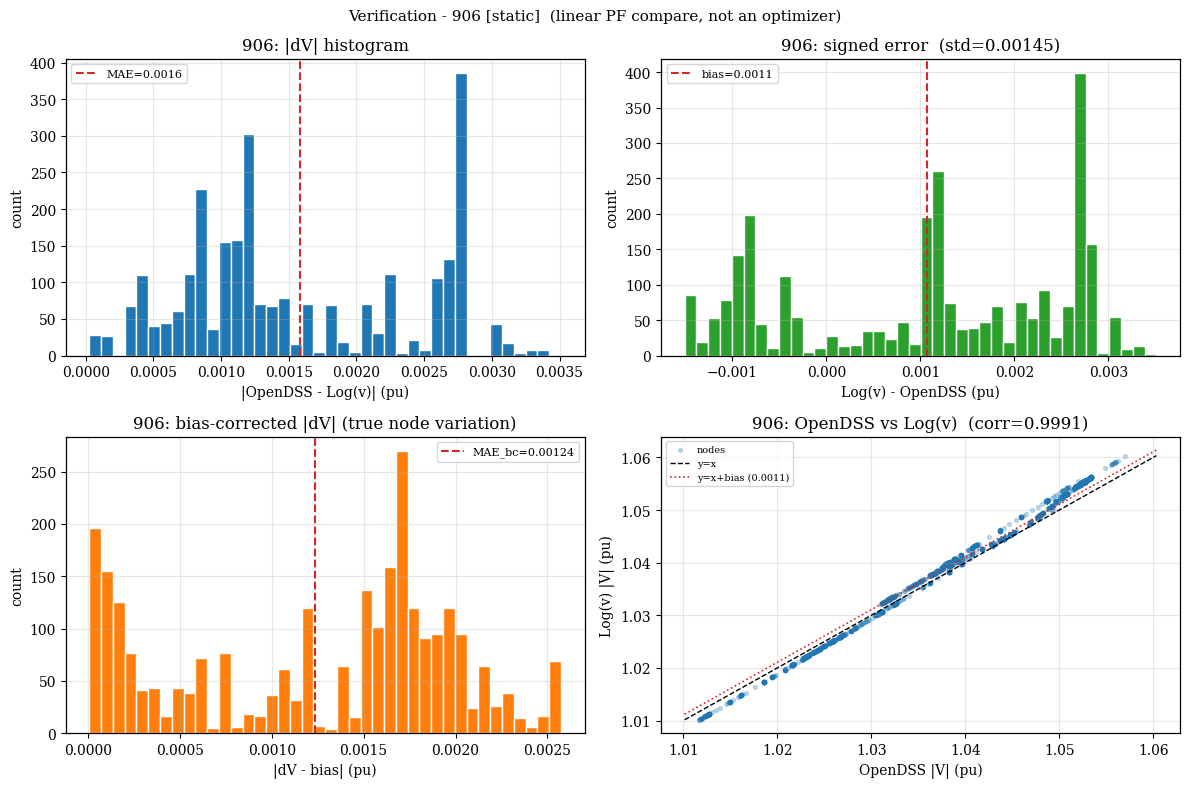

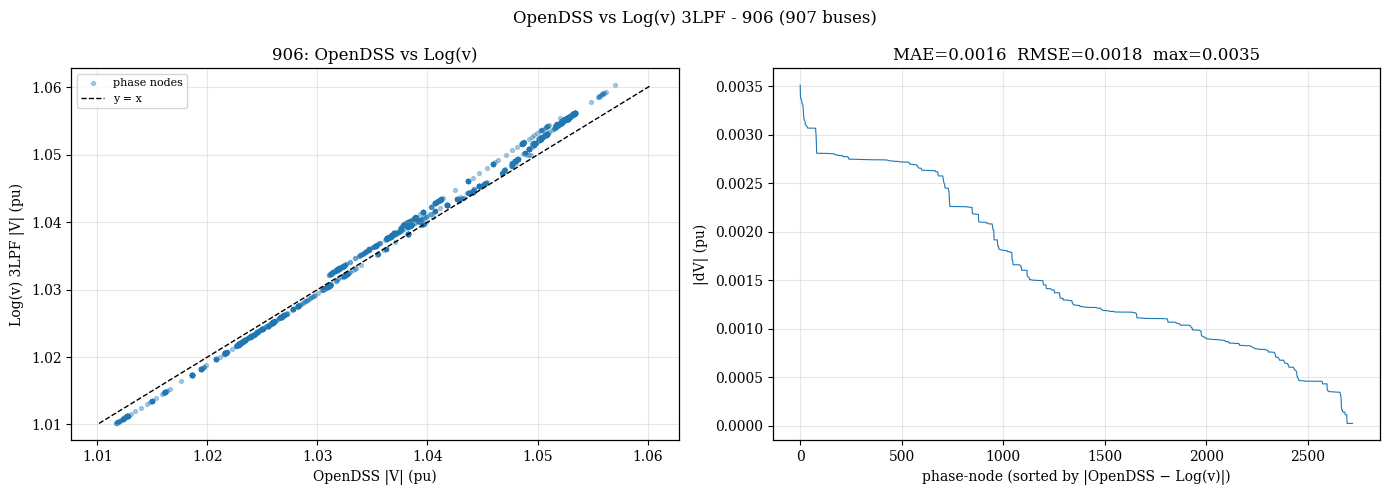

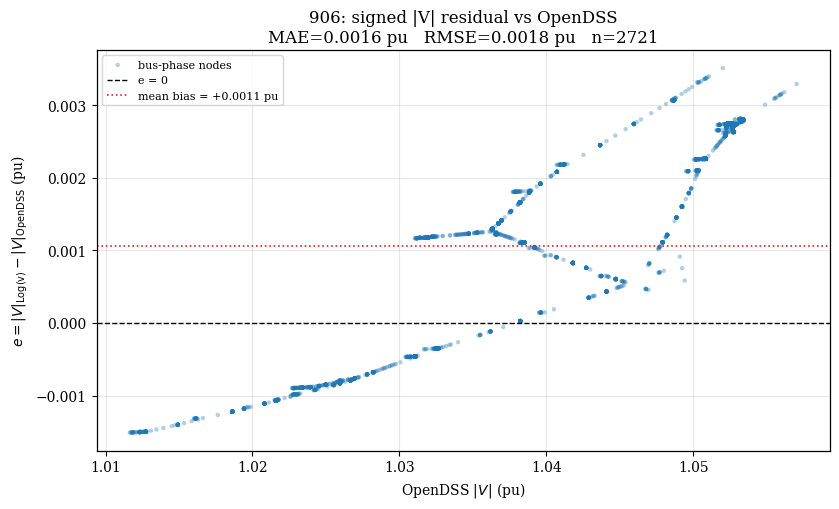

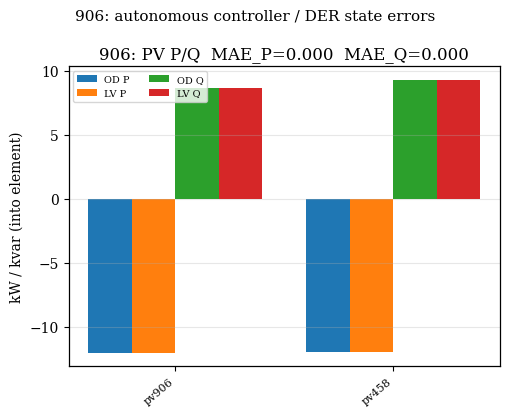

  PVSystems in circuit : 2
  |V| MAE / RMSE / max : 0.001582 / 0.001797 / 0.003511 pu  (n=2721)
  PV P/Q copy MAE      : P=0.0 kW  Q=0.0 kvar  (n=2)

SNAPSHOT  feeder=906  control_mode=synced
AUDIT - what this cell actually ran
  feeder          : 906
  DSS             : C:\Users\alita\OneDrive\Desktop\GNN2\906 bus system\LVTestCase_PV_voltvar\Master_snapshot_PV_voltvar.dss
  control_mode    : synced

  WHAT Log(v) IS
    linearized power-flow (rank-k / Woodbury linear algebra)
    NOT a linear program / optimizer
    paper: v ~ Delta*(1+u+j*theta_tilde); Ytilde=Delta*Y*.*Delta^H; ytilde=Ytilde*1
    controller limits are NOT encoded as LP constraints
  MODEL DISCLOSURES
    - Log(v) uses paper Ytilde:=Delta Y* Delta^H and ytilde:=Ytilde*1 (row sums).
    - No Delta-Wye ytilde zeroing; no default A ridge (ainv_ridge=0).
    - 2-winding transformer Yprim from OpenDSS CktElement.YPrim (pu), not ad-hoc ytilde zeroing.
    - Analytical Yprim is fallback only; magnetizing branch omitted in 

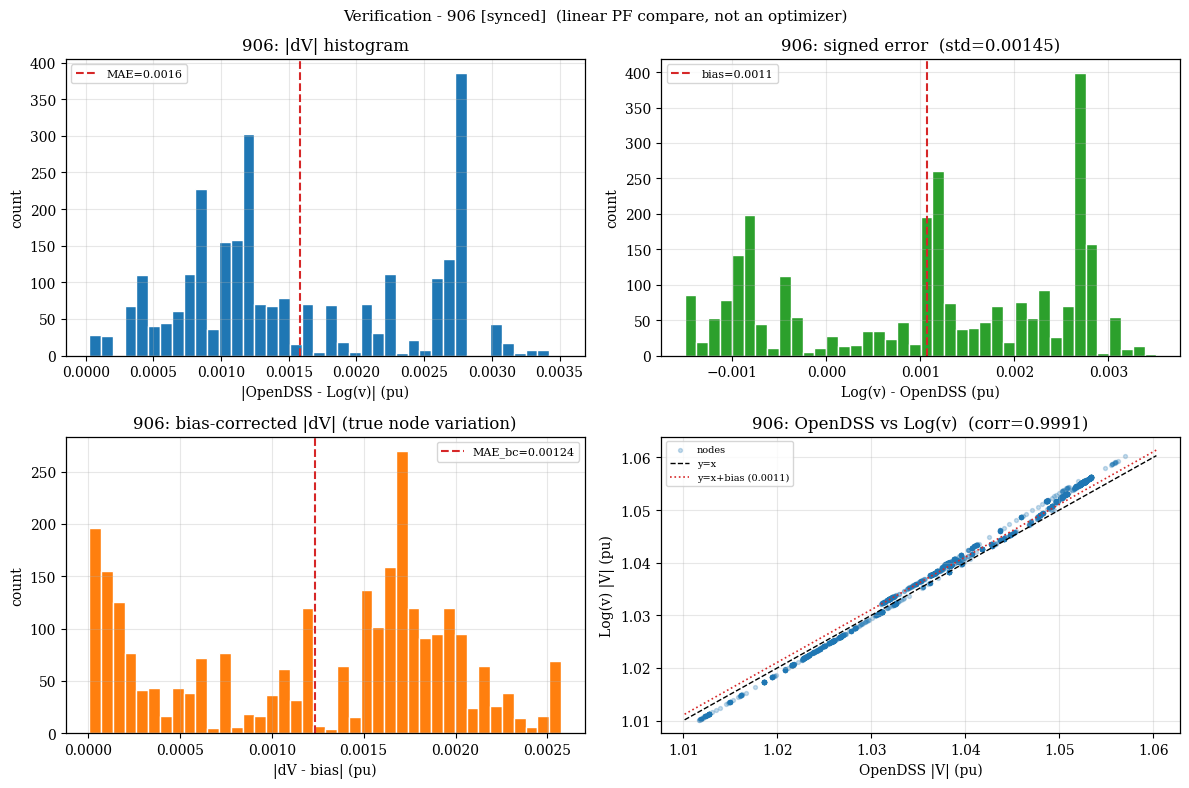

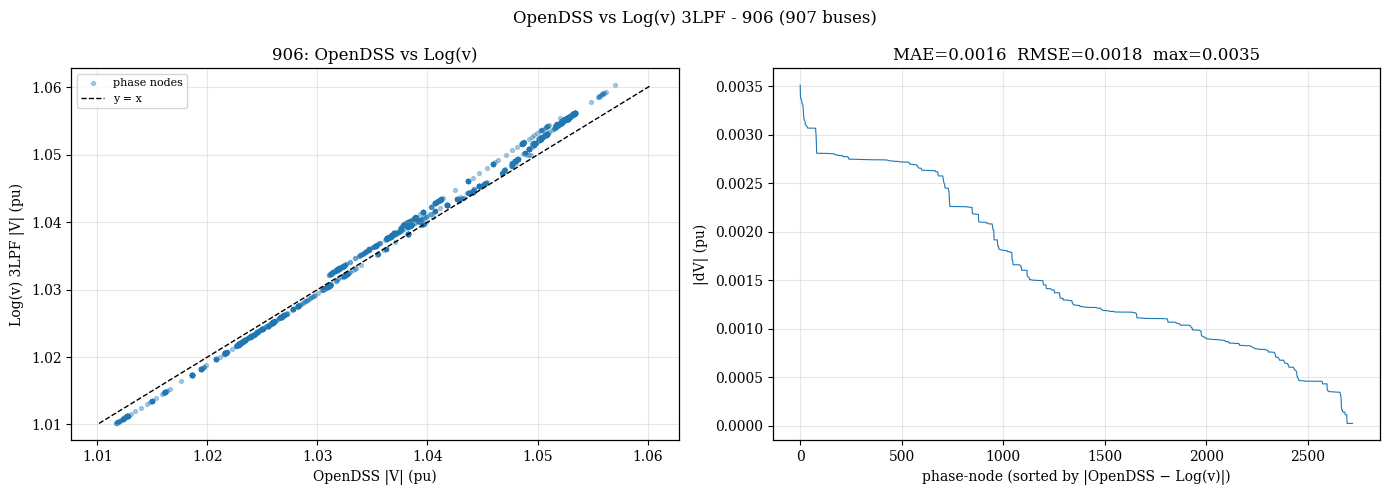

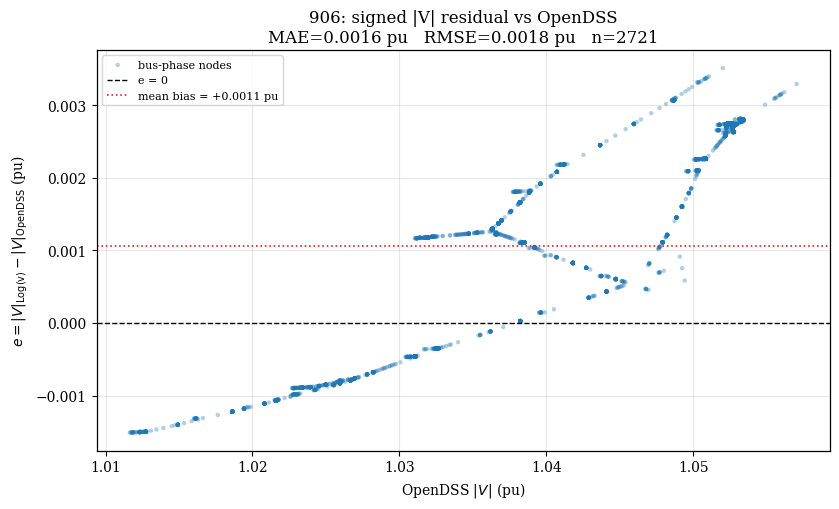

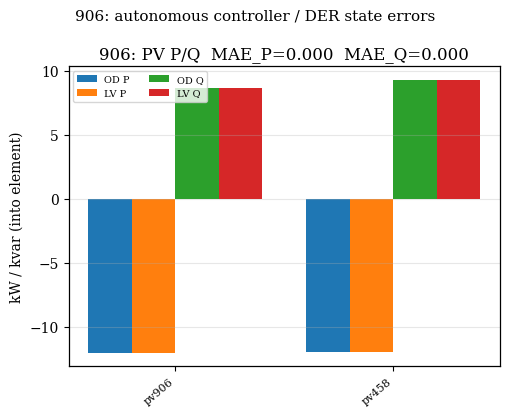

  PVSystems in circuit : 2
  |V| MAE / RMSE / max : 0.001582 / 0.001797 / 0.003511 pu  (n=2721)
  PV P/Q copy MAE      : P=0.0 kW  Q=0.0 kvar  (n=2)

OpenDSS PVSystems: ['pv906', 'pv458']
OK: PV906 + PV458 present; snapshot metrics above.


{'static': {'mae': 0.0015816029568450239,
  'rmse': 0.0017969572705713967,
  'max': 0.0035112391462690518,
  'n': 2721,
  'control_mode': 'static',
  'n_reg': 0,
  'reg_iters': 0,
  'tap_mae': nan,
  'paper_accuracy': {'n_phase_nodes': 2721,
   'vm_rmse_pu': 0.0017969572705713967,
   'vm_mape_pct': 0.1516024592351538,
   'vm_mae_pu': 0.0015816029568450239,
   'va_rmse_deg': 0.08695071900634023,
   'va_mae_deg': 0.061981318699141766,
   'va_rmse_deg_global_aligned': 0.06254835574521557,
   'va_source_offset_deg': -0.02348552648774671,
   'vsource_angle_deg': 0.0},
  'paper_flops': {'n_bus_phases': 2721.0,
   'n_excl_source': 2718.0,
   'n_source_phases': 3.0,
   'n_sys': 5442.0,
   'k': 0.0,
   'k_load_phases': 0.0,
   'k_cap_phases': 0.0,
   'k_reg_phases': 0.0,
   'k_reg_primary_phases': 0.0,
   'k_woodbury_U': 0.0,
   'n_regulators': 0.0,
   'opendss_lu_flops': 107563002048.0,
   'opendss_lu_flops_excl_source': 107207748288.0,
   'logv_woodbury_update_flops': 0.0,
   'logv_apply_flop

In [5]:
# ============================================================
# 906 PV Volt-Var — Log(v) vs OpenDSS SNAPSHOT (static + synced)
# Master: LVTestCase_PV_voltvar / Master_snapshot_PV_voltvar.dss
# fixedctrlinit: PF=1 kvar=0 then Static (built into compare helper)
# ============================================================
%matplotlib inline
import os
import sys
from pathlib import Path

def _find_repo() -> Path:
    env = os.environ.get("GNN2_REPO_ROOT", "").strip()
    cands = [Path(env)] if env else []
    cands += [
        Path(r"C:\Users\alita\OneDrive\Desktop\GNN2"),
        Path.cwd(),
        Path("/content/GNN2"),
    ]
    for raw in cands:
        root = Path(raw).expanduser().resolve()
        if (root / "logv3lpf_daily_demo.py").is_file() and (
            root / "Log-v-3LPF" / "logv3lpf"
        ).is_dir():
            return root
    raise FileNotFoundError("Need GNN2 repo with Log-v-3LPF/ and logv3lpf_daily_demo.py")


REPO = _find_repo()
os.chdir(REPO)
sys.path[:0] = [str(REPO), str(REPO / "Log-v-3LPF")]

for mod in list(sys.modules):
    if mod.startswith("logv3lpf") or mod in (
        "logv3lpf_daily_demo",
        "logv_fast_solver",
        "logv_dataset_sample_compare",
    ):
        sys.modules.pop(mod, None)

import importlib
import opendssdirect as dss
import logv3lpf_daily_demo as demo

demo = importlib.reload(demo)

FEEDER = "906"  # PV Volt-Var master (use "906_stock" for no-PV)
PLOT = True
SAVE_PLOTS = True
OUT_DIR = REPO / "outputs" / "logv3lpf_snapshot"
OUT_DIR.mkdir(parents=True, exist_ok=True)

dss_path = Path(demo.FEEDERS[demo.resolve_feeder(FEEDER)]["dss"](REPO)).resolve()
print(f"FEEDER={FEEDER}")
print(f"DSS={dss_path}")
assert "LVTestCase_PV_voltvar" in str(dss_path), dss_path
assert dss_path.is_file(), dss_path

reports = {}
for mode in ("static", "synced"):
    print("\n" + "=" * 72)
    print(f"SNAPSHOT  feeder={FEEDER}  control_mode={mode}")
    print("=" * 72)
    _case, m = demo.compare_logv3lpf_vs_opendss(
        REPO,
        feeder=FEEDER,
        control_mode=mode,
        plot=PLOT,
        save_plots=SAVE_PLOTS,
        out_dir=OUT_DIR,
        diagnostics=True,
        timing_repeats=3,
    )
    reports[mode] = m
    audit = m.get("audit") or {}
    inv = audit.get("opendss_inventory") or {}
    print(f"  PVSystems in circuit : {inv.get('PVSystems')}")
    print(f"  |V| MAE / RMSE / max : {m['mae']:.6f} / {m['rmse']:.6f} / {m['max']:.6f} pu  (n={m['n']})")
    ctrl = (m.get("controllers") or {}).get("inv_pv") or (m.get("controllers") or {}).get("inv") or {}
    if ctrl.get("n"):
        print(
            f"  PV P/Q copy MAE      : P={ctrl.get('mae_kw')} kW  Q={ctrl.get('mae_kvar')} kvar  (n={ctrl.get('n')})"
        )

# Sanity: both PVs present after last compare
try:
    pvs = [n for n in dss.PVsystems.AllNames() if n and n != "NONE"]
except Exception:
    pvs = []
print("\nOpenDSS PVSystems:", pvs)
assert any("906" in str(n).lower() for n in pvs), pvs
assert any("458" in str(n).lower() for n in pvs), pvs
print("OK: PV906 + PV458 present; snapshot metrics above.")
reports


### Daily OpenDSS vs Log(v) — 906 PV Volt-Var (fixedctrlinit)

Full-day (default 288 × 5 min) accuracy on the PV master with the same Static + fixedctrlinit protocol.

Set `SMOKE_TEST=True` for a quick 24-step check; `False` for the paper-style 288-pt day.


Compiling DSS file in OpenDSS...
Parsing DSS file in LogV3LPF format...
Appended 2 PVSystem(s) as negative constant-power loads for Log(v).
Transformer tr1 is delta-wye or wye-delta. LV side bus and buses downstream lag 30 degrees w.r.t. HV side
Done parsing
Calculating Line Matrices
Calculating Transformer Matrices
Calculating Base Matrices
Nodes =  2721
k =  0
Complexity of KLU decomposition, 1.08e+11 FLOPS 
Complexity of LogV algorithm, 2.96e+07 FLOPS 
DAILY OpenDSS vs Log(v)  feeder=906  mode=static  npts=24  step=5.0min  day=0
  DSS: C:\Users\alita\OneDrive\Desktop\GNN2\906 bus system\LVTestCase_PV_voltvar\Master_snapshot_PV_voltvar.dss
  plot nodes: ['817.1', '860.1', '896.1', '906.1', '458.3']
  regs: (none)
  caps: (none)
  load models: M1 constP×55
  time_speed (FastLogv): False
  fixedctrlinit (PV PF=1/kvar=0 before Static): True
  OpenDSS primary metric: snapshot Solve() only (Method A buckets)
  profile: native DSS loadshapes -> explicit kW/kvar each step (snapshot); copied

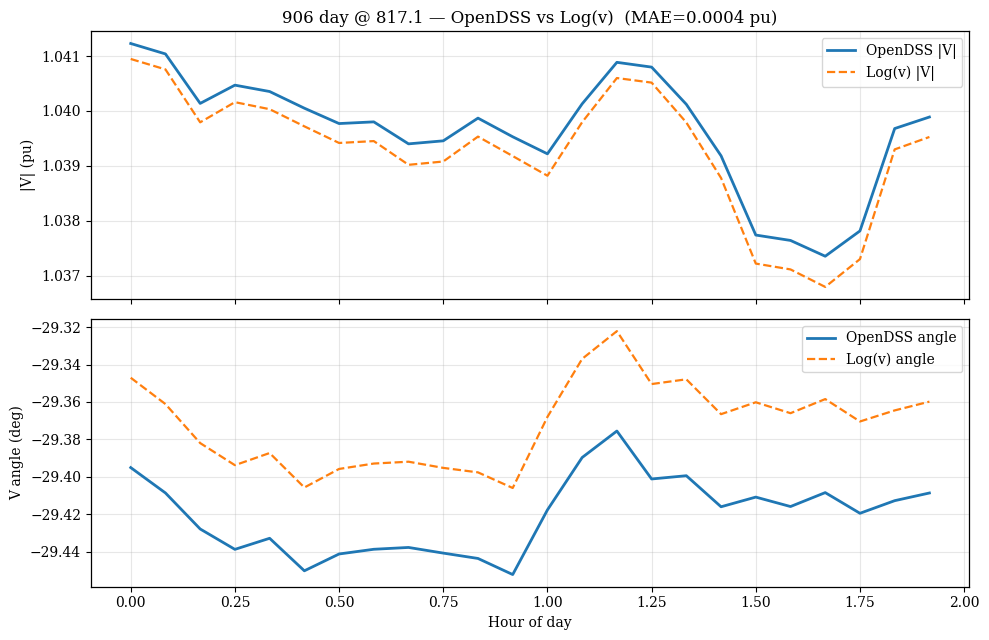

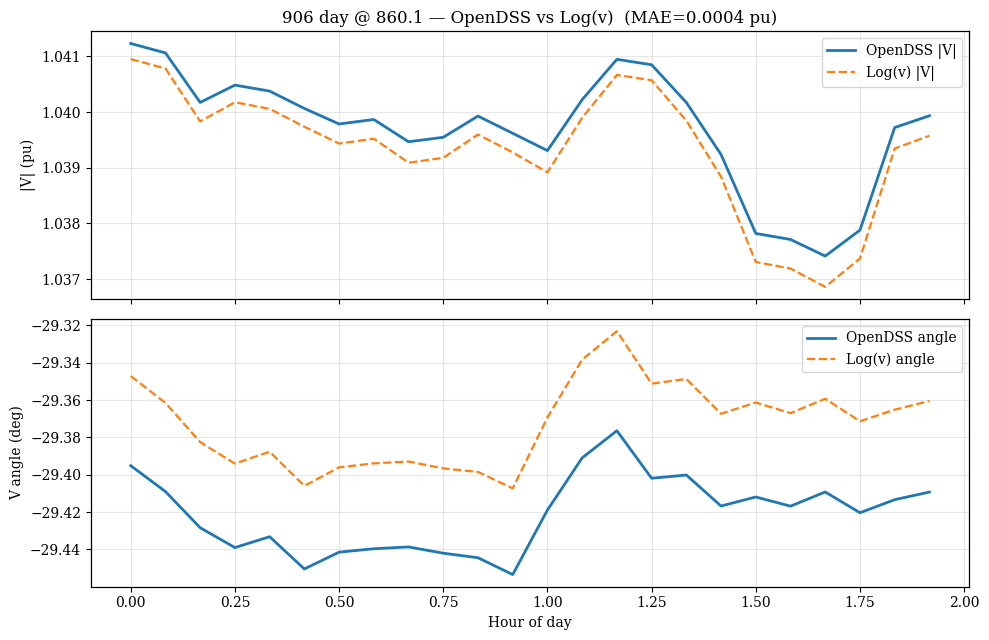

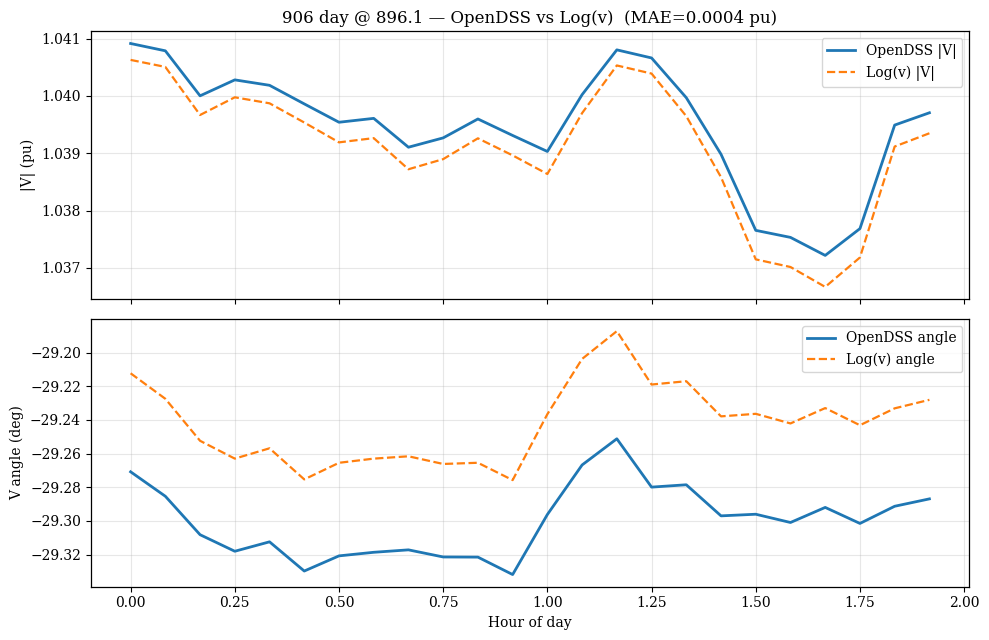

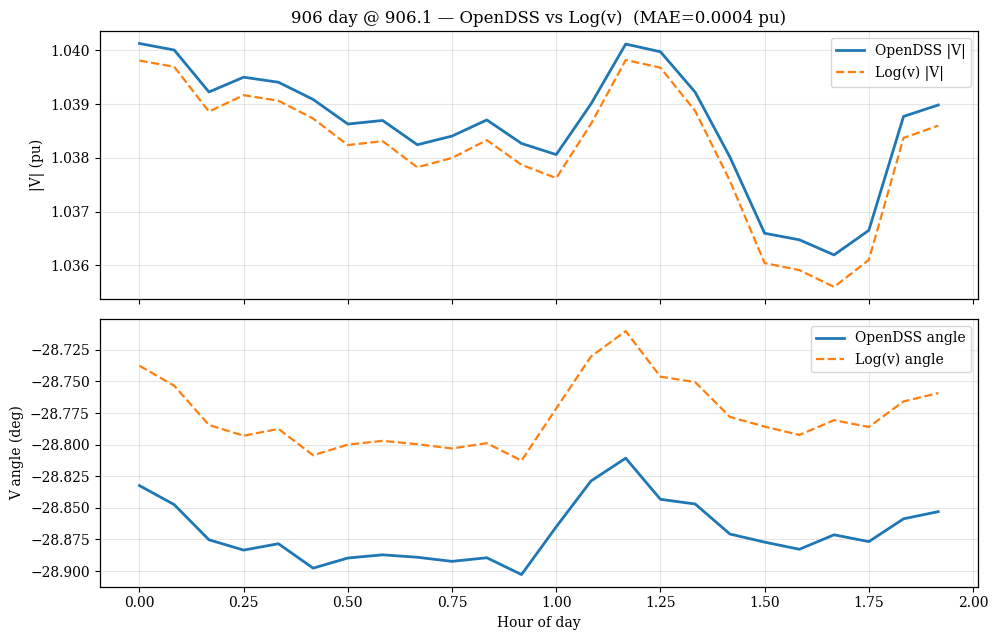

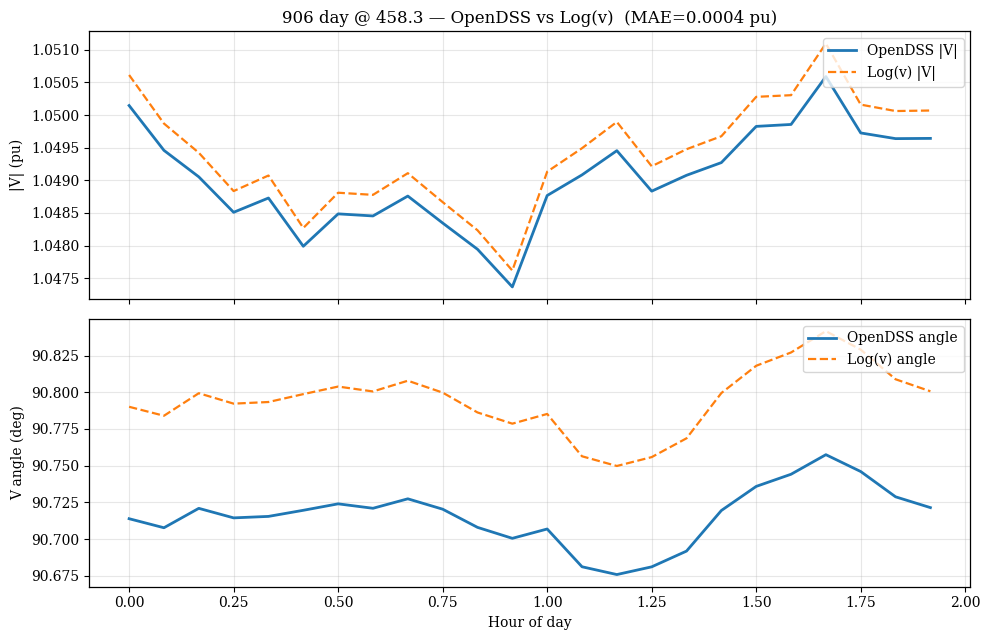

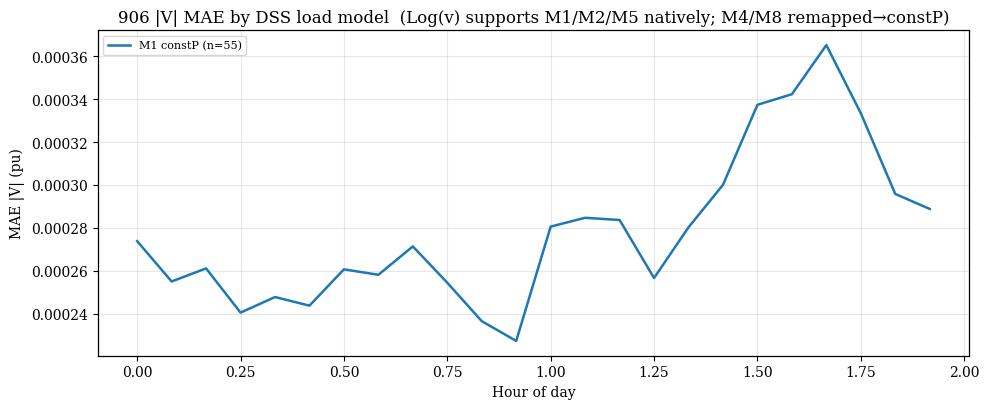

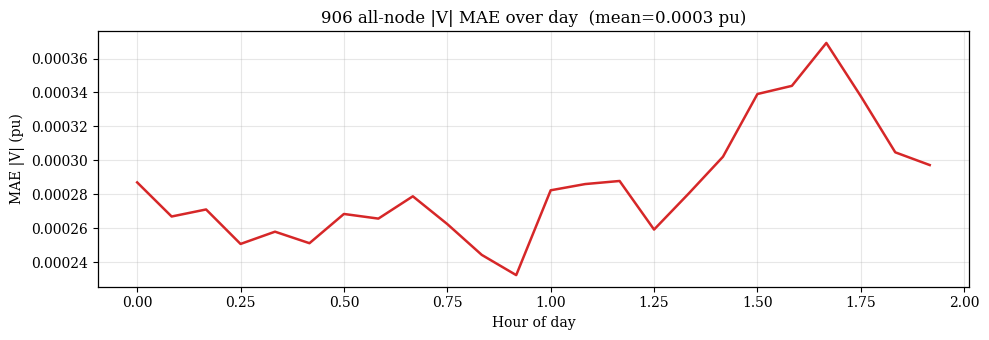


DAY SUMMARY
  mean |V| MAE  : 0.000284 pu
  mean angle MAE: 0.035175 deg
  CSV / plots   : C:\Users\alita\OneDrive\Desktop\GNN2\outputs\logv3lpf_daily_compare


{'mean_mae_vm': 0.00028441689278187594,
 'mean_rmse_vm': 0.00033138280161965593,
 'max_mae_vm': 0.00036921649939810036,
 'mean_mae_va': 0.03517536888402263,
 'mean_rmse_va': 0.039848207493513754,
 'max_mae_va': 0.038910694104530075,
 'n_ok': 24,
 'n_bad': 0,
 'wall_s': 2.227890900001512,
 'n_A_rebuilds': 0,
 'n_fast_refresh': 0,
 'fair_fast': False,
 'logv_source': 'stock',
 'mean_t_opendss_apply_ms': 0.3123541664535878,
 'mean_t_opendss_reassert_ms': 0.06717499976123993,
 'mean_t_opendss_solve_ms': 29.47438750076496,
 'mean_t_opendss_collect_ms': 11.08771666379956,
 'mean_t_opendss_ms': 29.47438750076496,
 'mean_t_opendss_cold_ms': nan,
 'mean_t_fast_ms': nan,
 'mean_t_fast_refresh_ms': nan,
 'mean_t_logv_ms': 21.906787498664926}

In [6]:
# ============================================================
# 906 PV Volt-Var — DAILY OpenDSS vs Log(v) (fixedctrlinit)
# ============================================================
%matplotlib inline
import os
import sys
from pathlib import Path

def _find_repo() -> Path:
    env = os.environ.get("GNN2_REPO_ROOT", "").strip()
    cands = [Path(env)] if env else []
    cands += [
        Path(r"C:\Users\alita\OneDrive\Desktop\GNN2"),
        Path.cwd(),
        Path("/content/GNN2"),
    ]
    for raw in cands:
        root = Path(raw).expanduser().resolve()
        if (root / "logv3lpf_daily_opendss_compare.py").is_file():
            return root
    raise FileNotFoundError("Need GNN2 repo with logv3lpf_daily_opendss_compare.py")


REPO = _find_repo()
os.chdir(REPO)
sys.path[:0] = [str(REPO), str(REPO / "Log-v-3LPF")]

for mod in list(sys.modules):
    if mod.startswith("logv3lpf") or mod in (
        "logv3lpf_daily_opendss_compare",
        "logv3lpf_daily_demo",
        "logv_fast_solver",
    ):
        sys.modules.pop(mod, None)

import importlib
import logv3lpf_daily_opendss_compare as daily

daily = importlib.reload(daily)

FEEDER = "906"
CONTROL_MODE = "static"   # or "synced"
SMOKE_TEST = True         # True → 24 steps; False → 288
DAY = 0
NPTS = 24 if SMOKE_TEST else 288
STEP_MIN = 5.0
PLOT = True
SAVE_PLOTS = True
SAVE_CSV = True
FIXEDCTRLINIT = True      # PF=1 kvar=0 before each Static solve

series = daily.run_daily_opendss_vs_logv3lpf(
    REPO,
    feeder=FEEDER,
    day=DAY,
    npts=NPTS,
    step_min=STEP_MIN,
    control_mode=CONTROL_MODE,
    show_plots=PLOT,
    save_plots=SAVE_PLOTS,
    save_csv=SAVE_CSV,
    fixedctrlinit=FIXEDCTRLINIT,
    time_speed=False,
)
summ = series["summary"]
print("\nDAY SUMMARY")
print(f"  mean |V| MAE  : {summ['mean_mae_vm']:.6f} pu")
print(f"  mean angle MAE: {summ['mean_mae_va']:.6f} deg")
print(f"  CSV / plots   : {REPO / 'outputs' / 'logv3lpf_daily_compare'}")
series["summary"]


### Dataset-sample Log(v) — 906 PV fixedctrlinit chunk (vs saved `vmag_pu`)

Replays loads/PV from `original_906_lvtestcase_pv_voltvar_fixedctrlinit` and scores Log(v) against the chunk’s OpenDSS `|V|` labels (`vmag_pu`). No GNN `.pt` cache required.

Primary control mode: **static** (matches dataset `ControlMode=STATIC` + fixedctrlinit).


In [7]:
# ============================================================
# 906 PV fixedctrlinit — Log(v) vs dataset OpenDSS labels (vmag_pu)
# ============================================================
%matplotlib inline
import os
import sys
from pathlib import Path

def _find_repo() -> Path:
    env = os.environ.get("GNN2_REPO_ROOT", "").strip()
    cands = [Path(env)] if env else []
    cands += [
        Path(r"C:\Users\alita\OneDrive\Desktop\GNN2"),
        Path.cwd(),
        Path("/content/GNN2"),
    ]
    for raw in cands:
        root = Path(raw).expanduser().resolve()
        if (root / "logv_dataset_sample_compare.py").is_file():
            return root
    raise FileNotFoundError("Need GNN2 repo with logv_dataset_sample_compare.py")


REPO = _find_repo()
os.chdir(REPO)
sys.path[:0] = [str(REPO), str(REPO / "Log-v-3LPF")]

for mod in list(sys.modules):
    if mod.startswith("logv3lpf") or mod in (
        "logv_dataset_sample_compare",
        "logv3lpf_daily_demo",
    ):
        sys.modules.pop(mod, None)

import importlib
import logv_dataset_sample_compare as dsc

dsc = importlib.reload(dsc)

FEEDER = "906"
CONTROL_MODE = "static"   # fair vs fixedctrlinit dataset
SAMPLE_ID = 0             # or any sample_id in the chunk meta
SAVE_CSV = True

chunk = dsc._resolve_906_pv_chunk_dir(REPO)
print(f"chunk_dir={chunk}")

snap = dsc.replay_dataset_sample_logv(
    REPO,
    feeder=FEEDER,
    cache_pt=None,  # use CSV vmag_pu labels
    chunk_dir=chunk,
    sample_id=SAMPLE_ID,
    control_mode=CONTROL_MODE,
    fixedctrlinit=True,
)

print(f"  Log(v) label              : {snap.logv_label}")
print(f"  P/Q applied               : {snap.p_load_kw:.1f} kW / {snap.q_load_kvar:.1f} kvar")
print("  --- vs DATASET OpenDSS labels (vmag_pu) ---")
print(f"  Log(v) MAE / RMSE         : {snap.mae_logv_vs_dataset:.6f} / {snap.rmse_logv_vs_dataset:.6f} pu")
print(f"  Log(v) vs live OD MAE     : {snap.mae_logv_vs_live_od:.6f} pu")
print(f"  live OD vs dataset MAE    : {snap.mae_live_od_vs_dataset:.6f} pu")
print(
    f"  bias (LV-label)           : {snap.bias_logv_minus_dataset:+.6f} pu  "
    f"(over={snap.frac_over_vs_dataset:.0%}, under={snap.frac_under_vs_dataset:.0%})"
)

out_dir = REPO / "outputs" / "logv3lpf_dataset_compare"
out_dir.mkdir(parents=True, exist_ok=True)
if SAVE_CSV and snap.node_mae is not None:
    csv_path = out_dir / f"{FEEDER}_pv_fixedctrlinit_{CONTROL_MODE}_sample_{SAMPLE_ID}_nodes.csv"
    snap.node_mae.to_csv(csv_path, index=False)
    print(f"  wrote {csv_path}")
snap


chunk_dir=K:\My Drive\datasets_gnn2\original_906_lvtestcase_pv_voltvar_fixedctrlinit\run_001_scen_0000_0049_seed_90730233


C:\Users\alita\OneDrive\Desktop\GNN2\logv_dataset_sample_compare.py:492: DtypeWarning: Columns (1) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(nodes_csv, usecols=lambda c: c in ("sample_id", "node", "vmag_pu"))
C:\Users\alita\OneDrive\Desktop\GNN2\logv_dataset_sample_compare.py:212: DtypeWarning: Columns (1,3) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(nodes_csv)


[logv_dataset_replay] feature P/Q from gnn_node_features_and_targets_mvagg.csv  n_nodes=2721  P_sum=4.1 kW
[logv_dataset_replay] using live-DSS load map  n_loads=55
  Log(v) label              : Log(v), static states
  P/Q applied               : 4.1 kW / 0.9 kvar
  --- vs DATASET OpenDSS labels (vmag_pu) ---
  Log(v) MAE / RMSE         : 0.000337 / 0.000383 pu
  Log(v) vs live OD MAE     : 0.000303 pu
  live OD vs dataset MAE    : 0.000078 pu
  bias (LV-label)           : +0.000153 pu  (over=62%, under=32%)
  wrote C:\Users\alita\OneDrive\Desktop\GNN2\outputs\logv3lpf_dataset_compare\906_pv_fixedctrlinit_static_sample_0_nodes.csv


DatasetReplayResult(feeder='906', control_mode='static', sample_id=0, row_i=0, logv_label='Log(v), static states', n_nodes=2721, mae_logv_vs_dataset=0.0003372539969044967, rmse_logv_vs_dataset=0.0003834735789330782, mae_live_od_vs_dataset=7.802901107828236e-05, mae_logv_vs_live_od=0.0003033117297080241, bias_logv_minus_dataset=0.00015318577463873086, frac_over_vs_dataset=0.6181550900404263, frac_under_vs_dataset=0.3245130466740169, p_load_kw=4.1056412895372345, q_load_kvar=0.884912966134587, forced_taps={'vreg2_a': 1.0, 'vreg2_b': 1.0, 'vreg2_c': 1.0, 'vreg3_a': 1.0, 'vreg3_b': 1.0, 'vreg3_c': 1.0, 'vreg4_a': 1.0, 'vreg4_b': 1.0, 'vreg4_c': 1.0}, n_caps_set=0, n_remap_warning='', node_mae=             node  vm_dataset  vm_opendss_live   vm_logv  \
0     sourcebus.1    1.049809         1.049809  1.050000   
1     sourcebus.2    1.049737         1.049731  1.050000   
2     sourcebus.3    1.049598         1.049593  1.050000   
3             1.1    1.048579         1.048573  1.048786   
4 

### Compare incomplete fixedctrlinit_yedges runs (shared val/test)

Evaluate voltage metrics on the **same** 8500 chunk parent / cache / split as the finished `volt_only` run.

| table tag | Run dir | Checkpoint policy |
|---|---|---|
| **`original@120`** | `..._metaaux_regce_20260911_173803` | `best_model_state_dict` from `training_last.pt`; assert/print `best_epoch == 120` |
| **`full_node@50`** | `..._full_node_attn_20260912_130829` | `best_model_state_dict` from `training_last.pt`; assert/print `best_epoch == 50` |
| **`volt_only@final_best`** | `..._volt_only_20260912_023942` | **Not** epoch 120 — mid-epoch ckpt unavailable. Load `da_gps_multitask_best.pt` (final best, expected ~190) + print report numbers |

**Metrics (all three):** `mae_vmag_pu`, `r2_vmag_mean`, `mae_angle_deg` on shared val + test.

Uses `train_da_gps_multitask_complex_voltage_gine.py --eval_only`. Each run keeps its own `x_mean` / `y_*` norm stats; `global_attn_mode` comes from each run's manifest.

> Reminder: **`volt_only@120` is impossible** — `checkpoint_every` only overwrote `training_last.pt`; no mid-epoch weight file exists.

In [ ]:
# ============================================================
# Compare incomplete fixedctrlinit_yedges runs on SHARED val/test
# Tags: original@120 | full_node@50 | volt_only@final_best
# Metrics: mae_vmag_pu, r2_vmag_mean, mae_angle_deg (val+test)
# ============================================================
from __future__ import annotations

import datetime as _dt
import json
import os
import shutil
import subprocess
import sys
import warnings
from pathlib import Path

import torch

# ---- paths (same resolution pattern as other FINAL 8500 cells) ----
CHUNK_NAME = "original_8500_unbalanced_chunked_no_bess_new_diverse_2000_40_fixedctrlinit_yedges"
CACHE_NAME = "da_gps_chunked_mvagg_fixedctrlinit_yedges_full_gine"
BOOT_NAME = "gnn_only_chunked_mvagg_fixedctrlinit_yedges_full_gine"

DRIVE_ROOT = Path("/content/drive")
MYDRIVE_DATA = DRIVE_ROOT / "MyDrive/datasets_gnn2"
COLAB_CHUNK_DEFAULT = MYDRIVE_DATA / CHUNK_NAME

RUN_ORIGINAL = "da_gps_fixedctrlinit_yedges_l2_h96_mvagg_gine_metaaux_regce_20260911_173803"
RUN_FULLNODE = "da_gps_fixedctrlinit_yedges_l2_h96_mvagg_gine_full_node_attn_20260912_130829"
RUN_VOLT = "da_gps_fixedctrlinit_yedges_l2_h96_mvagg_gine_volt_only_20260912_023942"

METRIC_KEYS = ("mae_vmag_pu", "r2_vmag_mean", "mae_angle_deg")
EXPECTED_BEST_EPOCH_ORIGINAL = 120
EXPECTED_BEST_EPOCH_FULLNODE = 50
# volt_only mid-epoch 120 does NOT exist; always final-best (~190)


def _on_colab() -> bool:
    try:
        import google.colab  # noqa: F401

        return True
    except ImportError:
        return False


def _drive_mounted() -> bool:
    return DRIVE_ROOT.is_dir() and (DRIVE_ROOT / "MyDrive").is_dir()


def _find_repo() -> Path:
    mod = "train_da_gps_multitask_complex_voltage_gine.py"
    cands: list[Path] = []
    env = os.environ.get("GNN2_REPO_ROOT", "").strip()
    if env:
        cands.append(Path(env))
    cwd = Path.cwd().resolve()
    cands.append(cwd)
    cands.extend(cwd.parents)
    cands.extend(
        [
            Path(r"C:\Users\alita\OneDrive\Desktop\GNN2"),
            Path("/content/GNN-Sandia"),
            Path("/content/GNN2"),
        ]
    )
    seen: set[Path] = set()
    for root in cands:
        root = Path(root).expanduser().resolve()
        if root in seen or not root.exists():
            continue
        seen.add(root)
        if (root / mod).is_file():
            return root
    raise FileNotFoundError(f"Could not find {mod}. Set GNN2_REPO_ROOT or cd into the repo.")


def _pick_datasets_root() -> Path:
    cands = [
        MYDRIVE_DATA,
        Path(r"H:\My Drive\datasets_gnn2"),
        Path(r"K:\My Drive\datasets_gnn2"),
        Path(r"C:\Users\alita\OneDrive\Desktop\GNN2\datasets_gnn2"),
    ]
    for p in cands:
        if (p / "runs").is_dir() or (p / CHUNK_NAME).is_dir() or (p / "cache").is_dir():
            return p.resolve()
    raise FileNotFoundError("Could not locate datasets_gnn2 (mount Drive / set H: or K:).")


if _on_colab() and not _drive_mounted():
    from google.colab import drive

    drive.mount("/content/drive")

REPO = _find_repo()
DATA = _pick_datasets_root()
CHUNK_PARENT = DATA / CHUNK_NAME
CACHE_DIR = DATA / "cache" / CACHE_NAME
BOOT_DIR = DATA / "cache" / BOOT_NAME
RUNS = DATA / "runs"
OUT_COMPARE = RUNS / f"_compare_eval_fixedctrlinit_yedges_{_dt.datetime.now().strftime('%Y%m%d_%H%M%S')}"
OUT_COMPARE.mkdir(parents=True, exist_ok=True)

assert CHUNK_PARENT.is_dir(), CHUNK_PARENT
assert CACHE_DIR.is_dir(), CACHE_DIR
assert (RUNS / RUN_ORIGINAL / "training_last.pt").is_file()
assert (RUNS / RUN_FULLNODE / "training_last.pt").is_file()
assert (RUNS / RUN_VOLT).is_dir()
assert (REPO / "train_da_gps_multitask_complex_voltage_gine.py").is_file()

node_pe_hits = sorted(CHUNK_PARENT.glob("run_*/gnn_node_index_master.csv"))
NODE_PE_CSV = node_pe_hits[0]
print("REPO:", REPO)
print("DATA:", DATA)
print("CHUNK_PARENT:", CHUNK_PARENT)
print("CACHE_DIR:", CACHE_DIR)
print("OUT_COMPARE:", OUT_COMPARE)
print("node_pe_csv:", NODE_PE_CSV)
print(
    "POLICY: original@%d | full_node@%d | volt_only@final_best (NOT epoch 120)"
    % (EXPECTED_BEST_EPOCH_ORIGINAL, EXPECTED_BEST_EPOCH_FULLNODE)
)


def _load_manifest(run_dir: Path) -> dict:
    p = run_dir / "da_gps_run_manifest.json"
    return json.loads(p.read_text(encoding="utf-8")) if p.is_file() else {}


def _scan_epoch_checkpoints(run_dir: Path, target_epoch: int) -> dict:
    """Document that mid-epoch weight files are missing (checkpoint_every overwrote training_last)."""
    pats = [
        f"epoch_{target_epoch}.pt",
        f"epoch{target_epoch}.pt",
        f"checkpoint_epoch_{target_epoch}.pt",
        f"ckpt_epoch_{target_epoch}.pt",
        f"da_gps_epoch_{target_epoch}.pt",
        f"training_epoch_{target_epoch}.pt",
        f"model_epoch_{target_epoch}.pt",
    ]
    found = [run_dir / n for n in pats if (run_dir / n).is_file()]
    all_pts = sorted(p.name for p in run_dir.glob("*.pt"))
    return {
        "target_epoch": target_epoch,
        "exact_matches": [str(p) for p in found],
        "all_pt_files": all_pts,
        "available": bool(found),
    }


def _check_best_epoch(label: str, actual, expected: int) -> int | None:
    """Print actual best_epoch; assert if it matches expected, else warn with actual."""
    if actual is None:
        print(f"[{label}] WARNING: best_epoch missing in checkpoint (expected {expected})")
        return None
    be = int(actual)
    print(f"[{label}] best_epoch={be} (expected {expected})")
    if be == expected:
        assert be == expected
        print(f"[{label}] OK: best_epoch == {expected}")
    else:
        print(f"[{label}] WARNING: expected best_epoch=={expected}, got {be} — using actual tag @{be}")
    return be


def _extract_eval_checkpoint(src_pt: Path, dest_pt: Path, *, prefer_best: bool = True) -> dict:
    """Build a lean ckpt with model_state_dict = best_model_state_dict (else last)."""
    pack = torch.load(src_pt, map_location="cpu", weights_only=False)
    if not isinstance(pack, dict):
        raise TypeError(f"unexpected checkpoint type: {type(pack)} @ {src_pt}")
    best_sd = pack.get("best_model_state_dict")
    last_sd = pack.get("model_state_dict")
    if prefer_best and best_sd is not None:
        sd, used = best_sd, "best_model_state_dict"
    elif last_sd is not None:
        sd, used = last_sd, "model_state_dict"
    elif best_sd is not None:
        sd, used = best_sd, "best_model_state_dict"
    else:
        raise ValueError(f"no weights in {src_pt}")
    dest_pt.parent.mkdir(parents=True, exist_ok=True)
    torch.save(
        {
            "model_state_dict": sd,
            "checkpoint_type": "eval_extracted",
            "source_checkpoint": str(src_pt),
            "weight_source": used,
            "epoch": pack.get("epoch"),
            "best_epoch": pack.get("best_epoch"),
            "best_val": pack.get("best_val"),
        },
        dest_pt,
    )
    return {
        "source_checkpoint": str(src_pt),
        "weight_source": used,
        "epoch": pack.get("epoch"),
        "best_epoch": pack.get("best_epoch"),
        "best_val": pack.get("best_val"),
        "extracted_to": str(dest_pt),
    }


def _pick_metrics(block: dict | None) -> dict:
    block = block or {}
    return {k: block.get(k) for k in METRIC_KEYS}


def _tag_label(base: str, epoch_tag: str) -> str:
    return f"{base}@{epoch_tag}"


def _run_eval_only(
    *,
    label: str,
    run_dir: Path,
    init_ckpt: Path,
    global_attn_mode: str,
    batch_size: int,
    lambda_cap: float,
    lambda_reg: float,
    lambda_pv: float,
) -> dict:
    work = OUT_COMPARE / f"eval_{label.replace('@', '_at_')}"
    if work.exists():
        shutil.rmtree(work)
    work.mkdir(parents=True, exist_ok=True)

    cmd = [
        sys.executable,
        "-u",
        "train_da_gps_multitask_complex_voltage_gine.py",
        "--eval_only",
        "--init_checkpoint",
        str(init_ckpt),
        "--init_run_dir",
        str(run_dir),
        "--init_checkpoint_strict",
        "--no-drop_samples_unseen_reg_taps",
        "--no-map_unseen_reg_taps_to_nearest",
        "--chunk_parent",
        str(CHUNK_PARENT),
        "--chunk_subdir_glob",
        "run_*",
        "--cache_dir",
        str(CACHE_DIR),
        "--nodes_csv",
        "gnn_node_features_and_targets_mvagg.csv",
        "--edge_catalog_csv",
        "gnn_edges_phase_static.csv",
        "--meta_csv",
        "gnn_sample_meta.csv",
        "--node_feature_cols",
        "p_load_kw,q_load_kvar,p_pv_kw",
        "--exclude_bess_features",
        "--node_pe_csv",
        str(NODE_PE_CSV),
        "--node_pe_cols",
        "auto",
        "--model",
        "gine",
        "--layers",
        "2",
        "--hidden",
        "96",
        "--heads",
        "2",
        "--dropout",
        "0.1",
        "--n_system_tokens",
        "10",
        "--node_emb_dim",
        "4",
        "--edge_emb_dim",
        "0",
        "--global_attn_mode",
        global_attn_mode,
        "--per_device_cap_head",
        "--per_device_reg_head",
        "--reg_loss",
        "ce",
        "--aux_meta_cols",
        "pv_pv2_p_post_kw,pv_pv2_q_post_kvar,P_loss_total_post_kw,Q_loss_total_post_kvar",
        "--lambda_voltage",
        "1.0",
        "--lambda_cap",
        str(lambda_cap),
        "--lambda_reg",
        str(lambda_reg),
        "--lambda_pv",
        str(lambda_pv),
        "--loss_power_balance_weight",
        "0.0",
        "--seed",
        "42",
        "--train_frac",
        "0.8",
        "--val_frac",
        "0.1",
        "--sample_frac",
        "1.0",
        "--batch_size",
        str(batch_size),
        "--device",
        "auto",
        "--num_workers",
        "2",
        "--out_dir",
        str(work),
    ]
    if BOOT_DIR.is_dir():
        cmd.extend(["--bootstrap_gnn_cache_dir", str(BOOT_DIR)])
    if global_attn_mode == "full_node":
        cmd.append("--gradient_checkpointing")

    print(f"\n=== EVAL {label} ===", flush=True)
    print("ckpt:", init_ckpt, flush=True)
    print("global_attn_mode:", global_attn_mode, "batch_size:", batch_size, flush=True)
    proc = subprocess.run(cmd, cwd=str(REPO), check=False)
    if proc.returncode != 0:
        raise RuntimeError(f"eval_only failed for {label} rc={proc.returncode}")

    report = json.loads((work / "da_gps_report.json").read_text(encoding="utf-8"))
    return {
        "label": label,
        "run_dir": str(run_dir),
        "global_attn_mode": global_attn_mode,
        "val_metrics": _pick_metrics(report.get("val_metrics")),
        "test_metrics": _pick_metrics(report.get("test_metrics")),
        "report_path": str(work / "da_gps_report.json"),
        "split_seed": int((report.get("hyperparameters") or {}).get("seed", 42)),
        "n_chunks": report.get("n_chunks") or len(report.get("chunks") or []),
    }


# ---- reference numbers from finished volt_only report ----
volt_dir = RUNS / RUN_VOLT
volt_report_path = volt_dir / "da_gps_report.json"
volt_final_ref = None
if volt_report_path.is_file():
    _vr = json.loads(volt_report_path.read_text(encoding="utf-8"))
    volt_final_ref = {
        "source": str(volt_report_path),
        "best_epoch": _vr.get("best_epoch"),
        "val_metrics": _pick_metrics(_vr.get("val_metrics")),
        "test_metrics": _pick_metrics(_vr.get("test_metrics")),
    }
    print("\n[reference] volt_only FINAL da_gps_report.json")
    print("  best_epoch:", volt_final_ref["best_epoch"])
    print("  val :", volt_final_ref["val_metrics"])
    print("  test:", volt_final_ref["test_metrics"])

# ---- volt_only: confirm mid-epoch 120 UNAVAILABLE (do not claim @120) ----
volt_ep_scan = _scan_epoch_checkpoints(volt_dir, EXPECTED_BEST_EPOCH_ORIGINAL)
print("\n[volt_only mid-epoch-120 checkpoint scan]")
print("  all *.pt:", volt_ep_scan["all_pt_files"])
print("  exact_matches:", volt_ep_scan["exact_matches"])
print(
    "  NOTE: volt_only@120 is IMPOSSIBLE — no mid-epoch .pt files. "
    "Evaluating da_gps_multitask_best.pt as volt_only@final_best only."
)

_tl_meta = {}
_tl = volt_dir / "training_last.pt"
if _tl.is_file():
    _pack = torch.load(_tl, map_location="cpu", weights_only=False)
    _tl_meta = {
        "epoch": _pack.get("epoch"),
        "best_epoch": _pack.get("best_epoch"),
        "best_val": _pack.get("best_val"),
        "has_best_model_state_dict": _pack.get("best_model_state_dict") is not None,
    }
    print("  training_last.pt meta (NOT used for volt_only@120):", _tl_meta)
    del _pack

# ---- prepare extracted checkpoints ----
work_ckpts = OUT_COMPARE / "_extracted_ckpts"
work_ckpts.mkdir(parents=True, exist_ok=True)

jobs = []

# A) original@120 — best_model_state_dict from training_last
man_o = _load_manifest(RUNS / RUN_ORIGINAL)
hp_o = man_o.get("hyperparameters") or {}
ckpt_o = work_ckpts / "original_best_from_training_last.pt"
meta_o = _extract_eval_checkpoint(RUNS / RUN_ORIGINAL / "training_last.pt", ckpt_o, prefer_best=True)
assert meta_o["weight_source"] == "best_model_state_dict", meta_o
be_o = _check_best_epoch("original", meta_o.get("best_epoch"), EXPECTED_BEST_EPOCH_ORIGINAL)
tag_o = str(be_o if be_o is not None else EXPECTED_BEST_EPOCH_ORIGINAL)
label_o = _tag_label("original", tag_o)
jobs.append(
    dict(
        label=label_o,
        run_dir=RUNS / RUN_ORIGINAL,
        init_ckpt=ckpt_o,
        ckpt_meta=meta_o,
        global_attn_mode=str(hp_o.get("global_attn_mode") or "tokens"),
        batch_size=int(hp_o.get("batch_size") or 64),
        lambda_cap=float(hp_o.get("lambda_cap", 0.1)),
        lambda_reg=float(hp_o.get("lambda_reg", 0.1)),
        lambda_pv=float(hp_o.get("lambda_pv", 0.1)),
        note=(
            f"best_model_state_dict from training_last "
            f"(epoch={meta_o.get('epoch')}, best_epoch={meta_o.get('best_epoch')})"
        ),
    )
)

# B) full_node@50 — best_model_state_dict from training_last
man_f = _load_manifest(RUNS / RUN_FULLNODE)
hp_f = man_f.get("hyperparameters") or {}
ckpt_f = work_ckpts / "full_node_best_from_training_last.pt"
meta_f = _extract_eval_checkpoint(RUNS / RUN_FULLNODE / "training_last.pt", ckpt_f, prefer_best=True)
assert meta_f["weight_source"] == "best_model_state_dict", meta_f
be_f = _check_best_epoch("full_node", meta_f.get("best_epoch"), EXPECTED_BEST_EPOCH_FULLNODE)
tag_f = str(be_f if be_f is not None else EXPECTED_BEST_EPOCH_FULLNODE)
label_f = _tag_label("full_node", tag_f)
jobs.append(
    dict(
        label=label_f,
        run_dir=RUNS / RUN_FULLNODE,
        init_ckpt=ckpt_f,
        ckpt_meta=meta_f,
        global_attn_mode=str(hp_f.get("global_attn_mode") or "full_node"),
        batch_size=min(4, int(hp_f.get("batch_size") or 4)),
        lambda_cap=float(hp_f.get("lambda_cap", 0.1)),
        lambda_reg=float(hp_f.get("lambda_reg", 0.1)),
        lambda_pv=float(hp_f.get("lambda_pv", 0.1)),
        note=(
            f"best_model_state_dict from training_last "
            f"(epoch={meta_f.get('epoch')}, best_epoch={meta_f.get('best_epoch')})"
        ),
    )
)

# C) volt_only@final_best — ALWAYS da_gps_multitask_best.pt (never claim @120)
man_v = _load_manifest(volt_dir)
hp_v = man_v.get("hyperparameters") or {}
best_pt = volt_dir / "da_gps_multitask_best.pt"
assert best_pt.is_file(), f"missing final best: {best_pt}"
ckpt_v = work_ckpts / "volt_only_FINAL_best.pt"
pack = torch.load(best_pt, map_location="cpu", weights_only=False)
sd = pack.get("model_state_dict") or pack.get("best_model_state_dict")
assert sd is not None, f"no weights in {best_pt}"
be_v = pack.get("best_epoch") or (volt_final_ref or {}).get("best_epoch")
torch.save(
    {
        "model_state_dict": sd,
        "checkpoint_type": "eval_extracted",
        "source_checkpoint": str(best_pt),
        "weight_source": "da_gps_multitask_best.pt",
        "epoch": pack.get("epoch"),
        "best_epoch": be_v,
        "best_val": pack.get("best_val"),
    },
    ckpt_v,
)
meta_v = {
    "source_checkpoint": str(best_pt),
    "weight_source": "da_gps_multitask_best.pt",
    "epoch": pack.get("epoch"),
    "best_epoch": be_v,
    "best_val": pack.get("best_val"),
    "extracted_to": str(ckpt_v),
}
del pack
print(f"[volt_only] loading da_gps_multitask_best.pt; best_epoch={be_v} (final-best, NOT epoch 120)")
print("[volt_only] mid-epoch 120 unavailable — label is volt_only@final_best only")
label_v = _tag_label("volt_only", "final_best")
jobs.append(
    dict(
        label=label_v,
        run_dir=volt_dir,
        init_ckpt=ckpt_v,
        ckpt_meta=meta_v,
        global_attn_mode=str(hp_v.get("global_attn_mode") or "tokens"),
        batch_size=int(hp_v.get("batch_size") or 64),
        lambda_cap=0.0,
        lambda_reg=0.0,
        lambda_pv=0.0,
        note=(
            f"FINAL best from da_gps_multitask_best.pt "
            f"(best_epoch={be_v}); mid-epoch 120 UNAVAILABLE"
        ),
        fair_epoch120_compare=False,
    )
)

# ---- run evals ----
results = []
for job in jobs:
    print("\n" + "=" * 72)
    print(job["label"], "|", job["note"])
    print("=" * 72)
    row = _run_eval_only(
        label=job["label"],
        run_dir=job["run_dir"],
        init_ckpt=job["init_ckpt"],
        global_attn_mode=job["global_attn_mode"],
        batch_size=job["batch_size"],
        lambda_cap=job["lambda_cap"],
        lambda_reg=job["lambda_reg"],
        lambda_pv=job["lambda_pv"],
    )
    row["checkpoint_meta"] = job["ckpt_meta"]
    row["note"] = job["note"]
    row["fair_epoch120_compare"] = job.get("fair_epoch120_compare", True)
    results.append(row)

# ---- comparison table (epoch-tagged headers) ----
print("\n" + "=" * 96)
print("COMPARISON (shared val/test: seed=42, train/val/test=0.8/0.1/0.1, same cache)")
print(f"columns: {label_o} | {label_f} | {label_v}")
print("=" * 96)
hdr = f"{'model':28s} {'split':5s} {'mae_vmag':>12s} {'r2_mean':>10s} {'mae_ang':>10s}"
print(hdr)
print("-" * len(hdr))
for r in results:
    for split, key in (("val", "val_metrics"), ("test", "test_metrics")):
        m = r[key]
        print(
            f"{r['label'][:28]:28s} {split:5s} "
            f"{float(m['mae_vmag_pu']):12.6f} {float(m['r2_vmag_mean']):10.4f} {float(m['mae_angle_deg']):10.4f}"
        )
if volt_final_ref is not None:
    print("-" * len(hdr))
    for split, key in (("val", "val_metrics"), ("test", "test_metrics")):
        m = volt_final_ref[key]
        print(
            f"{'volt_only_report_FINAL':28s} {split:5s} "
            f"{float(m['mae_vmag_pu']):12.6f} {float(m['r2_vmag_mean']):10.4f} {float(m['mae_angle_deg']):10.4f}"
        )
    print(
        f"(report best_epoch={volt_final_ref.get('best_epoch')}; "
        "same final-best numbers as volt_only@final_best when eval matches training split)"
    )

summary = {
    "task": "compare_incomplete_fixedctrlinit_yedges_shared_val_test",
    "created": _dt.datetime.now().isoformat(timespec="seconds"),
    "chunk_parent": str(CHUNK_PARENT),
    "cache_dir": str(CACHE_DIR),
    "split": {"seed": 42, "train_frac": 0.8, "val_frac": 0.1, "sample_frac": 1.0},
    "epoch_tags": {
        "original": label_o,
        "full_node": label_f,
        "volt_only": label_v,
    },
    "expected_best_epochs": {
        "original": EXPECTED_BEST_EPOCH_ORIGINAL,
        "full_node": EXPECTED_BEST_EPOCH_FULLNODE,
        "volt_only": "final_best (not 120)",
    },
    "volt_only_epoch120_scan": volt_ep_scan,
    "volt_only_training_last_meta": _tl_meta,
    "volt_only_final_report_reference": volt_final_ref,
    "caveats": [
        "Each model uses its own run-dir norm stats (x_mean/x_std/y_*/pv_*).",
        "Shared data/cache/split with volt_only finished run (seed=42).",
        f"{label_o}: best_model_state_dict from training_last.pt.",
        f"{label_f}: best_model_state_dict from training_last.pt.",
        (
            f"{label_v}: da_gps_multitask_best.pt only; "
            "mid-epoch 120 UNAVAILABLE (volt_only@120 impossible)."
        ),
        "full_node uses global_attn_mode=full_node (+ gradient_checkpointing).",
    ],
    "results": results,
}

summary_path = OUT_COMPARE / "compare_eval_summary.json"
summary_path.write_text(json.dumps(summary, indent=2, default=str), encoding="utf-8")
stable = RUNS / "compare_eval_fixedctrlinit_yedges_incomplete_vs_volt_only.json"
stable.write_text(json.dumps(summary, indent=2, default=str), encoding="utf-8")
print("\nWrote:", summary_path)
print("Wrote:", stable)
print("Done.")
print(
    f"Evaluated: {label_o} | {label_f} | {label_v} "
    "(reminder: volt_only@120 impossible)"
)


REPO: /content/GNN-Sandia
DATA: /content/drive/MyDrive/datasets_gnn2
CHUNK_PARENT: /content/drive/MyDrive/datasets_gnn2/original_8500_unbalanced_chunked_no_bess_new_diverse_2000_40_fixedctrlinit_yedges
CACHE_DIR: /content/drive/MyDrive/datasets_gnn2/cache/da_gps_chunked_mvagg_fixedctrlinit_yedges_full_gine
OUT_COMPARE: /content/drive/MyDrive/datasets_gnn2/runs/_compare_eval_fixedctrlinit_yedges_20260913_014510
node_pe_csv: /content/drive/MyDrive/datasets_gnn2/original_8500_unbalanced_chunked_no_bess_new_diverse_2000_40_fixedctrlinit_yedges/run_001_scen_0000_0049_seed_20420233/gnn_node_index_master.csv
POLICY: original@120 | full_node@50 | volt_only@final_best (NOT epoch 120)

[reference] volt_only FINAL da_gps_report.json
  best_epoch: 190
  val : {'mae_vmag_pu': 0.0028929745304307705, 'r2_vmag_mean': 0.9405037297819955, 'mae_angle_deg': 0.195985964293332}
  test: {'mae_vmag_pu': 0.0028814197499618488, 'r2_vmag_mean': 0.9431407625335774, 'mae_angle_deg': 0.19463014226997305}

[volt_only mid-epoch-120 checkpoint scan]
  all *.pt: ['da_gps_multitask_best.pt', 'pv_mean.pt', 'pv_std.pt', 'reg_class_values.pt', 'reg_mean.pt', 'reg_std.pt', 'training_last.pt', 'x_mean.pt', 'x_std.pt', 'y_mean.pt', 'y_std.pt']
  exact_matches: []
  NOTE: volt_only@120 is IMPOSSIBLE — no mid-epoch .pt files. Evaluating da_gps_multitask_best.pt as volt_only@final_best only.
  training_last.pt meta (NOT used for volt_only@120): {'epoch': 200, 'best_epoch': 190, 'best_val': 0.010314702432040397, 'has_best_model_state_dict': True}
[original] best_epoch=120 (expected 120)
[original] OK: best_epoch == 120
[full_node] best_epoch=50 (expected 50)
[full_node] OK: best_epoch == 50
[volt_only] loading da_gps_multitask_best.pt; best_epoch=190 (final-best, NOT epoch 120)
[volt_only] mid-epoch 120 unavailable — label is volt_only@final_best only

========================================================================
original@120 | best_model_state_dict from training_last (epoch=120, best_epoch=120)
========================================================================

=== EVAL original@120 ===
ckpt: /content/drive/MyDrive/datasets_gnn2/runs/_compare_eval_fixedctrlinit_yedges_20260913_014510/_extracted_ckpts/original_best_from_training_last.pt
global_attn_mode: tokens batch_size: 64

========================================================================
full_node@50 | best_model_state_dict from training_last (epoch=60, best_epoch=50)
========================================================================

=== EVAL full_node@50 ===
ckpt: /content/drive/MyDrive/datasets_gnn2/runs/_compare_eval_fixedctrlinit_yedges_20260913_014510/_extracted_ckpts/full_node_best_from_training_last.pt
global_attn_mode: full_node batch_size: 4

========================================================================
volt_only@final_best | FINAL best from da_gps_multitask_best.pt (best_epoch=190); mid-epoch 120 UNAVAILABLE
========================================================================

=== EVAL volt_only@final_best ===
ckpt: /content/drive/MyDrive/datasets_gnn2/runs/_compare_eval_fixedctrlinit_yedges_20260913_014510/_extracted_ckpts/volt_only_FINAL_best.pt
global_attn_mode: tokens batch_size: 64

================================================================================================
COMPARISON (shared val/test: seed=42, train/val/test=0.8/0.1/0.1, same cache)
columns: original@120 | full_node@50 | volt_only@final_best
================================================================================================
model                        split     mae_vmag    r2_mean    mae_ang
---------------------------------------------------------------------
original@120                 val       0.002977     0.9377     0.2070
original@120                 test      0.002965     0.9386     0.2070
full_node@50                 val       0.003213     0.9375     0.2160
full_node@50                 test      0.003221     0.9394     0.2169
volt_only@final_best         val       0.002893     0.9405     0.1960
volt_only@final_best         test      0.002881     0.9431     0.1946
---------------------------------------------------------------------
volt_only_report_FINAL       val       0.002893     0.9405     0.1960
volt_only_report_FINAL       test      0.002881     0.9431     0.1946
(report best_epoch=190; same final-best numbers as volt_only@final_best when eval matches training split)

Wrote: /content/drive/MyDrive/datasets_gnn2/runs/_compare_eval_fixedctrlinit_yedges_20260913_014510/compare_eval_summary.json
Wrote: /content/drive/MyDrive/datasets_gnn2/runs/compare_eval_fixedctrlinit_yedges_incomplete_vs_volt_only.json
Done.
Evaluated: original@120 | full_node@50 | volt_only@final_best (reminder: volt_only@120 impossible)

In [ ]:
# ============================================================
# RESUME MT-GPS (CCE / metaaux_regce) - fixedctrlinit_yedges
# Continues existing run (same out_dir), NOT a new timestamped folder.
# ============================================================
from __future__ import annotations

import os
import subprocess
import sys
import warnings
from pathlib import Path

CHUNK_NAME = "original_8500_unbalanced_chunked_no_bess_new_diverse_2000_40_fixedctrlinit_yedges"
RUN_DIR_NAME = "da_gps_fixedctrlinit_yedges_l2_h96_mvagg_gine_metaaux_regce_20260911_173803"

DRIVE_ROOT = Path("/content/drive")
MYDRIVE_DATA = DRIVE_ROOT / "MyDrive/datasets_gnn2"
COLAB_CHUNK_DEFAULT = MYDRIVE_DATA / CHUNK_NAME
COLAB_RUN_DEFAULT = MYDRIVE_DATA / "runs" / RUN_DIR_NAME
WIN_CHUNK_CANDIDATES = [
    Path(r"H:\My Drive\datasets_gnn2") / CHUNK_NAME,
    Path(r"K:\My Drive\datasets_gnn2") / CHUNK_NAME,
    Path(r"D:\datasets") / CHUNK_NAME,
]
WIN_RUN_CANDIDATES = [
    Path(r"H:\My Drive\datasets_gnn2\runs") / RUN_DIR_NAME,
    Path(r"K:\My Drive\datasets_gnn2\runs") / RUN_DIR_NAME,
]


def _is_windows_drive_path(path) -> bool:
    s = str(path).strip().replace("/", "\\")
    return len(s) >= 2 and s[1] == ":" and s[0].isalpha()


def _on_colab() -> bool:
    try:
        import google.colab  # noqa: F401

        return True
    except ImportError:
        return False


def _drive_mounted() -> bool:
    return DRIVE_ROOT.is_dir() and (DRIVE_ROOT / "MyDrive").is_dir()


def _find_repo() -> Path:
    mod = "train_da_gps_multitask_complex_voltage_gine.py"
    cands: list[Path] = []
    env = os.environ.get("GNN2_REPO_ROOT", "").strip()
    if env:
        cands.append(Path(env))
    cwd = Path.cwd().resolve()
    cands.append(cwd)
    cands.extend(cwd.parents)
    cands.extend(
        [
            Path(r"C:\Users\alita\OneDrive\Desktop\GNN2"),
            Path("/content/GNN-Sandia"),
            Path("/content/GNN2"),
        ]
    )
    seen: set[Path] = set()
    for root in cands:
        root = Path(root).expanduser().resolve()
        if root in seen or not root.exists():
            continue
        seen.add(root)
        if (root / mod).is_file():
            return root
    raise FileNotFoundError(f"Could not find {mod}. Set GNN2_REPO_ROOT or cd into the repo.")


def _resolve_data_path(path: Path, *, label: str, colab_fallback: Path | None = None) -> Path:
    raw = str(path)
    if _is_windows_drive_path(raw):
        if _on_colab() and colab_fallback is not None:
            warnings.warn(
                f"{label}={raw!r} is a Windows path on Linux/Colab; using {colab_fallback} instead.",
                UserWarning,
                stacklevel=2,
            )
            return colab_fallback.expanduser().resolve()
        if _on_colab():
            raise ValueError(
                f"{label}={raw!r} is a Windows absolute path and invalid on Colab. "
                f"Mount Drive and use e.g. {COLAB_CHUNK_DEFAULT}"
            )
        return Path(raw).expanduser().resolve()
    p = Path(path).expanduser()
    if p.is_absolute():
        return p.resolve()
    return (Path.cwd() / p).resolve()


def _find_node_pe_csv(chunk_parent: Path) -> Path:
    hits = sorted(chunk_parent.glob("run_*/gnn_node_index_master.csv"))
    if not hits:
        raise FileNotFoundError(f"No run_*/gnn_node_index_master.csv under {chunk_parent}")
    return hits[0]


def _smoke_chunk_subdir_glob(chunk_parent: Path, smoke_count: int) -> str:
    runs = sorted([p for p in chunk_parent.iterdir() if p.is_dir() and p.name.startswith("run_")])
    if not runs:
        raise FileNotFoundError(f"No run_* folders under {chunk_parent}")
    kept = runs[: max(int(smoke_count), 1)]
    print(f"SMOKE: keeping first {smoke_count} chunks: {[p.name for p in kept]}")
    return ",".join(p.name for p in kept)


def _ensure_mvagg_under(chunk_parent: Path, repo: Path) -> None:
    """Create gnn_node_features_and_targets_mvagg.csv in each run_* if missing."""
    import pandas as pd

    runs = sorted([p for p in chunk_parent.iterdir() if p.is_dir() and p.name.startswith("run_")])
    need = [
        rd
        for rd in runs
        if not (rd / "gnn_node_features_and_targets_mvagg.csv").is_file()
        and (rd / "gnn_node_features_and_targets.csv").is_file()
    ]
    if not need:
        return
    print(f"[mvagg] building for {len(need)}/{len(runs)} chunks under {chunk_parent}")
    for i, rd in enumerate(need, 1):
        src = rd / "gnn_node_features_and_targets.csv"
        out = rd / "gnn_node_features_and_targets_mvagg.csv"
        df = pd.read_csv(src)
        df2 = df.copy()
        if "node" in df2.columns:
            df2["node_lc"] = df2["node"].astype(str).str.lower()
        hit = df2.get("p_a")
        if hit is not None:
            mask = df2["p_a"].notna()
            df2.loc[mask, "p_load_kw"] = df2.loc[mask, "p_a"]
            df2.loc[mask, "q_load_kvar"] = df2.loc[mask, "q_a"]
        df2.drop(
            columns=[c for c in ["node_lc", "bus", "mv_node", "p_a", "q_a"] if c in df2.columns],
            inplace=True,
        )
        if "p_bess_kw" in df2.columns:
            df2["p_load_kw"] = df2["p_load_kw"].astype(float) + df2["p_bess_kw"].fillna(0.0).astype(float)
            df2["q_load_kvar"] = df2["q_load_kvar"].astype(float) + df2["q_bess_kvar"].fillna(0.0).astype(
                float
            )
            df2.drop(columns=["p_bess_kw", "q_bess_kvar"], inplace=True, errors="ignore")
        df2.to_csv(out, index=False)
        print(f"[mvagg] [{i}/{len(need)}] {rd.name} rows={len(df2)}")
    print("[mvagg] done")


def _peek_resume_epoch(ckpt: Path) -> int:
    import torch

    pack = torch.load(ckpt, map_location="cpu", weights_only=False)
    if not isinstance(pack, dict) or "epoch" not in pack:
        raise ValueError(f"Resume ckpt missing epoch: {ckpt}")
    return int(pack["epoch"])


if _on_colab() and not _drive_mounted():
    from google.colab import drive

    drive.mount("/content/drive")

# --- smoke / full-run toggles ---
SMOKE_TEST = False
SMOKE_CHUNK_COUNT = 3
SMOKE_EPOCHS = 15
SMOKE_PATIENCE = 5
SMOKE_SEED = 42

_DA_CACHE_NAME = (
    "da_gps_chunked_mvagg_fixedctrlinit_yedges_smoke_gine"
    if SMOKE_TEST
    else "da_gps_chunked_mvagg_fixedctrlinit_yedges_full_gine"
)
_GNN_CACHE_NAME = "gnn_only_chunked_mvagg_fixedctrlinit_yedges_full_gine"

CCE_HIDDEN = 96
CCE_LAYERS = 2
CCE_HEADS = 2
CCE_NODE_EMB_DIM = 4
META_AUX_COLS = "pv_pv2_p_post_kw,pv_pv2_q_post_kvar,P_loss_total_post_kw,Q_loss_total_post_kvar"
NUM_WORKERS = 0 if os.name == "nt" else 4
BATCH_SIZE = 64

LAMBDA_CAP = "0.1"
LAMBDA_REG = "0.1"
LAMBDA_PV = "0.1"
GLOBAL_ATTN_MODE = "tokens"

REPO = _find_repo()
os.chdir(REPO)
sys.path.insert(0, str(REPO))
os.environ["PYTHONUNBUFFERED"] = "1"
os.environ["GNN2_REPO_ROOT"] = str(REPO)

if _on_colab():
    if not _drive_mounted():
        raise RuntimeError("Colab requires Google Drive mounted.")
    CHUNK_PARENT = COLAB_CHUNK_DEFAULT
    DA_CACHE_ROOT = MYDRIVE_DATA / f"cache/{_DA_CACHE_NAME}"
    GNN_CACHE_ROOT = MYDRIVE_DATA / f"cache/{_GNN_CACHE_NAME}"
    OUT_DIR = COLAB_RUN_DEFAULT
elif os.name == "nt":
    CHUNK_PARENT = next((p for p in WIN_CHUNK_CANDIDATES if p.is_dir()), WIN_CHUNK_CANDIDATES[0])
    DA_CACHE_ROOT = REPO / f"datasets_gnn2_from pc/cache/{_DA_CACHE_NAME}"
    GNN_CACHE_ROOT = REPO / f"datasets_gnn2_from pc/cache/{_GNN_CACHE_NAME}"
    OUT_DIR = next((p for p in WIN_RUN_CANDIDATES if p.is_dir()), WIN_RUN_CANDIDATES[0])
else:
    CHUNK_PARENT = REPO / f"datasets_gnn2_from pc/{CHUNK_NAME}"
    DA_CACHE_ROOT = REPO / f"datasets_gnn2_from pc/cache/{_DA_CACHE_NAME}"
    GNN_CACHE_ROOT = REPO / f"datasets_gnn2_from pc/cache/{_GNN_CACHE_NAME}"
    OUT_DIR = REPO / f"datasets_gnn2_from pc/runs/{RUN_DIR_NAME}"

_colab_fb = COLAB_CHUNK_DEFAULT if _on_colab() else None
chunk_parent = _resolve_data_path(CHUNK_PARENT, label="CHUNK_PARENT", colab_fallback=_colab_fb)
out_dir = _resolve_data_path(
    OUT_DIR,
    label="OUT_DIR",
    colab_fallback=COLAB_RUN_DEFAULT if _on_colab() else None,
)
if SMOKE_TEST:
    CHUNK_GLOB = _smoke_chunk_subdir_glob(chunk_parent, SMOKE_CHUNK_COUNT)
    EPOCHS = SMOKE_EPOCHS
    PATIENCE = SMOKE_PATIENCE
else:
    CHUNK_GLOB = "run_*"
    EPOCHS = 200
    PATIENCE = 30

da_cache_root = _resolve_data_path(
    DA_CACHE_ROOT,
    label="DA_CACHE_ROOT",
    colab_fallback=MYDRIVE_DATA / f"cache/{_DA_CACHE_NAME}" if _on_colab() else None,
)
gnn_cache_root = _resolve_data_path(
    GNN_CACHE_ROOT,
    label="GNN_CACHE_ROOT",
    colab_fallback=MYDRIVE_DATA / f"cache/{_GNN_CACHE_NAME}" if _on_colab() else None,
)

if not chunk_parent.is_dir():
    raise FileNotFoundError(
        f"CHUNK_PARENT not found:\n  {chunk_parent}\n"
        "Finish the Y-edge stamp cell first (creates *_fixedctrlinit_yedges)."
    )
if not out_dir.is_dir():
    raise FileNotFoundError(f"Existing run out_dir not found:\n  {out_dir}")

resume_ckpt = out_dir / "training_last.pt"
if not resume_ckpt.is_file():
    raise FileNotFoundError(f"Missing resume checkpoint:\n  {resume_ckpt}")

_ensure_mvagg_under(chunk_parent, REPO)
node_pe = _find_node_pe_csv(chunk_parent)
da_cache_root.mkdir(parents=True, exist_ok=True)

last_epoch = _peek_resume_epoch(resume_ckpt)
start_epoch = last_epoch + 1

print("=== Preflight RESUME (MT-GPS CCE / metaaux_regce + fixedctrlinit_yedges) ===")
print(f"REPO:              {REPO}")
print(f"VARIANT:           fixedctrlinit_yedges_cce  [RESUME]")
print(f"global_attn_mode:  {GLOBAL_ATTN_MODE}")
print(f"lambda_cap/reg/pv: {LAMBDA_CAP}/{LAMBDA_REG}/{LAMBDA_PV}")
print(f"arch:              h={CCE_HIDDEN} L={CCE_LAYERS} heads={CCE_HEADS} node_emb={CCE_NODE_EMB_DIM}")
print(f"batch_size:        {BATCH_SIZE}")
print(f"SMOKE_TEST:        {SMOKE_TEST}")
print(f"CHUNK_PARENT:      {chunk_parent}")
print(f"DA_CACHE_ROOT:     {da_cache_root}")
print(f"GNN_CACHE_ROOT:    {gnn_cache_root}")
print(f"node_pe_csv:       {node_pe}")
print(f"OUT_DIR (same):    {out_dir}")
print(f"RESUME_CKPT:       {resume_ckpt}")
print(f"last_epoch:        {last_epoch}")
print(f"start_epoch:       {start_epoch}")
print(f"target_epochs:     {EPOCHS}")

cmd = [
    sys.executable, "-u", "train_da_gps_multitask_complex_voltage_gine.py",
    "--chunk_parent", str(chunk_parent),
    "--chunk_subdir_glob", CHUNK_GLOB,
    "--nodes_csv", "gnn_node_features_and_targets_mvagg.csv",
    "--edge_catalog_csv", "gnn_edges_phase_static.csv",
    "--meta_csv", "gnn_sample_meta.csv",
    "--node_feature_cols", "p_load_kw,q_load_kvar,p_pv_kw",
    "--exclude_bess_features",
    "--node_pe_csv", str(node_pe),
    "--node_pe_cols", "auto",
    "--n_system_tokens", "10",
    "--aux_meta_cols", META_AUX_COLS,
    "--lambda_pv", LAMBDA_PV,
    "--out_dir", str(out_dir),
    "--resume_checkpoint", str(resume_ckpt),
    "--cache_dir", str(da_cache_root),
    "--bootstrap_gnn_cache_dir", str(gnn_cache_root),
    "--epochs", str(EPOCHS),
    "--batch_size", str(BATCH_SIZE),
    "--hidden", str(CCE_HIDDEN),
    "--layers", str(CCE_LAYERS),
    "--heads", str(CCE_HEADS),
    "--node_emb_dim", str(CCE_NODE_EMB_DIM),
    "--edge_emb_dim", "0",
    "--lr", "5e-4",
    "--weight_decay", "1e-5",
    "--lambda_cap", LAMBDA_CAP,
    "--lambda_reg", LAMBDA_REG,
    "--reg_loss", "ce",
    "--per_device_cap_head",
    "--per_device_reg_head",
    "--global_attn_mode", GLOBAL_ATTN_MODE,
    "--patience", str(PATIENCE),
    "--seed", str(SMOKE_SEED),
    "--train_frac", "0.80",
    "--val_frac", "0.10",
    "--sample_frac", "1.0",
    "--num_workers", str(NUM_WORKERS),
    "--log_every", "10",
    "--checkpoint_every", "10",
    "--early_stop_on", "total",
    "--dropout", "0.1",
]

print("\nRunning:\n ", " ".join(cmd), "\n", flush=True)

with subprocess.Popen(
    cmd,
    cwd=str(REPO),
    stdout=subprocess.PIPE,
    stderr=subprocess.STDOUT,
    bufsize=1,
    text=True,
    encoding="utf-8",
    errors="replace",
) as proc:
    assert proc.stdout is not None
    for line in proc.stdout:
        print(line, end="")
    rc = proc.wait()

if rc != 0:
    raise subprocess.CalledProcessError(rc, cmd)

print("\nResume training completed.")
print("Run dir:", out_dir.resolve())
print("Checkpoint (best):", (out_dir / "da_gps_multitask_best.pt").resolve())
print("Checkpoint (last):", (out_dir / "training_last.pt").resolve())
print("Report:", (out_dir / "da_gps_report.json").resolve())


In [ ]:
# ============================================================
# RESUME DA-GPS ablation: full_node_attn - fixedctrlinit_yedges
# Continues existing run (same out_dir), NOT a new timestamped folder.
# ============================================================
from __future__ import annotations

import os
import subprocess
import sys
import warnings
from pathlib import Path

CHUNK_NAME = "original_8500_unbalanced_chunked_no_bess_new_diverse_2000_40_fixedctrlinit_yedges"
RUN_DIR_NAME = "da_gps_fixedctrlinit_yedges_l2_h96_mvagg_gine_full_node_attn_20260912_130829"

DRIVE_ROOT = Path("/content/drive")
MYDRIVE_DATA = DRIVE_ROOT / "MyDrive/datasets_gnn2"
COLAB_CHUNK_DEFAULT = MYDRIVE_DATA / CHUNK_NAME
COLAB_RUN_DEFAULT = MYDRIVE_DATA / "runs" / RUN_DIR_NAME
WIN_CHUNK_CANDIDATES = [
    Path(r"H:\My Drive\datasets_gnn2") / CHUNK_NAME,
    Path(r"K:\My Drive\datasets_gnn2") / CHUNK_NAME,
    Path(r"D:\datasets") / CHUNK_NAME,
]
WIN_RUN_CANDIDATES = [
    Path(r"H:\My Drive\datasets_gnn2\runs") / RUN_DIR_NAME,
    Path(r"K:\My Drive\datasets_gnn2\runs") / RUN_DIR_NAME,
]


def _is_windows_drive_path(path) -> bool:
    s = str(path).strip().replace("/", "\\")
    return len(s) >= 2 and s[1] == ":" and s[0].isalpha()


def _on_colab() -> bool:
    try:
        import google.colab  # noqa: F401

        return True
    except ImportError:
        return False


def _drive_mounted() -> bool:
    return DRIVE_ROOT.is_dir() and (DRIVE_ROOT / "MyDrive").is_dir()


def _find_repo() -> Path:
    mod = "train_da_gps_multitask_complex_voltage_gine.py"
    cands: list[Path] = []
    env = os.environ.get("GNN2_REPO_ROOT", "").strip()
    if env:
        cands.append(Path(env))
    cwd = Path.cwd().resolve()
    cands.append(cwd)
    cands.extend(cwd.parents)
    cands.extend(
        [
            Path(r"C:\Users\alita\OneDrive\Desktop\GNN2"),
            Path("/content/GNN-Sandia"),
            Path("/content/GNN2"),
        ]
    )
    seen: set[Path] = set()
    for root in cands:
        root = Path(root).expanduser().resolve()
        if root in seen or not root.exists():
            continue
        seen.add(root)
        if (root / mod).is_file():
            return root
    raise FileNotFoundError(f"Could not find {mod}. Set GNN2_REPO_ROOT or cd into the repo.")


def _resolve_data_path(path: Path, *, label: str, colab_fallback: Path | None = None) -> Path:
    raw = str(path)
    if _is_windows_drive_path(raw):
        if _on_colab() and colab_fallback is not None:
            warnings.warn(
                f"{label}={raw!r} is a Windows path on Linux/Colab; using {colab_fallback} instead.",
                UserWarning,
                stacklevel=2,
            )
            return colab_fallback.expanduser().resolve()
        if _on_colab():
            raise ValueError(
                f"{label}={raw!r} is a Windows absolute path and invalid on Colab. "
                f"Mount Drive and use e.g. {COLAB_CHUNK_DEFAULT}"
            )
        return Path(raw).expanduser().resolve()
    p = Path(path).expanduser()
    if p.is_absolute():
        return p.resolve()
    return (Path.cwd() / p).resolve()


def _find_node_pe_csv(chunk_parent: Path) -> Path:
    hits = sorted(chunk_parent.glob("run_*/gnn_node_index_master.csv"))
    if not hits:
        raise FileNotFoundError(f"No run_*/gnn_node_index_master.csv under {chunk_parent}")
    return hits[0]


def _smoke_chunk_subdir_glob(chunk_parent: Path, smoke_count: int) -> str:
    runs = sorted([p for p in chunk_parent.iterdir() if p.is_dir() and p.name.startswith("run_")])
    if not runs:
        raise FileNotFoundError(f"No run_* folders under {chunk_parent}")
    kept = runs[: max(int(smoke_count), 1)]
    print(f"SMOKE: keeping first {smoke_count} chunks: {[p.name for p in kept]}")
    return ",".join(p.name for p in kept)


def _ensure_mvagg_under(chunk_parent: Path, repo: Path) -> None:
    """Create gnn_node_features_and_targets_mvagg.csv in each run_* if missing."""
    import pandas as pd

    runs = sorted([p for p in chunk_parent.iterdir() if p.is_dir() and p.name.startswith("run_")])
    need = [
        rd
        for rd in runs
        if not (rd / "gnn_node_features_and_targets_mvagg.csv").is_file()
        and (rd / "gnn_node_features_and_targets.csv").is_file()
    ]
    if not need:
        return
    print(f"[mvagg] building for {len(need)}/{len(runs)} chunks under {chunk_parent}")
    for i, rd in enumerate(need, 1):
        src = rd / "gnn_node_features_and_targets.csv"
        out = rd / "gnn_node_features_and_targets_mvagg.csv"
        df = pd.read_csv(src)
        df2 = df.copy()
        if "node" in df2.columns:
            df2["node_lc"] = df2["node"].astype(str).str.lower()
        if "p_a" in df2.columns:
            mask = df2["p_a"].notna()
            df2.loc[mask, "p_load_kw"] = df2.loc[mask, "p_a"]
            df2.loc[mask, "q_load_kvar"] = df2.loc[mask, "q_a"]
        df2.drop(
            columns=[c for c in ["node_lc", "bus", "mv_node", "p_a", "q_a"] if c in df2.columns],
            inplace=True,
        )
        if "p_bess_kw" in df2.columns:
            df2["p_load_kw"] = df2["p_load_kw"].astype(float) + df2["p_bess_kw"].fillna(0.0).astype(float)
            df2["q_load_kvar"] = df2["q_load_kvar"].astype(float) + df2["q_bess_kvar"].fillna(0.0).astype(
                float
            )
            df2.drop(columns=["p_bess_kw", "q_bess_kvar"], inplace=True, errors="ignore")
        df2.to_csv(out, index=False)
        print(f"[mvagg] [{i}/{len(need)}] {rd.name} rows={len(df2)}")
    print("[mvagg] done")


def _peek_resume_epoch(ckpt: Path) -> int:
    import torch

    pack = torch.load(ckpt, map_location="cpu", weights_only=False)
    if not isinstance(pack, dict) or "epoch" not in pack:
        raise ValueError(f"Resume ckpt missing epoch: {ckpt}")
    return int(pack["epoch"])


if _on_colab() and not _drive_mounted():
    from google.colab import drive

    drive.mount("/content/drive")

# --- smoke / full-run toggles ---
SMOKE_TEST = False
SMOKE_CHUNK_COUNT = 3
SMOKE_EPOCHS = 15
SMOKE_PATIENCE = 5
SMOKE_SEED = 42

_DA_CACHE_NAME = (
    "da_gps_chunked_mvagg_fixedctrlinit_yedges_smoke_gine"
    if SMOKE_TEST
    else "da_gps_chunked_mvagg_fixedctrlinit_yedges_full_gine"
)
_GNN_CACHE_NAME = "gnn_only_chunked_mvagg_fixedctrlinit_yedges_full_gine"

CCE_HIDDEN = 96
CCE_LAYERS = 2
CCE_HEADS = 2
CCE_NODE_EMB_DIM = 4
META_AUX_COLS = "pv_pv2_p_post_kw,pv_pv2_q_post_kvar,P_loss_total_post_kw,Q_loss_total_post_kvar"
NUM_WORKERS = 0 if os.name == "nt" else 4
BATCH_SIZE = 4
LAMBDA_CAP = "0.1"
LAMBDA_REG = "0.1"
LAMBDA_PV = "0.1"
GLOBAL_ATTN_MODE = "full_node"
EARLY_STOP_ON = "total"
USE_GRAD_CHECKPOINT = True
VARIANT_TAG = "full_node_attn"

REPO = _find_repo()
os.chdir(REPO)
sys.path.insert(0, str(REPO))
os.environ["PYTHONUNBUFFERED"] = "1"
os.environ["GNN2_REPO_ROOT"] = str(REPO)

if _on_colab():
    if not _drive_mounted():
        raise RuntimeError("Colab requires Google Drive mounted.")
    CHUNK_PARENT = COLAB_CHUNK_DEFAULT
    DA_CACHE_ROOT = MYDRIVE_DATA / f"cache/{_DA_CACHE_NAME}"
    GNN_CACHE_ROOT = MYDRIVE_DATA / f"cache/{_GNN_CACHE_NAME}"
    OUT_DIR = COLAB_RUN_DEFAULT
elif os.name == "nt":
    CHUNK_PARENT = next((p for p in WIN_CHUNK_CANDIDATES if p.is_dir()), WIN_CHUNK_CANDIDATES[0])
    DA_CACHE_ROOT = REPO / f"datasets_gnn2_from pc/cache/{_DA_CACHE_NAME}"
    GNN_CACHE_ROOT = REPO / f"datasets_gnn2_from pc/cache/{_GNN_CACHE_NAME}"
    OUT_DIR = next((p for p in WIN_RUN_CANDIDATES if p.is_dir()), WIN_RUN_CANDIDATES[0])
else:
    CHUNK_PARENT = REPO / f"datasets_gnn2_from pc/{CHUNK_NAME}"
    DA_CACHE_ROOT = REPO / f"datasets_gnn2_from pc/cache/{_DA_CACHE_NAME}"
    GNN_CACHE_ROOT = REPO / f"datasets_gnn2_from pc/cache/{_GNN_CACHE_NAME}"
    OUT_DIR = REPO / f"datasets_gnn2_from pc/runs/{RUN_DIR_NAME}"

_colab_fb = COLAB_CHUNK_DEFAULT if _on_colab() else None
chunk_parent = _resolve_data_path(CHUNK_PARENT, label="CHUNK_PARENT", colab_fallback=_colab_fb)
out_dir = _resolve_data_path(
    OUT_DIR,
    label="OUT_DIR",
    colab_fallback=COLAB_RUN_DEFAULT if _on_colab() else None,
)
if SMOKE_TEST:
    CHUNK_GLOB = _smoke_chunk_subdir_glob(chunk_parent, SMOKE_CHUNK_COUNT)
    EPOCHS = SMOKE_EPOCHS
    PATIENCE = SMOKE_PATIENCE
else:
    CHUNK_GLOB = "run_*"
    EPOCHS = 200
    PATIENCE = 30

da_cache_root = _resolve_data_path(
    DA_CACHE_ROOT,
    label="DA_CACHE_ROOT",
    colab_fallback=MYDRIVE_DATA / f"cache/{_DA_CACHE_NAME}" if _on_colab() else None,
)
gnn_cache_root = _resolve_data_path(
    GNN_CACHE_ROOT,
    label="GNN_CACHE_ROOT",
    colab_fallback=MYDRIVE_DATA / f"cache/{_GNN_CACHE_NAME}" if _on_colab() else None,
)

if not chunk_parent.is_dir():
    raise FileNotFoundError(
        f"CHUNK_PARENT not found:\n  {chunk_parent}\n"
        "Finish the Y-edge stamp cell first (creates *_fixedctrlinit_yedges)."
    )
if not out_dir.is_dir():
    raise FileNotFoundError(f"Existing run out_dir not found:\n  {out_dir}")

resume_ckpt = out_dir / "training_last.pt"
if not resume_ckpt.is_file():
    raise FileNotFoundError(f"Missing resume checkpoint:\n  {resume_ckpt}")

_ensure_mvagg_under(chunk_parent, REPO)
node_pe = _find_node_pe_csv(chunk_parent)
da_cache_root.mkdir(parents=True, exist_ok=True)

last_epoch = _peek_resume_epoch(resume_ckpt)
start_epoch = last_epoch + 1

print(f"=== Preflight RESUME (DA-GPS ablation: {VARIANT_TAG} + fixedctrlinit_yedges) ===")
print(f"REPO:              {REPO}")
print(f"VARIANT:           fixedctrlinit_yedges_{VARIANT_TAG}  [RESUME]")
print(f"global_attn_mode:  {GLOBAL_ATTN_MODE}")
print(f"lambda_cap/reg/pv: {LAMBDA_CAP}/{LAMBDA_REG}/{LAMBDA_PV}")
print(f"arch:              h={CCE_HIDDEN} L={CCE_LAYERS} heads={CCE_HEADS} node_emb={CCE_NODE_EMB_DIM}")
print(f"batch_size:        {BATCH_SIZE}")
print(f"early_stop_on:     {EARLY_STOP_ON}")
print(f"grad_checkpoint:   {USE_GRAD_CHECKPOINT}")
print(f"SMOKE_TEST:        {SMOKE_TEST}")
print(f"CHUNK_PARENT:      {chunk_parent}")
print(f"DA_CACHE_ROOT:     {da_cache_root}")
print(f"GNN_CACHE_ROOT:    {gnn_cache_root}")
print(f"node_pe_csv:       {node_pe}")
print(f"OUT_DIR (same):    {out_dir}")
print(f"RESUME_CKPT:       {resume_ckpt}")
print(f"last_epoch:        {last_epoch}")
print(f"start_epoch:       {start_epoch}")
print(f"target_epochs:     {EPOCHS}")

cmd = [
    sys.executable, "-u", "train_da_gps_multitask_complex_voltage_gine.py",
    "--chunk_parent", str(chunk_parent),
    "--chunk_subdir_glob", CHUNK_GLOB,
    "--nodes_csv", "gnn_node_features_and_targets_mvagg.csv",
    "--edge_catalog_csv", "gnn_edges_phase_static.csv",
    "--meta_csv", "gnn_sample_meta.csv",
    "--node_feature_cols", "p_load_kw,q_load_kvar,p_pv_kw",
    "--exclude_bess_features",
    "--node_pe_csv", str(node_pe),
    "--node_pe_cols", "auto",
    "--n_system_tokens", "10",
    "--aux_meta_cols", META_AUX_COLS,
    "--lambda_pv", LAMBDA_PV,
    "--out_dir", str(out_dir),
    "--resume_checkpoint", str(resume_ckpt),
    "--cache_dir", str(da_cache_root),
    "--bootstrap_gnn_cache_dir", str(gnn_cache_root),
    "--epochs", str(EPOCHS),
    "--batch_size", str(BATCH_SIZE),
    "--hidden", str(CCE_HIDDEN),
    "--layers", str(CCE_LAYERS),
    "--heads", str(CCE_HEADS),
    "--node_emb_dim", str(CCE_NODE_EMB_DIM),
    "--edge_emb_dim", "0",
    "--lr", "5e-4",
    "--weight_decay", "1e-5",
    "--lambda_cap", LAMBDA_CAP,
    "--lambda_reg", LAMBDA_REG,
    "--reg_loss", "ce",
    "--per_device_cap_head",
    "--per_device_reg_head",
    "--global_attn_mode", GLOBAL_ATTN_MODE,
    "--patience", str(PATIENCE),
    "--seed", str(SMOKE_SEED),
    "--train_frac", "0.80",
    "--val_frac", "0.10",
    "--sample_frac", "1.0",
    "--num_workers", str(NUM_WORKERS),
    "--log_every", "10",
    "--checkpoint_every", "10",
    "--early_stop_on", EARLY_STOP_ON,
    "--dropout", "0.1",
]
if USE_GRAD_CHECKPOINT:
    cmd.append("--gradient_checkpointing")

print("\nRunning:\n ", " ".join(cmd), "\n", flush=True)

with subprocess.Popen(
    cmd,
    cwd=str(REPO),
    stdout=subprocess.PIPE,
    stderr=subprocess.STDOUT,
    bufsize=1,
    text=True,
    encoding="utf-8",
    errors="replace",
) as proc:
    assert proc.stdout is not None
    for line in proc.stdout:
        print(line, end="")
    rc = proc.wait()

if rc != 0:
    raise subprocess.CalledProcessError(rc, cmd)

print("\nResume training completed.")
print("Run dir:", out_dir.resolve())
print("Checkpoint (best):", (out_dir / "da_gps_multitask_best.pt").resolve())
print("Checkpoint (last):", (out_dir / "training_last.pt").resolve())
print("Report:", (out_dir / "da_gps_report.json").resolve())
